In [1]:
from IPython.display import display, Markdown

display(Markdown(r"""
## 1. Setup and experiment configuration

This notebook builds and validates the NATS fleet-recovery model from the
supplied data before introducing GAMSPy.

The computational study considers westbound NAT traffic on 8 July 2026,
with recovery beginning at 16:30 UTC. The complete eligible recovery
population forms $\mathcal I_H$. Nested scalability cases of 50, 100 and
150 aircraft are then constructed with a 60:40 existing-to-requested split:

$$
\mathcal I_{50}
\subset
\mathcal I_{100}
\subset
\mathcal I_{150}
\subset
\mathcal I_H.
$$

The recovery-horizon end $t_H$ is derived later from the eligible remaining
operation, subject to the temporal coverage of the supplied weather data.
"""))

# ---------------------------------------------------------------------
# Standard Python environment — no optimisation package required yet
# ---------------------------------------------------------------------

from pathlib import Path
import random

import numpy as np
import pandas as pd


# ---------------------------------------------------------------------
# Reproducibility
# ---------------------------------------------------------------------

RANDOM_SEED = 20260708
NUMERICAL_TOLERANCE = 1e-8

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)


# ---------------------------------------------------------------------
# Operational scenario
# ---------------------------------------------------------------------

DIRECTION = "Westbound"
T_R = pd.Timestamp("2026-07-08 16:30:00", tz="UTC")

# Derived later from the eligible remaining operation and weather coverage.
T_H = None


# ---------------------------------------------------------------------
# Nested scalability cases
# ---------------------------------------------------------------------

SCALE_CASES = {
    50:  {"existing": 30, "requested": 20},
    100: {"existing": 60, "requested": 40},
    150: {"existing": 90, "requested": 60},
}

for n, case in SCALE_CASES.items():
    assert case["existing"] + case["requested"] == n
    assert 5 * case["existing"] == 3 * n
    assert 5 * case["requested"] == 2 * n


# ---------------------------------------------------------------------
# Project locations
# ---------------------------------------------------------------------

PROJECT_DIR = Path.cwd()
DATA_DIR = PROJECT_DIR / "data"
OUTPUT_DIR = PROJECT_DIR / "outputs"

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# ---------------------------------------------------------------------
# Configuration summary
# ---------------------------------------------------------------------

CONFIG = {
    "direction": DIRECTION,
    "recovery_time_utc": T_R.isoformat(),
    "recovery_horizon_end": T_H,
    "scale_cases": SCALE_CASES,
    "random_seed": RANDOM_SEED,
    "numerical_tolerance": NUMERICAL_TOLERANCE,
}

display(
    pd.DataFrame(
        [
            ["Direction", DIRECTION],
            ["Recovery time", T_R.strftime("%Y-%m-%d %H:%M UTC")],
            ["Recovery-horizon end", "Derived later"],
            ["Universal population", "I_H — constructed in Cell 3"],
            ["Scalability cases", "50, 100, 150 aircraft"],
            ["Population mix", "60% existing / 40% requested"],
            ["Solver dependency", "None — GAMSPy introduced later"],
            ["Random seed", RANDOM_SEED],
        ],
        columns=["Setting", "Value"],
    )
)


## 1. Setup and experiment configuration

This notebook builds and validates the NATS fleet-recovery model from the
supplied data before introducing GAMSPy.

The computational study considers westbound NAT traffic on 8 July 2026,
with recovery beginning at 16:30 UTC. The complete eligible recovery
population forms $\mathcal I_H$. Nested scalability cases of 50, 100 and
150 aircraft are then constructed with a 60:40 existing-to-requested split:

$$
\mathcal I_{50}
\subset
\mathcal I_{100}
\subset
\mathcal I_{150}
\subset
\mathcal I_H.
$$

The recovery-horizon end $t_H$ is derived later from the eligible remaining
operation, subject to the temporal coverage of the supplied weather data.


C:\Users\sz4911s\AppData\Roaming\Python\Python313\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


,Setting,Value
0,Direction,Westbound
1,Recovery time,2026-07-08 16:30 UTC
2,Recovery-horizon end,Derived later
3,Universal population,I_H — constructed in Cell 3
4,Scalability cases,"50, 100, 150 aircraft"
5,Population mix,60% existing / 40% requested
6,Solver dependency,None — GAMSPy introduced later
7,Random seed,20260708


In [2]:
display(Markdown(r"""
## 2. Load and audit the supplied NATS data

This cell loads the supplied NATS datasets and verifies the minimum
structure required for subsequent model construction. The data folder
is supplied at runtime so that the notebook remains portable across
users and machines.

The raw datasets are preserved unchanged. Cleaning, reconstruction,
eligibility screening and recovery-domain construction are performed
in later cells.
"""))

# ---------------------------------------------------------------------
# Data location
# ---------------------------------------------------------------------

data_path = input(
    "Enter the folder containing the NATS data files: "
).strip().strip('"').strip("'")

if not data_path:
    raise ValueError(
        "A data-folder path must be provided."
    )

DATA_DIR = Path(
    data_path
).expanduser()

if not DATA_DIR.is_dir():
    raise FileNotFoundError(
        f"Data folder not found: {DATA_DIR.resolve()}"
    )

print(
    f"Data folder: {DATA_DIR.resolve()}"
)


# ---------------------------------------------------------------------
# Required datasets and minimum structural fields
# ---------------------------------------------------------------------

DATA_SOURCES = {
    "requests": (
        "flights_master",
        [
            "flight_request_id",
            "direction",
            "primary_track_id",
            "planned_oceanic_entry_time_utc",
            "requested_flight_level",
            "requested_mach",
            "max_operational_flight_level",
            "surveillance_capability",
            "separation_standard_id",
        ],
    ),
    "request_profiles": (
        "flight_primary_fl_profiles",
        [
            "flight_request_id",
            "segment",
            "from_wp",
            "to_wp",
            "start_time_min",
            "end_time_min",
            "planned_fl",
            "planned_mach",
        ],
    ),
    "existing_profiles": (
        "existing_aircraft_current_profiles",
        [
            "existing_flight_id",
            "direction",
            "primary_track_id",
            "current_cleared_flight_level",
            "current_cleared_mach",
            "max_operational_flight_level",
            "surveillance_capability",
            "separation_standard_id",
        ],
    ),
    "surveillance": (
        "adsb_surveillance",
        [
            "existing_flight_id",
        ],
    ),
    "ots": (
        "ots_structure",
        [
            "track_id",
            "direction",
            "route_of_track",
            "available_flight_levels",
            "valid_from_utc",
            "valid_to_utc",
        ],
    ),
    "waypoints": (
        "waypoint_lat_long_dictionary",
        [],
    ),
    "airports": (
        "airport_lat_long_dictionary",
        [],
    ),
    "weather": (
        "weather_hotspots_time_varying",
        [
            "weather_cell_id",
            "valid_time_utc",
            "centre_lat",
            "centre_lon",
            "radius_nm",
            "affected_fl_min",
            "affected_fl_max",
            "weather_uncertainty_nm",
        ],
    ),
    "separation": (
        "separation_standards",
        [
            "separation_standard_id",
        ],
    ),
}


# ---------------------------------------------------------------------
# Locate exactly one CSV for each supplied-data prefix
# ---------------------------------------------------------------------

def find_csv(prefix):

    matches = sorted(
        DATA_DIR.glob(
            f"{prefix}*.csv"
        )
    )

    if not matches:

        available = sorted(
            path.name
            for path
            in DATA_DIR.glob("*.csv")
        )

        raise FileNotFoundError(
            f"No file matching '{prefix}*.csv' was found in:\n"
            f"{DATA_DIR.resolve()}\n\n"
            "Available CSV files:\n"
            + (
                "\n".join(
                    f"  - {name}"
                    for name
                    in available
                )
                if available
                else
                "  No CSV files found."
            )
        )

    if len(matches) > 1:
        raise RuntimeError(
            f"Multiple files match '{prefix}*.csv':\n"
            + "\n".join(
                f"  - {path.name}"
                for path
                in matches
            )
            + "\n\nKeep only the intended version in the data "
              "folder before proceeding."
        )

    return matches[0]


# ---------------------------------------------------------------------
# Load raw datasets
# ---------------------------------------------------------------------

RAW_DATA = {}
SOURCE_FILES = {}

for name, (prefix, _) in DATA_SOURCES.items():

    path = find_csv(
        prefix
    )

    SOURCE_FILES[
        name
    ] = path

    RAW_DATA[
        name
    ] = pd.read_csv(
        path
    )


# Short aliases used downstream.
requests = RAW_DATA["requests"]
request_profiles = RAW_DATA["request_profiles"]
existing_profiles = RAW_DATA["existing_profiles"]
surveillance = RAW_DATA["surveillance"]
ots = RAW_DATA["ots"]
waypoints = RAW_DATA["waypoints"]
airports = RAW_DATA["airports"]
weather = RAW_DATA["weather"]
separation = RAW_DATA["separation"]


# ---------------------------------------------------------------------
# Minimum structural audit
# ---------------------------------------------------------------------

audit_rows = []

for name, (_, required) in DATA_SOURCES.items():

    df = RAW_DATA[
        name
    ]

    missing = [
        field
        for field
        in required
        if field not in df.columns
    ]

    audit_rows.append(
        {
            "Dataset":
                name,

            "File":
                SOURCE_FILES[
                    name
                ].name,

            "Rows":
                len(df),

            "Columns":
                len(df.columns),

            "Missing required fields":
                (
                    ", ".join(missing)
                    if missing
                    else
                    "None"
                ),

            "Status":
                (
                    "PASS"
                    if not missing
                    else
                    "REVIEW"
                ),
        }
    )


DATA_AUDIT = pd.DataFrame(
    audit_rows
)

display(
    DATA_AUDIT
)


# ---------------------------------------------------------------------
# Certification
# ---------------------------------------------------------------------

failed = DATA_AUDIT[
    "Status"
].ne(
    "PASS"
)

if failed.any():

    failed_datasets = ", ".join(
        DATA_AUDIT.loc[
            failed,
            "Dataset",
        ].astype(str)
    )

    raise RuntimeError(
        f"Structural audit failed for: {failed_datasets}. "
        "Review the missing fields above before proceeding."
    )


print(
    f"\nStructural audit passed: "
    f"{len(RAW_DATA)} core datasets loaded successfully."
)

print(
    "Raw data preserved unchanged; "
    "no modelling transformations have been applied."
)


## 2. Load and audit the supplied NATS data

This cell loads the supplied NATS datasets and verifies the minimum
structure required for subsequent model construction. The data folder
is supplied at runtime so that the notebook remains portable across
users and machines.

The raw datasets are preserved unchanged. Cleaning, reconstruction,
eligibility screening and recovery-domain construction are performed
in later cells.


Enter the folder containing the NATS data files:  C:\Users\sz4911s\OneDrive - University of Greenwich\Documents\ESGI\NATS\Data


Data folder: C:\Users\sz4911s\OneDrive - University of Greenwich\Documents\ESGI\NATS\Data


,Dataset,File,Rows,Columns,Missing required fields,Status
0,requests,flights_master.csv,1000,29,None,PASS
1,request_profiles,flight_primary_fl_profiles.csv,9770,8,None,PASS
2,existing_profiles,existing_aircraft_current_profiles.csv,900,19,None,PASS
3,surveillance,adsb_surveillance.csv,394814,19,None,PASS
4,ots,ots_structure.csv,14,15,None,PASS
5,waypoints,waypoint_lat_long_dictionary.csv,5224,4,None,PASS
6,airports,airport_lat_long_dictionary.csv,25,5,None,PASS
7,weather,weather_hotspots_time_varying.csv,438,14,None,PASS
8,separation,separation_standards.csv,3,6,None,PASS



Structural audit passed: 9 core datasets loaded successfully.
Raw data preserved unchanged; no modelling transformations have been applied.


In [3]:
display(Markdown(r"""
## 3. Construct the candidate recovery population

This cell identifies traffic potentially eligible for recovery at $t_R$.
Existing flights must have a recent causal ADS-B observation and an
uncompleted declared NAT operation at $t_R$; no post-$t_R$ surveillance
is used. Requested flights must have a planned oceanic entry from $t_R$
to the end of the active directional OTS entry window.

A 20-minute causal recency window is used as a permissive preprocessing
criterion. The resulting candidate population is checked against the
largest planned scalability case of 90 existing and 60 requested flights.
Final eligible and nested populations are frozen only after their baseline
evidence is validated in Cell 4.
"""))

import re


# ---------------------------------------------------------------------
# Parse times without modifying the raw datasets
# ---------------------------------------------------------------------

REQ = requests.copy()
ADS = surveillance.copy()
OTS = ots.copy()

REQ["entry_time"] = pd.to_datetime(
    REQ["planned_oceanic_entry_time_utc"],
    utc=True,
    errors="coerce",
)

ADS["obs_time"] = pd.to_datetime(
    ADS["timestamp_utc"],
    utc=True,
    errors="coerce",
)

OTS["valid_from"] = pd.to_datetime(
    OTS["valid_from_utc"],
    utc=True,
    errors="coerce",
)

OTS["valid_to"] = pd.to_datetime(
    OTS["valid_to_utc"],
    utc=True,
    errors="coerce",
)


# ---------------------------------------------------------------------
# Active directional OTS and request-entry window
# ---------------------------------------------------------------------

ACTIVE_OTS = OTS.loc[
    OTS["direction"].eq(DIRECTION)
    & OTS["valid_from"].le(T_R)
    & OTS["valid_to"].gt(T_R)
].copy()

if ACTIVE_OTS.empty:
    raise RuntimeError(
        f"No {DIRECTION.lower()} OTS is active at {T_R}."
    )

ACTIVE_TRACKS = set(
    ACTIVE_OTS["track_id"].astype(str)
)

ENTRY_WINDOW_END = ACTIVE_OTS[
    "valid_to"
].max()


# ---------------------------------------------------------------------
# Latest causal state of existing traffic
# ---------------------------------------------------------------------

STATE_RECENCY_MIN = 20.0

ads_direction = (
    ADS.loc[
        ADS["direction"].eq(DIRECTION)
        & ADS["obs_time"].notna()
    ]
    .assign(
        existing_flight_id=lambda x:
            x["existing_flight_id"].astype(str)
    )
    .sort_values(
        [
            "existing_flight_id",
            "obs_time",
        ]
    )
    .copy()
)

# Sampling-rate diagnostic only.
ads_direction["gap_min"] = (
    ads_direction
    .groupby(
        "existing_flight_id"
    )["obs_time"]
    .diff()
    .dt.total_seconds()
    .div(60)
)

positive_gaps = ads_direction.loc[
    ads_direction["gap_min"].gt(0),
    "gap_min",
]

MEDIAN_ADS_GAP_MIN = (
    float(
        positive_gaps.median()
    )
    if not positive_gaps.empty
    else np.nan
)

latest_state = (
    ads_direction.loc[
        ads_direction["obs_time"].le(T_R)
    ]
    .groupby(
        "existing_flight_id",
        as_index=False,
    )
    .tail(1)
    .copy()
)

latest_state["state_age_min"] = (
    T_R
    -
    latest_state["obs_time"]
).dt.total_seconds().div(60)

CAUSAL_STATES = latest_state.loc[
    latest_state["state_age_min"].between(
        0,
        STATE_RECENCY_MIN,
        inclusive="both",
    )
].copy()


# ---------------------------------------------------------------------
# Reconstruct each declared NAT route
# ---------------------------------------------------------------------

def parse_geocoded_route(text):
    """Extract ordered NAME(lat,lon) points where coordinates are supplied."""

    pattern = (
        r"([^|()]+?)\s*\("
        r"(-?\d+(?:\.\d+)?),\s*"
        r"(-?\d+(?:\.\d+)?)\)"
    )

    return [
        (
            name.strip().upper(),
            float(lat),
            float(lon),
        )
        for name, lat, lon
        in re.findall(
            pattern,
            str(text),
        )
    ]


OTS_ROUTE_ALL = {
    str(row["track_id"]):
        parse_geocoded_route(
            row["route_of_track"]
        )
    for _, row
    in OTS.iterrows()
}


def slice_declared_route(
    route,
    entry,
    exit_,
):
    """Restrict supplied geometry to the flight's declared NAT portion."""

    if not route:
        return []

    names = [
        point[0]
        for point
        in route
    ]

    entry = str(
        entry
    ).upper().strip()

    exit_ = str(
        exit_
    ).upper().strip()

    if (
        entry not in names
        or exit_ not in names
    ):
        return []

    start = names.index(
        entry
    )

    ends = [
        k
        for k
        in range(
            start,
            len(names),
        )
        if names[k] == exit_
    ]

    if not ends:
        return []

    return route[
        start:
        ends[-1] + 1
    ]


def declared_nat_route(row):
    """
    Recover the flight's declared NAT geometry from the supplied
    clearance. Explicitly geocoded routes are used directly; otherwise
    the declared portion of the named OTS track is used.
    """

    route = parse_geocoded_route(
        row["current_cleared_route"]
    )

    if len(route) < 2:
        route = OTS_ROUTE_ALL.get(
            str(
                row["primary_track_id"]
            ),
            [],
        )

    return slice_declared_route(
        route,
        row["entry_point_id"],
        row["exit_point_id"],
    )


def has_remaining_operation(
    route,
    current_lon,
):
    """
    Return True only if the declared route contains a genuine point
    downstream of the causal recovery state.
    """

    if not route:
        return False

    if DIRECTION == "Westbound":
        return any(
            lon
            <
            current_lon
            -
            NUMERICAL_TOLERANCE
            for _, _, lon
            in route
        )

    if DIRECTION == "Eastbound":
        return any(
            lon
            >
            current_lon
            +
            NUMERICAL_TOLERANCE
            for _, _, lon
            in route
        )

    raise RuntimeError(
        "Completion logic is defined for Eastbound or Westbound traffic."
    )


# ---------------------------------------------------------------------
# Existing-flight recovery candidates
# ---------------------------------------------------------------------

existing_direction = (
    existing_profiles.loc[
        existing_profiles[
            "direction"
        ].eq(DIRECTION)
    ]
    .assign(
        existing_flight_id=lambda x:
            x["existing_flight_id"].astype(str)
    )
    .copy()
)

state_for_audit = CAUSAL_STATES[
    [
        "existing_flight_id",
        "obs_time",
        "state_age_min",
        "latitude",
        "longitude",
    ]
].copy()

EXISTING_RECOVERY_AUDIT = (
    existing_direction
    .merge(
        state_for_audit,
        on="existing_flight_id",
        how="inner",
        validate="one_to_one",
    )
    .copy()
)

audit_status = []
route_points = []

for _, row in EXISTING_RECOVERY_AUDIT.iterrows():

    route = declared_nat_route(
        row
    )

    route_points.append(
        len(route)
    )

    if not route:
        status = (
            "ROUTE_GEOMETRY_UNRESOLVED"
        )

    elif has_remaining_operation(
        route,
        float(
            row["longitude"]
        ),
    ):
        status = "RECOVERABLE"

    else:
        status = (
            "NAT_OPERATION_COMPLETED"
        )

    audit_status.append(
        status
    )


EXISTING_RECOVERY_AUDIT[
    "declared_route_points"
] = route_points

EXISTING_RECOVERY_AUDIT[
    "recovery_status"
] = audit_status


# Unresolved supplied geometry is a data issue, not an exclusion rule.
unresolved = EXISTING_RECOVERY_AUDIT.loc[
    EXISTING_RECOVERY_AUDIT[
        "recovery_status"
    ].eq(
        "ROUTE_GEOMETRY_UNRESOLVED"
    )
]

if not unresolved.empty:

    display(
        unresolved[
            [
                "existing_flight_id",
                "route_category",
                "primary_track_id",
                "entry_point_id",
                "exit_point_id",
            ]
        ].head(20)
    )

    raise RuntimeError(
        "Declared NAT geometry could not be reconstructed for "
        f"{len(unresolved)} recent existing flight(s)."
    )


recoverable_ids = set(
    EXISTING_RECOVERY_AUDIT.loc[
        EXISTING_RECOVERY_AUDIT[
            "recovery_status"
        ].eq(
            "RECOVERABLE"
        ),
        "existing_flight_id",
    ].astype(str)
)


CANDIDATE_EXISTING = existing_profiles.loc[
    existing_profiles[
        "direction"
    ].eq(DIRECTION)
    &
    existing_profiles[
        "existing_flight_id"
    ].astype(str).isin(
        recoverable_ids
    )
].copy()


# ---------------------------------------------------------------------
# Requested-flight recovery candidates
# ---------------------------------------------------------------------

CANDIDATE_REQUESTS = REQ.loc[
    REQ["direction"].eq(DIRECTION)
    & REQ["entry_time"].notna()
    & REQ["entry_time"].ge(T_R)
    & REQ["entry_time"].lt(
        ENTRY_WINDOW_END
    )
].copy()


# ---------------------------------------------------------------------
# Candidate recovery population
# ---------------------------------------------------------------------

I_CAND_E = set(
    CANDIDATE_EXISTING[
        "existing_flight_id"
    ].astype(str)
)

I_CAND_R = set(
    CANDIDATE_REQUESTS[
        "flight_request_id"
    ].astype(str)
)

I_CAND = (
    I_CAND_E
    |
    I_CAND_R
)

assert I_CAND_E.isdisjoint(
    I_CAND_R
)


# ---------------------------------------------------------------------
# Deterministic candidate ordering
# ---------------------------------------------------------------------

EXISTING_CANDIDATES = (
    CANDIDATE_EXISTING
    .assign(
        existing_flight_id=lambda x:
            x["existing_flight_id"].astype(str)
    )
    .merge(
        CAUSAL_STATES[
            [
                "existing_flight_id",
                "obs_time",
                "state_age_min",
            ]
        ],
        on="existing_flight_id",
        how="left",
        validate="one_to_one",
    )
    .sort_values(
        [
            "state_age_min",
            "existing_flight_id",
        ],
        kind="stable",
    )
    .reset_index(
        drop=True
    )
)

REQUEST_CANDIDATES = (
    CANDIDATE_REQUESTS
    .sort_values(
        [
            "entry_time",
            "flight_request_id",
        ],
        kind="stable",
    )
    .reset_index(
        drop=True
    )
)


# ---------------------------------------------------------------------
# Scalability support
# ---------------------------------------------------------------------

MAX_EXISTING_REQUIRED = max(
    case["existing"]
    for case
    in SCALE_CASES.values()
)

MAX_REQUESTED_REQUIRED = max(
    case["requested"]
    for case
    in SCALE_CASES.values()
)

SCALABILITY_SUPPORTED = (
    len(I_CAND_E)
    >=
    MAX_EXISTING_REQUIRED
    and
    len(I_CAND_R)
    >=
    MAX_REQUESTED_REQUIRED
)


# ---------------------------------------------------------------------
# Compact diagnostics
# ---------------------------------------------------------------------

state_age = EXISTING_CANDIDATES[
    "state_age_min"
]

recovery_summary = (
    EXISTING_RECOVERY_AUDIT
    .groupby(
        "recovery_status"
    )
    .size()
    .reset_index(
        name="Flights"
    )
)

display(
    pd.DataFrame(
        [
            [
                "Recovery time",
                T_R.strftime(
                    "%Y-%m-%d %H:%M UTC"
                ),
            ],
            [
                "Direction",
                DIRECTION,
            ],
            [
                "Active OTS tracks",
                ", ".join(
                    sorted(
                        ACTIVE_TRACKS
                    )
                ),
            ],
            [
                "Latest new OTS entry",
                ENTRY_WINDOW_END.strftime(
                    "%Y-%m-%d %H:%M UTC"
                ),
            ],
            [
                "ADS-B state-age limit",
                f"{STATE_RECENCY_MIN:.0f} min",
            ],
            [
                "Median ADS-B sampling gap",
                (
                    f"{MEDIAN_ADS_GAP_MIN:.2f} min"
                    if np.isfinite(
                        MEDIAN_ADS_GAP_MIN
                    )
                    else
                    "Unavailable"
                ),
            ],
            [
                "Recent causal existing flights",
                len(
                    EXISTING_RECOVERY_AUDIT
                ),
            ],
            [
                "Recoverable existing candidates",
                len(
                    I_CAND_E
                ),
            ],
            [
                "Requested candidates",
                len(
                    I_CAND_R
                ),
            ],
            [
                "Total recovery candidates",
                len(
                    I_CAND
                ),
            ],
        ],
        columns=[
            "Setting",
            "Value",
        ],
    )
)

display(
    recovery_summary
)

display(
    pd.DataFrame(
        [
            {
                "Case":
                    n,

                "Existing required":
                    case[
                        "existing"
                    ],

                "Requested required":
                    case[
                        "requested"
                    ],

                "Supported":
                    (
                        len(I_CAND_E)
                        >=
                        case["existing"]
                        and
                        len(I_CAND_R)
                        >=
                        case["requested"]
                    ),
            }
            for n, case
            in SCALE_CASES.items()
        ]
    )
)

display(
    pd.DataFrame(
        {
            "Causal-state diagnostic": [
                "Median state age",
                "95th percentile",
                "Maximum accepted",
            ],
            "Minutes": [
                state_age.median(),
                state_age.quantile(
                    0.95
                ),
                state_age.max(),
            ],
        }
    ).round(2)
)


# ---------------------------------------------------------------------
# Certification
# ---------------------------------------------------------------------

if not SCALABILITY_SUPPORTED:
    raise RuntimeError(
        "The candidate recovery population does not support the "
        f"planned 150-aircraft case "
        f"({MAX_EXISTING_REQUIRED} existing + "
        f"{MAX_REQUESTED_REQUIRED} requested). Available: "
        f"{len(I_CAND_E)} existing + "
        f"{len(I_CAND_R)} requested."
    )


print(
    "\nCandidate recovery population constructed successfully. "
    "Existing flights with completed NAT operations have been excluded, "
    "and no post-recovery surveillance has been used."
)


## 3. Construct the candidate recovery population

This cell identifies traffic potentially eligible for recovery at $t_R$.
Existing flights must have a recent causal ADS-B observation and an
uncompleted declared NAT operation at $t_R$; no post-$t_R$ surveillance
is used. Requested flights must have a planned oceanic entry from $t_R$
to the end of the active directional OTS entry window.

A 20-minute causal recency window is used as a permissive preprocessing
criterion. The resulting candidate population is checked against the
largest planned scalability case of 90 existing and 60 requested flights.
Final eligible and nested populations are frozen only after their baseline
evidence is validated in Cell 4.


,Setting,Value
0,Recovery time,2026-07-08 16:30 UTC
1,Direction,Westbound
2,Active OTS tracks,"A, B, C, D, E, F, G"
3,Latest new OTS entry,2026-07-08 19:00 UTC
4,ADS-B state-age limit,20 min
5,Median ADS-B sampling gap,0.75 min
6,Recent causal existing flights,110
7,Recoverable existing candidates,92
8,Requested candidates,110
9,Total recovery candidates,202


,recovery_status,Flights
0,NAT_OPERATION_COMPLETED,18
1,RECOVERABLE,92


,Case,Existing required,Requested required,Supported
0,50,30,20,True
1,100,60,40,True
2,150,90,60,True


,Causal-state diagnostic,Minutes
0,Median state age,0.37
1,95th percentile,0.76
2,Maximum accepted,1.22



Candidate recovery population constructed successfully. Existing flights with completed NAT operations have been excluded, and no post-recovery surveillance has been used.


In [4]:
display(Markdown(r"""
## 4. Validate baseline evidence and freeze recovery populations

This cell validates the baseline information available for the causal
candidate population. Existing flights retain their supplied current
clearance, anchored to the latest causal ADS-B state at $t_R$. Requested
flights retain their submitted oceanic-entry-to-exit profile, aligned to
the submitted entry time.

No future trajectory is inferred and no recovery decision is made here.
Flights lacking the evidence required for subsequent stage construction
are excluded before the nested 50-, 100- and 150-aircraft populations
are frozen.
"""))


# ---------------------------------------------------------------------
# Required baseline fields
# ---------------------------------------------------------------------

EXISTING_REQUIRED = [
    "existing_flight_id",
    "primary_track_id",
    "route_category",
    "current_cleared_route",
    "current_cleared_flight_level",
    "current_cleared_mach",
    "max_operational_flight_level",
]

REQUEST_REQUIRED = [
    "flight_request_id",
    "primary_track_id",
    "entry_point_id",
    "exit_point_id",
    "planned_oceanic_entry_time_min",
    "requested_flight_level",
    "requested_mach",
]

PROFILE_REQUIRED = [
    "flight_request_id",
    "segment",
    "from_wp",
    "to_wp",
    "start_time_min",
    "end_time_min",
    "planned_fl",
    "planned_mach",
]

for name, frame, fields in [
    ("existing profiles", existing_profiles, EXISTING_REQUIRED),
    ("requests", requests, REQUEST_REQUIRED),
    ("request profiles", request_profiles, PROFILE_REQUIRED),
]:
    missing = [
        field
        for field in fields
        if field not in frame.columns
    ]

    if missing:
        raise RuntimeError(
            f"{name} missing required field(s): {missing}"
        )


# ---------------------------------------------------------------------
# Existing flights: causal state + supplied clearance
# ---------------------------------------------------------------------

EXISTING_BASELINE = (
    CANDIDATE_EXISTING
    .merge(
        CAUSAL_STATES[
            [
                "existing_flight_id",
                "obs_time",
                "state_age_min",
                "latitude",
                "longitude",
                "flight_level",
                "track_id",
            ]
            + (
                ["ground_speed_kt"]
                if "ground_speed_kt" in CAUSAL_STATES.columns
                else []
            )
        ],
        on="existing_flight_id",
        how="inner",
        validate="one_to_one",
    )
    .copy()
)

EXISTING_BASELINE["existing_flight_id"] = (
    EXISTING_BASELINE["existing_flight_id"].astype(str)
)

# A valid existing baseline requires both a causal state and a supplied
# cleared operating description. Detailed remaining stages are built in Cell 5.
existing_valid = (
    EXISTING_BASELINE["primary_track_id"].notna()
    & EXISTING_BASELINE["current_cleared_route"].notna()
    & EXISTING_BASELINE["current_cleared_flight_level"].notna()
    & EXISTING_BASELINE["current_cleared_mach"].notna()
)

EXISTING_BASELINE["baseline_status"] = np.where(
    existing_valid,
    "PASS",
    "INCOMPLETE_CLEARANCE",
)


# ---------------------------------------------------------------------
# Requested flights: align and clean the submitted baseline profile
# ---------------------------------------------------------------------

def build_request_baseline(row):
    flight_id = str(
        row["flight_request_id"]
    )

    profile = (
        request_profiles.loc[
            request_profiles["flight_request_id"]
            .astype(str)
            .eq(flight_id)
        ]
        .sort_values("segment")
        .copy()
    )

    if profile.empty:
        return None, "PROFILE_MISSING"

    # Convert segment representation to ordered profile nodes.
    nodes = [
        {
            "flight_id": flight_id,
            "waypoint": str(profile.iloc[0]["from_wp"]),
            "time_min": float(profile.iloc[0]["start_time_min"]),
            "fl": float(profile.iloc[0]["planned_fl"]),
            "mach": float(profile.iloc[0]["planned_mach"]),
        }
    ]

    nodes.extend(
        {
            "flight_id": flight_id,
            "waypoint": str(seg["to_wp"]),
            "time_min": float(seg["end_time_min"]),
            "fl": float(seg["planned_fl"]),
            "mach": float(seg["planned_mach"]),
        }
        for _, seg in profile.iterrows()
    )

    entry = str(
        row["entry_point_id"]
    )

    exit_ = str(
        row["exit_point_id"]
    )

    start = [
        k
        for k, node in enumerate(nodes)
        if node["waypoint"] == entry
    ]

    if not start:
        return None, "ENTRY_NOT_IN_PROFILE"

    start = start[0]

    end = [
        k
        for k in range(start, len(nodes))
        if nodes[k]["waypoint"] == exit_
    ]

    if not end:
        return None, "EXIT_NOT_IN_PROFILE"

    nodes = nodes[
        start:end[-1] + 1
    ]

    # Align the detailed profile to the submitted oceanic-entry time.
    shift = (
        float(row["planned_oceanic_entry_time_min"])
        - float(nodes[0]["time_min"])
    )

    for node in nodes:
        node["time_min"] += shift

    # Collapse zero-duration representational transitions while retaining
    # the downstream state.
    cleaned = [
        nodes[0]
    ]

    for node in nodes[1:]:
        if (
            node["time_min"]
            <= cleaned[-1]["time_min"] + NUMERICAL_TOLERANCE
        ):
            cleaned[-1] = node
        else:
            cleaned.append(node)

    if len(cleaned) < 2:
        return None, "PROFILE_TOO_SHORT"

    # Submitted entry conditions are authoritative.
    cleaned[0].update(
        waypoint=entry,
        time_min=float(
            row["planned_oceanic_entry_time_min"]
        ),
        fl=float(
            row["requested_flight_level"]
        ),
        mach=float(
            row["requested_mach"]
        ),
    )

    result = pd.DataFrame(
        cleaned
    )

    if (
        result["time_min"]
        .diff()
        .dropna()
        .le(NUMERICAL_TOLERANCE)
        .any()
    ):
        return None, "NON_INCREASING_TIME"

    result["node"] = np.arange(
        1,
        len(result) + 1,
    )

    return result, "PASS"


request_baselines = []
request_log = []

for _, row in REQUEST_CANDIDATES.iterrows():

    profile, status = build_request_baseline(
        row
    )

    flight_id = str(
        row["flight_request_id"]
    )

    request_log.append(
        {
            "flight_id": flight_id,
            "baseline_status": status,
        }
    )

    if profile is not None:
        request_baselines.append(
            profile
        )


REQUEST_BASELINE_LOG = pd.DataFrame(
    request_log
)

REQUEST_BASELINE = (
    pd.concat(
        request_baselines,
        ignore_index=True,
    )
    if request_baselines
    else pd.DataFrame()
)


# ---------------------------------------------------------------------
# Baseline-validated recovery population
# ---------------------------------------------------------------------

I_H_E = set(
    EXISTING_BASELINE.loc[
        EXISTING_BASELINE["baseline_status"].eq("PASS"),
        "existing_flight_id",
    ].astype(str)
)

I_H_R = set(
    REQUEST_BASELINE_LOG.loc[
        REQUEST_BASELINE_LOG["baseline_status"].eq("PASS"),
        "flight_id",
    ].astype(str)
)

I_H = (
    I_H_E
    |
    I_H_R
)

assert I_H_E.isdisjoint(
    I_H_R
)


# ---------------------------------------------------------------------
# Freeze deterministic nested scalability populations
# ---------------------------------------------------------------------

existing_order = [
    str(flight_id)
    for flight_id
    in EXISTING_CANDIDATES["existing_flight_id"]
    if str(flight_id) in I_H_E
]

requested_order = [
    str(flight_id)
    for flight_id
    in REQUEST_CANDIDATES["flight_request_id"]
    if str(flight_id) in I_H_R
]

largest = SCALE_CASES[
    max(SCALE_CASES)
]

if (
    len(existing_order) < largest["existing"]
    or
    len(requested_order) < largest["requested"]
):
    raise RuntimeError(
        "Validated baseline evidence does not support the planned "
        f"150-aircraft case. Available: "
        f"{len(existing_order)} existing + "
        f"{len(requested_order)} requested."
    )


SCENARIO_EXISTING = {}
SCENARIO_REQUESTED = {}
SCENARIO_IDS = {}

for n in sorted(SCALE_CASES):

    ne = SCALE_CASES[n]["existing"]
    nr = SCALE_CASES[n]["requested"]

    SCENARIO_EXISTING[n] = set(
        existing_order[:ne]
    )

    SCENARIO_REQUESTED[n] = set(
        requested_order[:nr]
    )

    SCENARIO_IDS[n] = (
        SCENARIO_EXISTING[n]
        |
        SCENARIO_REQUESTED[n]
    )


assert (
    SCENARIO_IDS[50]
    <= SCENARIO_IDS[100]
    <= SCENARIO_IDS[150]
    <= I_H
)


# ---------------------------------------------------------------------
# Compact diagnostics
# ---------------------------------------------------------------------

baseline_summary = pd.DataFrame(
    [
        {
            "Population": "Existing",
            "Candidates": len(I_CAND_E),
            "Validated": len(I_H_E),
            "Excluded": len(I_CAND_E) - len(I_H_E),
        },
        {
            "Population": "Requested",
            "Candidates": len(I_CAND_R),
            "Validated": len(I_H_R),
            "Excluded": len(I_CAND_R) - len(I_H_R),
        },
    ]
)

display(
    baseline_summary
)

display(
    REQUEST_BASELINE_LOG
    .groupby("baseline_status")
    .size()
    .reset_index(
        name="Requested flights"
    )
)

display(
    pd.DataFrame(
        [
            {
                "Case": n,
                "Existing": len(
                    SCENARIO_EXISTING[n]
                ),
                "Requested": len(
                    SCENARIO_REQUESTED[n]
                ),
                "Total": len(
                    SCENARIO_IDS[n]
                ),
            }
            for n in sorted(SCALE_CASES)
        ]
    )
)


# ---------------------------------------------------------------------
# Certification
# ---------------------------------------------------------------------

print(
    f"\nValidated recovery population: "
    f"{len(I_H_E)} existing + "
    f"{len(I_H_R)} requested "
    f"= {len(I_H)} flights."
)

print(
    "Nested populations frozen: "
    "I_50 ⊂ I_100 ⊂ I_150 ⊂ I_H."
)

print(
    "No future existing-flight trajectory has been inferred; "
    "stage-based remaining profiles are constructed in Cell 5."
)


## 4. Validate baseline evidence and freeze recovery populations

This cell validates the baseline information available for the causal
candidate population. Existing flights retain their supplied current
clearance, anchored to the latest causal ADS-B state at $t_R$. Requested
flights retain their submitted oceanic-entry-to-exit profile, aligned to
the submitted entry time.

No future trajectory is inferred and no recovery decision is made here.
Flights lacking the evidence required for subsequent stage construction
are excluded before the nested 50-, 100- and 150-aircraft populations
are frozen.


,Population,Candidates,Validated,Excluded
0,Existing,92,92,0
1,Requested,110,110,0


,baseline_status,Requested flights
0,PASS,110


,Case,Existing,Requested,Total
0,50,30,20,50
1,100,60,40,100
2,150,90,60,150



Validated recovery population: 92 existing + 110 requested = 202 flights.
Nested populations frozen: I_50 ⊂ I_100 ⊂ I_150 ⊂ I_H.
No future existing-flight trajectory has been inferred; stage-based remaining profiles are constructed in Cell 5.


In [5]:
display(Markdown(r"""
## 5. Reconstruct the complete no-disruption baseline

This cell reconstructs the fleet operation expected at $t_R$ if no new
disruption occurs. Existing flights are anchored to their latest causal
ADS-B state and continue along the uncompleted part of their supplied
clearance. Requested flights retain the baseline profile validated in
Cell 4.

For every remaining stage, the baseline records position, track, FL,
Mach and expected passage time. Requested times are supplied directly;
existing downstream times are propagated from the recovery state using
the latest causal observed ground speed.

No recovery alternatives, optimisation decisions or solver-specific
objects are introduced.
"""))


# ---------------------------------------------------------------------
# Geometry helpers
# ---------------------------------------------------------------------

def haversine_nm(lat1, lon1, lat2, lon2):
    """Great-circle distance in nautical miles."""

    R = 3440.065

    lat1, lon1, lat2, lon2 = map(
        np.radians,
        map(
            np.asarray,
            (lat1, lon1, lat2, lon2),
        ),
    )

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        np.sin(dlat / 2) ** 2
        + np.cos(lat1)
        * np.cos(lat2)
        * np.sin(dlon / 2) ** 2
    )

    return 2 * R * np.arcsin(
        np.sqrt(
            np.clip(a, 0, 1)
        )
    )


def minute_of_day(t):
    """Minutes from 00:00 UTC on the recovery date."""

    return (
        pd.Timestamp(t)
        - T_R.normalize()
    ).total_seconds() / 60.0


# ---------------------------------------------------------------------
# Waypoint dictionary
# ---------------------------------------------------------------------

WP = (
    waypoints.rename(
        columns={
            "waypoint_name": "name",
            "lat": "lat",
            "lon": "lon",
        }
    )[
        ["name", "lat", "lon"]
    ]
    .assign(
        name=lambda x:
            x["name"]
            .astype(str)
            .str.upper()
            .str.strip(),

        lat=lambda x:
            pd.to_numeric(
                x["lat"],
                errors="coerce",
            ),

        lon=lambda x:
            pd.to_numeric(
                x["lon"],
                errors="coerce",
            ),
    )
    .dropna()
    .drop_duplicates()
)


WP_LOOKUP = {
    name: list(
        zip(
            group["lat"].astype(float),
            group["lon"].astype(float),
        )
    )
    for name, group
    in WP.groupby("name")
}


def resolve_waypoint(name, anchor=None):
    """
    Resolve supplied waypoint geometry. Duplicate names are resolved
    by proximity to the preceding route position.
    """

    name = str(
        name
    ).upper().strip()

    points = WP_LOOKUP.get(
        name,
        [],
    )

    if not points:
        return None

    if anchor is None or len(points) == 1:
        lat, lon = points[0]

    else:
        lat, lon = min(
            points,
            key=lambda point:
                haversine_nm(
                    anchor[0],
                    anchor[1],
                    point[0],
                    point[1],
                ),
        )

    return (
        name,
        float(lat),
        float(lon),
    )


# ---------------------------------------------------------------------
# Supplied route geometry
# ---------------------------------------------------------------------

def parse_geocoded_route(text):
    """Read ordered NAME(lat,lon) points where coordinates are supplied."""

    pattern = (
        r"([^|()]+?)\s*\("
        r"(-?\d+(?:\.\d+)?),\s*"
        r"(-?\d+(?:\.\d+)?)\)"
    )

    return [
        (
            name.strip().upper(),
            float(lat),
            float(lon),
        )
        for name, lat, lon
        in re.findall(
            pattern,
            str(text),
        )
    ]


OTS_ROUTE = {
    str(row["track_id"]):
        parse_geocoded_route(
            row["route_of_track"]
        )
    for _, row
    in ACTIVE_OTS.iterrows()
}


def slice_declared_route(route, entry, exit_):
    """Retain the declared entry-to-exit portion of a supplied route."""

    if not route:
        return []

    names = [
        point[0]
        for point in route
    ]

    entry = str(
        entry
    ).upper().strip()

    exit_ = str(
        exit_
    ).upper().strip()

    if entry not in names or exit_ not in names:
        return []

    start = names.index(
        entry
    )

    ends = [
        k
        for k in range(
            start,
            len(names),
        )
        if names[k] == exit_
    ]

    if not ends:
        return []

    return route[
        start:ends[-1] + 1
    ]


# ---------------------------------------------------------------------
# Existing-flight baseline
# ---------------------------------------------------------------------

EXISTING_LOOKUP = (
    EXISTING_BASELINE
    .loc[
        EXISTING_BASELINE[
            "baseline_status"
        ].eq("PASS")
    ]
    .assign(
        existing_flight_id=lambda x:
            x["existing_flight_id"].astype(str)
    )
    .set_index(
        "existing_flight_id"
    )
)


STATE_LOOKUP = (
    CAUSAL_STATES
    .assign(
        existing_flight_id=lambda x:
            x["existing_flight_id"].astype(str)
    )
    .set_index(
        "existing_flight_id"
    )
)


GS_COL = next(
    (
        column
        for column in [
            "ground_speed_kt",
            "groundspeed_kt",
            "ground_speed",
        ]
        if column in CAUSAL_STATES.columns
    ),
    None,
)

if GS_COL is None:
    raise RuntimeError(
        "A causal ground-speed field is required to reconstruct "
        "existing-flight baseline passage times."
    )


def existing_cleared_route(clearance):
    """Recover the supplied declared NAT clearance geometry."""

    route = parse_geocoded_route(
        clearance[
            "current_cleared_route"
        ]
    )

    if len(route) < 2:
        route = OTS_ROUTE.get(
            str(
                clearance[
                    "primary_track_id"
                ]
            ),
            [],
        )

    return slice_declared_route(
        route,
        clearance["entry_point_id"],
        clearance["exit_point_id"],
    )


def remaining_existing_route(route, state):
    """
    Retain the portion of the declared route downstream of the causal
    recovery state.
    """

    current_lon = float(
        state["longitude"]
    )

    if DIRECTION == "Westbound":
        indices = [
            k
            for k, (_, _, lon)
            in enumerate(route)
            if (
                lon
                <
                current_lon
                - NUMERICAL_TOLERANCE
            )
        ]

    elif DIRECTION == "Eastbound":
        indices = [
            k
            for k, (_, _, lon)
            in enumerate(route)
            if (
                lon
                >
                current_lon
                + NUMERICAL_TOLERANCE
            )
        ]

    else:
        raise RuntimeError(
            "Remaining-route logic is defined for "
            "Eastbound or Westbound traffic."
        )

    return (
        route[indices[0]:]
        if indices
        else []
    )


def build_existing_baseline(flight_id):
    """Construct the remaining no-disruption baseline of an existing flight."""

    clearance = EXISTING_LOOKUP.loc[
        flight_id
    ]

    state = STATE_LOOKUP.loc[
        flight_id
    ]

    route = existing_cleared_route(
        clearance
    )

    if not route:
        return (
            None,
            "ROUTE_GEOMETRY_UNRESOLVED",
            0,
        )

    remaining = remaining_existing_route(
        route,
        state,
    )

    if not remaining:
        return (
            None,
            "NO_REMAINING_BASELINE",
            0,
        )

    speed = float(
        state[GS_COL]
    )

    if (
        not np.isfinite(speed)
        or speed <= 0
    ):
        return (
            None,
            "INVALID_GROUND_SPEED",
            0,
        )

    rows = [
        {
            "flight_id": flight_id,
            "population": "existing",
            "stage": 1,
            "waypoint": "RECOVERY_STATE",
            "latitude": float(
                state["latitude"]
            ),
            "longitude": float(
                state["longitude"]
            ),
            "baseline_track": str(
                clearance[
                    "primary_track_id"
                ]
            ),
            "baseline_fl": float(
                state["flight_level"]
            ),
            "baseline_mach": float(
                clearance[
                    "current_cleared_mach"
                ]
            ),
            "baseline_time_min":
                minute_of_day(T_R),
            "time_source": "observed",
        }
    ]

    clock = minute_of_day(
        T_R
    )

    collapsed = 0

    for name, lat, lon in remaining:

        previous = rows[-1]

        distance = float(
            haversine_nm(
                previous["latitude"],
                previous["longitude"],
                lat,
                lon,
            )
        )

        # Do not duplicate the realised recovery position.
        if distance <= NUMERICAL_TOLERANCE:
            collapsed += 1
            continue

        clock += (
            60.0
            * distance
            / speed
        )

        rows.append(
            {
                "flight_id": flight_id,
                "population": "existing",
                "stage": len(rows) + 1,
                "waypoint": name,
                "latitude": float(lat),
                "longitude": float(lon),
                "baseline_track": str(
                    clearance[
                        "primary_track_id"
                    ]
                ),
                "baseline_fl": float(
                    clearance[
                        "current_cleared_flight_level"
                    ]
                ),
                "baseline_mach": float(
                    clearance[
                        "current_cleared_mach"
                    ]
                ),
                "baseline_time_min":
                    float(clock),
                "time_source":
                    "expected_no_disruption",
            }
        )

    if len(rows) < 2:
        return (
            None,
            "NO_REMAINING_BASELINE",
            collapsed,
        )

    return (
        pd.DataFrame(rows),
        "PASS",
        collapsed,
    )


# ---------------------------------------------------------------------
# Requested-flight baseline
# ---------------------------------------------------------------------

REQUEST_VALIDATED = (
    REQUEST_BASELINE
    .assign(
        flight_id=lambda x:
            x["flight_id"].astype(str),
        waypoint=lambda x:
            x["waypoint"]
            .astype(str)
            .str.upper()
            .str.strip(),
    )
    .copy()
)


REQUEST_LOOKUP = (
    REQUEST_CANDIDATES
    .assign(
        flight_request_id=lambda x:
            x["flight_request_id"].astype(str)
    )
    .set_index(
        "flight_request_id"
    )
)


def build_requested_baseline(flight_id):
    """
    Geometrically realise the requested baseline already validated
    in Cell 4.
    """

    request = REQUEST_LOOKUP.loc[
        flight_id
    ]

    nodes = (
        REQUEST_VALIDATED.loc[
            REQUEST_VALIDATED[
                "flight_id"
            ].eq(flight_id)
        ]
        .sort_values("node")
        .copy()
    )

    if nodes.empty:
        return (
            None,
            "PROFILE_MISSING",
            0,
        )

    rows = []
    anchor = None
    collapsed = 0

    for node in nodes.itertuples():

        point = resolve_waypoint(
            node.waypoint,
            anchor,
        )

        if point is None:
            return (
                None,
                "WAYPOINT_GEOMETRY_UNRESOLVED",
                collapsed,
            )

        _, lat, lon = point

        record = {
            "flight_id": flight_id,
            "population": "requested",
            "stage": len(rows) + 1,
            "waypoint": str(
                node.waypoint
            ),
            "latitude": float(lat),
            "longitude": float(lon),
            "baseline_track": str(
                request[
                    "primary_track_id"
                ]
            ),
            "baseline_fl": float(
                node.fl
            ),
            "baseline_mach": float(
                node.mach
            ),
            "baseline_time_min": float(
                node.time_min
            ),
            "time_source": "supplied",
        }

        if rows:
            distance = float(
                haversine_nm(
                    rows[-1]["latitude"],
                    rows[-1]["longitude"],
                    lat,
                    lon,
                )
            )

            if distance <= NUMERICAL_TOLERANCE:
                collapsed += 1

                # Preserve the submitted entry state.
                if len(rows) > 1:
                    record["stage"] = (
                        rows[-1]["stage"]
                    )
                    rows[-1] = record

                anchor = (
                    lat,
                    lon,
                )

                continue

        rows.append(
            record
        )

        anchor = (
            lat,
            lon,
        )

    if len(rows) < 2:
        return (
            None,
            "PROFILE_TOO_SHORT",
            collapsed,
        )

    for stage, row in enumerate(
        rows,
        start=1,
    ):
        row["stage"] = stage

    return (
        pd.DataFrame(rows),
        "PASS",
        collapsed,
    )


# ---------------------------------------------------------------------
# Reconstruct the complete baseline fleet
# ---------------------------------------------------------------------

baseline_tables = []
baseline_log = []

for flight_id in existing_order:

    profile, status, collapsed = (
        build_existing_baseline(
            flight_id
        )
    )

    baseline_log.append(
        {
            "flight_id": flight_id,
            "population": "existing",
            "status": status,
            "collapsed_nodes": collapsed,
        }
    )

    if profile is not None:
        baseline_tables.append(
            profile
        )


for flight_id in requested_order:

    profile, status, collapsed = (
        build_requested_baseline(
            flight_id
        )
    )

    baseline_log.append(
        {
            "flight_id": flight_id,
            "population": "requested",
            "status": status,
            "collapsed_nodes": collapsed,
        }
    )

    if profile is not None:
        baseline_tables.append(
            profile
        )


BASELINE_LOG = pd.DataFrame(
    baseline_log
)

display(
    BASELINE_LOG
    .groupby(
        [
            "population",
            "status",
        ]
    )
    .size()
    .reset_index(
        name="Flights"
    )
)


failed = BASELINE_LOG.loc[
    BASELINE_LOG[
        "status"
    ].ne("PASS")
]

if not failed.empty:
    display(
        failed.head(20)
    )

    raise RuntimeError(
        "Baseline reconstruction failed for one or more "
        "frozen flights."
    )


BASELINE_STAGES = (
    pd.concat(
        baseline_tables,
        ignore_index=True,
    )
    .sort_values(
        [
            "flight_id",
            "stage",
        ]
    )
    .reset_index(
        drop=True
    )
)


# ---------------------------------------------------------------------
# Baseline mathematical objects
# ---------------------------------------------------------------------

S_i = {
    flight_id: tuple(
        BASELINE_STAGES.loc[
            BASELINE_STAGES[
                "flight_id"
            ].eq(flight_id),
            "stage",
        ].astype(int)
    )
    for flight_id in I_H
}


BAR_R = {
    (
        row.flight_id,
        int(row.stage),
    ): str(
        row.baseline_track
    )
    for row
    in BASELINE_STAGES.itertuples()
}


BAR_H = {
    (
        row.flight_id,
        int(row.stage),
    ): float(
        row.baseline_fl
    )
    for row
    in BASELINE_STAGES.itertuples()
}


BAR_T = {
    (
        row.flight_id,
        int(row.stage),
    ): float(
        row.baseline_time_min
    )
    for row
    in BASELINE_STAGES.itertuples()
}


BAR_M = {
    (
        row.flight_id,
        int(row.stage),
    ): float(
        row.baseline_mach
    )
    for row
    in BASELINE_STAGES.itertuples()
}


# ---------------------------------------------------------------------
# Baseline validation
# ---------------------------------------------------------------------

assert set(S_i) == I_H

assert all(
    len(S_i[flight_id]) >= 2
    for flight_id in I_H
)


required_state = [
    "latitude",
    "longitude",
    "baseline_fl",
    "baseline_mach",
    "baseline_time_min",
]

if (
    BASELINE_STAGES[
        required_state
    ]
    .isna()
    .any()
    .any()
):
    raise RuntimeError(
        "Incomplete baseline state remains after reconstruction."
    )


bad_time = []

for flight_id in I_H:

    flight = (
        BASELINE_STAGES.loc[
            BASELINE_STAGES[
                "flight_id"
            ].eq(flight_id)
        ]
        .sort_values(
            "stage"
        )
    )

    if (
        flight[
            "baseline_time_min"
        ]
        .diff()
        .dropna()
        .le(
            NUMERICAL_TOLERANCE
        )
        .any()
    ):
        bad_time.append(
            flight_id
        )


if bad_time:
    raise RuntimeError(
        "Non-increasing baseline passage times remain for: "
        f"{bad_time[:10]}"
    )


# ---------------------------------------------------------------------
# Baseline horizons
# ---------------------------------------------------------------------

T_H_CASE = {
    n:
        T_R.normalize()
        + pd.to_timedelta(
            max(
                BAR_T[
                    (
                        flight_id,
                        S_i[flight_id][-1],
                    )
                ]
                for flight_id
                in SCENARIO_IDS[n]
            ),
            unit="m",
        )
    for n in sorted(
        SCALE_CASES
    )
}


T_H = (
    T_R.normalize()
    + pd.to_timedelta(
        max(
            BAR_T[
                (
                    flight_id,
                    S_i[flight_id][-1],
                )
            ]
            for flight_id
            in I_H
        ),
        unit="m",
    )
)


# ---------------------------------------------------------------------
# Compact diagnostics
# ---------------------------------------------------------------------

stage_summary = (
    BASELINE_STAGES
    .groupby(
        [
            "population",
            "flight_id",
        ]
    )
    .size()
    .rename(
        "Stages"
    )
    .reset_index()
    .groupby(
        "population"
    )["Stages"]
    .agg(
        [
            "count",
            "min",
            "median",
            "max",
        ]
    )
    .reset_index()
    .rename(
        columns={
            "count": "Flights",
            "min": "Min stages",
            "median": "Median stages",
            "max": "Max stages",
        }
    )
)

display(
    stage_summary
)


track_summary = (
    BASELINE_STAGES[
        [
            "flight_id",
            "population",
            "baseline_track",
        ]
    ]
    .drop_duplicates()
    .groupby(
        [
            "population",
            "baseline_track",
        ]
    )
    .size()
    .reset_index(
        name="Flights"
    )
)

display(
    track_summary
)


display(
    BASELINE_STAGES
    .groupby(
        [
            "population",
            "time_source",
        ]
    )
    .size()
    .reset_index(
        name="Stage records"
    )
)


display(
    BASELINE_LOG
    .groupby(
        "population"
    )["collapsed_nodes"]
    .sum()
    .reset_index(
        name="Collapsed representational nodes"
    )
)


display(
    pd.DataFrame(
        [
            {
                "Case": n,
                "Flights": len(
                    SCENARIO_IDS[n]
                ),
                "Baseline horizon end":
                    T_H_CASE[n].strftime(
                        "%Y-%m-%d %H:%M UTC"
                    ),
            }
            for n in sorted(
                SCALE_CASES
            )
        ]
    )
)


# ---------------------------------------------------------------------
# Certification
# ---------------------------------------------------------------------

print(
    f"\nComplete no-disruption baseline constructed for "
    f"{len(I_H)} flights across "
    f"{len(BASELINE_STAGES):,} stage records."
)

print(
    "Track, FL, Mach, geometry and expected passage time are "
    "defined at every remaining stage."
)

print(
    "Existing downstream passage times use the latest causal "
    "observed ground speed; requested passage times retain the "
    "validated supplied profile."
)

print(
    "No recovery alternatives or optimisation decisions have "
    "been introduced."
)

print(
    f"Universal baseline horizon: "
    f"{T_R.strftime('%Y-%m-%d %H:%M UTC')} to "
    f"{T_H.strftime('%Y-%m-%d %H:%M UTC')}."
)


## 5. Reconstruct the complete no-disruption baseline

This cell reconstructs the fleet operation expected at $t_R$ if no new
disruption occurs. Existing flights are anchored to their latest causal
ADS-B state and continue along the uncompleted part of their supplied
clearance. Requested flights retain the baseline profile validated in
Cell 4.

For every remaining stage, the baseline records position, track, FL,
Mach and expected passage time. Requested times are supplied directly;
existing downstream times are propagated from the recovery state using
the latest causal observed ground speed.

No recovery alternatives, optimisation decisions or solver-specific
objects are introduced.


,population,status,Flights
0,existing,PASS,92
1,requested,PASS,110


,population,Flights,Min stages,Median stages,Max stages
0,existing,92,2,5.0,12
1,requested,110,3,5.0,13


,population,baseline_track,Flights
0,existing,B,20
1,existing,C,11
2,existing,D,5
3,existing,E,13
4,existing,F,13
5,existing,G,15
6,existing,RANDOM_ROUTE,15
7,requested,A,15
8,requested,B,14
9,requested,C,18


,population,time_source,Stage records
0,existing,expected_no_disruption,352
1,existing,observed,92
2,requested,supplied,549


,population,Collapsed representational nodes
0,existing,31
1,requested,1


,Case,Flights,Baseline horizon end
0,50,50,2026-07-08 22:13 UTC
1,100,100,2026-07-08 22:15 UTC
2,150,150,2026-07-08 22:25 UTC



Complete no-disruption baseline constructed for 202 flights across 993 stage records.
Track, FL, Mach, geometry and expected passage time are defined at every remaining stage.
Existing downstream passage times use the latest causal observed ground speed; requested passage times retain the validated supplied profile.
No recovery alternatives or optimisation decisions have been introduced.
Universal baseline horizon: 2026-07-08 16:30 UTC to 2026-07-09 00:21 UTC.



## 6. Baseline fleet picture and disruption diagnosis

This cell diagnoses how the supplied time-varying weather affects the
complete no-disruption baseline from Cell 5. Baseline trajectories are
assessed jointly in space, time and FL.

Weather exposure is evaluated at intervals of at most five minutes, including segment endpoints. 
Nominal overlap uses the supplied weather radius; robust
overlap additionally includes forecast uncertainty. Weather is treated
as prohibited only when its supplied severity is strictly greater than
$0.5$.

The cell reports affected flights and weather cells and visualises the
largest frozen scalability case. The static picture highlights baseline
traffic exposed to prohibited weather; the animation shows traffic and
weather evolving through the baseline horizon.

No recovery alternatives, optimisation decisions or solver-specific
objects are introduced.


,Flight,Population,Baseline track,Nominal prohibited,Robust prohibited,First prohibited exposure,Weather cells,Maximum severity
0,EXG00040,existing,E,False,True,2026-07-08 16:30 UTC,WX_WEST_F,0.631500
1,EXG00156,existing,RANDOM_ROUTE,True,True,2026-07-08 16:30 UTC,WX_WEST_F,0.631500
2,EXG00240,existing,F,False,True,2026-07-08 16:30 UTC,WX_WEST_F,0.631500
3,EXG00332,existing,D,True,True,2026-07-08 16:30 UTC,WX_WEST_F,0.631500
4,EXG00119,existing,G,True,True,2026-07-08 16:34 UTC,WX_WEST_F,0.598997
5,EXG00158,existing,F,True,True,2026-07-08 16:39 UTC,WX_WEST_F,0.558500
6,REQ00354,requested,D,True,True,2026-07-08 16:42 UTC,WX_WEST_F,0.546185
7,EXG00037,existing,D,True,True,2026-07-08 16:49 UTC,WX_WEST_F,0.531112
8,EXG00454,existing,E,True,True,2026-07-08 16:52 UTC,WX_WEST_F,0.522704
9,REQ00516,requested,F,True,True,2026-07-08 16:57 UTC,WX_WEST_F,0.512580


,Weather cell,Associated track,Weather type,Geometric overlaps,Prohibited exposures,Maximum severity
0,WX_BAND_CENTRAL,BAND,weather_front,4,0,0.235000
1,WX_EAST_U,U,convective_weather,32,0,0.021905
2,WX_EAST_X,X,jet_stream_shift,2,0,0.029931
3,WX_LAYER_TURB,D,turbulence_layer,38,0,0.376909
4,WX_WEST_C,C,convective_weather,96,0,0.436000
5,WX_WEST_F,F,turbulence,58,15,0.631500


,population,track,Flights
0,existing,B,20
1,existing,C,11
2,existing,D,5
3,existing,E,13
4,existing,F,13
5,existing,G,15
6,existing,RANDOM_ROUTE,15
7,requested,A,15
8,requested,B,14
9,requested,C,18


,Population,Flights,Robust weather overlap,Nominal prohibited,Robust prohibited
0,existing,92,63,7,10
1,requested,110,95,2,5


,Case,Flights,Nominal prohibited,Robust prohibited,Baseline horizon end
0,50,50,4,8,2026-07-08 22:13 UTC
1,100,100,8,13,2026-07-08 22:15 UTC
2,150,150,9,14,2026-07-08 22:25 UTC


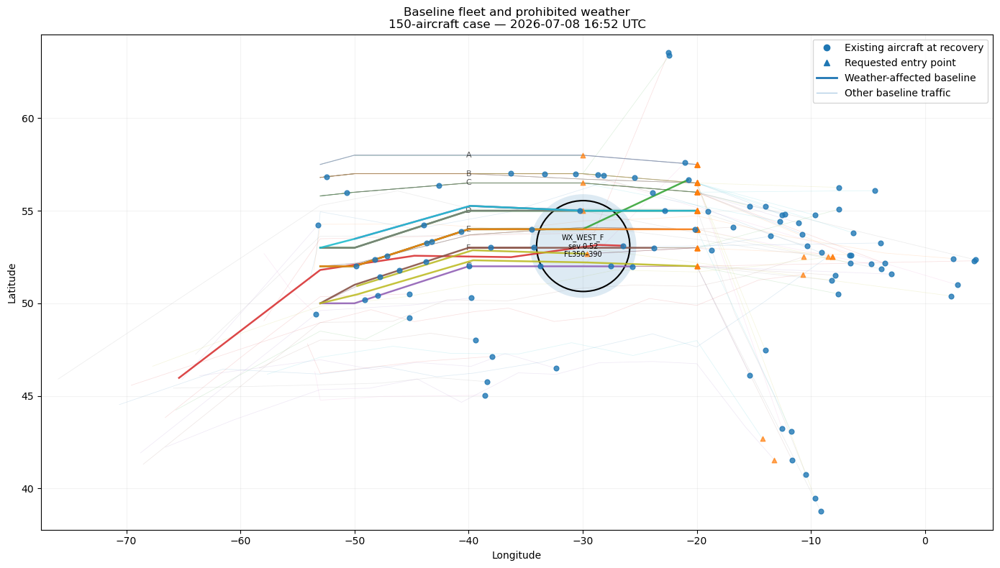


Baseline disruption diagnosis completed for 202 flights.
Weather sampling interval: 5 minutes.
Prohibited-weather rule: severity > 0.5.
Flights requiring robust weather recovery: 15.
Universal baseline horizon: 2026-07-08 16:30 UTC to 2026-07-09 00:21 UTC.
Static disruption picture and dynamic animation generated for the 150-aircraft case.
Cell-6 prohibited baseline-flight diagnostic exported for Cell 8: PASS.
Lower-severity overlaps remain diagnostic only; no recovery alternatives or optimisation decisions have been introduced.


In [6]:
display(Markdown(r"""
## 6. Baseline fleet picture and disruption diagnosis

This cell diagnoses how the supplied time-varying weather affects the
complete no-disruption baseline from Cell 5. Baseline trajectories are
assessed jointly in space, time and FL.

Weather exposure is evaluated at intervals of at most five minutes, including segment endpoints. 
Nominal overlap uses the supplied weather radius; robust
overlap additionally includes forecast uncertainty. Weather is treated
as prohibited only when its supplied severity is strictly greater than
$0.5$.

The cell reports affected flights and weather cells and visualises the
largest frozen scalability case. The static picture highlights baseline
traffic exposed to prohibited weather; the animation shows traffic and
weather evolving through the baseline horizon.

No recovery alternatives, optimisation decisions or solver-specific
objects are introduced.
"""))


# ---------------------------------------------------------------------
# Imports and settings
# ---------------------------------------------------------------------

import re

import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from matplotlib.patches import Ellipse
from matplotlib.lines import Line2D
from IPython.display import HTML


WEATHER_SAMPLE_MIN = 5.0
WEATHER_PROHIBITED_SEVERITY = 0.5
ANIMATION_STEP_MIN = 5.0

CASES = tuple(sorted(SCENARIO_IDS))
ANIMATION_CASE = max(CASES)


# ---------------------------------------------------------------------
# Prepare time-varying weather
# ---------------------------------------------------------------------

WX = weather.copy()

WX["valid_time_min"] = pd.to_numeric(
    WX["valid_time_min"],
    errors="coerce",
)

WEATHER_NUMERIC = [
    "centre_lat",
    "centre_lon",
    "radius_nm",
    "severity_index",
    "affected_fl_min",
    "affected_fl_max",
    "weather_uncertainty_nm",
]

for col in WEATHER_NUMERIC:
    WX[col] = pd.to_numeric(
        WX[col],
        errors="coerce",
    )

WX = (
    WX.dropna(
        subset=[
            "weather_cell_id",
            "valid_time_min",
            "centre_lat",
            "centre_lon",
            "radius_nm",
            "severity_index",
            "affected_fl_min",
            "affected_fl_max",
        ]
    )
    .sort_values(
        ["weather_cell_id", "valid_time_min"]
    )
    .reset_index(drop=True)
)

WX["weather_uncertainty_nm"] = (
    WX["weather_uncertainty_nm"]
    .fillna(0.0)
)

WX_BY_CELL = {
    str(cell_id): group.reset_index(drop=True)
    for cell_id, group
    in WX.groupby("weather_cell_id")
}


def weather_state(cell, t):
    """
    Interpolate one supplied weather cell at time t.
    Continuous numeric fields are interpolated between snapshots.
    """

    times = cell["valid_time_min"].to_numpy(float)

    if t < times.min() or t > times.max():
        return None

    def interp(col):
        return float(
            np.interp(
                t,
                times,
                cell[col].to_numpy(float),
            )
        )

    j = int(
        np.searchsorted(
            times,
            t,
            side="right",
        ) - 1
    )

    j = max(
        0,
        min(j, len(cell) - 1),
    )

    snapshot = cell.iloc[j]

    return {
        "latitude": interp("centre_lat"),
        "longitude": interp("centre_lon"),
        "radius_nm": interp("radius_nm"),
        "uncertainty_nm":
            interp("weather_uncertainty_nm"),
        "severity": interp("severity_index"),
        "fl_min": interp("affected_fl_min"),
        "fl_max": interp("affected_fl_max"),
        "linked_track":
            str(snapshot["linked_track"]),
        "weather_type":
            str(snapshot["weather_type"]),
    }


# ---------------------------------------------------------------------
# Baseline horizons — inherited from Cell 5
# ---------------------------------------------------------------------

BASELINE_T_H_CASE = {
    n: T_H_CASE[n]
    for n in CASES
}

BASELINE_T_H = T_H


# ---------------------------------------------------------------------
# Construct baseline segments
# ---------------------------------------------------------------------

segment_rows = []

for flight_id in I_H:

    flight = (
        BASELINE_STAGES.loc[
            BASELINE_STAGES["flight_id"].eq(flight_id)
        ]
        .sort_values("stage")
        .reset_index(drop=True)
    )

    for a, b in zip(
        flight.iloc[:-1].itertuples(),
        flight.iloc[1:].itertuples(),
    ):

        t0 = float(a.baseline_time_min)
        t1 = float(b.baseline_time_min)

        if t1 <= t0 + NUMERICAL_TOLERANCE:
            raise RuntimeError(
                f"Invalid baseline duration for "
                f"{flight_id}, stage {a.stage}."
            )

        segment_rows.append({
            "flight_id": str(flight_id),
            "population": str(a.population),
            "track": str(a.baseline_track),
            "stage_from": int(a.stage),
            "stage_to": int(b.stage),
            "lat0": float(a.latitude),
            "lon0": float(a.longitude),
            "lat1": float(b.latitude),
            "lon1": float(b.longitude),
            "t0": t0,
            "t1": t1,
            "fl0": float(a.baseline_fl),
            "fl1": float(b.baseline_fl),
        })


BASELINE_SEGMENTS = pd.DataFrame(
    segment_rows
)

if BASELINE_SEGMENTS.empty:
    raise RuntimeError(
        "No baseline segments were constructed."
    )


# ---------------------------------------------------------------------
# Space-time-FL weather assessment
# ---------------------------------------------------------------------

exposure_rows = []

for seg in BASELINE_SEGMENTS.itertuples():

    duration = seg.t1 - seg.t0

    n_samples = max(
        2,
        int(
            np.ceil(
                duration / WEATHER_SAMPLE_MIN
            )
        ) + 1,
    )

    for q in np.linspace(
        0.0,
        1.0,
        n_samples,
    ):

        t = seg.t0 + q * duration
        lat = seg.lat0 + q * (seg.lat1 - seg.lat0)
        lon = seg.lon0 + q * (seg.lon1 - seg.lon0)
        fl = seg.fl0 + q * (seg.fl1 - seg.fl0)

        for weather_id, cell in WX_BY_CELL.items():

            wx = weather_state(
                cell,
                t,
            )

            if wx is None:
                continue

            if not (
                wx["fl_min"] - NUMERICAL_TOLERANCE
                <= fl
                <= wx["fl_max"] + NUMERICAL_TOLERANCE
            ):
                continue

            distance = float(
                haversine_nm(
                    lat,
                    lon,
                    wx["latitude"],
                    wx["longitude"],
                )
            )

            nominal_overlap = (
                distance
                <= wx["radius_nm"]
                + NUMERICAL_TOLERANCE
            )

            robust_overlap = (
                distance
                <= wx["radius_nm"]
                + wx["uncertainty_nm"]
                + NUMERICAL_TOLERANCE
            )

            if not robust_overlap:
                continue

            prohibited = (
                wx["severity"]
                > WEATHER_PROHIBITED_SEVERITY
            )

            exposure_rows.append({
                "flight_id": seg.flight_id,
                "population": seg.population,
                "track": seg.track,
                "stage_from": seg.stage_from,
                "stage_to": seg.stage_to,
                "weather_cell_id": weather_id,
                "linked_track": wx["linked_track"],
                "weather_type": wx["weather_type"],
                "time_min": float(t),
                "flight_level": float(fl),
                "distance_nm": distance,
                "radius_nm": wx["radius_nm"],
                "uncertainty_nm":
                    wx["uncertainty_nm"],
                "severity": wx["severity"],
                "nominal_overlap":
                    bool(nominal_overlap),
                "robust_overlap":
                    bool(robust_overlap),
                "nominal_prohibited":
                    bool(
                        nominal_overlap
                        and prohibited
                    ),
                "robust_prohibited":
                    bool(
                        robust_overlap
                        and prohibited
                    ),
            })


WEATHER_EXPOSURE_SAMPLES = pd.DataFrame(
    exposure_rows
)


# ---------------------------------------------------------------------
# Flight-level disruption diagnosis
# ---------------------------------------------------------------------

FLIGHT_BASELINE = (
    BASELINE_STAGES[
        [
            "flight_id",
            "population",
            "baseline_track",
        ]
    ]
    .drop_duplicates("flight_id")
    .rename(
        columns={
            "baseline_track": "track"
        }
    )
)

flight_diagnosis = []

if not WEATHER_EXPOSURE_SAMPLES.empty:

    for flight_id, group in (
        WEATHER_EXPOSURE_SAMPLES
        .groupby("flight_id")
    ):

        prohibited = group.loc[
            group["robust_prohibited"]
        ]

        flight_diagnosis.append({
            "flight_id": flight_id,
            "nominal_overlap":
                bool(group["nominal_overlap"].any()),
            "robust_overlap":
                bool(group["robust_overlap"].any()),
            "nominal_prohibited":
                bool(group["nominal_prohibited"].any()),
            "robust_prohibited":
                bool(group["robust_prohibited"].any()),
            "first_prohibited_min":
                (
                    float(
                        prohibited["time_min"].min()
                    )
                    if not prohibited.empty
                    else np.nan
                ),
            "max_prohibited_severity":
                (
                    float(
                        prohibited["severity"].max()
                    )
                    if not prohibited.empty
                    else 0.0
                ),
            "weather_cells":
                ", ".join(
                    sorted(
                        set(
                            prohibited[
                                "weather_cell_id"
                            ].astype(str)
                        )
                    )
                ),
        })


if flight_diagnosis:

    WEATHER_DIAGNOSIS = (
        FLIGHT_BASELINE
        .merge(
            pd.DataFrame(
                flight_diagnosis
            ),
            on="flight_id",
            how="left",
        )
    )

else:

    WEATHER_DIAGNOSIS = (
        FLIGHT_BASELINE.copy()
    )


for col in [
    "nominal_overlap",
    "robust_overlap",
    "nominal_prohibited",
    "robust_prohibited",
]:

    if col not in WEATHER_DIAGNOSIS:
        WEATHER_DIAGNOSIS[col] = False

    else:
        WEATHER_DIAGNOSIS[col] = (
            WEATHER_DIAGNOSIS[col]
            .fillna(False)
            .astype(bool)
        )


if "first_prohibited_min" not in WEATHER_DIAGNOSIS:
    WEATHER_DIAGNOSIS[
        "first_prohibited_min"
    ] = np.nan


if "max_prohibited_severity" not in WEATHER_DIAGNOSIS:
    WEATHER_DIAGNOSIS[
        "max_prohibited_severity"
    ] = 0.0

else:
    WEATHER_DIAGNOSIS[
        "max_prohibited_severity"
    ] = (
        WEATHER_DIAGNOSIS[
            "max_prohibited_severity"
        ]
        .fillna(0.0)
    )


if "weather_cells" not in WEATHER_DIAGNOSIS:
    WEATHER_DIAGNOSIS[
        "weather_cells"
    ] = ""

else:
    WEATHER_DIAGNOSIS[
        "weather_cells"
    ] = (
        WEATHER_DIAGNOSIS[
            "weather_cells"
        ]
        .fillna("")
    )


WEATHER_DIAGNOSIS[
    "requires_weather_recovery"
] = WEATHER_DIAGNOSIS[
    "robust_prohibited"
]


# ---------------------------------------------------------------------
# Flights requiring weather recovery
# ---------------------------------------------------------------------

AFFECTED_BASELINE = (
    WEATHER_DIAGNOSIS.loc[
        WEATHER_DIAGNOSIS[
            "requires_weather_recovery"
        ]
    ]
    .sort_values(
        [
            "first_prohibited_min",
            "flight_id",
        ]
    )
    .reset_index(drop=True)
)


if not AFFECTED_BASELINE.empty:

    affected_display = (
        AFFECTED_BASELINE.copy()
    )

    affected_display[
        "First prohibited exposure"
    ] = (
        T_R.normalize()
        + pd.to_timedelta(
            affected_display[
                "first_prohibited_min"
            ],
            unit="m",
        )
    ).dt.strftime(
        "%Y-%m-%d %H:%M UTC"
    )

    display(
        affected_display[
            [
                "flight_id",
                "population",
                "track",
                "nominal_prohibited",
                "robust_prohibited",
                "First prohibited exposure",
                "weather_cells",
                "max_prohibited_severity",
            ]
        ]
        .rename(
            columns={
                "flight_id": "Flight",
                "population": "Population",
                "track": "Baseline track",
                "nominal_prohibited":
                    "Nominal prohibited",
                "robust_prohibited":
                    "Robust prohibited",
                "weather_cells":
                    "Weather cells",
                "max_prohibited_severity":
                    "Maximum severity",
            }
        )
    )


# ---------------------------------------------------------------------
# Weather-cell audit
# ---------------------------------------------------------------------

weather_cell_rows = []

if not WEATHER_EXPOSURE_SAMPLES.empty:

    for (
        weather_id,
        linked_track,
        weather_type,
    ), group in (
        WEATHER_EXPOSURE_SAMPLES
        .groupby(
            [
                "weather_cell_id",
                "linked_track",
                "weather_type",
            ]
        )
    ):

        prohibited = group.loc[
            group["robust_prohibited"]
        ]

        weather_cell_rows.append({
            "Weather cell": weather_id,
            "Associated track": linked_track,
            "Weather type": weather_type,
            "Geometric overlaps":
                int(
                    group[
                        "flight_id"
                    ].nunique()
                ),
            "Prohibited exposures":
                int(
                    prohibited[
                        "flight_id"
                    ].nunique()
                ),
            "Maximum severity":
                float(
                    group[
                        "severity"
                    ].max()
                ),
        })


WEATHER_CELL_DIAGNOSIS = pd.DataFrame(
    weather_cell_rows
)

if not WEATHER_CELL_DIAGNOSIS.empty:
    display(
        WEATHER_CELL_DIAGNOSIS
    )


# ---------------------------------------------------------------------
# Compact population and scalability diagnostics
# ---------------------------------------------------------------------

display(
    FLIGHT_BASELINE
    .groupby(
        [
            "population",
            "track",
        ]
    )
    .size()
    .reset_index(
        name="Flights"
    )
)


population_summary = []

for population in [
    "existing",
    "requested",
]:

    subset = WEATHER_DIAGNOSIS.loc[
        WEATHER_DIAGNOSIS[
            "population"
        ].eq(population)
    ]

    population_summary.append({
        "Population": population,
        "Flights": len(subset),
        "Robust weather overlap":
            int(
                subset[
                    "robust_overlap"
                ].sum()
            ),
        "Nominal prohibited":
            int(
                subset[
                    "nominal_prohibited"
                ].sum()
            ),
        "Robust prohibited":
            int(
                subset[
                    "robust_prohibited"
                ].sum()
            ),
    })


display(
    pd.DataFrame(
        population_summary
    )
)


scenario_summary = []

for n in CASES:

    subset = WEATHER_DIAGNOSIS.loc[
        WEATHER_DIAGNOSIS[
            "flight_id"
        ].isin(
            SCENARIO_IDS[n]
        )
    ]

    scenario_summary.append({
        "Case": n,
        "Flights": len(subset),
        "Nominal prohibited":
            int(
                subset[
                    "nominal_prohibited"
                ].sum()
            ),
        "Robust prohibited":
            int(
                subset[
                    "robust_prohibited"
                ].sum()
            ),
        "Baseline horizon end":
            BASELINE_T_H_CASE[n]
            .strftime(
                "%Y-%m-%d %H:%M UTC"
            ),
    })


display(
    pd.DataFrame(
        scenario_summary
    )
)


# =====================================================================
# Operational visualisation — largest frozen scalability case
# =====================================================================

plot_ids = set(
    SCENARIO_IDS[
        ANIMATION_CASE
    ]
)

plot_stages = (
    BASELINE_STAGES.loc[
        BASELINE_STAGES[
            "flight_id"
        ].isin(plot_ids)
    ]
    .copy()
)

affected_plot_ids = (
    set(
        WEATHER_DIAGNOSIS.loc[
            WEATHER_DIAGNOSIS[
                "flight_id"
            ].isin(plot_ids)
            & WEATHER_DIAGNOSIS[
                "robust_prohibited"
            ],
            "flight_id",
        ].astype(str)
    )
)


# ---------------------------------------------------------------------
# OTS geometry for visual context
# ---------------------------------------------------------------------

VISUAL_TRACKS = {}

for track_id, route in OTS_ROUTE.items():

    if route:
        VISUAL_TRACKS[str(track_id)] = route


# ---------------------------------------------------------------------
# Determine representative disruption time
# ---------------------------------------------------------------------

affected_samples = (
    WEATHER_EXPOSURE_SAMPLES.loc[
        WEATHER_EXPOSURE_SAMPLES[
            "flight_id"
        ].isin(plot_ids)
        & WEATHER_EXPOSURE_SAMPLES[
            "robust_prohibited"
        ]
    ]
    if not WEATHER_EXPOSURE_SAMPLES.empty
    else pd.DataFrame()
)

if not affected_samples.empty:

    STATIC_TIME_MIN = float(
        affected_samples[
            "time_min"
        ].median()
    )

else:

    STATIC_TIME_MIN = float(
        (
            T_R - T_R.normalize()
        ).total_seconds()
        / 60.0
    )


STATIC_TIME = (
    T_R.normalize()
    + pd.to_timedelta(
        STATIC_TIME_MIN,
        unit="m",
    )
)


# ---------------------------------------------------------------------
# Shared plotting bounds
# ---------------------------------------------------------------------

lon_values = list(
    plot_stages[
        "longitude"
    ].astype(float)
)

lat_values = list(
    plot_stages[
        "latitude"
    ].astype(float)
)

for route in VISUAL_TRACKS.values():

    lon_values.extend(
        point[2]
        for point in route
    )

    lat_values.extend(
        point[1]
        for point in route
    )


LON_MIN = min(lon_values) - 1.5
LON_MAX = max(lon_values) + 1.5
LAT_MIN = min(lat_values) - 1.0
LAT_MAX = max(lat_values) + 1.0


# ---------------------------------------------------------------------
# Helper: draw weather footprint
# ---------------------------------------------------------------------

def weather_ellipse_parameters(wx, robust=True):

    radius_nm = wx["radius_nm"]

    if robust:
        radius_nm += wx["uncertainty_nm"]

    radius_lat = (
        radius_nm / 60.0
    )

    cos_lat = max(
        np.cos(
            np.radians(
                wx["latitude"]
            )
        ),
        0.1,
    )

    radius_lon = (
        radius_nm
        / (60.0 * cos_lat)
    )

    return (
        2.0 * radius_lon,
        2.0 * radius_lat,
    )


# ---------------------------------------------------------------------
# Static baseline disruption picture
# ---------------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(14, 8)
)

ax.set_xlim(
    LON_MIN,
    LON_MAX,
)

ax.set_ylim(
    LAT_MIN,
    LAT_MAX,
)


# OTS tracks
for track_id, route in (
    VISUAL_TRACKS.items()
):

    lats = [
        point[1]
        for point in route
    ]

    lons = [
        point[2]
        for point in route
    ]

    ax.plot(
        lons,
        lats,
        linewidth=1.0,
        alpha=0.25,
    )

    mid = len(route) // 2

    ax.text(
        route[mid][2],
        route[mid][1],
        str(track_id),
        fontsize=8,
        ha="center",
        va="center",
        alpha=0.65,
    )


# Baseline trajectories
for flight_id, profile in (
    plot_stages
    .groupby("flight_id")
):

    profile = profile.sort_values(
        "stage"
    )

    affected = (
        str(flight_id)
        in affected_plot_ids
    )

    ax.plot(
        profile["longitude"],
        profile["latitude"],
        linewidth=(
            1.8
            if affected
            else 0.55
        ),
        alpha=(
            0.85
            if affected
            else 0.14
        ),
        zorder=(
            4
            if affected
            else 1
        ),
    )


# Existing aircraft at recovery
existing_now = (
    plot_stages.loc[
        plot_stages[
            "population"
        ].eq("existing")
        & plot_stages[
            "stage"
        ].eq(1)
    ]
)

ax.scatter(
    existing_now["longitude"],
    existing_now["latitude"],
    s=24,
    marker="o",
    alpha=0.8,
    zorder=6,
)


# Requested entry points
requested_entry = (
    plot_stages.loc[
        plot_stages[
            "population"
        ].eq("requested")
    ]
    .sort_values(
        "stage"
    )
    .groupby(
        "flight_id",
        as_index=False,
    )
    .first()
)

ax.scatter(
    requested_entry["longitude"],
    requested_entry["latitude"],
    s=22,
    marker="^",
    alpha=0.7,
    zorder=5,
)


# Weather at representative disruption time
for weather_id, cell in (
    WX_BY_CELL.items()
):

    wx = weather_state(
        cell,
        STATIC_TIME_MIN,
    )

    if (
        wx is None
        or wx["severity"]
        <= WEATHER_PROHIBITED_SEVERITY
    ):
        continue

    robust_width, robust_height = (
        weather_ellipse_parameters(
            wx,
            robust=True,
        )
    )

    nominal_width, nominal_height = (
        weather_ellipse_parameters(
            wx,
            robust=False,
        )
    )

    robust_patch = Ellipse(
        (
            wx["longitude"],
            wx["latitude"],
        ),
        width=robust_width,
        height=robust_height,
        alpha=0.15,
        zorder=2,
    )

    nominal_patch = Ellipse(
        (
            wx["longitude"],
            wx["latitude"],
        ),
        width=nominal_width,
        height=nominal_height,
        fill=False,
        linewidth=1.5,
        zorder=3,
    )

    ax.add_patch(
        robust_patch
    )

    ax.add_patch(
        nominal_patch
    )

    ax.text(
        wx["longitude"],
        wx["latitude"],
        (
            f"{weather_id}\n"
            f"sev {wx['severity']:.2f}\n"
            f"FL{wx['fl_min']:.0f}"
            f"–{wx['fl_max']:.0f}"
        ),
        fontsize=7,
        ha="center",
        va="center",
        zorder=7,
    )


ax.set_title(
    "Baseline fleet and prohibited weather\n"
    f"{ANIMATION_CASE}-aircraft case — "
    f"{STATIC_TIME.strftime('%Y-%m-%d %H:%M UTC')}"
)

ax.set_xlabel(
    "Longitude"
)

ax.set_ylabel(
    "Latitude"
)

ax.grid(
    alpha=0.15
)

legend_handles = [
    Line2D(
        [0],
        [0],
        marker="o",
        linestyle="None",
        markersize=6,
        label="Existing aircraft at recovery",
    ),
    Line2D(
        [0],
        [0],
        marker="^",
        linestyle="None",
        markersize=6,
        label="Requested entry point",
    ),
    Line2D(
        [0],
        [0],
        linewidth=2,
        label="Weather-affected baseline",
    ),
    Line2D(
        [0],
        [0],
        linewidth=1,
        alpha=0.35,
        label="Other baseline traffic",
    ),
]

ax.legend(
    handles=legend_handles,
    loc="best",
    frameon=True,
)

plt.tight_layout()
plt.show()


# =====================================================================
# Dynamic baseline animation
# =====================================================================

ANIMATION_PROFILES = {
    str(flight_id):
        group.sort_values(
            "stage"
        ).reset_index(drop=True)
    for flight_id, group
    in plot_stages.groupby(
        "flight_id"
    )
}


def flight_state_at_time(profile, t):
    """Interpolate baseline position and FL at time t."""

    times = profile[
        "baseline_time_min"
    ].to_numpy(float)

    if (
        t < times[0]
        or t > times[-1]
    ):
        return None

    if np.isclose(
        t,
        times[-1],
    ):

        row = profile.iloc[-1]

        return (
            float(row["latitude"]),
            float(row["longitude"]),
            float(row["baseline_fl"]),
        )

    j = int(
        np.searchsorted(
            times,
            t,
            side="right",
        ) - 1
    )

    j = max(
        0,
        min(
            j,
            len(profile) - 2,
        ),
    )

    denominator = (
        times[j + 1]
        - times[j]
    )

    q = (
        (t - times[j])
        / denominator
    )

    a = profile.iloc[j]
    b = profile.iloc[j + 1]

    return (
        float(
            a["latitude"]
            + q
            * (
                b["latitude"]
                - a["latitude"]
            )
        ),
        float(
            a["longitude"]
            + q
            * (
                b["longitude"]
                - a["longitude"]
            )
        ),
        float(
            a["baseline_fl"]
            + q
            * (
                b["baseline_fl"]
                - a["baseline_fl"]
            )
        ),
    )


animation_start = float(
    (
        T_R - T_R.normalize()
    ).total_seconds()
    / 60.0
)

animation_end = float(
    (
        BASELINE_T_H_CASE[
            ANIMATION_CASE
        ]
        - T_R.normalize()
    ).total_seconds()
    / 60.0
)

ANIMATION_TIMES = np.arange(
    animation_start,
    animation_end
    + ANIMATION_STEP_MIN,
    ANIMATION_STEP_MIN,
)


fig_anim, ax_anim = plt.subplots(
    figsize=(14, 8)
)

ax_anim.set_xlim(
    LON_MIN,
    LON_MAX,
)

ax_anim.set_ylim(
    LAT_MIN,
    LAT_MAX,
)

ax_anim.set_xlabel(
    "Longitude"
)

ax_anim.set_ylabel(
    "Latitude"
)

ax_anim.grid(
    alpha=0.15
)


# OTS tracks remain fixed
for track_id, route in (
    VISUAL_TRACKS.items()
):

    lats = [
        point[1]
        for point in route
    ]

    lons = [
        point[2]
        for point in route
    ]

    ax_anim.plot(
        lons,
        lats,
        linewidth=0.9,
        alpha=0.18,
        zorder=0,
    )

    mid = len(route) // 2

    ax_anim.text(
        route[mid][2],
        route[mid][1],
        str(track_id),
        fontsize=7,
        ha="center",
        va="center",
        alpha=0.5,
    )


# Baseline paths remain fixed
for flight_id, profile in (
    ANIMATION_PROFILES.items()
):

    affected = (
        flight_id
        in affected_plot_ids
    )

    ax_anim.plot(
        profile["longitude"],
        profile["latitude"],
        linewidth=(
            1.0
            if affected
            else 0.4
        ),
        alpha=(
            0.30
            if affected
            else 0.07
        ),
        zorder=1,
    )


existing_scatter = ax_anim.scatter(
    [],
    [],
    s=28,
    marker="o",
    label="Existing",
    zorder=6,
)

requested_scatter = ax_anim.scatter(
    [],
    [],
    s=28,
    marker="^",
    label="Requested",
    zorder=6,
)

affected_scatter = ax_anim.scatter(
    [],
    [],
    s=70,
    marker="o",
    facecolors="none",
    linewidths=1.5,
    label="Baseline weather-affected",
    zorder=7,
)

inside_weather_scatter = ax_anim.scatter(
    [],
    [],
    s=95,
    marker="x",
    linewidths=2.0,
    label="Inside prohibited weather",
    zorder=8,
)


time_label = ax_anim.text(
    0.02,
    0.97,
    "",
    transform=ax_anim.transAxes,
    va="top",
    fontsize=11,
)


status_label = ax_anim.text(
    0.02,
    0.89,
    "",
    transform=ax_anim.transAxes,
    va="top",
    fontsize=9,
)


# Weather artists are created once and updated each frame.
weather_artists = {}

for weather_id in WX_BY_CELL:

    robust_patch = Ellipse(
        (0, 0),
        width=0,
        height=0,
        alpha=0.14,
        visible=False,
        zorder=2,
    )

    nominal_patch = Ellipse(
        (0, 0),
        width=0,
        height=0,
        fill=False,
        linewidth=1.3,
        visible=False,
        zorder=3,
    )

    label = ax_anim.text(
        0,
        0,
        "",
        fontsize=7,
        ha="center",
        va="center",
        visible=False,
        zorder=5,
    )

    ax_anim.add_patch(
        robust_patch
    )

    ax_anim.add_patch(
        nominal_patch
    )

    weather_artists[
        weather_id
    ] = {
        "robust": robust_patch,
        "nominal": nominal_patch,
        "label": label,
    }


ax_anim.legend(
    loc="lower left",
    frameon=True,
)


def update_animation(frame):

    t = float(
        ANIMATION_TIMES[
            frame
        ]
    )

    existing_positions = []
    requested_positions = []
    affected_positions = []
    active_states = []

    for flight_id, profile in (
        ANIMATION_PROFILES.items()
    ):

        state = flight_state_at_time(
            profile,
            t,
        )

        if state is None:
            continue

        lat, lon, fl = state

        population = str(
            profile.iloc[0][
                "population"
            ]
        )

        active_states.append(
            (
                flight_id,
                lat,
                lon,
                fl,
            )
        )

        if population == "existing":
            existing_positions.append(
                [lon, lat]
            )

        else:
            requested_positions.append(
                [lon, lat]
            )

        if flight_id in affected_plot_ids:
            affected_positions.append(
                [lon, lat]
            )


    existing_scatter.set_offsets(
        np.asarray(
            existing_positions
        )
        if existing_positions
        else np.empty((0, 2))
    )

    requested_scatter.set_offsets(
        np.asarray(
            requested_positions
        )
        if requested_positions
        else np.empty((0, 2))
    )

    affected_scatter.set_offsets(
        np.asarray(
            affected_positions
        )
        if affected_positions
        else np.empty((0, 2))
    )


    active_weather = []

    for weather_id, cell in (
        WX_BY_CELL.items()
    ):

        artists = weather_artists[
            weather_id
        ]

        wx = weather_state(
            cell,
            t,
        )

        prohibited = (
            wx is not None
            and wx["severity"]
            > WEATHER_PROHIBITED_SEVERITY
        )

        if not prohibited:

            artists[
                "robust"
            ].set_visible(False)

            artists[
                "nominal"
            ].set_visible(False)

            artists[
                "label"
            ].set_visible(False)

            continue


        robust_width, robust_height = (
            weather_ellipse_parameters(
                wx,
                robust=True,
            )
        )

        nominal_width, nominal_height = (
            weather_ellipse_parameters(
                wx,
                robust=False,
            )
        )

        centre = (
            wx["longitude"],
            wx["latitude"],
        )

        artists[
            "robust"
        ].center = centre

        artists[
            "robust"
        ].width = robust_width

        artists[
            "robust"
        ].height = robust_height

        artists[
            "robust"
        ].set_visible(True)


        artists[
            "nominal"
        ].center = centre

        artists[
            "nominal"
        ].width = nominal_width

        artists[
            "nominal"
        ].height = nominal_height

        artists[
            "nominal"
        ].set_visible(True)


        artists[
            "label"
        ].set_position(
            centre
        )

        artists[
            "label"
        ].set_text(
            (
                f"{weather_id}\n"
                f"{wx['severity']:.2f}"
            )
        )

        artists[
            "label"
        ].set_visible(True)

        active_weather.append(
            (
                weather_id,
                wx,
            )
        )


    inside_positions = []

    for (
        flight_id,
        lat,
        lon,
        fl,
    ) in active_states:

        inside = False

        for _, wx in active_weather:

            if not (
                wx["fl_min"]
                - NUMERICAL_TOLERANCE
                <= fl
                <= wx["fl_max"]
                + NUMERICAL_TOLERANCE
            ):
                continue

            distance = float(
                haversine_nm(
                    lat,
                    lon,
                    wx["latitude"],
                    wx["longitude"],
                )
            )

            if (
                distance
                <= wx["radius_nm"]
                + wx["uncertainty_nm"]
                + NUMERICAL_TOLERANCE
            ):
                inside = True
                break

        if inside:
            inside_positions.append(
                [lon, lat]
            )


    inside_weather_scatter.set_offsets(
        np.asarray(
            inside_positions
        )
        if inside_positions
        else np.empty((0, 2))
    )


    current_time = (
        T_R.normalize()
        + pd.to_timedelta(
            t,
            unit="m",
        )
    )

    time_label.set_text(
        current_time.strftime(
            "%Y-%m-%d %H:%M UTC"
        )
    )

    status_label.set_text(
        (
            f"Active aircraft: "
            f"{len(active_states)}   |   "
            f"Prohibited weather cells: "
            f"{len(active_weather)}   |   "
            f"Aircraft inside robust prohibited footprint: "
            f"{len(inside_positions)}"
        )
    )

    ax_anim.set_title(
        "Baseline NAT traffic and time-varying prohibited weather\n"
        f"{ANIMATION_CASE}-aircraft scalability case"
    )

    artists = [
        existing_scatter,
        requested_scatter,
        affected_scatter,
        inside_weather_scatter,
        time_label,
        status_label,
    ]

    for item in weather_artists.values():
        artists.extend(
            [
                item["robust"],
                item["nominal"],
                item["label"],
            ]
        )

    return tuple(
        artists
    )


baseline_animation = FuncAnimation(
    fig_anim,
    update_animation,
    frames=len(
        ANIMATION_TIMES
    ),
    interval=180,
    blit=False,
    repeat=True,
)

plt.close(
    fig_anim
)

display(
    HTML(
        baseline_animation.to_jshtml()
    )
)


# ---------------------------------------------------------------------
# Export baseline-weather diagnostic for Cell 8
# ---------------------------------------------------------------------

CELL6_PROHIBITED_FLIGHTS = set(
    WEATHER_DIAGNOSIS.loc[
        WEATHER_DIAGNOSIS[
            "robust_prohibited"
        ],
        "flight_id",
    ].astype(str)
)


# ---------------------------------------------------------------------
# Certification
# ---------------------------------------------------------------------

assert (
    len(
        WEATHER_DIAGNOSIS
    )
    == len(I_H)
)

assert (
    set(
        WEATHER_DIAGNOSIS[
            "flight_id"
        ]
    )
    == set(I_H)
)

if (
    len(
        CELL6_PROHIBITED_FLIGHTS
    )
    != int(
        WEATHER_DIAGNOSIS[
            "requires_weather_recovery"
        ].sum()
    )
):
    raise RuntimeError(
        "Cell-6 prohibited-flight export is inconsistent "
        "with the baseline disruption diagnosis."
    )


print(
    f"\nBaseline disruption diagnosis completed for "
    f"{len(I_H)} flights."
)

print(
    f"Weather sampling interval: "
    f"{WEATHER_SAMPLE_MIN:.0f} minutes."
)

print(
    f"Prohibited-weather rule: severity > "
    f"{WEATHER_PROHIBITED_SEVERITY:.1f}."
)

print(
    f"Flights requiring robust weather recovery: "
    f"{len(CELL6_PROHIBITED_FLIGHTS)}."
)

print(
    f"Universal baseline horizon: "
    f"{T_R.strftime('%Y-%m-%d %H:%M UTC')} to "
    f"{BASELINE_T_H.strftime('%Y-%m-%d %H:%M UTC')}."
)

print(
    f"Static disruption picture and dynamic animation generated "
    f"for the {ANIMATION_CASE}-aircraft case."
)

print(
    "Cell-6 prohibited baseline-flight diagnostic exported "
    "for Cell 8: PASS."
)

print(
    "Lower-severity overlaps remain diagnostic only; "
    "no recovery alternatives or optimisation decisions have "
    "been introduced."
)

In [7]:
display(Markdown(r"""
## 7. Construct the data-supported recovery domain

This cell constructs the operating domain available to the fleet-recovery
model. For each flight and remaining stage it identifies data-supported
track, FL and Mach states, permissible stage-to-stage movements,
track–FL compatibility, movement distances and movement times.

The supplied baseline remains authoritative. Lateral alternatives are
constructed as complete local corridors on immediately neighbouring active
OTS tracks: a flight leaves its baseline, follows the supplied alternative
track through a contiguous portion of the remaining progression, and then
rejoins its downstream baseline. Isolated stage-by-stage track changes and
jumps across multiple OTS tracks are not introduced.

The first lateral state of every flight remains its supplied recovery-entry
state; the complete first state of each existing flight remains fixed to its
realised state at $t_R$. Weather and aircraft separation are imposed in
subsequent cells. No optimisation variables or solver-specific objects are
introduced.
"""))

import re
import numpy as np
import pandas as pd


# ---------------------------------------------------------------------
# Settings
# ---------------------------------------------------------------------

CASES = tuple(sorted(SCENARIO_IDS))

# A useful lateral corridor must contain at least one genuine
# alternative-track continuation between departure and rejoin.
MIN_ALTERNATIVE_STAGES = 2

ENTRY_WINDOW_END_MIN = (
    ENTRY_WINDOW_END - T_R.normalize()
).total_seconds() / 60.0


# ---------------------------------------------------------------------
# Helpers
# ---------------------------------------------------------------------

def parse_levels(value):
    """Extract supplied FL values."""
    if pd.isna(value):
        return tuple()

    return tuple(sorted({
        int(x)
        for x in re.findall(r"\d+", str(value))
    }))


def unique_numeric(values):
    """Sorted unique finite numeric values."""
    return tuple(sorted({
        float(x)
        for x in values
        if pd.notna(x)
        and np.isfinite(float(x))
    }))


def first_existing_column(df, candidates):
    """Return the first supplied column matching a candidate name."""
    return next(
        (
            col
            for col in candidates
            if col in df.columns
        ),
        None,
    )


def consecutive_runs(positions):
    """Split sorted integer positions into maximal consecutive runs."""
    positions = sorted(set(positions))

    if not positions:
        return []

    runs = []
    start = previous = positions[0]

    for value in positions[1:]:

        if value == previous + 1:
            previous = value
            continue

        runs.append((start, previous))
        start = previous = value

    runs.append((start, previous))

    return runs


# ---------------------------------------------------------------------
# Active OTS geometry and FL availability
# ---------------------------------------------------------------------

OTS_DOMAIN = ACTIVE_OTS.copy()

TRACK_ROUTE = {
    str(row["track_id"]):
        parse_geocoded_route(
            row["route_of_track"]
        )
    for _, row in OTS_DOMAIN.iterrows()
}

TRACK_FL = {
    str(row["track_id"]):
        parse_levels(
            row["available_flight_levels"]
        )
    for _, row in OTS_DOMAIN.iterrows()
}


def track_point_at_longitude(track, longitude):
    """
    Interpolate one supplied OTS track at a target longitude.

    The point is obtained only from supplied track segments; no arbitrary
    route coordinate is introduced.
    """
    route = TRACK_ROUTE.get(
        str(track),
        tuple(),
    )

    if len(route) < 2:
        return None

    candidates = []

    for (
        _,
        lat0,
        lon0,
    ), (
        _,
        lat1,
        lon1,
    ) in zip(
        route[:-1],
        route[1:],
    ):

        lo = min(lon0, lon1)
        hi = max(lon0, lon1)

        if not (
            lo - NUMERICAL_TOLERANCE
            <= longitude
            <= hi + NUMERICAL_TOLERANCE
        ):
            continue

        if np.isclose(
            lon0,
            lon1,
        ):
            lat = 0.5 * (
                float(lat0)
                + float(lat1)
            )

        else:
            q = (
                (longitude - float(lon0))
                / (float(lon1) - float(lon0))
            )

            lat = (
                float(lat0)
                + q
                * (
                    float(lat1)
                    - float(lat0)
                )
            )

        candidates.append(
            (
                float(lat),
                float(longitude),
            )
        )

    if not candidates:
        return None

    # Active NAT track geometry is effectively single-valued at the
    # modelled longitudes. Resolve any numerical duplicate deterministically.
    return candidates[0]


# ---------------------------------------------------------------------
# Baseline lookup
# ---------------------------------------------------------------------

BASELINE_LOOKUP = (
    BASELINE_STAGES
    .set_index(
        ["flight_id", "stage"]
    )
)

POPULATION_LOOKUP = (
    BASELINE_STAGES[
        ["flight_id", "population"]
    ]
    .drop_duplicates("flight_id")
    .set_index("flight_id")[
        "population"
    ]
    .to_dict()
)


# ---------------------------------------------------------------------
# Supplied aircraft FL limits
# ---------------------------------------------------------------------

EXISTING_MIN_FL_COL = first_existing_column(
    existing_profiles,
    [
        "minimum_flight_level",
        "min_flight_level",
        "minimum_fl",
        "min_fl",
    ],
)

EXISTING_MAX_FL_COL = first_existing_column(
    existing_profiles,
    [
        "maximum_flight_level",
        "max_flight_level",
        "maximum_fl",
        "max_fl",
    ],
)

REQUEST_MIN_FL_COL = first_existing_column(
    requests,
    [
        "minimum_flight_level",
        "min_flight_level",
        "minimum_fl",
        "min_fl",
    ],
)

REQUEST_MAX_FL_COL = first_existing_column(
    requests,
    [
        "maximum_flight_level",
        "max_flight_level",
        "maximum_fl",
        "max_fl",
    ],
)


EXISTING_SOURCE = (
    existing_profiles
    .assign(
        existing_flight_id=lambda x:
            x["existing_flight_id"].astype(str)
    )
    .set_index("existing_flight_id")
)

REQUEST_SOURCE = (
    requests
    .assign(
        flight_request_id=lambda x:
            x["flight_request_id"].astype(str)
    )
    .set_index("flight_request_id")
)


def aircraft_fl_limits(flight_id):
    """Return supplied aircraft FL limits; absent limits add no restriction."""

    if POPULATION_LOOKUP[flight_id] == "existing":

        row = EXISTING_SOURCE.loc[
            flight_id
        ]

        lo_col = EXISTING_MIN_FL_COL
        hi_col = EXISTING_MAX_FL_COL

    else:

        row = REQUEST_SOURCE.loc[
            flight_id
        ]

        lo_col = REQUEST_MIN_FL_COL
        hi_col = REQUEST_MAX_FL_COL

    lo = (
        pd.to_numeric(
            row[lo_col],
            errors="coerce",
        )
        if lo_col
        else np.nan
    )

    hi = (
        pd.to_numeric(
            row[hi_col],
            errors="coerce",
        )
        if hi_col
        else np.nan
    )

    return (
        float(lo)
        if pd.notna(lo)
        else -np.inf,
        float(hi)
        if pd.notna(hi)
        else np.inf,
    )


# ---------------------------------------------------------------------
# Supplied OTS geometry at every baseline stage
# ---------------------------------------------------------------------

BASELINE_POINT = {}
OTS_STAGE_POINT = {}
LOCAL_ALTERNATIVES = {}

for flight_id in I_H:

    flight = (
        BASELINE_STAGES.loc[
            BASELINE_STAGES[
                "flight_id"
            ].eq(flight_id)
        ]
        .sort_values("stage")
        .reset_index(drop=True)
    )

    for pos, row in flight.iterrows():

        stage = int(
            row["stage"]
        )

        baseline_track = str(
            row["baseline_track"]
        )

        baseline_lat = float(
            row["latitude"]
        )

        baseline_lon = float(
            row["longitude"]
        )

        BASELINE_POINT[
            (flight_id, stage)
        ] = (
            baseline_lat,
            baseline_lon,
        )

        ots_points = []

        for track in sorted(
            TRACK_ROUTE
        ):

            point = track_point_at_longitude(
                track,
                baseline_lon,
            )

            if point is None:
                continue

            OTS_STAGE_POINT[
                (
                    flight_id,
                    stage,
                    track,
                )
            ] = point

            ots_points.append(
                (
                    track,
                    point[0],
                )
            )

        alternatives = set()

        if ots_points:

            ordered = sorted(
                ots_points,
                key=lambda x: x[1],
            )

            tracks = [
                track
                for track, _
                in ordered
            ]

            if baseline_track in tracks:

                k = tracks.index(
                    baseline_track
                )

                if k > 0:
                    alternatives.add(
                        tracks[k - 1]
                    )

                if k < len(tracks) - 1:
                    alternatives.add(
                        tracks[k + 1]
                    )

            else:

                # RANDOM_ROUTE/off-track baseline:
                # only the nearest supplied active OTS track is local.
                nearest = min(
                    ordered,
                    key=lambda x:
                        abs(
                            x[1]
                            - baseline_lat
                        ),
                )[0]

                alternatives.add(
                    nearest
                )

        # A track equal to the baseline is not an alternative.
        alternatives.discard(
            baseline_track
        )

        LOCAL_ALTERNATIVES[
            (flight_id, stage)
        ] = tuple(
            sorted(alternatives)
        )


# ---------------------------------------------------------------------
# Complete coherent lateral corridors
# ---------------------------------------------------------------------

LATERAL_CORRIDORS = {}
corridor_rows = []

for flight_id in I_H:

    flight = (
        BASELINE_STAGES.loc[
            BASELINE_STAGES[
                "flight_id"
            ].eq(flight_id)
        ]
        .sort_values("stage")
        .reset_index(drop=True)
    )

    n_stage = len(flight)

    corridors = []

    alternative_tracks = sorted({
        track
        for _, row in flight.iterrows()
        for track in LOCAL_ALTERNATIVES[
            (
                flight_id,
                int(row["stage"]),
            )
        ]
    })

    for alt_track in alternative_tracks:

        eligible_positions = []

        # Position 0 is kept at the supplied recovery/entry state.
        # The terminal stage is kept on the supplied baseline.
        for pos in range(
            1,
            n_stage - 1,
        ):

            stage = int(
                flight.iloc[pos][
                    "stage"
                ]
            )

            baseline_track = str(
                flight.iloc[pos][
                    "baseline_track"
                ]
            )

            if (
                alt_track
                == baseline_track
            ):
                continue

            if (
                alt_track
                in LOCAL_ALTERNATIVES[
                    (
                        flight_id,
                        stage,
                    )
                ]
                and
                (
                    flight_id,
                    stage,
                    alt_track,
                )
                in OTS_STAGE_POINT
            ):
                eligible_positions.append(
                    pos
                )

        for start, end in consecutive_runs(
            eligible_positions
        ):

            # Need at least two alternative states so the corridor
            # contains genuine continuation, not a one-stage dogleg.
            if (
                end - start + 1
                < MIN_ALTERNATIVE_STAGES
            ):
                continue

            # A complete corridor requires baseline before departure
            # and after rejoin.
            if (
                start <= 0
                or end >= n_stage - 1
            ):
                continue

            departure_baseline = str(
                flight.iloc[
                    start - 1
                ]["baseline_track"]
            )

            rejoin_baseline = str(
                flight.iloc[
                    end + 1
                ]["baseline_track"]
            )

            # If the alternative has become the baseline at a boundary,
            # this is not a genuine leave/rejoin corridor.
            if (
                departure_baseline
                == alt_track
                or
                rejoin_baseline
                == alt_track
            ):
                continue

            corridor = {
                "flight_id":
                    flight_id,
                "alternative_track":
                    alt_track,
                "start_pos":
                    int(start),
                "end_pos":
                    int(end),
                "departure_stage":
                    int(
                        flight.iloc[
                            start - 1
                        ]["stage"]
                    ),
                "first_alternative_stage":
                    int(
                        flight.iloc[
                            start
                        ]["stage"]
                    ),
                "last_alternative_stage":
                    int(
                        flight.iloc[
                            end
                        ]["stage"]
                    ),
                "rejoin_stage":
                    int(
                        flight.iloc[
                            end + 1
                        ]["stage"]
                    ),
                "alternative_stages":
                    int(
                        end - start + 1
                    ),
            }

            corridors.append(
                corridor
            )

            corridor_rows.append(
                corridor.copy()
            )

    LATERAL_CORRIDORS[
        flight_id
    ] = corridors


LATERAL_CORRIDOR_AUDIT = pd.DataFrame(
    corridor_rows
)


# ---------------------------------------------------------------------
# Stage-specific track domains R_is and their geometry
# ---------------------------------------------------------------------

R = {}
STAGE_TRACK_POINT = {}

for flight_id in I_H:

    flight = (
        BASELINE_STAGES.loc[
            BASELINE_STAGES[
                "flight_id"
            ].eq(flight_id)
        ]
        .sort_values("stage")
        .reset_index(drop=True)
    )

    for pos, row in flight.iterrows():

        stage = int(
            row["stage"]
        )

        baseline_track = str(
            row["baseline_track"]
        )

        # Cell-5 baseline geometry is authoritative.
        STAGE_TRACK_POINT[
            (
                flight_id,
                stage,
                baseline_track,
            )
        ] = BASELINE_POINT[
            (flight_id, stage)
        ]

        supported = {
            baseline_track
        }

        for corridor in (
            LATERAL_CORRIDORS[
                flight_id
            ]
        ):

            if (
                corridor["start_pos"]
                <= pos
                <= corridor["end_pos"]
            ):

                alt_track = corridor[
                    "alternative_track"
                ]

                point_key = (
                    flight_id,
                    stage,
                    alt_track,
                )

                if (
                    point_key
                    not in OTS_STAGE_POINT
                ):
                    raise RuntimeError(
                        f"Missing supplied alternative geometry for "
                        f"{flight_id}, stage {stage}, track {alt_track}."
                    )

                supported.add(
                    alt_track
                )

                # OTS interpolation is stored only for alternatives.
                STAGE_TRACK_POINT[
                    point_key
                ] = OTS_STAGE_POINT[
                    point_key
                ]

        R[
            (flight_id, stage)
        ] = tuple(
            sorted(supported)
        )


# ---------------------------------------------------------------------
# Coherent stage-to-stage lateral movements
# ---------------------------------------------------------------------

TRACK_MOVEMENTS = {}

for flight_id in I_H:

    flight = (
        BASELINE_STAGES.loc[
            BASELINE_STAGES[
                "flight_id"
            ].eq(flight_id)
        ]
        .sort_values("stage")
        .reset_index(drop=True)
    )

    # Begin with the complete baseline path only.
    for pos in range(
        len(flight) - 1
    ):

        stage = int(
            flight.iloc[
                pos
            ]["stage"]
        )

        baseline_r = str(
            flight.iloc[
                pos
            ]["baseline_track"]
        )

        baseline_rp = str(
            flight.iloc[
                pos + 1
            ]["baseline_track"]
        )

        TRACK_MOVEMENTS[
            (flight_id, stage)
        ] = {
            (
                baseline_r,
                baseline_rp,
            )
        }

    # Add complete leave -> continuation -> rejoin corridors.
    for corridor in (
        LATERAL_CORRIDORS[
            flight_id
        ]
    ):

        alt = corridor[
            "alternative_track"
        ]

        start = corridor[
            "start_pos"
        ]

        end = corridor[
            "end_pos"
        ]

        # Leave baseline.
        departure_pos = (
            start - 1
        )

        departure_stage = int(
            flight.iloc[
                departure_pos
            ]["stage"]
        )

        departure_baseline = str(
            flight.iloc[
                departure_pos
            ]["baseline_track"]
        )

        TRACK_MOVEMENTS[
            (
                flight_id,
                departure_stage,
            )
        ].add(
            (
                departure_baseline,
                alt,
            )
        )

        # Remain on supplied alternative track.
        for pos in range(
            start,
            end,
        ):

            stage = int(
                flight.iloc[
                    pos
                ]["stage"]
            )

            TRACK_MOVEMENTS[
                (
                    flight_id,
                    stage,
                )
            ].add(
                (
                    alt,
                    alt,
                )
            )

        # Rejoin downstream baseline.
        rejoin_from_pos = end

        rejoin_from_stage = int(
            flight.iloc[
                rejoin_from_pos
            ]["stage"]
        )

        downstream_baseline = str(
            flight.iloc[
                rejoin_from_pos + 1
            ]["baseline_track"]
        )

        TRACK_MOVEMENTS[
            (
                flight_id,
                rejoin_from_stage,
            )
        ].add(
            (
                alt,
                downstream_baseline,
            )
        )

    # Freeze deterministic tuples and validate endpoint states.
    stages = S_i[
        flight_id
    ]

    for stage, next_stage in zip(
        stages[:-1],
        stages[1:],
    ):

        valid = tuple(sorted(
            (
                r,
                rp,
            )
            for r, rp
            in TRACK_MOVEMENTS[
                (flight_id, stage)
            ]
            if (
                r in R[
                    (flight_id, stage)
                ]
                and
                rp in R[
                    (
                        flight_id,
                        next_stage,
                    )
                ]
            )
        ))

        if not valid:
            raise RuntimeError(
                f"No complete movement for "
                f"{flight_id}, stage {stage}."
            )

        TRACK_MOVEMENTS[
            (flight_id, stage)
        ] = valid


# ---------------------------------------------------------------------
# FL domains H_is and track-FL compatibility A_RH
# ---------------------------------------------------------------------

H = {}
A_RH = {}

for flight_id in I_H:

    stages = S_i[
        flight_id
    ]

    population = POPULATION_LOOKUP[
        flight_id
    ]

    lo, hi = aircraft_fl_limits(
        flight_id
    )

    for stage in stages:

        row = BASELINE_LOOKUP.loc[
            (flight_id, stage)
        ]

        baseline_track = str(
            row["baseline_track"]
        )

        baseline_fl = float(
            row["baseline_fl"]
        )

        # Entire first state of an existing flight is realised.
        if (
            population == "existing"
            and stage == stages[0]
        ):

            H[
                (flight_id, stage)
            ] = (
                baseline_fl,
            )

        else:

            levels = {
                baseline_fl
            }

            for track in R[
                (flight_id, stage)
            ]:

                levels.update(
                    float(fl)
                    for fl
                    in TRACK_FL.get(
                        track,
                        tuple(),
                    )
                    if lo <= fl <= hi
                )

            H[
                (flight_id, stage)
            ] = unique_numeric(
                levels
            )

        for track in R[
            (flight_id, stage)
        ]:

            allowed = {
                float(fl)
                for fl
                in TRACK_FL.get(
                    track,
                    tuple(),
                )
                if lo <= fl <= hi
            }

            for fl in H[
                (flight_id, stage)
            ]:

                baseline_pair = (
                    track == baseline_track
                    and np.isclose(
                        fl,
                        baseline_fl,
                    )
                )

                A_RH[
                    (
                        flight_id,
                        stage,
                        track,
                        fl,
                    )
                ] = int(
                    baseline_pair
                    or fl in allowed
                )


# ---------------------------------------------------------------------
# Mach domains M_is
# ---------------------------------------------------------------------

FLIGHT_MACH_VALUES = {
    flight_id:
        unique_numeric(
            BASELINE_STAGES.loc[
                BASELINE_STAGES[
                    "flight_id"
                ].eq(flight_id),
                "baseline_mach",
            ]
        )
    for flight_id in I_H
}

M = {}

for flight_id in I_H:

    stages = S_i[
        flight_id
    ]

    population = POPULATION_LOOKUP[
        flight_id
    ]

    for stage in stages:

        baseline_mach = float(
            BASELINE_LOOKUP.loc[
                (flight_id, stage),
                "baseline_mach",
            ]
        )

        if (
            population == "existing"
            and stage == stages[0]
        ):

            M[
                (flight_id, stage)
            ] = (
                baseline_mach,
            )

        else:

            values = set(
                FLIGHT_MACH_VALUES[
                    flight_id
                ]
            )

            values.add(
                baseline_mach
            )

            M[
                (flight_id, stage)
            ] = unique_numeric(
                values
            )


# ---------------------------------------------------------------------
# Movement-Mach domain V_is
# ---------------------------------------------------------------------

V = {}

for flight_id in I_H:

    for stage in S_i[
        flight_id
    ][:-1]:

        V[
            (flight_id, stage)
        ] = tuple(sorted(
            (
                r,
                rp,
                m,
            )
            for r, rp
            in TRACK_MOVEMENTS[
                (flight_id, stage)
            ]
            for m in M[
                (flight_id, stage)
            ]
        ))

        if not V[
            (flight_id, stage)
        ]:
            raise RuntimeError(
                f"No supported movement for "
                f"{flight_id}, stage {stage}."
            )


# ---------------------------------------------------------------------
# Baseline movement distance and duration
# ---------------------------------------------------------------------

BAR_ELL = {}
BAR_TAU = {}

for flight_id in I_H:

    stages = S_i[
        flight_id
    ]

    for stage, next_stage in zip(
        stages[:-1],
        stages[1:],
    ):

        a = BASELINE_LOOKUP.loc[
            (flight_id, stage)
        ]

        b = BASELINE_LOOKUP.loc[
            (flight_id, next_stage)
        ]

        distance = float(
            haversine_nm(
                float(a["latitude"]),
                float(a["longitude"]),
                float(b["latitude"]),
                float(b["longitude"]),
            )
        )

        duration = (
            float(
                b["baseline_time_min"]
            )
            -
            float(
                a["baseline_time_min"]
            )
        )

        if (
            distance
            <= NUMERICAL_TOLERANCE
            or
            duration
            <= NUMERICAL_TOLERANCE
        ):
            raise RuntimeError(
                f"Invalid baseline movement for "
                f"{flight_id}, stage {stage}."
            )

        BAR_ELL[
            (flight_id, stage)
        ] = distance

        BAR_TAU[
            (flight_id, stage)
        ] = duration


# ---------------------------------------------------------------------
# Supported movement distances ell_isrr'
# ---------------------------------------------------------------------

ELL = {}

for flight_id in I_H:

    stages = S_i[
        flight_id
    ]

    for stage, next_stage in zip(
        stages[:-1],
        stages[1:],
    ):

        for r, rp in TRACK_MOVEMENTS[
            (flight_id, stage)
        ]:

            p0 = STAGE_TRACK_POINT[
                (
                    flight_id,
                    stage,
                    r,
                )
            ]

            p1 = STAGE_TRACK_POINT[
                (
                    flight_id,
                    next_stage,
                    rp,
                )
            ]

            distance = float(
                haversine_nm(
                    p0[0],
                    p0[1],
                    p1[0],
                    p1[1],
                )
            )

            if (
                distance
                <= NUMERICAL_TOLERANCE
            ):
                raise RuntimeError(
                    f"Non-positive supported movement for "
                    f"{flight_id}, stage {stage}, "
                    f"{r}->{rp}."
                )

            ELL[
                (
                    flight_id,
                    stage,
                    r,
                    rp,
                )
            ] = distance


# ---------------------------------------------------------------------
# Exact baseline-geometry reproduction
# ---------------------------------------------------------------------

geometry_rows = []

for flight_id in I_H:

    stages = S_i[
        flight_id
    ]

    for stage, next_stage in zip(
        stages[:-1],
        stages[1:],
    ):

        a = BASELINE_LOOKUP.loc[
            (flight_id, stage)
        ]

        b = BASELINE_LOOKUP.loc[
            (flight_id, next_stage)
        ]

        key = (
            flight_id,
            stage,
            str(a["baseline_track"]),
            str(b["baseline_track"]),
        )

        if key not in ELL:
            raise RuntimeError(
                f"Baseline geometry absent for "
                f"{flight_id}, stage {stage}."
            )

        geometry_rows.append({
            "flight_id":
                flight_id,
            "stage":
                int(stage),
            "absolute_error_nm":
                abs(
                    ELL[key]
                    -
                    BAR_ELL[
                        (flight_id, stage)
                    ]
                ),
        })


BASELINE_GEOMETRY_AUDIT = pd.DataFrame(
    geometry_rows
)

MAX_BASELINE_DISTANCE_ERROR = float(
    BASELINE_GEOMETRY_AUDIT[
        "absolute_error_nm"
    ].max()
)

if (
    MAX_BASELINE_DISTANCE_ERROR
    > 1e-8
):

    display(
        BASELINE_GEOMETRY_AUDIT
        .sort_values(
            "absolute_error_nm",
            ascending=False,
        )
        .head(20)
    )

    raise RuntimeError(
        "Baseline movement geometry reproduction failed."
    )


# ---------------------------------------------------------------------
# Movement times tau_isrr'm
# ---------------------------------------------------------------------

TAU = {}

for flight_id in I_H:

    for stage in S_i[
        flight_id
    ][:-1]:

        baseline_mach = float(
            BASELINE_LOOKUP.loc[
                (flight_id, stage),
                "baseline_mach",
            ]
        )

        if (
            baseline_mach
            <= NUMERICAL_TOLERANCE
        ):
            raise RuntimeError(
                f"Invalid baseline Mach for "
                f"{flight_id}, stage {stage}."
            )

        for r, rp, m in V[
            (flight_id, stage)
        ]:

            if (
                float(m)
                <= NUMERICAL_TOLERANCE
            ):
                raise RuntimeError(
                    f"Invalid Mach for "
                    f"{flight_id}, stage {stage}."
                )

            TAU[
                (
                    flight_id,
                    stage,
                    r,
                    rp,
                    m,
                )
            ] = (
                BAR_TAU[
                    (flight_id, stage)
                ]
                *
                ELL[
                    (
                        flight_id,
                        stage,
                        r,
                        rp,
                    )
                ]
                /
                BAR_ELL[
                    (flight_id, stage)
                ]
                *
                baseline_mach
                /
                float(m)
            )


# ---------------------------------------------------------------------
# Passage-time bounds
# ---------------------------------------------------------------------

LOWER_T = {}
UPPER_T = {}

for flight_id in I_H:

    stages = S_i[
        flight_id
    ]

    first = stages[0]

    if (
        POPULATION_LOOKUP[
            flight_id
        ]
        == "existing"
    ):

        LOWER_T[
            (flight_id, first)
        ] = BAR_T[
            (flight_id, first)
        ]

        UPPER_T[
            (flight_id, first)
        ] = BAR_T[
            (flight_id, first)
        ]

    else:

        LOWER_T[
            (flight_id, first)
        ] = BAR_T[
            (flight_id, first)
        ]

        UPPER_T[
            (flight_id, first)
        ] = max(
            BAR_T[
                (flight_id, first)
            ],
            ENTRY_WINDOW_END_MIN,
        )

    for stage, next_stage in zip(
        stages[:-1],
        stages[1:],
    ):

        durations = [
            TAU[
                (
                    flight_id,
                    stage,
                    r,
                    rp,
                    m,
                )
            ]
            for r, rp, m
            in V[
                (flight_id, stage)
            ]
        ]

        LOWER_T[
            (flight_id, next_stage)
        ] = (
            LOWER_T[
                (flight_id, stage)
            ]
            + min(durations)
        )

        UPPER_T[
            (flight_id, next_stage)
        ] = (
            UPPER_T[
                (flight_id, stage)
            ]
            + max(durations)
        )


MODEL_HORIZON_END_MIN = max(
    UPPER_T[
        (
            flight_id,
            S_i[
                flight_id
            ][-1],
        )
    ]
    for flight_id in I_H
)

MODEL_T_H = (
    T_R.normalize()
    + pd.to_timedelta(
        MODEL_HORIZON_END_MIN,
        unit="m",
    )
)


# ---------------------------------------------------------------------
# Movement classification
# ---------------------------------------------------------------------

movement_rows = []

for flight_id in I_H:

    stages = S_i[
        flight_id
    ]

    for stage, next_stage in zip(
        stages[:-1],
        stages[1:],
    ):

        baseline_r = str(
            BASELINE_LOOKUP.loc[
                (flight_id, stage),
                "baseline_track",
            ]
        )

        baseline_rp = str(
            BASELINE_LOOKUP.loc[
                (flight_id, next_stage),
                "baseline_track",
            ]
        )

        for r, rp in TRACK_MOVEMENTS[
            (flight_id, stage)
        ]:

            if (
                r == baseline_r
                and
                rp == baseline_rp
            ):
                kind = (
                    "baseline_continuation"
                )

            elif (
                r == baseline_r
                and
                rp != baseline_rp
            ):
                kind = (
                    "leave_baseline"
                )

            elif (
                r != baseline_r
                and
                rp == baseline_rp
            ):
                kind = (
                    "rejoin_baseline"
                )

            elif (
                r == rp
            ):
                kind = (
                    "alternative_continuation"
                )

            else:
                kind = (
                    "alternative_transition"
                )

            movement_rows.append({
                "flight_id":
                    flight_id,
                "stage":
                    int(stage),
                "from_track":
                    r,
                "to_track":
                    rp,
                "movement_type":
                    kind,
            })


MOVEMENT_AUDIT = pd.DataFrame(
    movement_rows
)


# ---------------------------------------------------------------------
# Structural validation
# ---------------------------------------------------------------------

# Baseline containment at every stage.
for flight_id in I_H:

    stages = S_i[
        flight_id
    ]

    for stage in stages:

        row = BASELINE_LOOKUP.loc[
            (flight_id, stage)
        ]

        assert (
            str(
                row["baseline_track"]
            )
            in R[
                (flight_id, stage)
            ]
        )

        assert any(
            np.isclose(
                float(
                    row["baseline_fl"]
                ),
                h,
            )
            for h in H[
                (flight_id, stage)
            ]
        )

        assert any(
            np.isclose(
                float(
                    row["baseline_mach"]
                ),
                m,
            )
            for m in M[
                (flight_id, stage)
            ]
        )


# Entire first state of an existing flight is realised and fixed.
for flight_id in I_H:

    if (
        POPULATION_LOOKUP[
            flight_id
        ]
        != "existing"
    ):
        continue

    first = S_i[
        flight_id
    ][0]

    assert len(
        R[
            (flight_id, first)
        ]
    ) == 1

    assert len(
        H[
            (flight_id, first)
        ]
    ) == 1

    assert len(
        M[
            (flight_id, first)
        ]
    ) == 1

    assert np.isclose(
        LOWER_T[
            (flight_id, first)
        ],
        BAR_T[
            (flight_id, first)
        ],
    )

    assert np.isclose(
        UPPER_T[
            (flight_id, first)
        ],
        BAR_T[
            (flight_id, first)
        ],
    )


# Every stage has at least one compatible track-FL state.
for flight_id in I_H:

    for stage in S_i[
        flight_id
    ]:

        if not any(
            A_RH[
                (
                    flight_id,
                    stage,
                    r,
                    h,
                )
            ]
            for r in R[
                (flight_id, stage)
            ]
            for h in H[
                (flight_id, stage)
            ]
        ):
            raise RuntimeError(
                f"No track-FL compatible state for "
                f"{flight_id}, stage {stage}."
            )


# Each lateral corridor must contain exactly the structural pattern
# leave -> alternative continuation(s) -> rejoin.
for flight_id, corridors in (
    LATERAL_CORRIDORS.items()
):

    flight = (
        BASELINE_STAGES.loc[
            BASELINE_STAGES[
                "flight_id"
            ].eq(flight_id)
        ]
        .sort_values("stage")
        .reset_index(drop=True)
    )

    for corridor in corridors:

        alt = corridor[
            "alternative_track"
        ]

        start = corridor[
            "start_pos"
        ]

        end = corridor[
            "end_pos"
        ]

        dep_stage = int(
            flight.iloc[
                start - 1
            ]["stage"]
        )

        dep_base = str(
            flight.iloc[
                start - 1
            ]["baseline_track"]
        )

        assert (
            dep_base,
            alt,
        ) in TRACK_MOVEMENTS[
            (flight_id, dep_stage)
        ]

        for pos in range(
            start,
            end,
        ):

            stage = int(
                flight.iloc[
                    pos
                ]["stage"]
            )

            assert (
                alt,
                alt,
            ) in TRACK_MOVEMENTS[
                (flight_id, stage)
            ]

        rejoin_stage = int(
            flight.iloc[
                end
            ]["stage"]
        )

        downstream_base = str(
            flight.iloc[
                end + 1
            ]["baseline_track"]
        )

        assert (
            alt,
            downstream_base,
        ) in TRACK_MOVEMENTS[
            (flight_id, rejoin_stage)
        ]


# No unsupported alternative-to-alternative track hopping.
if (
    MOVEMENT_AUDIT[
        "movement_type"
    ]
    .eq(
        "alternative_transition"
    )
    .any()
):
    raise RuntimeError(
        "Unsupported alternative-to-alternative track transition detected."
    )


# ---------------------------------------------------------------------
# Exact baseline movement-time reproduction
# ---------------------------------------------------------------------

timing_rows = []

for flight_id in I_H:

    stages = S_i[
        flight_id
    ]

    for stage, next_stage in zip(
        stages[:-1],
        stages[1:],
    ):

        a = BASELINE_LOOKUP.loc[
            (flight_id, stage)
        ]

        b = BASELINE_LOOKUP.loc[
            (flight_id, next_stage)
        ]

        key = (
            flight_id,
            stage,
            str(a["baseline_track"]),
            str(b["baseline_track"]),
            float(a["baseline_mach"]),
        )

        if key not in TAU:
            raise RuntimeError(
                f"Baseline movement absent from V for "
                f"{flight_id}, stage {stage}."
            )

        timing_rows.append({
            "flight_id":
                flight_id,
            "stage":
                int(stage),
            "absolute_error_min":
                abs(
                    TAU[key]
                    -
                    BAR_TAU[
                        (flight_id, stage)
                    ]
                ),
        })


BASELINE_TIMING_AUDIT = pd.DataFrame(
    timing_rows
)

MAX_BASELINE_TIME_ERROR = float(
    BASELINE_TIMING_AUDIT[
        "absolute_error_min"
    ].max()
)

if (
    MAX_BASELINE_TIME_ERROR
    > 1e-8
):

    display(
        BASELINE_TIMING_AUDIT
        .sort_values(
            "absolute_error_min",
            ascending=False,
        )
        .head(20)
    )

    raise RuntimeError(
        "Baseline movement-time reproduction failed."
    )


# ---------------------------------------------------------------------
# Compact diagnostics
# ---------------------------------------------------------------------

def domain_statistics(mapping):

    counts = np.asarray(
        [
            len(value)
            for value
            in mapping.values()
        ],
        dtype=float,
    )

    return {
        "Median":
            np.median(counts),
        "95th percentile":
            np.quantile(
                counts,
                0.95,
            ),
        "Maximum":
            counts.max(),
    }


display(
    pd.DataFrame([
        {
            "Object":
                "Track states R_is",
            **domain_statistics(R),
        },
        {
            "Object":
                "FL states H_is",
            **domain_statistics(H),
        },
        {
            "Object":
                "Mach states M_is",
            **domain_statistics(M),
        },
        {
            "Object":
                "Movements V_is",
            **domain_statistics(V),
        },
    ]).round(2)
)


movement_order = [
    "baseline_continuation",
    "leave_baseline",
    "alternative_continuation",
    "rejoin_baseline",
    "alternative_transition",
]

display(
    MOVEMENT_AUDIT
    .groupby(
        "movement_type"
    )
    .size()
    .reindex(
        movement_order,
        fill_value=0,
    )
    .reset_index(
        name="Supported movements"
    )
)


if not LATERAL_CORRIDOR_AUDIT.empty:

    corridor_summary = pd.DataFrame([
        {
            "Lateral-corridor diagnostic":
                "Flights with corridors",
            "Value":
                LATERAL_CORRIDOR_AUDIT[
                    "flight_id"
                ].nunique(),
        },
        {
            "Lateral-corridor diagnostic":
                "Complete corridors",
            "Value":
                len(
                    LATERAL_CORRIDOR_AUDIT
                ),
        },
        {
            "Lateral-corridor diagnostic":
                "Median alternative stages",
            "Value":
                LATERAL_CORRIDOR_AUDIT[
                    "alternative_stages"
                ].median(),
        },
        {
            "Lateral-corridor diagnostic":
                "Maximum alternative stages",
            "Value":
                LATERAL_CORRIDOR_AUDIT[
                    "alternative_stages"
                ].max(),
        },
    ])

else:

    corridor_summary = pd.DataFrame([
        {
            "Lateral-corridor diagnostic":
                "Flights with corridors",
            "Value":
                0,
        },
        {
            "Lateral-corridor diagnostic":
                "Complete corridors",
            "Value":
                0,
        },
    ])

display(
    corridor_summary
)


scenario_domain_summary = []

for n in CASES:

    ids = set(
        SCENARIO_IDS[n]
    )

    scenario_domain_summary.append({
        "Case":
            n,
        "Flights":
            len(ids),
        "Track states":
            sum(
                len(v)
                for (i, _), v
                in R.items()
                if i in ids
            ),
        "FL states":
            sum(
                len(v)
                for (i, _), v
                in H.items()
                if i in ids
            ),
        "Mach states":
            sum(
                len(v)
                for (i, _), v
                in M.items()
                if i in ids
            ),
        "Movement states":
            sum(
                len(v)
                for (i, _), v
                in V.items()
                if i in ids
            ),
    })

display(
    pd.DataFrame(
        scenario_domain_summary
    )
)


# ---------------------------------------------------------------------
# Final certification
# ---------------------------------------------------------------------

N_CORRIDORS = sum(
    len(corridors)
    for corridors
    in LATERAL_CORRIDORS.values()
)

N_LATERAL_FLIGHTS = sum(
    bool(corridors)
    for corridors
    in LATERAL_CORRIDORS.values()
)

print(
    f"\nData-supported recovery domain constructed for "
    f"{len(I_H)} flights."
)

print(
    f"Flights with complete lateral corridors: "
    f"{N_LATERAL_FLIGHTS}."
)

print(
    f"Complete lateral corridors: "
    f"{N_CORRIDORS}."
)

print(
    f"Supported track movements: "
    f"{sum(len(v) for v in TRACK_MOVEMENTS.values()):,}."
)

print(
    f"Movement-Mach states: "
    f"{sum(len(v) for v in V.values()):,}."
)

print(
    "Baseline containment: PASS."
)

print(
    "Existing recovery-state anchoring: PASS."
)

print(
    "Complete lateral-corridor structure: PASS."
)

print(
    "Baseline geometry reproduction: PASS."
)

print(
    "Baseline movement-time reproduction: PASS."
)

print(
    f"Maximum baseline distance error: "
    f"{MAX_BASELINE_DISTANCE_ERROR:.3e} NM."
)

print(
    f"Maximum baseline timing error: "
    f"{MAX_BASELINE_TIME_ERROR:.3e} min."
)

print(
    f"Data-derived recovery horizon: "
    f"{T_R.strftime('%Y-%m-%d %H:%M UTC')} to "
    f"{MODEL_T_H.strftime('%Y-%m-%d %H:%M UTC')}."
)

print(
    "Weather, aircraft separation and optimisation decisions "
    "have not been imposed."
)


## 7. Construct the data-supported recovery domain

This cell constructs the operating domain available to the fleet-recovery
model. For each flight and remaining stage it identifies data-supported
track, FL and Mach states, permissible stage-to-stage movements,
track–FL compatibility, movement distances and movement times.

The supplied baseline remains authoritative. Lateral alternatives are
constructed as complete local corridors on immediately neighbouring active
OTS tracks: a flight leaves its baseline, follows the supplied alternative
track through a contiguous portion of the remaining progression, and then
rejoins its downstream baseline. Isolated stage-by-stage track changes and
jumps across multiple OTS tracks are not introduced.

The first lateral state of every flight remains its supplied recovery-entry
state; the complete first state of each existing flight remains fixed to its
realised state at $t_R$. Weather and aircraft separation are imposed in
subsequent cells. No optimisation variables or solver-specific objects are
introduced.


,Object,Median,95th percentile,Maximum
0,Track states R_is,2.0,3.0,3.0
1,FL states H_is,7.0,7.0,8.0
2,Mach states M_is,1.0,1.0,1.0
3,Movements V_is,3.0,3.0,3.0


,movement_type,Supported movements
0,baseline_continuation,791
1,leave_baseline,260
2,alternative_continuation,553
3,rejoin_baseline,260
4,alternative_transition,0


,Lateral-corridor diagnostic,Value
0,Flights with corridors,154.0
1,Complete corridors,260.0
2,Median alternative stages,3.0
3,Maximum alternative stages,8.0


,Case,Flights,Track states,FL states,Mach states,Movement states
0,50,50,445,1420,250,454
1,100,100,902,2870,506,927
2,150,150,1364,4306,748,1408



Data-supported recovery domain constructed for 202 flights.
Flights with complete lateral corridors: 154.
Complete lateral corridors: 260.
Supported track movements: 1,864.
Movement-Mach states: 1,864.
Baseline containment: PASS.
Existing recovery-state anchoring: PASS.
Complete lateral-corridor structure: PASS.
Baseline geometry reproduction: PASS.
Baseline movement-time reproduction: PASS.
Maximum baseline distance error: 0.000e+00 NM.
Maximum baseline timing error: 1.421e-14 min.
Data-derived recovery horizon: 2026-07-08 16:30 UTC to 2026-07-09 01:05 UTC.
Weather, aircraft separation and optimisation decisions have not been imposed.


In [8]:
from IPython.display import display, Markdown
import numpy as np
import pandas as pd


display(Markdown(r"""
## 8. Construct space–time weather feasibility parameters

This cell converts the supplied moving-weather data into deterministic
space–time conflict parameters for the recovery model.

Weather is prohibited only when supplied severity is strictly greater
than 0.5. Each supported Cell-7 lateral movement is evaluated at
deterministic spatial checkpoints. At every checkpoint, the aircraft's
reachable passage-time range is compared with the moving
uncertainty-expanded weather footprint and the supplied affected FL band.

A conflict is recorded only when prohibited weather and the aircraft can
occupy the same location, FL and time. A movement is not excluded merely
because its geometry intersects a weather footprint during the same broad
interval.

For an existing flight, the realised state at $t_R$ is fixed history and
is not retroactively prohibited; screening begins immediately beyond that
state. Flight passage times remain continuous. The numerical space–time
grid is used only for solver-independent preprocessing and does not
discretise optimisation time.

No optimisation variables or constraints are introduced.
"""))


# =====================================================================
# Configuration
# =====================================================================

WEATHER_PROHIBITED_SEVERITY = 0.5

# Numerical preprocessing resolutions only.
WX_TIME_STEP_MIN = 0.25
WX_SPACE_STEP_NM = 5.0

WX_TOL = max(
    1e-9,
    float(NUMERICAL_TOLERANCE),
)


# =====================================================================
# Required Cell-7 handover
# =====================================================================

required = [
    "I_H",
    "I_H_E",
    "I_H_R",
    "S_i",
    "V",
    "H",
    "A_RH",
    "STAGE_TRACK_POINT",
    "LOWER_T",
    "UPPER_T",
    "BAR_T",
    "BASELINE_STAGES",
    "SCENARIO_IDS",
    "SCALE_CASES",
    "T_R",
]

missing = [
    name
    for name in required
    if name not in globals()
]

if missing:
    raise RuntimeError(
        "Cell 8 requires the completed Cell-7 handover: "
        f"{missing}"
    )


DAY_START = T_R.normalize()

I_H_SET = {
    str(i)
    for i in I_H
}

I_H_E_SET = {
    str(i)
    for i in I_H_E
}

I_H_R_SET = {
    str(i)
    for i in I_H_R
}


# =====================================================================
# Validate Cell-7 movement representation
# =====================================================================

bad_V_states = []

for key, states in V.items():

    for state in states:

        if len(state) != 3:

            bad_V_states.append(
                (
                    key,
                    state,
                )
            )

if bad_V_states:

    raise RuntimeError(
        "Cell-7 V must contain "
        "(track, next_track, Mach) states. "
        f"First invalid state: {bad_V_states[0]}"
    )


def lateral_movements(states):
    """Project movement-Mach states onto unique lateral movements."""

    return tuple(
        sorted({
            (
                str(track),
                str(next_track),
            )
            for (
                track,
                next_track,
                _mach,
            ) in states
        })
    )


# =====================================================================
# Supplied moving-weather source
# =====================================================================

if (
    "WEATHER_TIME_SERIES" in globals()
    and isinstance(
        WEATHER_TIME_SERIES,
        pd.DataFrame,
    )
):

    WX_RAW = WEATHER_TIME_SERIES.copy()

elif (
    "WEATHER_TIME_SERIES_RAW" in globals()
    and isinstance(
        WEATHER_TIME_SERIES_RAW,
        pd.DataFrame,
    )
):

    WX_RAW = WEATHER_TIME_SERIES_RAW.copy()

elif (
    "RECOVERY_ENV" in globals()
    and isinstance(
        RECOVERY_ENV,
        dict,
    )
    and isinstance(
        RECOVERY_ENV.get(
            "weather_horizon"
        ),
        pd.DataFrame,
    )
):

    WX_RAW = (
        RECOVERY_ENV[
            "weather_horizon"
        ]
        .copy()
    )

elif (
    "weather" in globals()
    and isinstance(
        weather,
        pd.DataFrame,
    )
):

    WX_RAW = weather.copy()

else:

    raise RuntimeError(
        "The supplied moving-weather table is unavailable."
    )


# =====================================================================
# Canonical weather fields
# =====================================================================

def required_column(
    frame,
    candidates,
    label,
):

    lookup = {
        str(column).lower():
            column
        for column
        in frame.columns
    }

    for candidate in candidates:

        if candidate.lower() in lookup:

            return lookup[
                candidate.lower()
            ]

    raise RuntimeError(
        f"Weather field '{label}' is missing. "
        f"Expected one of {candidates}."
    )


def optional_column(
    frame,
    candidates,
):

    lookup = {
        str(column).lower():
            column
        for column
        in frame.columns
    }

    for candidate in candidates:

        if candidate.lower() in lookup:

            return lookup[
                candidate.lower()
            ]

    return None


wx_id = required_column(
    WX_RAW,
    [
        "weather_cell_id",
        "weather_id",
        "cell_id",
    ],
    "weather-cell ID",
)

wx_lat = required_column(
    WX_RAW,
    [
        "centre_lat",
        "center_lat",
        "latitude",
        "lat",
    ],
    "centre latitude",
)

wx_lon = required_column(
    WX_RAW,
    [
        "centre_lon",
        "center_lon",
        "longitude",
        "lon",
    ],
    "centre longitude",
)

wx_radius = required_column(
    WX_RAW,
    [
        "radius_nm",
        "weather_radius_nm",
        "cell_radius_nm",
    ],
    "radius",
)

wx_severity = required_column(
    WX_RAW,
    [
        "severity",
        "severity_index",
        "weather_severity",
    ],
    "severity",
)

wx_fl_min = required_column(
    WX_RAW,
    [
        "fl_min",
        "min_fl",
        "minimum_fl",
        "affected_fl_min",
    ],
    "minimum affected FL",
)

wx_fl_max = required_column(
    WX_RAW,
    [
        "fl_max",
        "max_fl",
        "maximum_fl",
        "affected_fl_max",
    ],
    "maximum affected FL",
)

wx_uncertainty = optional_column(
    WX_RAW,
    [
        "uncertainty_nm",
        "weather_uncertainty_nm",
        "uncertainty_radius_nm",
    ],
)

wx_time_min = optional_column(
    WX_RAW,
    [
        "valid_time_min",
        "time_min",
        "weather_time_min",
    ],
)

wx_datetime = optional_column(
    WX_RAW,
    [
        "valid_time_utc",
        "valid_time",
        "timestamp_utc",
        "timestamp",
        "weather_time_utc",
    ],
)

if (
    wx_time_min is None
    and wx_datetime is None
):

    raise RuntimeError(
        "Weather requires a numerical or UTC time field."
    )


# =====================================================================
# Standardise supplied weather
# =====================================================================

WX = pd.DataFrame({
    "weather_cell":
        WX_RAW[
            wx_id
        ].astype(str),

    "latitude":
        pd.to_numeric(
            WX_RAW[
                wx_lat
            ],
            errors="coerce",
        ),

    "longitude":
        pd.to_numeric(
            WX_RAW[
                wx_lon
            ],
            errors="coerce",
        ),

    "radius_nm":
        pd.to_numeric(
            WX_RAW[
                wx_radius
            ],
            errors="coerce",
        ),

    "severity":
        pd.to_numeric(
            WX_RAW[
                wx_severity
            ],
            errors="coerce",
        ),

    "fl_min":
        pd.to_numeric(
            WX_RAW[
                wx_fl_min
            ],
            errors="coerce",
        ),

    "fl_max":
        pd.to_numeric(
            WX_RAW[
                wx_fl_max
            ],
            errors="coerce",
        ),
})


if wx_uncertainty is None:

    WX[
        "uncertainty_nm"
    ] = 0.0

else:

    WX[
        "uncertainty_nm"
    ] = (
        pd.to_numeric(
            WX_RAW[
                wx_uncertainty
            ],
            errors="coerce",
        )
        .fillna(0.0)
    )


if wx_time_min is not None:

    WX[
        "time_min"
    ] = pd.to_numeric(
        WX_RAW[
            wx_time_min
        ],
        errors="coerce",
    )

else:

    weather_datetime = pd.to_datetime(
        WX_RAW[
            wx_datetime
        ],
        utc=True,
        errors="coerce",
    )

    WX[
        "time_min"
    ] = (
        weather_datetime
        -
        DAY_START
    ).dt.total_seconds() / 60.0


WX = (
    WX
    .replace(
        [
            np.inf,
            -np.inf,
        ],
        np.nan,
    )
    .dropna(
        subset=[
            "weather_cell",
            "time_min",
            "latitude",
            "longitude",
            "radius_nm",
            "severity",
            "fl_min",
            "fl_max",
        ]
    )
    .loc[
        lambda x:
            x[
                "radius_nm"
            ].ge(0)
            &
            x[
                "uncertainty_nm"
            ].ge(0)
    ]
    .sort_values(
        [
            "weather_cell",
            "time_min",
        ],
        kind="stable",
    )
    .drop_duplicates(
        [
            "weather_cell",
            "time_min",
        ],
        keep="last",
    )
    .reset_index(
        drop=True
    )
)

if WX.empty:

    raise RuntimeError(
        "No valid moving-weather observations remain."
    )


WX[
    "protected_radius_nm"
] = (
    WX[
        "radius_nm"
    ]
    +
    WX[
        "uncertainty_nm"
    ]
)


# =====================================================================
# Recovery and weather-supported horizons
# =====================================================================

RECOVERY_START_MIN = float(
    (
        T_R
        -
        DAY_START
    ).total_seconds()
    /
    60.0
)


CELL7_DOMAIN_END_MIN = max(
    float(
        UPPER_T[
            (
                flight_id,
                S_i[
                    flight_id
                ][-1],
            )
        ]
    )
    for flight_id
    in I_H_SET
)


WEATHER_COVERAGE_START_MIN = float(
    WX[
        "time_min"
    ].min()
)

WEATHER_COVERAGE_END_MIN = float(
    WX[
        "time_min"
    ].max()
)


WEATHER_SUPPORTED_END_MIN = min(
    CELL7_DOMAIN_END_MIN,
    WEATHER_COVERAGE_END_MIN,
)

WEATHER_SUPPORTED_DOMAIN_END_MIN = (
    WEATHER_SUPPORTED_END_MIN
)

WEATHER_SUPPORTED_END = (
    DAY_START
    +
    pd.to_timedelta(
        WEATHER_SUPPORTED_END_MIN,
        unit="m",
    )
)


if (
    RECOVERY_START_MIN
    <
    WEATHER_COVERAGE_START_MIN
    -
    WX_TOL
):

    raise RuntimeError(
        "Recovery begins before supplied weather coverage."
    )


if (
    WEATHER_SUPPORTED_END_MIN
    <=
    RECOVERY_START_MIN
):

    raise RuntimeError(
        "No weather-supported recovery horizon remains."
    )


# =====================================================================
# Persistent weather-cell series
# =====================================================================

W = tuple(
    sorted(
        WX[
            "weather_cell"
        ].unique()
    )
)


WX_SERIES = {}

for weather_cell, group in WX.groupby(
    "weather_cell",
    sort=True,
):

    group = (
        group
        .sort_values(
            "time_min"
        )
        .reset_index(
            drop=True
        )
    )

    WX_SERIES[
        str(
            weather_cell
        )
    ] = {
        column:
            group[
                column
            ].to_numpy(
                dtype=float
            )

        for column in [
            "time_min",
            "latitude",
            "longitude",
            "radius_nm",
            "uncertainty_nm",
            "severity",
            "fl_min",
            "fl_max",
        ]
    }


# =====================================================================
# Exogenous weather intervals Q
# =====================================================================

breakpoints = {
    RECOVERY_START_MIN,
    WEATHER_SUPPORTED_END_MIN,
}


for values in WX_SERIES.values():

    times = values[
        "time_min"
    ]

    severity = values[
        "severity"
    ]

    for time_value in times:

        if (
            RECOVERY_START_MIN
            <
            time_value
            <
            WEATHER_SUPPORTED_END_MIN
        ):

            breakpoints.add(
                float(
                    time_value
                )
            )


    for index in range(
        len(
            times
        )
        -
        1
    ):

        t0 = float(
            times[
                index
            ]
        )

        t1 = float(
            times[
                index + 1
            ]
        )

        s0 = float(
            severity[
                index
            ]
        )

        s1 = float(
            severity[
                index + 1
            ]
        )

        if np.isclose(
            s0,
            s1,
        ):
            continue

        if not (
            min(
                s0,
                s1,
            )
            <=
            WEATHER_PROHIBITED_SEVERITY
            <=
            max(
                s0,
                s1,
            )
        ):
            continue

        crossing = (
            t0
            +
            (
                WEATHER_PROHIBITED_SEVERITY
                -
                s0
            )
            *
            (
                t1
                -
                t0
            )
            /
            (
                s1
                -
                s0
            )
        )

        if (
            RECOVERY_START_MIN
            <
            crossing
            <
            WEATHER_SUPPORTED_END_MIN
        ):

            breakpoints.add(
                float(
                    crossing
                )
            )


WEATHER_BREAKPOINTS = tuple(
    sorted(
        breakpoints
    )
)


Q = tuple(
    f"q{index:03d}"
    for index in range(
        len(
            WEATHER_BREAKPOINTS
        )
        -
        1
    )
)


Q_BOUNDS = {
    q_name: (
        float(
            WEATHER_BREAKPOINTS[
                index
            ]
        ),
        float(
            WEATHER_BREAKPOINTS[
                index + 1
            ]
        ),
    )

    for index, q_name
    in enumerate(Q)
}


# =====================================================================
# Numerical helpers
# =====================================================================

def haversine_array_nm(
    latitude,
    longitude,
    centre_latitude,
    centre_longitude,
):
    """Vectorised great-circle distance in nautical miles."""

    lat1 = np.radians(
        float(
            latitude
        )
    )

    lon1 = np.radians(
        float(
            longitude
        )
    )

    lat2 = np.radians(
        np.asarray(
            centre_latitude,
            dtype=float,
        )
    )

    lon2 = np.radians(
        np.asarray(
            centre_longitude,
            dtype=float,
        )
    )

    dlat = (
        lat2
        -
        lat1
    )

    dlon = (
        lon2
        -
        lon1
    )

    a = (
        np.sin(
            dlat / 2.0
        ) ** 2
        +
        np.cos(
            lat1
        )
        *
        np.cos(
            lat2
        )
        *
        np.sin(
            dlon / 2.0
        ) ** 2
    )

    return (
        3440.065
        *
        2.0
        *
        np.arcsin(
            np.sqrt(
                np.clip(
                    a,
                    0.0,
                    1.0,
                )
            )
        )
    )


def haversine_scalar_nm(
    lat1,
    lon1,
    lat2,
    lon2,
):

    return float(
        haversine_array_nm(
            lat1,
            lon1,
            np.asarray(
                [
                    lat2
                ]
            ),
            np.asarray(
                [
                    lon2
                ]
            ),
        )[0]
    )


def latest_snapshot(
    source_times,
    source_values,
    target_times,
):
    """Latest supplied value at every target time."""

    indices = (
        np.searchsorted(
            source_times,
            target_times,
            side="right",
        )
        -
        1
    )

    indices = np.clip(
        indices,
        0,
        len(
            source_times
        )
        -
        1,
    )

    return source_values[
        indices
    ]


def sample_windows(
    times,
    mask,
    lower_bound,
    upper_bound,
):
    """Convert sampled conflicts to conservative continuous time windows."""

    times = np.asarray(
        times,
        dtype=float,
    )

    mask = np.asarray(
        mask,
        dtype=bool,
    )

    indices = np.flatnonzero(
        mask
    )

    if not len(
        indices
    ):
        return []

    runs = []

    start = int(
        indices[0]
    )

    previous = start

    for index in indices[
        1:
    ]:

        index = int(
            index
        )

        if index != previous + 1:

            runs.append(
                (
                    start,
                    previous,
                )
            )

            start = index

        previous = index

    runs.append(
        (
            start,
            previous,
        )
    )

    windows = []

    for start, end in runs:

        left = (
            times[
                start - 1
            ]
            if start > 0
            else times[
                start
            ]
        )

        right = (
            times[
                end + 1
            ]
            if end
            <
            len(
                times
            )
            -
            1
            else times[
                end
            ]
        )

        left = max(
            float(
                lower_bound
            ),
            float(
                left
            ),
        )

        right = min(
            float(
                upper_bound
            ),
            float(
                right
            ),
        )

        if (
            right
            >
            left
            +
            WX_TOL
        ):

            windows.append(
                [
                    left,
                    right,
                ]
            )

    merged = []

    for left, right in windows:

        if (
            not merged
            or
            left
            >
            merged[
                -1
            ][1]
            +
            WX_TOL
        ):

            merged.append(
                [
                    left,
                    right,
                ]
            )

        else:

            merged[
                -1
            ][1] = max(
                merged[
                    -1
                ][1],
                right,
            )

    return [
        (
            float(left),
            float(right),
        )
        for left, right
        in merged
    ]


# =====================================================================
# Interpolated prohibited-weather grids
# =====================================================================

WX_GRID = {}

for weather_cell, values in WX_SERIES.items():

    source_time = values[
        "time_min"
    ]

    cell_start = max(
        RECOVERY_START_MIN,
        float(
            source_time.min()
        ),
    )

    cell_end = min(
        WEATHER_SUPPORTED_END_MIN,
        float(
            source_time.max()
        ),
    )

    if (
        cell_end
        <=
        cell_start
        +
        WX_TOL
    ):
        continue

    regular_grid = np.arange(
        cell_start,
        cell_end
        +
        WX_TIME_STEP_MIN,
        WX_TIME_STEP_MIN,
        dtype=float,
    )

    supplied_times = source_time[
        (
            source_time
            >=
            cell_start
        )
        &
        (
            source_time
            <=
            cell_end
        )
    ]

    threshold_times = np.asarray(
        [
            breakpoint
            for breakpoint
            in WEATHER_BREAKPOINTS
            if (
                cell_start
                <=
                breakpoint
                <=
                cell_end
            )
        ],
        dtype=float,
    )

    time_grid = np.unique(
        np.concatenate(
            [
                regular_grid,
                supplied_times,
                threshold_times,
                np.asarray(
                    [
                        cell_start,
                        cell_end,
                    ],
                    dtype=float,
                ),
            ]
        )
    )

    time_grid = time_grid[
        (
            time_grid
            >=
            cell_start
            -
            WX_TOL
        )
        &
        (
            time_grid
            <=
            cell_end
            +
            WX_TOL
        )
    ]

    severity = np.interp(
        time_grid,
        source_time,
        values[
            "severity"
        ],
    )

    if not (
        severity
        >
        WEATHER_PROHIBITED_SEVERITY
        +
        WX_TOL
    ).any():
        continue

    WX_GRID[
        weather_cell
    ] = {
        "time":
            time_grid,

        "latitude":
            np.interp(
                time_grid,
                source_time,
                values[
                    "latitude"
                ],
            ),

        "longitude":
            np.interp(
                time_grid,
                source_time,
                values[
                    "longitude"
                ],
            ),

        "protected_radius_nm":
            (
                np.interp(
                    time_grid,
                    source_time,
                    values[
                        "radius_nm"
                    ],
                )
                +
                np.interp(
                    time_grid,
                    source_time,
                    values[
                        "uncertainty_nm"
                    ],
                )
            ),

        "severity":
            severity,

        "fl_min":
            latest_snapshot(
                source_time,
                values[
                    "fl_min"
                ],
                time_grid,
            ),

        "fl_max":
            latest_snapshot(
                source_time,
                values[
                    "fl_max"
                ],
                time_grid,
            ),
    }


# =====================================================================
# Construct space–time weather windows
# =====================================================================

window_rows = []

movement_count = 0
checkpoint_count = 0


for flight_id in sorted(
    I_H_SET
):

    stages = list(
        S_i[
            flight_id
        ]
    )

    for stage_position, (
        stage,
        next_stage,
    ) in enumerate(
        zip(
            stages[:-1],
            stages[1:],
        )
    ):

        key = (
            flight_id,
            stage,
        )

        next_key = (
            flight_id,
            next_stage,
        )

        lateral_states = lateral_movements(
            V[
                key
            ]
        )

        for (
            track,
            next_track,
        ) in lateral_states:

            movement_count += 1

            point_key = (
                flight_id,
                stage,
                track,
            )

            next_point_key = (
                flight_id,
                next_stage,
                next_track,
            )

            if (
                point_key
                not in
                STAGE_TRACK_POINT
                or
                next_point_key
                not in
                STAGE_TRACK_POINT
            ):

                raise RuntimeError(
                    "Cell-7 geometry missing for supported movement "
                    f"{flight_id}, stage {stage}, "
                    f"{track}->{next_track}."
                )

            p0 = np.asarray(
                STAGE_TRACK_POINT[
                    point_key
                ],
                dtype=float,
            )

            p1 = np.asarray(
                STAGE_TRACK_POINT[
                    next_point_key
                ],
                dtype=float,
            )

            distance_nm = haversine_scalar_nm(
                p0[0],
                p0[1],
                p1[0],
                p1[1],
            )

            n_sections = max(
                1,
                int(
                    np.ceil(
                        distance_nm
                        /
                        WX_SPACE_STEP_NM
                    )
                ),
            )

            alphas = np.linspace(
                0.0,
                1.0,
                n_sections
                +
                1,
            )

            # alpha = 0 of the first remaining existing movement is the
            # already-realised recovery state at t_R.
            if (
                flight_id
                in
                I_H_E_SET
                and
                stage_position
                ==
                0
            ):

                alphas = alphas[
                    alphas
                    >
                    WX_TOL
                ]

            levels = tuple(
                int(
                    level
                )
                for level
                in H[
                    key
                ]
                if A_RH.get(
                    (
                        flight_id,
                        stage,
                        track,
                        float(
                            level
                        ),
                    ),
                    0,
                )
                ==
                1
            )

            if not levels:
                continue

            lower_start = float(
                LOWER_T[
                    key
                ]
            )

            upper_start = float(
                UPPER_T[
                    key
                ]
            )

            lower_end = float(
                LOWER_T[
                    next_key
                ]
            )

            upper_end = float(
                UPPER_T[
                    next_key
                ]
            )

            for checkpoint_index, alpha in enumerate(
                alphas
            ):

                alpha = float(
                    alpha
                )

                checkpoint_count += 1

                point = (
                    (
                        1.0
                        -
                        alpha
                    )
                    *
                    p0
                    +
                    alpha
                    *
                    p1
                )

                passage_lower = (
                    (
                        1.0
                        -
                        alpha
                    )
                    *
                    lower_start
                    +
                    alpha
                    *
                    lower_end
                )

                passage_upper = (
                    (
                        1.0
                        -
                        alpha
                    )
                    *
                    upper_start
                    +
                    alpha
                    *
                    upper_end
                )

                passage_lower = max(
                    passage_lower,
                    RECOVERY_START_MIN,
                )

                passage_upper = min(
                    passage_upper,
                    WEATHER_SUPPORTED_END_MIN,
                )

                if (
                    passage_upper
                    <
                    passage_lower
                    -
                    WX_TOL
                ):
                    continue

                for (
                    weather_cell,
                    grid,
                ) in WX_GRID.items():

                    relevant = (
                        (
                            grid[
                                "time"
                            ]
                            >=
                            passage_lower
                            -
                            WX_TIME_STEP_MIN
                        )
                        &
                        (
                            grid[
                                "time"
                            ]
                            <=
                            passage_upper
                            +
                            WX_TIME_STEP_MIN
                        )
                    )

                    if not relevant.any():
                        continue

                    times = (
                        grid[
                            "time"
                        ][
                            relevant
                        ]
                    )

                    severe = (
                        grid[
                            "severity"
                        ][
                            relevant
                        ]
                        >
                        WEATHER_PROHIBITED_SEVERITY
                        +
                        WX_TOL
                    )

                    if not severe.any():
                        continue

                    distances = haversine_array_nm(
                        point[0],
                        point[1],
                        grid[
                            "latitude"
                        ][
                            relevant
                        ],
                        grid[
                            "longitude"
                        ][
                            relevant
                        ],
                    )

                    horizontal = (
                        distances
                        <=
                        grid[
                            "protected_radius_nm"
                        ][
                            relevant
                        ]
                        +
                        WX_TOL
                    )

                    if not (
                        severe
                        &
                        horizontal
                    ).any():
                        continue

                    raw_fl_min = (
                        grid[
                            "fl_min"
                        ][
                            relevant
                        ]
                    )

                    raw_fl_max = (
                        grid[
                            "fl_max"
                        ][
                            relevant
                        ]
                    )

                    fl_min = np.minimum(
                        raw_fl_min,
                        raw_fl_max,
                    )

                    fl_max = np.maximum(
                        raw_fl_min,
                        raw_fl_max,
                    )

                    for level in levels:

                        vertical = (
                            (
                                level
                                >=
                                fl_min
                                -
                                WX_TOL
                            )
                            &
                            (
                                level
                                <=
                                fl_max
                                +
                                WX_TOL
                            )
                        )

                        conflict = (
                            severe
                            &
                            horizontal
                            &
                            vertical
                        )

                        if not conflict.any():
                            continue

                        windows = sample_windows(
                            times,
                            conflict,
                            passage_lower,
                            passage_upper,
                        )

                        for (
                            window_start,
                            window_end,
                        ) in windows:

                            window_rows.append({
                                "flight_id":
                                    flight_id,

                                "stage":
                                    int(
                                        stage
                                    ),

                                "next_stage":
                                    int(
                                        next_stage
                                    ),

                                "from_track":
                                    track,

                                "to_track":
                                    next_track,

                                "FL":
                                    int(
                                        level
                                    ),

                                "weather_cell":
                                    str(
                                        weather_cell
                                    ),

                                "checkpoint_index":
                                    int(
                                        checkpoint_index
                                    ),

                                "alpha":
                                    alpha,

                                "latitude":
                                    float(
                                        point[0]
                                    ),

                                "longitude":
                                    float(
                                        point[1]
                                    ),

                                "passage_lower":
                                    float(
                                        passage_lower
                                    ),

                                "passage_upper":
                                    float(
                                        passage_upper
                                    ),

                                "window_start":
                                    float(
                                        window_start
                                    ),

                                "window_end":
                                    float(
                                        window_end
                                    ),

                                "M_before":
                                    max(
                                        0.0,
                                        float(
                                            passage_upper
                                            -
                                            window_start
                                        ),
                                    ),

                                "M_after":
                                    max(
                                        0.0,
                                        float(
                                            window_end
                                            -
                                            passage_lower
                                        ),
                                    ),
                            })


# =====================================================================
# Canonical Cell-8 handoff
# =====================================================================

WINDOW_COLUMNS = [
    "window_id",
    "flight_id",
    "stage",
    "next_stage",
    "from_track",
    "to_track",
    "FL",
    "weather_cell",
    "checkpoint_index",
    "alpha",
    "latitude",
    "longitude",
    "passage_lower",
    "passage_upper",
    "window_start",
    "window_end",
    "M_before",
    "M_after",
]


if window_rows:

    WX_POINT_WINDOWS = (
        pd.DataFrame(
            window_rows
        )
        .sort_values(
            [
                "flight_id",
                "stage",
                "from_track",
                "to_track",
                "FL",
                "alpha",
                "weather_cell",
                "window_start",
            ],
            kind="stable",
        )
        .drop_duplicates(
            [
                "flight_id",
                "stage",
                "next_stage",
                "from_track",
                "to_track",
                "FL",
                "weather_cell",
                "alpha",
                "window_start",
                "window_end",
            ]
        )
        .reset_index(
            drop=True
        )
    )

    WX_POINT_WINDOWS.insert(
        0,
        "window_id",
        [
            f"wx{index:07d}"
            for index in range(
                len(
                    WX_POINT_WINDOWS
                )
            )
        ],
    )

else:

    WX_POINT_WINDOWS = pd.DataFrame(
        columns=WINDOW_COLUMNS
    )


WX_WINDOW_IDS = tuple(
    WX_POINT_WINDOWS[
        "window_id"
    ].astype(str)
)


WX_WINDOW_DATA = {
    str(
        row.window_id
    ): {
        "flight_id":
            str(
                row.flight_id
            ),

        "stage":
            int(
                row.stage
            ),

        "next_stage":
            int(
                row.next_stage
            ),

        "from_track":
            str(
                row.from_track
            ),

        "to_track":
            str(
                row.to_track
            ),

        "FL":
            int(
                row.FL
            ),

        "weather_cell":
            str(
                row.weather_cell
            ),

        "alpha":
            float(
                row.alpha
            ),

        "window_start":
            float(
                row.window_start
            ),

        "window_end":
            float(
                row.window_end
            ),
    }

    for row
    in WX_POINT_WINDOWS.itertuples(
        index=False
    )
}


WX_M_BEFORE = {
    str(
        row.window_id
    ):
        float(
            row.M_before
        )

    for row
    in WX_POINT_WINDOWS.itertuples(
        index=False
    )
}


WX_M_AFTER = {
    str(
        row.window_id
    ):
        float(
            row.M_after
        )

    for row
    in WX_POINT_WINDOWS.itertuples(
        index=False
    )
}


WEATHER_PARAMETERISATION = (
    "space_time_point_windows"
)


# =====================================================================
# Formal baseline space-time audit
# =====================================================================

baseline_index = (
    BASELINE_STAGES
    .set_index(
        [
            "flight_id",
            "stage",
        ]
    )
)


if not baseline_index.index.is_unique:

    raise RuntimeError(
        "BASELINE_STAGES must contain one row per flight-stage."
    )


baseline_conflict_rows = []


for row in WX_POINT_WINDOWS.itertuples(
    index=False
):

    flight_id = str(
        row.flight_id
    )

    stage = int(
        row.stage
    )

    next_stage = int(
        row.next_stage
    )

    current = baseline_index.loc[
        (
            flight_id,
            stage,
        )
    ]

    following = baseline_index.loc[
        (
            flight_id,
            next_stage,
        )
    ]

    is_baseline = (
        str(
            row.from_track
        )
        ==
        str(
            current[
                "baseline_track"
            ]
        )
        and
        str(
            row.to_track
        )
        ==
        str(
            following[
                "baseline_track"
            ]
        )
        and
        int(
            row.FL
        )
        ==
        int(
            round(
                float(
                    current[
                        "baseline_fl"
                    ]
                )
            )
        )
    )

    if not is_baseline:
        continue

    baseline_time = (
        (
            1.0
            -
            float(
                row.alpha
            )
        )
        *
        float(
            BAR_T[
                (
                    flight_id,
                    stage,
                )
            ]
        )
        +
        float(
            row.alpha
        )
        *
        float(
            BAR_T[
                (
                    flight_id,
                    next_stage,
                )
            ]
        )
    )

    if (
        baseline_time
        >=
        float(
            row.window_start
        )
        -
        WX_TOL
        and
        baseline_time
        <=
        float(
            row.window_end
        )
        +
        WX_TOL
    ):

        baseline_conflict_rows.append({
            "flight_id":
                flight_id,

            "weather_cell":
                str(
                    row.weather_cell
                ),

            "stage":
                stage,

            "alpha":
                float(
                    row.alpha
                ),

            "baseline_time":
                float(
                    baseline_time
                ),

            "window_id":
                str(
                    row.window_id
                ),
        })


BASELINE_WX_POINT_AUDIT = pd.DataFrame(
    baseline_conflict_rows
)


BASELINE_WX_POINT_FLIGHTS = (
    set(
        BASELINE_WX_POINT_AUDIT[
            "flight_id"
        ].astype(str)
    )
    if not
    BASELINE_WX_POINT_AUDIT.empty
    else set()
)


# Compatibility name for downstream diagnostics only.
BASELINE_OMEGA_FLIGHTS = set(
    BASELINE_WX_POINT_FLIGHTS
)


# =====================================================================
# Weather-cell summary over the recovery horizon
# =====================================================================
# Diagnostic severity is taken from the same interpolated weather
# representation used for formal screening, including the recovery
# boundary t_R.

weather_rows = []


for weather_cell in W:

    grid = WX_GRID.get(
        str(
            weather_cell
        )
    )

    windows = (
        WX_POINT_WINDOWS.loc[
            WX_POINT_WINDOWS[
                "weather_cell"
            ]
            ==
            weather_cell
        ]
    )

    if grid is not None:

        maximum_severity = float(
            np.max(
                grid[
                    "severity"
                ]
            )
        )

        prohibited = bool(
            (
                grid[
                    "severity"
                ]
                >
                WEATHER_PROHIBITED_SEVERITY
                +
                WX_TOL
            ).any()
        )

    else:

        # No prohibited grid was required for this cell. Retain an
        # interpolated diagnostic over the supported recovery horizon.
        values = WX_SERIES[
            str(
                weather_cell
            )
        ]

        source_time = values[
            "time_min"
        ]

        diagnostic_start = max(
            RECOVERY_START_MIN,
            float(
                source_time.min()
            ),
        )

        diagnostic_end = min(
            WEATHER_SUPPORTED_END_MIN,
            float(
                source_time.max()
            ),
        )

        if (
            diagnostic_end
            >=
            diagnostic_start
            -
            WX_TOL
        ):

            diagnostic_times = np.unique(
                np.concatenate(
                    [
                        source_time[
                            (
                                source_time
                                >=
                                diagnostic_start
                            )
                            &
                            (
                                source_time
                                <=
                                diagnostic_end
                            )
                        ],
                        np.asarray(
                            [
                                diagnostic_start,
                                diagnostic_end,
                            ],
                            dtype=float,
                        ),
                    ]
                )
            )

            diagnostic_severity = np.interp(
                diagnostic_times,
                source_time,
                values[
                    "severity"
                ],
            )

            maximum_severity = float(
                diagnostic_severity.max()
            )

            prohibited = bool(
                (
                    diagnostic_severity
                    >
                    WEATHER_PROHIBITED_SEVERITY
                    +
                    WX_TOL
                ).any()
            )

        else:

            maximum_severity = np.nan
            prohibited = False


    weather_rows.append({
        "Weather cell":
            weather_cell,

        "Prohibited in recovery horizon":
            prohibited,

        "Maximum severity":
            maximum_severity,

        "Space-time windows":
            int(
                len(
                    windows
                )
            ),

        "Flights":
            int(
                windows[
                    "flight_id"
                ].nunique()
                if not
                windows.empty
                else 0
            ),
    })


WEATHER_CELL_SUMMARY = pd.DataFrame(
    weather_rows
)


# =====================================================================
# Nested-case summary
# =====================================================================

case_rows = []


for case_n in sorted(
    SCALE_CASES
):

    flight_ids = {
        str(i)
        for i in SCENARIO_IDS[
            case_n
        ]
    }

    case_windows = (
        WX_POINT_WINDOWS.loc[
            WX_POINT_WINDOWS[
                "flight_id"
            ].isin(
                flight_ids
            )
        ]
    )

    baseline_end = max(
        float(
            BAR_T[
                (
                    flight_id,
                    S_i[
                        flight_id
                    ][-1],
                )
            ]
        )
        for flight_id
        in flight_ids
    )

    case_rows.append({
        "Case":
            int(
                case_n
            ),

        "Flights":
            len(
                flight_ids
            ),

        "Baseline prohibited":
            len(
                BASELINE_WX_POINT_FLIGHTS
                &
                flight_ids
            ),

        "Space-time windows":
            int(
                len(
                    case_windows
                )
            ),

        "Flights with windows":
            int(
                case_windows[
                    "flight_id"
                ].nunique()
                if not
                case_windows.empty
                else 0
            ),

        "Baseline horizon end":
            (
                DAY_START
                +
                pd.to_timedelta(
                    baseline_end,
                    unit="m",
                )
            ),

        "Supported":
            bool(
                baseline_end
                <=
                WEATHER_SUPPORTED_END_MIN
                +
                WX_TOL
            ),
    })


WEATHER_CASE_SUMMARY = pd.DataFrame(
    case_rows
)


# =====================================================================
# Case-specific weather-supported recovery horizons
# =====================================================================

CASE_RECOVERY_END_MIN = {}


for case_n in sorted(
    SCALE_CASES
):

    flight_ids = {
        str(
            flight_id
        )
        for flight_id
        in SCENARIO_IDS[
            case_n
        ]
    }

    case_domain_end = max(
        float(
            UPPER_T[
                (
                    flight_id,
                    S_i[
                        flight_id
                    ][-1],
                )
            ]
        )
        for flight_id
        in flight_ids
    )

    case_supported_end = min(
        case_domain_end,
        WEATHER_COVERAGE_END_MIN,
    )

    if (
        case_supported_end
        <=
        RECOVERY_START_MIN
        +
        WX_TOL
    ):

        raise RuntimeError(
            f"Case {case_n} has no weather-supported recovery horizon."
        )

    baseline_end = max(
        float(
            BAR_T[
                (
                    flight_id,
                    S_i[
                        flight_id
                    ][-1],
                )
            ]
        )
        for flight_id
        in flight_ids
    )

    if (
        baseline_end
        >
        case_supported_end
        +
        WX_TOL
    ):

        raise RuntimeError(
            f"Case {case_n} baseline extends beyond supplied "
            "weather coverage."
        )

    CASE_RECOVERY_END_MIN[
        int(
            case_n
        )
    ] = float(
        case_supported_end
    )


# =====================================================================
# Cell-6 consistency audit
# =====================================================================

CELL6_AUDIT_AVAILABLE = (
    "CELL6_PROHIBITED_FLIGHTS"
    in globals()
)


if CELL6_AUDIT_AVAILABLE:

    CELL6_SET = {
        str(i)
        for i in CELL6_PROHIBITED_FLIGHTS
    }

    CELL6_ONLY = sorted(
        CELL6_SET
        -
        BASELINE_WX_POINT_FLIGHTS
    )

    CELL8_ONLY = sorted(
        BASELINE_WX_POINT_FLIGHTS
        -
        CELL6_SET
    )

    BOTH = sorted(
        CELL6_SET
        &
        BASELINE_WX_POINT_FLIGHTS
    )

    WEATHER_BASELINE_COMPARISON = pd.DataFrame([
        {
            "Diagnostic":
                "Cell 6 only",

            "Flights":
                (
                    ", ".join(
                        CELL6_ONLY
                    )
                    if CELL6_ONLY
                    else "None"
                ),
        },
        {
            "Diagnostic":
                "Both",

            "Flights":
                (
                    ", ".join(
                        BOTH
                    )
                    if BOTH
                    else "None"
                ),
        },
        {
            "Diagnostic":
                "Cell 8 only",

            "Flights":
                (
                    ", ".join(
                        CELL8_ONLY
                    )
                    if CELL8_ONLY
                    else "None"
                ),
        },
    ])

else:

    CELL6_SET = set()
    CELL6_ONLY = []
    CELL8_ONLY = []
    BOTH = []

    WEATHER_BASELINE_COMPARISON = pd.DataFrame([
        {
            "Diagnostic":
                "Cell 6 comparison",

            "Flights":
                "Unavailable — CELL6_PROHIBITED_FLIGHTS was not "
                "exported by the current Cell 6.",
        }
    ])


# =====================================================================
# Hard validation
# =====================================================================

if not WX_POINT_WINDOWS.empty:

    if (
        WX_POINT_WINDOWS[
            "window_id"
        ].duplicated().any()
    ):

        raise RuntimeError(
            "Weather-window IDs are not unique."
        )

    if (
        WX_POINT_WINDOWS[
            "M_before"
        ].lt(
            -WX_TOL
        ).any()
        or
        WX_POINT_WINDOWS[
            "M_after"
        ].lt(
            -WX_TOL
        ).any()
    ):

        raise RuntimeError(
            "Invalid weather big-M bounds."
        )

    if (
        WX_POINT_WINDOWS[
            "window_start"
        ]
        <
        WX_POINT_WINDOWS[
            "passage_lower"
        ]
        -
        WX_TOL
    ).any():

        raise RuntimeError(
            "A weather window begins outside its reachable "
            "checkpoint-time range."
        )

    if (
        WX_POINT_WINDOWS[
            "window_end"
        ]
        >
        WX_POINT_WINDOWS[
            "passage_upper"
        ]
        +
        WX_TOL
    ).any():

        raise RuntimeError(
            "A weather window ends outside its reachable "
            "checkpoint-time range."
        )

    if (
        WX_POINT_WINDOWS[
            "window_end"
        ]
        <=
        WX_POINT_WINDOWS[
            "window_start"
        ]
    ).any():

        raise RuntimeError(
            "A weather window has non-positive duration."
        )


if not WEATHER_CASE_SUMMARY[
    "Supported"
].all():

    raise RuntimeError(
        "A frozen scalability baseline extends beyond "
        "supplied weather coverage."
    )


# =====================================================================
# Retire obsolete coarse-weather interface
# =====================================================================

OMEGA = None
MOVEMENT_Q = None

M_W_BEFORE = None
M_W_AFTER = None

M_W_OVERLAP_START = None
M_W_OVERLAP_END = None


# =====================================================================
# Compact diagnostics
# =====================================================================

def utc_string(
    minute,
):

    return (
        DAY_START
        +
        pd.to_timedelta(
            float(
                minute
            ),
            unit="m",
        )
    ).strftime(
        "%Y-%m-%d %H:%M UTC"
    )


display(
    pd.DataFrame(
        {
            "Setting": [
                "Recovery start",
                "Cell 7 unconstrained domain end",
                "Weather-supported domain end",
                "Weather coverage start",
                "Weather coverage end",
                "Prohibited-weather rule",
                "Weather cells |W|",
                "Exogenous intervals |Q|",
                "Weather representation",
                "Time screening step",
                "Spatial checkpoint step",
            ],

            "Value": [
                utc_string(
                    RECOVERY_START_MIN
                ),

                utc_string(
                    CELL7_DOMAIN_END_MIN
                ),

                utc_string(
                    WEATHER_SUPPORTED_END_MIN
                ),

                utc_string(
                    WEATHER_COVERAGE_START_MIN
                ),

                utc_string(
                    WEATHER_COVERAGE_END_MIN
                ),

                (
                    "severity > "
                    f"{WEATHER_PROHIBITED_SEVERITY}"
                ),

                len(W),

                len(Q),

                "space-time checkpoint windows",

                (
                    f"{WX_TIME_STEP_MIN:.2f} min "
                    "(preprocessing only)"
                ),

                (
                    f"{WX_SPACE_STEP_NM:.1f} NM "
                    "(preprocessing only)"
                ),
            ],
        }
    )
)


display(
    WEATHER_CELL_SUMMARY.round(
        {
            "Maximum severity":
                4,
        }
    )
)


display(
    WEATHER_CASE_SUMMARY[
        [
            "Case",
            "Flights",
            "Baseline prohibited",
            "Space-time windows",
            "Flights with windows",
            "Baseline horizon end",
            "Supported",
        ]
    ]
)


display(
    pd.DataFrame(
        [
            {
                "Case":
                    case_n,

                "Weather-supported recovery end":
                    (
                        DAY_START
                        +
                        pd.to_timedelta(
                            CASE_RECOVERY_END_MIN[
                                case_n
                            ],
                            unit="m",
                        )
                    ),
            }
            for case_n
            in sorted(
                CASE_RECOVERY_END_MIN
            )
        ]
    )
)


display(
    WEATHER_BASELINE_COMPARISON
)


print(
    "Case-specific weather-supported recovery horizons constructed "
    "for Cells 10–13: PASS."
)

print(
    "\nSpace-time weather feasibility preprocessing completed successfully."
)

print(
    f"Unique lateral movements screened: "
    f"{movement_count:,}."
)

print(
    f"Movement checkpoints evaluated: "
    f"{checkpoint_count:,}."
)

print(
    f"Prohibited space-time passage windows: "
    f"{len(WX_POINT_WINDOWS):,}."
)

print(
    f"Formal baseline weather-conflict flights: "
    f"{len(BASELINE_WX_POINT_FLIGHTS):,}."
)

print(
    "Cell-7 movement-Mach states projected to unique lateral "
    "geometry before weather screening: PASS."
)

print(
    "Cell-7 stage-track geometry reused directly: PASS."
)

print(
    "Weather conflict requires coincident space, FL and time: PASS."
)

print(
    "Robust footprint uses supplied radius + supplied uncertainty: PASS."
)

print(
    "Prohibited-weather rule remains severity > 0.5: PASS."
)

print(
    "Existing-flight realised state at t_R is treated as fixed history: PASS."
)

print(
    "All 50-, 100- and 150-aircraft baseline cases remain "
    "inside supplied weather coverage: PASS."
)

print(
    "Flight passage times remain continuous; space-time grids "
    "are preprocessing only: PASS."
)

print(
    "Legacy interval-wide Omega weather interface retired."
)

print(
    "No optimisation variables or constraints have been introduced."
)

print(
    "Cell 11 must consume WX_POINT_WINDOWS; "
    "aircraft-separation preprocessing is unchanged."
)


## 8. Construct space–time weather feasibility parameters

This cell converts the supplied moving-weather data into deterministic
space–time conflict parameters for the recovery model.

Weather is prohibited only when supplied severity is strictly greater
than 0.5. Each supported Cell-7 lateral movement is evaluated at
deterministic spatial checkpoints. At every checkpoint, the aircraft's
reachable passage-time range is compared with the moving
uncertainty-expanded weather footprint and the supplied affected FL band.

A conflict is recorded only when prohibited weather and the aircraft can
occupy the same location, FL and time. A movement is not excluded merely
because its geometry intersects a weather footprint during the same broad
interval.

For an existing flight, the realised state at $t_R$ is fixed history and
is not retroactively prohibited; screening begins immediately beyond that
state. Flight passage times remain continuous. The numerical space–time
grid is used only for solver-independent preprocessing and does not
discretise optimisation time.

No optimisation variables or constraints are introduced.


,Setting,Value
0,Recovery start,2026-07-08 16:30 UTC
1,Cell 7 unconstrained domain end,2026-07-09 01:05 UTC
2,Weather-supported domain end,2026-07-09 00:00 UTC
3,Weather coverage start,2026-07-08 00:00 UTC
4,Weather coverage end,2026-07-09 00:00 UTC
5,Prohibited-weather rule,severity > 0.5
6,Weather cells |W|,6
7,Exogenous intervals |Q|,24
8,Weather representation,space-time checkpoint windows
9,Time screening step,0.25 min (preprocessing only)


,Weather cell,Prohibited in recovery horizon,Maximum severity,Space-time windows,Flights
0,WX_BAND_CENTRAL,False,0.2350,0,0
1,WX_EAST_U,False,0.0460,0,0
2,WX_EAST_X,False,0.0660,0,0
3,WX_LAYER_TURB,False,0.3770,0,0
4,WX_WEST_C,False,0.4360,0,0
5,WX_WEST_F,True,0.6315,1897,16


,Case,Flights,Baseline prohibited,Space-time windows,Flights with windows,Baseline horizon end,Supported
0,50,50,7,764,8,2026-07-08 22:13:18+00:00,True
1,100,100,11,1675,13,2026-07-08 22:15:30+00:00,True
2,150,150,12,1854,15,2026-07-08 22:25:29.349606654+00:00,True


,Case,Weather-supported recovery end
0,50,2026-07-09 00:00:00+00:00
1,100,2026-07-09 00:00:00+00:00
2,150,2026-07-09 00:00:00+00:00


,Diagnostic,Flights
0,Cell 6 only,"EXG00040, EXG00156, EXG00240"
1,Both,"EXG00037, EXG00119, EXG00158, EXG00332, EXG003..."
2,Cell 8 only,REQ00385


Case-specific weather-supported recovery horizons constructed for Cells 10–13: PASS.

Space-time weather feasibility preprocessing completed successfully.
Unique lateral movements screened: 1,864.
Movement checkpoints evaluated: 113,889.
Prohibited space-time passage windows: 1,897.
Formal baseline weather-conflict flights: 13.
Cell-7 movement-Mach states projected to unique lateral geometry before weather screening: PASS.
Cell-7 stage-track geometry reused directly: PASS.
Weather conflict requires coincident space, FL and time: PASS.
Robust footprint uses supplied radius + supplied uncertainty: PASS.
Prohibited-weather rule remains severity > 0.5: PASS.
Existing-flight realised state at t_R is treated as fixed history: PASS.
All 50-, 100- and 150-aircraft baseline cases remain inside supplied weather coverage: PASS.
Flight passage times remain continuous; space-time grids are preprocessing only: PASS.
Legacy interval-wide Omega weather interface retired.
No optimisation variables or c

In [9]:
display(Markdown(r"""
## 9. Construct operational aircraft interactions and separation parameters

This cell constructs the deterministic interaction set required for
aircraft separation. The complete existing-flight baseline is the supplied
conflict-free reference operation: when two existing aircraft retain their
original track, FL, Mach and timing, their baseline combination is known
safe.

Potential interaction geometry is nevertheless retained when existing
aircraft share baseline geometry, because a later recovery action may
change FL, Mach, timing or another part of either profile. The exact
safe-baseline exemption therefore applies only while the complete baseline
state is retained.

Potential interactions are restricted to operationally common locations:
overlapping progress on the same supplied track or a supported merge,
crossing or rejoin point. Submitted requested profiles are assessed against
existing traffic and other requests because they are not part of the
certified safe baseline.

For each interaction $c\in C$, the cell records the two movements, their
fractions to the common interaction point, common admissible FLs and the
applicable capability-based longitudinal-time requirement.

No separation variables, optimisation constraints or recovery decisions
are introduced.
"""))


# =====================================================================
# Configuration
# =====================================================================

PAIRWISE_SEPARATION_RULE = "most_restrictive_supplied"

# Numerical geometry coincidence only; not an operational standard.
GEOMETRY_TOLERANCE_NM = max(
    1e-6,
    float(NUMERICAL_TOLERANCE),
)

CASES = tuple(
    sorted(
        SCENARIO_IDS
    )
)


# =====================================================================
# Required upstream handover
# =====================================================================

required = [
    "I_H",
    "I_H_E",
    "I_H_R",
    "S_i",
    "H",
    "A_RH",
    "TRACK_MOVEMENTS",
    "STAGE_TRACK_POINT",
    "LOWER_T",
    "UPPER_T",
    "BAR_T",
    "BASELINE_STAGES",
    "SCENARIO_IDS",
    "existing_profiles",
    "requests",
    "separation",
    "haversine_nm",
]

missing = [
    name
    for name in required
    if name not in globals()
]

if missing:
    raise RuntimeError(
        "Cell 9 requires the completed Cell-7/8 handover: "
        f"{missing}"
    )


I_H_SET = {
    str(i)
    for i in I_H
}

I_H_E_SET = {
    str(i)
    for i in I_H_E
}


# =====================================================================
# Baseline and population lookup
# =====================================================================

BASELINE_LOOKUP = (
    BASELINE_STAGES
    .assign(
        flight_id=lambda x:
            x["flight_id"].astype(str)
    )
    .set_index(
        [
            "flight_id",
            "stage",
        ]
    )
)

if not BASELINE_LOOKUP.index.is_unique:
    raise RuntimeError(
        "BASELINE_STAGES must contain one row per flight-stage."
    )


POPULATION_LOOKUP = {
    str(flight_id):
        str(
            group[
                "population"
            ].iloc[0]
        )
    for flight_id, group
    in BASELINE_STAGES.groupby(
        "flight_id"
    )
}


# =====================================================================
# General helpers
# =====================================================================

def numeric_upper(value):
    """Return a conservative scalar from a supplied numeric/range field."""

    if pd.isna(value):
        return np.nan

    try:
        x = float(value)
        if np.isfinite(x):
            return x
    except (TypeError, ValueError):
        pass

    values = [
        float(x)
        for x in re.findall(
            r"-?\d+(?:\.\d+)?",
            str(value),
        )
    ]

    return (
        max(values)
        if values
        else np.nan
    )


def first_present(df, names):
    """Return the first supplied column among candidate names."""

    return next(
        (
            name
            for name in names
            if name in df.columns
        ),
        None,
    )


def local_xy_nm(
    lat,
    lon,
    reference_lat,
    reference_lon,
):
    """Local equirectangular coordinates in nautical miles."""

    return np.asarray(
        [
            (
                lon - reference_lon
            )
            * 60.0
            * np.cos(
                np.radians(
                    reference_lat
                )
            ),
            (
                lat - reference_lat
            )
            * 60.0,
        ],
        dtype=float,
    )


def geographical_distance_nm(
    p0,
    p1,
):

    return float(
        haversine_nm(
            float(p0[0]),
            float(p0[1]),
            float(p1[0]),
            float(p1[1]),
        )
    )


# =====================================================================
# Supplied separation standards
# =====================================================================

SEP9 = separation.copy()

if (
    "separation_standard_id"
    not in SEP9.columns
):
    raise RuntimeError(
        "The supplied separation table has no "
        "separation_standard_id field."
    )


SEP9[
    "separation_standard_id"
] = SEP9[
    "separation_standard_id"
].astype(str)


LATERAL_SOURCE_COL = first_present(
    SEP9,
    [
        "lateral_model_nm",
        "lateral_separation_nm_model",
        "lateral_separation_nm",
        "lateral_distance_nm",
    ],
)

LONGITUDINAL_TIME_SOURCE_COL = first_present(
    SEP9,
    [
        "longitudinal_time_model_min",
        "longitudinal_time_min_model",
        "longitudinal_time_min",
    ],
)


if LATERAL_SOURCE_COL is None:
    raise RuntimeError(
        "No supplied lateral-separation field is available."
    )

if LONGITUDINAL_TIME_SOURCE_COL is None:
    raise RuntimeError(
        "No supplied longitudinal-time separation field is available."
    )


SEP9[
    "lateral_nm_model"
] = SEP9[
    LATERAL_SOURCE_COL
].apply(
    numeric_upper
)

SEP9[
    "longitudinal_time_model_min"
] = SEP9[
    LONGITUDINAL_TIME_SOURCE_COL
].apply(
    numeric_upper
)


if (
    SEP9[
        [
            "lateral_nm_model",
            "longitudinal_time_model_min",
        ]
    ]
    .isna()
    .any()
    .any()
):
    raise RuntimeError(
        "One or more separation standards could not be "
        "converted to numerical requirements."
    )


if (
    SEP9[
        "lateral_nm_model"
    ].le(0).any()
    or
    SEP9[
        "longitudinal_time_model_min"
    ].le(0).any()
):
    raise RuntimeError(
        "All separation requirements must be positive."
    )


SEP_MODEL = (
    SEP9
    .drop_duplicates(
        "separation_standard_id"
    )
    .set_index(
        "separation_standard_id"
    )
)


# =====================================================================
# Flight-specific separation capability
# =====================================================================

EXISTING_STD = (
    existing_profiles[
        [
            "existing_flight_id",
            "separation_standard_id",
        ]
    ]
    .rename(
        columns={
            "existing_flight_id":
                "flight_id",
        }
    )
)


REQUEST_STD = (
    requests[
        [
            "flight_request_id",
            "separation_standard_id",
        ]
    ]
    .rename(
        columns={
            "flight_request_id":
                "flight_id",
        }
    )
)


FLIGHT_STANDARD = (
    pd.concat(
        [
            EXISTING_STD,
            REQUEST_STD,
        ],
        ignore_index=True,
    )
    .assign(
        flight_id=lambda x:
            x["flight_id"].astype(str),

        separation_standard_id=lambda x:
            x[
                "separation_standard_id"
            ].astype(str),
    )
    .loc[
        lambda x:
            x[
                "flight_id"
            ].isin(
                I_H_SET
            )
    ]
    .drop_duplicates(
        "flight_id"
    )
    .set_index(
        "flight_id"
    )
)


missing_standard = (
    I_H_SET
    -
    set(
        FLIGHT_STANDARD.index
    )
)

if missing_standard:
    raise RuntimeError(
        "Recovery flights without a supplied separation standard: "
        f"{sorted(missing_standard)[:10]}"
    )


unknown_standard = (
    set(
        FLIGHT_STANDARD[
            "separation_standard_id"
        ]
    )
    -
    set(
        SEP_MODEL.index
    )
)

if unknown_standard:
    raise RuntimeError(
        "Flights reference unknown separation standards: "
        f"{sorted(unknown_standard)}"
    )


def pair_standard(
    flight_i,
    flight_j,
):
    """
    Pairwise capability rule Γ(si,sj).

    No separate pairwise table is supplied, so the more restrictive
    applicable supplied requirement is retained.
    """

    standard_i = FLIGHT_STANDARD.at[
        flight_i,
        "separation_standard_id",
    ]

    standard_j = FLIGHT_STANDARD.at[
        flight_j,
        "separation_standard_id",
    ]

    row_i = SEP_MODEL.loc[
        standard_i
    ]

    row_j = SEP_MODEL.loc[
        standard_j
    ]

    return {
        "standard_i":
            standard_i,

        "standard_j":
            standard_j,

        "lateral_nm":
            max(
                float(
                    row_i[
                        "lateral_nm_model"
                    ]
                ),
                float(
                    row_j[
                        "lateral_nm_model"
                    ]
                ),
            ),

        "longitudinal_time_min":
            max(
                float(
                    row_i[
                        "longitudinal_time_model_min"
                    ]
                ),
                float(
                    row_j[
                        "longitudinal_time_model_min"
                    ]
                ),
            ),
    }


# =====================================================================
# Movement catalogue from Cell 7
# =====================================================================

movement_rows = []


for flight_id in sorted(
    I_H_SET
):

    stages = list(
        S_i[
            flight_id
        ]
    )

    population = POPULATION_LOOKUP[
        flight_id
    ]

    for stage, next_stage in zip(
        stages[:-1],
        stages[1:],
    ):

        baseline_start = BASELINE_LOOKUP.loc[
            (
                flight_id,
                stage,
            )
        ]

        baseline_end = BASELINE_LOOKUP.loc[
            (
                flight_id,
                next_stage,
            )
        ]

        baseline_from = str(
            baseline_start[
                "baseline_track"
            ]
        )

        baseline_to = str(
            baseline_end[
                "baseline_track"
            ]
        )

        for r, rp in TRACK_MOVEMENTS[
            (
                flight_id,
                stage,
            )
        ]:

            p0 = STAGE_TRACK_POINT[
                (
                    flight_id,
                    stage,
                    r,
                )
            ]

            p1 = STAGE_TRACK_POINT[
                (
                    flight_id,
                    next_stage,
                    rp,
                )
            ]

            valid_fl = tuple(
                sorted(
                    float(h)
                    for h in H[
                        (
                            flight_id,
                            stage,
                        )
                    ]
                    if A_RH.get(
                        (
                            flight_id,
                            stage,
                            r,
                            h,
                        ),
                        0,
                    )
                    ==
                    1
                )
            )

            if not valid_fl:
                continue

            movement_rows.append({
                "flight_id":
                    flight_id,

                "population":
                    population,

                "stage":
                    int(stage),

                "next_stage":
                    int(next_stage),

                "from_track":
                    str(r),

                "to_track":
                    str(rp),

                "lat0":
                    float(p0[0]),

                "lon0":
                    float(p0[1]),

                "lat1":
                    float(p1[0]),

                "lon1":
                    float(p1[1]),

                "lower_start":
                    float(
                        LOWER_T[
                            (
                                flight_id,
                                stage,
                            )
                        ]
                    ),

                "upper_start":
                    float(
                        UPPER_T[
                            (
                                flight_id,
                                stage,
                            )
                        ]
                    ),

                "lower_end":
                    float(
                        LOWER_T[
                            (
                                flight_id,
                                next_stage,
                            )
                        ]
                    ),

                "upper_end":
                    float(
                        UPPER_T[
                            (
                                flight_id,
                                next_stage,
                            )
                        ]
                    ),

                "valid_fl":
                    valid_fl,

                "is_baseline":
                    bool(
                        str(r)
                        ==
                        baseline_from
                        and
                        str(rp)
                        ==
                        baseline_to
                    ),

                "is_track_continuation":
                    bool(
                        str(r)
                        ==
                        str(rp)
                    ),
            })


MOVEMENT_CATALOGUE = (
    pd.DataFrame(
        movement_rows
    )
    .sort_values(
        [
            "flight_id",
            "stage",
            "from_track",
            "to_track",
        ],
        kind="stable",
    )
    .reset_index(
        drop=True
    )
)


if MOVEMENT_CATALOGUE.empty:
    raise RuntimeError(
        "No supported movements are available for "
        "separation preprocessing."
    )


# =====================================================================
# Interaction geometry
# =====================================================================

def fraction_at_longitude(
    movement,
    longitude,
):

    delta = (
        movement.lon1
        -
        movement.lon0
    )

    if abs(
        delta
    ) <= 1e-10:
        return 0.5

    return float(
        np.clip(
            (
                longitude
                -
                movement.lon0
            )
            /
            delta,
            0.0,
            1.0,
        )
    )


def same_track_checkpoint(
    movement_i,
    movement_j,
):
    """
    Common-progress checkpoint for two continuing movements on the
    same supplied OTS track.

    RANDOM_ROUTE is excluded because that label represents distinct
    off-track routes rather than one common physical track.
    """

    if not (
        movement_i.is_track_continuation
        and
        movement_j.is_track_continuation
    ):
        return None

    track_i = str(
        movement_i.from_track
    )

    track_j = str(
        movement_j.from_track
    )

    if (
        track_i != track_j
        or
        track_i.upper()
        ==
        "RANDOM_ROUTE"
    ):
        return None

    overlap_lo = max(
        min(
            movement_i.lon0,
            movement_i.lon1,
        ),
        min(
            movement_j.lon0,
            movement_j.lon1,
        ),
    )

    overlap_hi = min(
        max(
            movement_i.lon0,
            movement_i.lon1,
        ),
        max(
            movement_j.lon0,
            movement_j.lon1,
        ),
    )

    if (
        overlap_hi
        <
        overlap_lo
        -
        1e-10
    ):
        return None

    common_lon = float(
        0.5
        *
        (
            overlap_lo
            +
            overlap_hi
        )
    )

    alpha_i = fraction_at_longitude(
        movement_i,
        common_lon,
    )

    alpha_j = fraction_at_longitude(
        movement_j,
        common_lon,
    )

    point_i = (
        (
            1.0
            -
            alpha_i
        )
        *
        np.asarray(
            [
                movement_i.lat0,
                movement_i.lon0,
            ],
            dtype=float,
        )
        +
        alpha_i
        *
        np.asarray(
            [
                movement_i.lat1,
                movement_i.lon1,
            ],
            dtype=float,
        )
    )

    point_j = (
        (
            1.0
            -
            alpha_j
        )
        *
        np.asarray(
            [
                movement_j.lat0,
                movement_j.lon0,
            ],
            dtype=float,
        )
        +
        alpha_j
        *
        np.asarray(
            [
                movement_j.lat1,
                movement_j.lon1,
            ],
            dtype=float,
        )
    )

    checkpoint = (
        0.5
        *
        (
            point_i
            +
            point_j
        )
    )

    return {
        "interaction_type":
            "same_track",

        "alpha_i":
            float(
                alpha_i
            ),

        "alpha_j":
            float(
                alpha_j
            ),

        "latitude":
            float(
                checkpoint[0]
            ),

        "longitude":
            float(
                checkpoint[1]
            ),

        "geometric_gap_nm":
            geographical_distance_nm(
                point_i,
                point_j,
            ),
    }


def supported_intersection(
    movement_i,
    movement_j,
):
    """
    Genuine finite-segment merge, crossing or rejoin point.

    Mere proximity is insufficient. The segments must intersect and
    their track-transition topology must support the interaction.
    """

    reference_lat = float(
        np.mean(
            [
                movement_i.lat0,
                movement_i.lat1,
                movement_j.lat0,
                movement_j.lat1,
            ]
        )
    )

    reference_lon = float(
        np.mean(
            [
                movement_i.lon0,
                movement_i.lon1,
                movement_j.lon0,
                movement_j.lon1,
            ]
        )
    )

    p = local_xy_nm(
        movement_i.lat0,
        movement_i.lon0,
        reference_lat,
        reference_lon,
    )

    p2 = local_xy_nm(
        movement_i.lat1,
        movement_i.lon1,
        reference_lat,
        reference_lon,
    )

    q = local_xy_nm(
        movement_j.lat0,
        movement_j.lon0,
        reference_lat,
        reference_lon,
    )

    q2 = local_xy_nm(
        movement_j.lat1,
        movement_j.lon1,
        reference_lat,
        reference_lon,
    )

    r = p2 - p
    s = q2 - q

    cross_rs = (
        r[0] * s[1]
        -
        r[1] * s[0]
    )

    # Parallel or collinear progress belongs to same-track logic.
    if abs(
        cross_rs
    ) <= 1e-10:
        return None

    qp = q - p

    alpha_i = (
        qp[0] * s[1]
        -
        qp[1] * s[0]
    ) / cross_rs

    alpha_j = (
        qp[0] * r[1]
        -
        qp[1] * r[0]
    ) / cross_rs

    if not (
        -1e-10
        <=
        alpha_i
        <=
        1.0 + 1e-10
        and
        -1e-10
        <=
        alpha_j
        <=
        1.0 + 1e-10
    ):
        return None

    alpha_i = float(
        np.clip(
            alpha_i,
            0.0,
            1.0,
        )
    )

    alpha_j = float(
        np.clip(
            alpha_j,
            0.0,
            1.0,
        )
    )

    point_i = (
        (
            1.0
            -
            alpha_i
        )
        *
        np.asarray(
            [
                movement_i.lat0,
                movement_i.lon0,
            ],
            dtype=float,
        )
        +
        alpha_i
        *
        np.asarray(
            [
                movement_i.lat1,
                movement_i.lon1,
            ],
            dtype=float,
        )
    )

    point_j = (
        (
            1.0
            -
            alpha_j
        )
        *
        np.asarray(
            [
                movement_j.lat0,
                movement_j.lon0,
            ],
            dtype=float,
        )
        +
        alpha_j
        *
        np.asarray(
            [
                movement_j.lat1,
                movement_j.lon1,
            ],
            dtype=float,
        )
    )

    geometric_gap = geographical_distance_nm(
        point_i,
        point_j,
    )

    if (
        geometric_gap
        >
        GEOMETRY_TOLERANCE_NM
    ):
        return None

    tracks_i = {
        str(
            movement_i.from_track
        ),
        str(
            movement_i.to_track
        ),
    }

    tracks_j = {
        str(
            movement_j.from_track
        ),
        str(
            movement_j.to_track
        ),
    }

    transition_i = bool(
        movement_i.from_track
        !=
        movement_i.to_track
    )

    transition_j = bool(
        movement_j.from_track
        !=
        movement_j.to_track
    )

    topology_supported = bool(
        tracks_i
        &
        tracks_j
    ) or bool(
        transition_i
        and
        transition_j
    )

    if not topology_supported:
        return None

    endpoint_interaction = bool(
        alpha_i <= 1e-8
        or
        alpha_i >= 1.0 - 1e-8
        or
        alpha_j <= 1e-8
        or
        alpha_j >= 1.0 - 1e-8
    )

    checkpoint = (
        0.5
        *
        (
            point_i
            +
            point_j
        )
    )

    return {
        "interaction_type":
            (
                "merge_rejoin"
                if endpoint_interaction
                else
                "supported_crossing"
            ),

        "alpha_i":
            alpha_i,

        "alpha_j":
            alpha_j,

        "latitude":
            float(
                checkpoint[0]
            ),

        "longitude":
            float(
                checkpoint[1]
            ),

        "geometric_gap_nm":
            float(
                geometric_gap
            ),
    }


def operational_checkpoint(
    movement_i,
    movement_j,
):

    checkpoint = same_track_checkpoint(
        movement_i,
        movement_j,
    )

    if checkpoint is not None:
        return checkpoint

    return supported_intersection(
        movement_i,
        movement_j,
    )


def interaction_time_bounds(
    movement,
    alpha,
):

    lower = (
        (
            1.0
            -
            alpha
        )
        *
        movement.lower_start
        +
        alpha
        *
        movement.lower_end
    )

    upper = (
        (
            1.0
            -
            alpha
        )
        *
        movement.upper_start
        +
        alpha
        *
        movement.upper_end
    )

    return (
        float(
            lower
        ),
        float(
            upper
        ),
    )


# =====================================================================
# Topology-indexed candidate movement pairs
# =====================================================================
# This replaces an all-against-all scan. A pair can enter the precise
# geometric test only if it:
#
#   1. shares at least one supplied track label; or
#   2. consists of two track-transition movements.
#
# This is exactly the topology admitted by supported_intersection(),
# while same-track continuations are included through shared-track
# indexing.

records = list(
    MOVEMENT_CATALOGUE.itertuples(
        index=False
    )
)

track_index = {}
transition_indices = []


for index, movement in enumerate(
    records
):

    tracks = {
        str(
            movement.from_track
        ),
        str(
            movement.to_track
        ),
    }

    for track in tracks:

        track_index.setdefault(
            track,
            []
        ).append(
            index
        )

    if (
        movement.from_track
        !=
        movement.to_track
    ):
        transition_indices.append(
            index
        )


candidate_pairs = set()


# Pairs sharing at least one supplied track.
for indices in track_index.values():

    indices = sorted(
        set(
            indices
        )
    )

    for position, ia in enumerate(
        indices[:-1]
    ):

        for ib in indices[
            position + 1:
        ]:

            if (
                records[ia].flight_id
                !=
                records[ib].flight_id
            ):

                candidate_pairs.add(
                    (
                        min(
                            ia,
                            ib
                        ),
                        max(
                            ia,
                            ib
                        ),
                    )
                )


# Two genuine transition movements may cross even without a common
# track label.
transition_indices = sorted(
    set(
        transition_indices
    )
)

for position, ia in enumerate(
    transition_indices[:-1]
):

    for ib in transition_indices[
        position + 1:
    ]:

        if (
            records[ia].flight_id
            !=
            records[ib].flight_id
        ):

            candidate_pairs.add(
                (
                    min(
                        ia,
                        ib
                    ),
                    max(
                        ia,
                        ib
                    ),
                )
            )


CANDIDATE_MOVEMENT_PAIRS = tuple(
    sorted(
        candidate_pairs
    )
)


# =====================================================================
# Construct operational interaction set C
# =====================================================================

interaction_rows = []

interaction_counter = 0


for ia, ib in CANDIDATE_MOVEMENT_PAIRS:

    movement_i = records[
        ia
    ]

    movement_j = records[
        ib
    ]

    # -------------------------------------------------------------
    # Common FL screening
    # -------------------------------------------------------------

    common_fl = tuple(
        sorted(
            set(
                movement_i.valid_fl
            )
            &
            set(
                movement_j.valid_fl
            )
        )
    )

    if not common_fl:
        continue


    # -------------------------------------------------------------
    # Physically common operational location
    # -------------------------------------------------------------

    checkpoint = operational_checkpoint(
        movement_i,
        movement_j,
    )

    if checkpoint is None:
        continue


    # -------------------------------------------------------------
    # Capability-based pair requirement
    # -------------------------------------------------------------

    standards = pair_standard(
        movement_i.flight_id,
        movement_j.flight_id,
    )

    alpha_i = float(
        checkpoint[
            "alpha_i"
        ]
    )

    alpha_j = float(
        checkpoint[
            "alpha_j"
        ]
    )

    (
        lower_time_i,
        upper_time_i,
    ) = interaction_time_bounds(
        movement_i,
        alpha_i,
    )

    (
        lower_time_j,
        upper_time_j,
    ) = interaction_time_bounds(
        movement_j,
        alpha_j,
    )

    required_time = float(
        standards[
            "longitudinal_time_min"
        ]
    )


    # -------------------------------------------------------------
    # Remove pairs already proven separated for every reachable time
    # -------------------------------------------------------------

    timing_always_separated = bool(
        upper_time_i
        +
        required_time
        <=
        lower_time_j
        +
        NUMERICAL_TOLERANCE
        or
        upper_time_j
        +
        required_time
        <=
        lower_time_i
        +
        NUMERICAL_TOLERANCE
    )

    if timing_always_separated:
        continue


    # -------------------------------------------------------------
    # Existing-baseline safe-reference tag
    # -------------------------------------------------------------
    # This tag does NOT create a permanent exemption. It identifies
    # geometry belonging to the exact supplied existing-existing
    # baseline. Cells 11–12 must reactivate separation whenever either
    # aircraft is structurally or temporally off that exact baseline.

    certified_existing_baseline_pair = bool(
        movement_i.population
        ==
        "existing"
        and
        movement_j.population
        ==
        "existing"
        and
        movement_i.is_baseline
        and
        movement_j.is_baseline
    )


    interaction_id = (
        f"c{interaction_counter:06d}"
    )

    interaction_counter += 1


    interaction_rows.append({
        "interaction_id":
            interaction_id,

        "interaction_type":
            checkpoint[
                "interaction_type"
            ],

        "flight_i":
            movement_i.flight_id,

        "population_i":
            movement_i.population,

        "stage_i":
            int(
                movement_i.stage
            ),

        "next_stage_i":
            int(
                movement_i.next_stage
            ),

        "from_track_i":
            movement_i.from_track,

        "to_track_i":
            movement_i.to_track,

        "baseline_i":
            bool(
                movement_i.is_baseline
            ),

        "flight_j":
            movement_j.flight_id,

        "population_j":
            movement_j.population,

        "stage_j":
            int(
                movement_j.stage
            ),

        "next_stage_j":
            int(
                movement_j.next_stage
            ),

        "from_track_j":
            movement_j.from_track,

        "to_track_j":
            movement_j.to_track,

        "baseline_j":
            bool(
                movement_j.is_baseline
            ),

        "certified_existing_baseline_pair":
            certified_existing_baseline_pair,

        "alpha_i":
            alpha_i,

        "alpha_j":
            alpha_j,

        "interaction_lat":
            float(
                checkpoint[
                    "latitude"
                ]
            ),

        "interaction_lon":
            float(
                checkpoint[
                    "longitude"
                ]
            ),

        "geometric_gap_nm":
            float(
                checkpoint[
                    "geometric_gap_nm"
                ]
            ),

        "lateral_standard_nm":
            float(
                standards[
                    "lateral_nm"
                ]
            ),

        "longitudinal_time_min":
            required_time,

        "standard_i":
            standards[
                "standard_i"
            ],

        "standard_j":
            standards[
                "standard_j"
            ],

        "lower_time_i":
            lower_time_i,

        "upper_time_i":
            upper_time_i,

        "lower_time_j":
            lower_time_j,

        "upper_time_j":
            upper_time_j,

        "common_fl":
            common_fl,
    })


INTERACTION_TABLE = pd.DataFrame(
    interaction_rows
)


# =====================================================================
# Canonical mathematical objects
# =====================================================================

if INTERACTION_TABLE.empty:

    C = tuple()

    C_DATA = {}

    ALPHA_I = {}
    ALPHA_J = {}

    S_L = {}
    S_T = {}

    COMMON_FL = {}
    INTERACTION_TYPE = {}
    CERTIFIED_EXISTING_BASELINE_PAIR = {}

else:

    C = tuple(
        INTERACTION_TABLE[
            "interaction_id"
        ].astype(str)
    )

    C_DATA = {
        row.interaction_id: {
            "flight_i":
                row.flight_i,

            "stage_i":
                int(
                    row.stage_i
                ),

            "next_stage_i":
                int(
                    row.next_stage_i
                ),

            "from_track_i":
                row.from_track_i,

            "to_track_i":
                row.to_track_i,

            "flight_j":
                row.flight_j,

            "stage_j":
                int(
                    row.stage_j
                ),

            "next_stage_j":
                int(
                    row.next_stage_j
                ),

            "from_track_j":
                row.from_track_j,

            "to_track_j":
                row.to_track_j,
        }

        for row
        in INTERACTION_TABLE.itertuples(
            index=False
        )
    }

    ALPHA_I = {
        row.interaction_id:
            float(
                row.alpha_i
            )
        for row
        in INTERACTION_TABLE.itertuples(
            index=False
        )
    }

    ALPHA_J = {
        row.interaction_id:
            float(
                row.alpha_j
            )
        for row
        in INTERACTION_TABLE.itertuples(
            index=False
        )
    }

    S_L = {
        row.interaction_id:
            float(
                row.lateral_standard_nm
            )
        for row
        in INTERACTION_TABLE.itertuples(
            index=False
        )
    }

    S_T = {
        row.interaction_id:
            float(
                row.longitudinal_time_min
            )
        for row
        in INTERACTION_TABLE.itertuples(
            index=False
        )
    }

    COMMON_FL = {
        row.interaction_id:
            tuple(
                row.common_fl
            )
        for row
        in INTERACTION_TABLE.itertuples(
            index=False
        )
    }

    INTERACTION_TYPE = {
        row.interaction_id:
            row.interaction_type
        for row
        in INTERACTION_TABLE.itertuples(
            index=False
        )
    }

    CERTIFIED_EXISTING_BASELINE_PAIR = {
        row.interaction_id:
            bool(
                row.certified_existing_baseline_pair
            )
        for row
        in INTERACTION_TABLE.itertuples(
            index=False
        )
    }


# =====================================================================
# Constraint-specific longitudinal big-M values
# =====================================================================

M_SEP_I_BEFORE_J = {}
M_SEP_J_BEFORE_I = {}


for row in INTERACTION_TABLE.itertuples(
    index=False
):

    c = row.interaction_id

    # T_j^c - T_i^c >= S_T^c - M(1-lambda_c)
    M_SEP_I_BEFORE_J[c] = max(
        0.0,
        float(
            row.upper_time_i
            -
            row.lower_time_j
            +
            row.longitudinal_time_min
        ),
    )

    # T_i^c - T_j^c >= S_T^c - M lambda_c
    M_SEP_J_BEFORE_I[c] = max(
        0.0,
        float(
            row.upper_time_j
            -
            row.lower_time_i
            +
            row.longitudinal_time_min
        ),
    )


# =====================================================================
# Existing-existing baseline certification
# =====================================================================

CERTIFIED_EXISTING_BASELINE_INTERACTIONS = (
    INTERACTION_TABLE.loc[
        INTERACTION_TABLE[
            "certified_existing_baseline_pair"
        ]
    ].copy()
    if not INTERACTION_TABLE.empty
    else INTERACTION_TABLE.copy()
)


CERTIFIED_EXISTING_BASELINE_COUNT = int(
    len(
        CERTIFIED_EXISTING_BASELINE_INTERACTIONS
    )
)


# Supplied existing-existing baseline is an input-certified safe
# reference operation, not a reconstructed conflict test.
EXISTING_BASELINE_CONFLICTS = 0


# =====================================================================
# Submitted-profile diagnostic
# =====================================================================

submitted_rows = []


for row in INTERACTION_TABLE.itertuples(
    index=False
):

    if not (
        row.baseline_i
        and
        row.baseline_j
    ):
        continue

    # Existing-existing exact baseline is supplied as certified safe.
    if bool(
        row.certified_existing_baseline_pair
    ):
        continue

    bi0 = BASELINE_LOOKUP.loc[
        (
            row.flight_i,
            int(
                row.stage_i
            ),
        )
    ]

    bj0 = BASELINE_LOOKUP.loc[
        (
            row.flight_j,
            int(
                row.stage_j
            ),
        )
    ]

    fl_i = float(
        bi0[
            "baseline_fl"
        ]
    )

    fl_j = float(
        bj0[
            "baseline_fl"
        ]
    )

    time_i = (
        (
            1.0
            -
            row.alpha_i
        )
        *
        BAR_T[
            (
                row.flight_i,
                int(
                    row.stage_i
                ),
            )
        ]
        +
        row.alpha_i
        *
        BAR_T[
            (
                row.flight_i,
                int(
                    row.next_stage_i
                ),
            )
        ]
    )

    time_j = (
        (
            1.0
            -
            row.alpha_j
        )
        *
        BAR_T[
            (
                row.flight_j,
                int(
                    row.stage_j
                ),
            )
        ]
        +
        row.alpha_j
        *
        BAR_T[
            (
                row.flight_j,
                int(
                    row.next_stage_j
                ),
            )
        ]
    )

    same_fl = bool(
        np.isclose(
            fl_i,
            fl_j,
        )
    )

    time_gap = float(
        abs(
            time_i
            -
            time_j
        )
    )

    margin = (
        time_gap
        -
        float(
            row.longitudinal_time_min
        )
    )

    submitted_rows.append({
        "interaction_id":
            row.interaction_id,

        "interaction_type":
            row.interaction_type,

        "flight_i":
            row.flight_i,

        "population_i":
            row.population_i,

        "flight_j":
            row.flight_j,

        "population_j":
            row.population_j,

        "same_fl":
            same_fl,

        "required_time_min":
            float(
                row.longitudinal_time_min
            ),

        "submitted_time_gap_min":
            time_gap,

        "margin_min":
            float(
                margin
            ),

        "requires_recovery":
            bool(
                same_fl
                and
                margin
                <
                -NUMERICAL_TOLERANCE
            ),
    })


SUBMITTED_PROFILE_INTERACTION_AUDIT = pd.DataFrame(
    submitted_rows
)


# =====================================================================
# Hard validation
# =====================================================================

if any(
    not (
        -NUMERICAL_TOLERANCE
        <=
        ALPHA_I[c]
        <=
        1.0
        +
        NUMERICAL_TOLERANCE
    )
    for c in C
):
    raise RuntimeError(
        "Invalid interaction fraction for flight i."
    )


if any(
    not (
        -NUMERICAL_TOLERANCE
        <=
        ALPHA_J[c]
        <=
        1.0
        +
        NUMERICAL_TOLERANCE
    )
    for c in C
):
    raise RuntimeError(
        "Invalid interaction fraction for flight j."
    )


if any(
    len(
        COMMON_FL[c]
    )
    ==
    0
    for c in C
):
    raise RuntimeError(
        "An interaction without a common admissible FL was retained."
    )


if any(
    S_T[c]
    <=
    NUMERICAL_TOLERANCE
    for c in C
):
    raise RuntimeError(
        "A non-positive longitudinal-time requirement was generated."
    )


if any(
    value
    <
    -NUMERICAL_TOLERANCE
    for mapping in [
        M_SEP_I_BEFORE_J,
        M_SEP_J_BEFORE_I,
    ]
    for value in mapping.values()
):
    raise RuntimeError(
        "A negative separation big-M value was generated."
    )


if (
    EXISTING_BASELINE_CONFLICTS
    !=
    0
):
    raise RuntimeError(
        "Existing-existing baseline conflicts must equal zero."
    )


if any(
    CERTIFIED_EXISTING_BASELINE_PAIR[c]
    and not (
        C_DATA[c][
            "flight_i"
        ]
        in
        I_H_E_SET
        and
        C_DATA[c][
            "flight_j"
        ]
        in
        I_H_E_SET
    )
    for c in C
):
    raise RuntimeError(
        "A certified baseline interaction does not reference "
        "two validated existing flights."
    )


# =====================================================================
# Compact diagnostics
# =====================================================================

standard_columns = [
    "lateral_nm_model",
    "longitudinal_time_model_min",
]

if (
    "equipment_combination"
    in SEP_MODEL.columns
):
    standard_columns = [
        "equipment_combination",
        *standard_columns,
    ]


display(
    SEP_MODEL[
        standard_columns
    ]
    .reset_index()
    .rename(
        columns={
            "separation_standard_id":
                "Separation standard",

            "equipment_combination":
                "Equipment combination",

            "lateral_nm_model":
                "Lateral separation (NM)",

            "longitudinal_time_model_min":
                "Longitudinal separation (min)",
        }
    )
)


display(
    pd.DataFrame(
        {
            "Setting": [
                "Pairwise capability rule",
                "Interaction geometry",
                "Existing baseline",
                "Candidate-pair construction",
            ],

            "Value": [
                "More restrictive applicable supplied standard",

                (
                    "Same-track common progress or "
                    "supported merge/cross/rejoin"
                ),

                (
                    "Exact existing-existing baseline is "
                    "the supplied conflict-free reference"
                ),

                "Track/topology indexed before exact geometry",
            ],
        }
    )
)


if not INTERACTION_TABLE.empty:

    display(
        INTERACTION_TABLE[
            "interaction_type"
        ]
        .value_counts()
        .rename_axis(
            "Interaction type"
        )
        .reset_index(
            name="Interactions"
        )
    )

    pair_type = (
        INTERACTION_TABLE[
            [
                "population_i",
                "population_j",
            ]
        ]
        .astype(str)
        .apply(
            lambda row:
                "–".join(
                    sorted(
                        row.tolist()
                    )
                ),
            axis=1,
        )
    )

    display(
        pair_type
        .value_counts()
        .rename_axis(
            "Flight-pair type"
        )
        .reset_index(
            name="Interactions"
        )
    )


display(
    pd.DataFrame(
        [
            {
                "Diagnostic":
                    "Supported movements",

                "Value":
                    len(
                        MOVEMENT_CATALOGUE
                    ),
            },
            {
                "Diagnostic":
                    "Topology-indexed candidate movement pairs",

                "Value":
                    len(
                        CANDIDATE_MOVEMENT_PAIRS
                    ),
            },
            {
                "Diagnostic":
                    "Potential interactions |C|",

                "Value":
                    len(C),
            },
            {
                "Diagnostic":
                    "Distinct flight pairs",

                "Value":
                    (
                        INTERACTION_TABLE[
                            [
                                "flight_i",
                                "flight_j",
                            ]
                        ]
                        .drop_duplicates()
                        .shape[0]
                        if not
                        INTERACTION_TABLE.empty
                        else 0
                    ),
            },
            {
                "Diagnostic":
                    "Median common FL count",

                "Value":
                    (
                        np.median(
                            [
                                len(x)
                                for x in
                                INTERACTION_TABLE[
                                    "common_fl"
                                ]
                            ]
                        )
                        if not
                        INTERACTION_TABLE.empty
                        else 0.0
                    ),
            },
            {
                "Diagnostic":
                    "Certified existing-baseline interaction geometries",

                "Value":
                    CERTIFIED_EXISTING_BASELINE_COUNT,
            },
            {
                "Diagnostic":
                    "Existing-existing baseline conflicts",

                "Value":
                    EXISTING_BASELINE_CONFLICTS,
            },
        ]
    ).round(2)
)


# =====================================================================
# Nested-case diagnostics
# =====================================================================

scenario_rows = []


for n in CASES:

    ids = {
        str(i)
        for i in SCENARIO_IDS[
            n
        ]
    }

    if INTERACTION_TABLE.empty:

        subset = INTERACTION_TABLE

    else:

        subset = INTERACTION_TABLE.loc[
            INTERACTION_TABLE[
                "flight_i"
            ].isin(ids)
            &
            INTERACTION_TABLE[
                "flight_j"
            ].isin(ids)
        ]

    scenario_rows.append({
        "Case":
            n,

        "Flights":
            len(ids),

        "Potential interactions":
            len(
                subset
            ),

        "Distinct flight pairs":
            (
                subset[
                    [
                        "flight_i",
                        "flight_j",
                    ]
                ]
                .drop_duplicates()
                .shape[0]
                if not
                subset.empty
                else 0
            ),

        "Certified baseline geometries":
            int(
                subset[
                    "certified_existing_baseline_pair"
                ].sum()
                if not
                subset.empty
                else 0
            ),
    })


display(
    pd.DataFrame(
        scenario_rows
    )
)


# =====================================================================
# Submitted-profile diagnostic
# =====================================================================

if not SUBMITTED_PROFILE_INTERACTION_AUDIT.empty:

    display(
        pd.DataFrame(
            [
                {
                    "Submitted-profile diagnostic":
                        "Baseline interaction configurations involving requests",

                    "Value":
                        len(
                            SUBMITTED_PROFILE_INTERACTION_AUDIT
                        ),
                },
                {
                    "Submitted-profile diagnostic":
                        "Same-FL configurations",

                    "Value":
                        int(
                            SUBMITTED_PROFILE_INTERACTION_AUDIT[
                                "same_fl"
                            ].sum()
                        ),
                },
                {
                    "Submitted-profile diagnostic":
                        "Configurations requiring recovery",

                    "Value":
                        int(
                            SUBMITTED_PROFILE_INTERACTION_AUDIT[
                                "requires_recovery"
                            ].sum()
                        ),
                },
            ]
        )
    )


# =====================================================================
# Final certification
# =====================================================================

print(
    f"\nAircraft-interaction preprocessing completed for "
    f"{len(I_H_SET)} flights."
)

print(
    f"Movement catalogue: "
    f"{len(MOVEMENT_CATALOGUE):,} supported movements."
)

print(
    f"Topology-indexed candidate movement pairs: "
    f"{len(CANDIDATE_MOVEMENT_PAIRS):,}."
)

print(
    f"Operational interaction configurations |C|: "
    f"{len(C):,}."
)

print(
    "Existing-existing baseline conflicts: 0 — PASS."
)

print(
    f"Certified existing-baseline interaction geometries retained: "
    f"{CERTIFIED_EXISTING_BASELINE_COUNT:,}."
)

print(
    "Exact baseline certification is conditional: any local structural "
    "or interaction-time deviation must reactivate separation in "
    "Cells 11–12: PASS."
)

print(
    "Submitted requests are assessed against existing traffic "
    "and other requests: PASS."
)

print(
    "Operational interaction geometry: PASS."
)

print(
    "Common-FL screening: PASS."
)

print(
    "Capability-based longitudinal requirements: PASS."
)

print(
    "Constraint-specific longitudinal big-M constants: PASS."
)

print(
    "No separation variables, optimisation constraints or "
    "recovery decisions have been introduced."
)


## 9. Construct operational aircraft interactions and separation parameters

This cell constructs the deterministic interaction set required for
aircraft separation. The complete existing-flight baseline is the supplied
conflict-free reference operation: when two existing aircraft retain their
original track, FL, Mach and timing, their baseline combination is known
safe.

Potential interaction geometry is nevertheless retained when existing
aircraft share baseline geometry, because a later recovery action may
change FL, Mach, timing or another part of either profile. The exact
safe-baseline exemption therefore applies only while the complete baseline
state is retained.

Potential interactions are restricted to operationally common locations:
overlapping progress on the same supplied track or a supported merge,
crossing or rejoin point. Submitted requested profiles are assessed against
existing traffic and other requests because they are not part of the
certified safe baseline.

For each interaction $c\in C$, the cell records the two movements, their
fractions to the common interaction point, common admissible FLs and the
applicable capability-based longitudinal-time requirement.

No separation variables, optimisation constraints or recovery decisions
are introduced.


,Separation standard,Equipment combination,Lateral separation (NM),Longitudinal separation (min)
0,ASEPS,Space-Based ADS-B + Full PBCS (ASEPS),19.0,3.0
1,PBCS_ONLY,PBCS Only (No Space ADS-B),23.0,5.0
2,SPACE_ADSB_ONLY,Space-Based ADS-B Only (No PBCS Data Link),60.0,10.0


,Setting,Value
0,Pairwise capability rule,More restrictive applicable supplied standard
1,Interaction geometry,Same-track common progress or supported merge/...
2,Existing baseline,Exact existing-existing baseline is the suppli...
3,Candidate-pair construction,Track/topology indexed before exact geometry


,Interaction type,Interactions
0,same_track,30057
1,merge_rejoin,21286
2,supported_crossing,3567


,Flight-pair type,Interactions
0,requested–requested,32916
1,existing–requested,19338
2,existing–existing,2656


,Diagnostic,Value
0,Supported movements,1864.0
1,Topology-indexed candidate movement pairs,423491.0
2,Potential interactions |C|,54910.0
3,Distinct flight pairs,4487.0
4,Median common FL count,7.0
5,Certified existing-baseline interaction geomet...,308.0
6,Existing-existing baseline conflicts,0.0


,Case,Flights,Potential interactions,Distinct flight pairs,Certified baseline geometries
0,50,50,2850,253,22
1,100,100,10550,901,104
2,150,150,27488,2160,300


,Submitted-profile diagnostic,Value
0,Baseline interaction configurations involving ...,7448
1,Same-FL configurations,956
2,Configurations requiring recovery,88



Aircraft-interaction preprocessing completed for 202 flights.
Movement catalogue: 1,864 supported movements.
Topology-indexed candidate movement pairs: 423,491.
Operational interaction configurations |C|: 54,910.
Existing-existing baseline conflicts: 0 — PASS.
Certified existing-baseline interaction geometries retained: 308.
Exact baseline certification is conditional: any local structural or interaction-time deviation must reactivate separation in Cells 11–12: PASS.
Submitted requests are assessed against existing traffic and other requests: PASS.
Operational interaction geometry: PASS.
Common-FL screening: PASS.
Capability-based longitudinal requirements: PASS.
Constraint-specific longitudinal big-M constants: PASS.
No separation variables, optimisation constraints or recovery decisions have been introduced.


In [10]:
from IPython.display import display, Markdown

display(Markdown(r"""
## 10. Build the core GAMSPy fleet-recovery model

Cells 1--9 complete all operational preprocessing independently of the
optimisation software. GAMSPy is introduced only here. Licence setup is
performed once per user environment and is skipped automatically on
subsequent notebook runs.

For a selected nested fleet case, this cell translates the frozen
data-supported recovery domain into the reusable core MILP. It constructs
the flight, stage, track, FL, Mach and movement domains; loads deterministic
timing and compatibility parameters; declares the recovered-profile
variables; and imposes profile-state, movement, timing and track--FL
admissibility constraints.

At every remaining stage exactly one track, FL and Mach are selected.
Every non-terminal stage selects exactly one supported movement--Mach
combination linking consecutive lateral states and determining continuous
passage-time progression. Existing flights remain anchored to their
realised state at $t_R$; requested flights may adjust their submitted entry
time within the data-supported, weather-covered horizon.

Weather, aircraft separation, baseline deviation, intervention and
lexicographic objectives are added in Cells 11--12. No optimisation is
solved here.
"""))


# =====================================================================
# GAMSPy environment and one-time licence configuration
# =====================================================================

from pathlib import Path
import getpass
import importlib.util
import subprocess
import sys

import numpy as np
import pandas as pd


if importlib.util.find_spec("gamspy") is None:
    raise RuntimeError(
        "GAMSPy is required from Cell 10 onward but is not installed. "
        "Install GAMSPy before continuing."
    )


# Persistent local marker: licence setup is requested only once.
GAMSPY_LICENSE_MARKER = (
    Path.home()
    / ".gamspy_fleet_recovery_license_configured"
)


if not GAMSPY_LICENSE_MARKER.exists():

    licence_code = getpass.getpass(
        "Enter GAMSPy licence access code "
        "(press Enter if GAMSPy is already licensed on this machine): "
    ).strip()

    if licence_code:

        result = subprocess.run(
            [
                sys.executable,
                "-m",
                "gamspy",
                "install",
                "license",
                licence_code,
            ],
            capture_output=True,
            text=True,
        )

        if result.returncode != 0:
            raise RuntimeError(
                "GAMSPy licence installation failed:\n"
                + (
                    result.stderr.strip()
                    or result.stdout.strip()
                    or "Unknown licence-installation error."
                )
            )

        licence_message = (
            "GAMSPy licence installed successfully."
        )

    else:

        licence_message = (
            "Existing GAMSPy licence configuration accepted."
        )

    # Record completion only after the licence step succeeds or the
    # user explicitly confirms that GAMSPy is already configured.
    GAMSPY_LICENSE_MARKER.write_text(
        "configured\n",
        encoding="utf-8",
    )

    del licence_code

    print(licence_message)

else:

    print(
        "Existing GAMSPy licence configuration retained; "
        "no licence prompt required."
    )


import gamspy as gp


# =====================================================================
# Required preprocessing handover
# =====================================================================

required = [
    "SCALE_CASES",
    "SCENARIO_IDS",
    "CASE_RECOVERY_END_MIN",
    "I_H",
    "S_i",
    "R",
    "H",
    "M",
    "V",
    "A_RH",
    "TAU",
    "LOWER_T",
    "UPPER_T",
    "BAR_T",
    "BASELINE_STAGES",
    "POPULATION_LOOKUP",
    "T_R",
]

missing = [
    name
    for name in required
    if name not in globals()
]

if missing:
    raise RuntimeError(
        "Cell 10 requires the completed Cells 1--9 handover: "
        f"{missing}"
    )


CASES = tuple(sorted(SCALE_CASES))

if CASES != (50, 100, 150):
    raise RuntimeError(
        "The frozen optimisation experiments must be "
        "the 50-, 100- and 150-aircraft cases."
    )


MODEL_CASE = 50

if MODEL_CASE not in SCENARIO_IDS:
    raise RuntimeError(
        "The 50-aircraft validation population must be frozen "
        "before Cell 10 is run."
    )


I_H_SET = {
    str(flight_id)
    for flight_id in I_H
}


BASELINE_LOOKUP = (
    BASELINE_STAGES
    .assign(
        flight_id=lambda x:
            x["flight_id"].astype(str)
    )
    .set_index(
        [
            "flight_id",
            "stage",
        ]
    )
)

if not BASELINE_LOOKUP.index.is_unique:
    raise RuntimeError(
        "BASELINE_STAGES must contain one row per flight-stage."
    )


# =====================================================================
# Label helpers
# =====================================================================

def stage_label(stage):
    return f"s{int(stage):03d}"


def fl_label(value):

    value = float(value)

    if np.isclose(
        value,
        round(value),
    ):
        return f"h{int(round(value))}"

    text = (
        f"{value:.4f}"
        .rstrip("0")
        .rstrip(".")
        .replace("-", "n")
        .replace(".", "p")
    )

    return f"h{text}"


def mach_label(value):

    value = float(value)

    text = (
        f"{value:.6f}"
        .rstrip("0")
        .rstrip(".")
        .replace("-", "n")
        .replace(".", "p")
    )

    return f"m{text}"


def numeric_label(value, mapping, label):
    """Tolerance-safe lookup of a numerical-state label."""

    for numeric_value, name in mapping.items():

        if np.isclose(
            float(value),
            float(numeric_value),
        ):
            return name

    raise RuntimeError(
        f"Unable to map {label} value {value} "
        "to its GAMSPy label."
    )


# =====================================================================
# Reusable core-model builder
# =====================================================================

def build_core_model(case_n):
    """
    Construct the core GAMSPy fleet-recovery model for one frozen case.

    Included:
      - profile-state selection;
      - supported movement selection;
      - continuous passage-time progression;
      - existing-flight recovery-state anchoring;
      - requested-flight entry-time adjustment;
      - track-FL operational compatibility.

    Weather, separation, intervention and objective layers are added
    downstream.
    """

    if case_n not in CASES:
        raise ValueError(
            f"Unknown case {case_n}. "
            f"Available cases: {CASES}."
        )


    # -----------------------------------------------------------------
    # Case population and weather-supported horizon
    # -----------------------------------------------------------------

    case_ids = tuple(
        sorted(
            str(flight_id)
            for flight_id
            in SCENARIO_IDS[case_n]
        )
    )

    case_set = set(case_ids)

    if not case_set.issubset(I_H_SET):

        outside = sorted(
            case_set - I_H_SET
        )

        raise RuntimeError(
            f"Case {case_n} contains flights outside I_H: "
            f"{outside[:10]}"
        )


    if case_n not in CASE_RECOVERY_END_MIN:
        raise RuntimeError(
            f"No weather-supported recovery horizon exists "
            f"for case {case_n}."
        )


    case_horizon_min = float(
        CASE_RECOVERY_END_MIN[
            case_n
        ]
    )


    # -----------------------------------------------------------------
    # Ordered stages and primitive-state labels
    # -----------------------------------------------------------------

    case_stages = {
        flight_id:
            tuple(
                int(stage)
                for stage
                in S_i[flight_id]
            )
        for flight_id
        in case_ids
    }


    all_stage_values = sorted({
        stage
        for stages in case_stages.values()
        for stage in stages
    })


    all_tracks = sorted({
        str(track)
        for flight_id in case_ids
        for stage in case_stages[flight_id]
        for track in R[
            (
                flight_id,
                stage,
            )
        ]
    })


    all_fl_values = sorted({
        float(level)
        for flight_id in case_ids
        for stage in case_stages[flight_id]
        for level in H[
            (
                flight_id,
                stage,
            )
        ]
    })


    all_mach_values = sorted({
        float(mach)
        for flight_id in case_ids
        for stage in case_stages[flight_id]
        for mach in M[
            (
                flight_id,
                stage,
            )
        ]
    })


    S_LABEL = {
        value:
            stage_label(value)
        for value
        in all_stage_values
    }

    S_VALUE = {
        label:
            value
        for value, label
        in S_LABEL.items()
    }


    H_LABEL = {
        value:
            fl_label(value)
        for value
        in all_fl_values
    }

    H_VALUE = {
        label:
            value
        for value, label
        in H_LABEL.items()
    }


    M_LABEL = {
        value:
            mach_label(value)
        for value
        in all_mach_values
    }

    M_VALUE = {
        label:
            value
        for value, label
        in M_LABEL.items()
    }


    # -----------------------------------------------------------------
    # Upstream-domain validation
    # -----------------------------------------------------------------

    for flight_id in case_ids:

        stages = case_stages[
            flight_id
        ]

        if not stages:
            raise RuntimeError(
                f"{flight_id} has no remaining stages."
            )


        for stage in stages:

            if not R[
                (
                    flight_id,
                    stage,
                )
            ]:
                raise RuntimeError(
                    f"{flight_id}, stage {stage}: "
                    "empty track domain."
                )

            if not H[
                (
                    flight_id,
                    stage,
                )
            ]:
                raise RuntimeError(
                    f"{flight_id}, stage {stage}: "
                    "empty FL domain."
                )

            if not M[
                (
                    flight_id,
                    stage,
                )
            ]:
                raise RuntimeError(
                    f"{flight_id}, stage {stage}: "
                    "empty Mach domain."
                )


        for stage in stages[:-1]:

            if not V[
                (
                    flight_id,
                    stage,
                )
            ]:
                raise RuntimeError(
                    f"{flight_id}, stage {stage}: "
                    "no supported movement-Mach combination."
                )


    # -----------------------------------------------------------------
    # Existing recovery-state certification
    # -----------------------------------------------------------------

    for flight_id in case_ids:

        if (
            POPULATION_LOOKUP[
                flight_id
            ]
            !=
            "existing"
        ):
            continue


        first_stage = case_stages[
            flight_id
        ][0]

        baseline = BASELINE_LOOKUP.loc[
            (
                flight_id,
                first_stage,
            )
        ]


        r0 = str(
            baseline[
                "baseline_track"
            ]
        )

        h0 = float(
            baseline[
                "baseline_fl"
            ]
        )

        m0 = float(
            baseline[
                "baseline_mach"
            ]
        )


        admissible_r = {
            str(value)
            for value
            in R[
                (
                    flight_id,
                    first_stage,
                )
            ]
        }

        admissible_h = {
            float(value)
            for value
            in H[
                (
                    flight_id,
                    first_stage,
                )
            ]
        }

        admissible_m = {
            float(value)
            for value
            in M[
                (
                    flight_id,
                    first_stage,
                )
            ]
        }


        if r0 not in admissible_r:
            raise RuntimeError(
                f"{flight_id}: realised recovery track "
                f"{r0} is outside R_i1."
            )


        if not any(
            np.isclose(
                h0,
                value,
            )
            for value
            in admissible_h
        ):
            raise RuntimeError(
                f"{flight_id}: realised recovery FL "
                f"{h0} is outside H_i1."
            )


        if not any(
            np.isclose(
                m0,
                value,
            )
            for value
            in admissible_m
        ):
            raise RuntimeError(
                f"{flight_id}: realised recovery Mach "
                f"{m0} is outside M_i1."
            )


        if not bool(
            A_RH.get(
                (
                    flight_id,
                    first_stage,
                    r0,
                    h0,
                ),
                0,
            )
        ):
            raise RuntimeError(
                f"{flight_id}: realised recovery track-FL "
                "state is not operationally admissible."
            )


    # -----------------------------------------------------------------
    # Sparse operational-domain records
    # -----------------------------------------------------------------

    is_records = []
    isn_records = []
    inext_records = []

    isr_records = []
    ish_records = []
    ism_records = []
    isrh_records = []
    imove_records = []

    baseline_r_records = []
    baseline_h_records = []
    baseline_m_records = []

    first_existing_records = []
    first_requested_records = []

    first_existing_r_records = []
    first_existing_h_records = []
    first_existing_m_records = []


    for flight_id in case_ids:

        stages = case_stages[
            flight_id
        ]

        population = POPULATION_LOOKUP[
            flight_id
        ]

        first_stage = stages[0]


        if population == "existing":

            first_existing_records.append(
                (
                    flight_id,
                    S_LABEL[
                        first_stage
                    ],
                )
            )

        else:

            first_requested_records.append(
                (
                    flight_id,
                    S_LABEL[
                        first_stage
                    ],
                )
            )


        for stage in stages:

            s_name = S_LABEL[
                stage
            ]

            is_records.append(
                (
                    flight_id,
                    s_name,
                )
            )


            baseline = BASELINE_LOOKUP.loc[
                (
                    flight_id,
                    stage,
                )
            ]

            baseline_track = str(
                baseline[
                    "baseline_track"
                ]
            )

            baseline_fl = float(
                baseline[
                    "baseline_fl"
                ]
            )

            baseline_mach = float(
                baseline[
                    "baseline_mach"
                ]
            )


            baseline_h_name = numeric_label(
                baseline_fl,
                H_LABEL,
                "FL",
            )

            baseline_m_name = numeric_label(
                baseline_mach,
                M_LABEL,
                "Mach",
            )


            baseline_r_records.append(
                (
                    flight_id,
                    s_name,
                    baseline_track,
                )
            )

            baseline_h_records.append(
                (
                    flight_id,
                    s_name,
                    baseline_h_name,
                )
            )

            baseline_m_records.append(
                (
                    flight_id,
                    s_name,
                    baseline_m_name,
                )
            )


            for track in R[
                (
                    flight_id,
                    stage,
                )
            ]:

                isr_records.append(
                    (
                        flight_id,
                        s_name,
                        str(track),
                    )
                )


            for level in H[
                (
                    flight_id,
                    stage,
                )
            ]:

                ish_records.append(
                    (
                        flight_id,
                        s_name,
                        numeric_label(
                            level,
                            H_LABEL,
                            "FL",
                        ),
                    )
                )


            for mach in M[
                (
                    flight_id,
                    stage,
                )
            ]:

                ism_records.append(
                    (
                        flight_id,
                        s_name,
                        numeric_label(
                            mach,
                            M_LABEL,
                            "Mach",
                        ),
                    )
                )


            for track in R[
                (
                    flight_id,
                    stage,
                )
            ]:

                for level in H[
                    (
                        flight_id,
                        stage,
                    )
                ]:

                    isrh_records.append(
                        (
                            flight_id,
                            s_name,
                            str(track),
                            numeric_label(
                                level,
                                H_LABEL,
                                "FL",
                            ),
                        )
                    )


            if (
                stage == first_stage
                and
                population == "existing"
            ):

                first_existing_r_records.append(
                    (
                        flight_id,
                        s_name,
                        baseline_track,
                    )
                )

                first_existing_h_records.append(
                    (
                        flight_id,
                        s_name,
                        baseline_h_name,
                    )
                )

                first_existing_m_records.append(
                    (
                        flight_id,
                        s_name,
                        baseline_m_name,
                    )
                )


        for stage, next_stage in zip(
            stages[:-1],
            stages[1:],
        ):

            s_name = S_LABEL[
                stage
            ]

            sp_name = S_LABEL[
                next_stage
            ]


            isn_records.append(
                (
                    flight_id,
                    s_name,
                )
            )

            inext_records.append(
                (
                    flight_id,
                    s_name,
                    sp_name,
                )
            )


            for (
                track,
                next_track,
                mach,
            ) in V[
                (
                    flight_id,
                    stage,
                )
            ]:

                imove_records.append(
                    (
                        flight_id,
                        s_name,
                        sp_name,
                        str(track),
                        str(next_track),
                        numeric_label(
                            mach,
                            M_LABEL,
                            "Mach",
                        ),
                    )
                )


    # -----------------------------------------------------------------
    # Passage-time and entry-adjustment bounds
    # -----------------------------------------------------------------

    T_LO_DATA = {}
    T_UP_DATA = {}
    BAR_T_DATA = {}

    THETA_LO_DATA = {}
    THETA_UP_DATA = {}


    for flight_id in case_ids:

        stages = case_stages[
            flight_id
        ]


        for stage in stages:

            s_name = S_LABEL[
                stage
            ]

            key = (
                flight_id,
                s_name,
            )


            lower = float(
                LOWER_T[
                    (
                        flight_id,
                        stage,
                    )
                ]
            )

            upper = min(
                float(
                    UPPER_T[
                        (
                            flight_id,
                            stage,
                        )
                    ]
                ),
                case_horizon_min,
            )


            if (
                upper
                <
                lower
                -
                NUMERICAL_TOLERANCE
            ):
                raise RuntimeError(
                    f"{flight_id}, stage {stage}: "
                    "weather-supported horizon produces invalid "
                    f"time bounds [{lower:.3f}, {upper:.3f}]."
                )


            T_LO_DATA[
                key
            ] = lower

            T_UP_DATA[
                key
            ] = upper

            BAR_T_DATA[
                key
            ] = float(
                BAR_T[
                    (
                        flight_id,
                        stage,
                    )
                ]
            )


        first_stage = stages[0]

        first_key = (
            flight_id,
            S_LABEL[
                first_stage
            ],
        )


        if (
            POPULATION_LOOKUP[
                flight_id
            ]
            ==
            "requested"
        ):

            baseline_entry = BAR_T_DATA[
                first_key
            ]

            THETA_LO_DATA[
                flight_id
            ] = (
                T_LO_DATA[
                    first_key
                ]
                -
                baseline_entry
            )

            THETA_UP_DATA[
                flight_id
            ] = (
                T_UP_DATA[
                    first_key
                ]
                -
                baseline_entry
            )

        else:

            THETA_LO_DATA[
                flight_id
            ] = 0.0

            THETA_UP_DATA[
                flight_id
            ] = 0.0


    # -----------------------------------------------------------------
    # Deterministic parameter records
    # -----------------------------------------------------------------

    tau_records = []


    for (
        flight_id,
        s_name,
        sp_name,
        track,
        next_track,
        m_name,
    ) in imove_records:

        stage = S_VALUE[
            s_name
        ]

        mach = M_VALUE[
            m_name
        ]

        tau_value = float(
            TAU[
                (
                    flight_id,
                    stage,
                    track,
                    next_track,
                    mach,
                )
            ]
        )


        if (
            not np.isfinite(
                tau_value
            )
            or
            tau_value
            <=
            NUMERICAL_TOLERANCE
        ):
            raise RuntimeError(
                f"{flight_id}, stage {stage}, "
                f"{track}->{next_track}, Mach {mach}: "
                "invalid movement time."
            )


        tau_records.append(
            (
                flight_id,
                s_name,
                sp_name,
                track,
                next_track,
                m_name,
                tau_value,
            )
        )


    arh_records = []


    for (
        flight_id,
        s_name,
        track,
        h_name,
    ) in isrh_records:

        stage = S_VALUE[
            s_name
        ]

        level = H_VALUE[
            h_name
        ]

        value = int(
            bool(
                A_RH.get(
                    (
                        flight_id,
                        stage,
                        track,
                        level,
                    ),
                    0,
                )
            )
        )


        arh_records.append(
            (
                flight_id,
                s_name,
                track,
                h_name,
                value,
            )
        )


    bar_t_records = [
        (
            flight_id,
            s_name,
            value,
        )
        for (
            flight_id,
            s_name,
        ), value
        in BAR_T_DATA.items()
    ]


    t_lo_records = [
        (
            flight_id,
            s_name,
            value,
        )
        for (
            flight_id,
            s_name,
        ), value
        in T_LO_DATA.items()
    ]


    t_up_records = [
        (
            flight_id,
            s_name,
            value,
        )
        for (
            flight_id,
            s_name,
        ), value
        in T_UP_DATA.items()
    ]


    theta_lo_records = [
        (
            flight_id,
            value,
        )
        for flight_id, value
        in THETA_LO_DATA.items()
    ]


    theta_up_records = [
        (
            flight_id,
            value,
        )
        for flight_id, value
        in THETA_UP_DATA.items()
    ]


    # =================================================================
    # GAMSPy container and sets
    # =================================================================

    container = gp.Container()


    i = gp.Set(
        container,
        name="i",
        records=list(
            case_ids
        ),
        description="Flights in the active recovery case",
    )


    s = gp.Set(
        container,
        name="s",
        records=[
            S_LABEL[
                value
            ]
            for value
            in all_stage_values
        ],
        description="Remaining flight stages",
    )


    sp = gp.Alias(
        container,
        name="sp",
        alias_with=s,
    )


    r = gp.Set(
        container,
        name="r",
        records=all_tracks,
        description="Data-supported flight tracks",
    )


    rp = gp.Alias(
        container,
        name="rp",
        alias_with=r,
    )


    h = gp.Set(
        container,
        name="h",
        records=[
            H_LABEL[
                value
            ]
            for value
            in all_fl_values
        ],
        description="Data-supported flight levels",
    )


    m = gp.Set(
        container,
        name="m",
        records=[
            M_LABEL[
                value
            ]
            for value
            in all_mach_values
        ],
        description="Data-supported Mach states",
    )


    IE = gp.Set(
        container,
        name="IE",
        domain=i,
        records=[
            flight_id
            for flight_id
            in case_ids
            if (
                POPULATION_LOOKUP[
                    flight_id
                ]
                ==
                "existing"
            )
        ],
        description="Existing flights",
    )


    IR = gp.Set(
        container,
        name="IR",
        domain=i,
        records=[
            flight_id
            for flight_id
            in case_ids
            if (
                POPULATION_LOOKUP[
                    flight_id
                ]
                ==
                "requested"
            )
        ],
        description="Requested flights",
    )


    IS = gp.Set(
        container,
        name="IS",
        domain=[
            i,
            s,
        ],
        records=is_records,
        description="Valid flight-stage combinations",
    )


    ISN = gp.Set(
        container,
        name="ISN",
        domain=[
            i,
            s,
        ],
        records=isn_records,
        description="Non-terminal flight stages",
    )


    INEXT = gp.Set(
        container,
        name="INEXT",
        domain=[
            i,
            s,
            sp,
        ],
        records=inext_records,
        description="Successive-stage mapping",
    )


    ISR = gp.Set(
        container,
        name="ISR",
        domain=[
            i,
            s,
            r,
        ],
        records=isr_records,
        description="Admissible track states R_is",
    )


    ISH = gp.Set(
        container,
        name="ISH",
        domain=[
            i,
            s,
            h,
        ],
        records=ish_records,
        description="Admissible FL states H_is",
    )


    ISM = gp.Set(
        container,
        name="ISM",
        domain=[
            i,
            s,
            m,
        ],
        records=ism_records,
        description="Admissible Mach states M_is",
    )


    ISRH = gp.Set(
        container,
        name="ISRH",
        domain=[
            i,
            s,
            r,
            h,
        ],
        records=isrh_records,
        description="Track-FL combinations",
    )


    IMOVE = gp.Set(
        container,
        name="IMOVE",
        domain=[
            i,
            s,
            sp,
            r,
            rp,
            m,
        ],
        records=imove_records,
        description="Supported movement-Mach states V_is",
    )


    FIRST_E = gp.Set(
        container,
        name="FIRST_E",
        domain=[
            i,
            s,
        ],
        records=first_existing_records,
        description="First recovery stage of existing flights",
    )


    FIRST_R = gp.Set(
        container,
        name="FIRST_R",
        domain=[
            i,
            s,
        ],
        records=first_requested_records,
        description="First stage of requested flights",
    )


    FIRST_E_R = gp.Set(
        container,
        name="FIRST_E_R",
        domain=[
            i,
            s,
            r,
        ],
        records=first_existing_r_records,
        description="Observed initial track of existing flights",
    )


    FIRST_E_H = gp.Set(
        container,
        name="FIRST_E_H",
        domain=[
            i,
            s,
            h,
        ],
        records=first_existing_h_records,
        description="Observed initial FL of existing flights",
    )


    FIRST_E_M = gp.Set(
        container,
        name="FIRST_E_M",
        domain=[
            i,
            s,
            m,
        ],
        records=first_existing_m_records,
        description="Observed initial Mach of existing flights",
    )


    BASE_R = gp.Set(
        container,
        name="BASE_R",
        domain=[
            i,
            s,
            r,
        ],
        records=baseline_r_records,
        description="Remaining-baseline track state",
    )


    BASE_H = gp.Set(
        container,
        name="BASE_H",
        domain=[
            i,
            s,
            h,
        ],
        records=baseline_h_records,
        description="Remaining-baseline FL state",
    )


    BASE_M = gp.Set(
        container,
        name="BASE_M",
        domain=[
            i,
            s,
            m,
        ],
        records=baseline_m_records,
        description="Remaining-baseline Mach state",
    )


    # =================================================================
    # Parameters
    # =================================================================

    pBAR_T = gp.Parameter(
        container,
        name="pBAR_T",
        domain=[
            i,
            s,
        ],
        records=bar_t_records,
        description="Baseline passage time",
    )


    pT_LO = gp.Parameter(
        container,
        name="pT_LO",
        domain=[
            i,
            s,
        ],
        records=t_lo_records,
        description="Lower passage-time bound",
    )


    pT_UP = gp.Parameter(
        container,
        name="pT_UP",
        domain=[
            i,
            s,
        ],
        records=t_up_records,
        description="Weather-supported upper passage-time bound",
    )


    pTHETA_LO = gp.Parameter(
        container,
        name="pTHETA_LO",
        domain=i,
        records=theta_lo_records,
        description="Lower requested-entry adjustment bound",
    )


    pTHETA_UP = gp.Parameter(
        container,
        name="pTHETA_UP",
        domain=i,
        records=theta_up_records,
        description="Upper requested-entry adjustment bound",
    )


    pTAU = gp.Parameter(
        container,
        name="pTAU",
        domain=[
            i,
            s,
            sp,
            r,
            rp,
            m,
        ],
        records=tau_records,
        description="Movement-Mach traversal time",
    )


    pARH = gp.Parameter(
        container,
        name="pARH",
        domain=[
            i,
            s,
            r,
            h,
        ],
        records=arh_records,
        description="Track-FL compatibility indicator",
    )


    pFL = gp.Parameter(
        container,
        name="pFL",
        domain=h,
        records=[
            (
                H_LABEL[
                    value
                ],
                float(value),
            )
            for value
            in all_fl_values
        ],
        description="Numerical FL represented by h",
    )


    pMACH = gp.Parameter(
        container,
        name="pMACH",
        domain=m,
        records=[
            (
                M_LABEL[
                    value
                ],
                float(value),
            )
            for value
            in all_mach_values
        ],
        description="Numerical Mach represented by m",
    )


    # =================================================================
    # Core decision variables
    # =================================================================

    xR = gp.Variable(
        container,
        name="xR",
        domain=[
            i,
            s,
            r,
        ],
        type="Binary",
        description="Selected flight-track state",
    )


    xH = gp.Variable(
        container,
        name="xH",
        domain=[
            i,
            s,
            h,
        ],
        type="Binary",
        description="Selected flight-level state",
    )


    xM = gp.Variable(
        container,
        name="xM",
        domain=[
            i,
            s,
            m,
        ],
        type="Binary",
        description="Selected Mach state",
    )


    t = gp.Variable(
        container,
        name="t",
        domain=[
            i,
            s,
        ],
        type="Free",
        description="Continuous stage passage time",
    )


    v = gp.Variable(
        container,
        name="v",
        domain=[
            i,
            s,
            sp,
            r,
            rp,
            m,
        ],
        type="Binary",
        description="Selected supported movement-Mach state",
    )


    theta = gp.Variable(
        container,
        name="theta",
        domain=i,
        type="Free",
        description="Requested-flight entry-time adjustment",
    )


    # =================================================================
    # Bounds and realised-state anchoring
    # =================================================================

    t.lo[
        i,
        s,
    ].where[
        IS[
            i,
            s,
        ]
    ] = pT_LO[
        i,
        s,
    ]


    t.up[
        i,
        s,
    ].where[
        IS[
            i,
            s,
        ]
    ] = pT_UP[
        i,
        s,
    ]


    theta.fx[
        i
    ].where[
        IE[
            i
        ]
    ] = 0


    theta.lo[
        i
    ].where[
        IR[
            i
        ]
    ] = pTHETA_LO[
        i
    ]


    theta.up[
        i
    ].where[
        IR[
            i
        ]
    ] = pTHETA_UP[
        i
    ]


    xR.fx[
        i,
        s,
        r,
    ].where[
        FIRST_E_R[
            i,
            s,
            r,
        ]
    ] = 1


    xH.fx[
        i,
        s,
        h,
    ].where[
        FIRST_E_H[
            i,
            s,
            h,
        ]
    ] = 1


    xM.fx[
        i,
        s,
        m,
    ].where[
        FIRST_E_M[
            i,
            s,
            m,
        ]
    ] = 1


    t.fx[
        i,
        s,
    ].where[
        FIRST_E[
            i,
            s,
        ]
    ] = pBAR_T[
        i,
        s,
    ]


    # =================================================================
    # Profile-state selection
    # =================================================================

    eq_one_track = gp.Equation(
        container,
        name="eq_one_track",
        domain=[
            i,
            s,
        ],
    )


    eq_one_track[
        i,
        s,
    ].where[
        IS[
            i,
            s,
        ]
    ] = (
        gp.Sum(
            r.where[
                ISR[
                    i,
                    s,
                    r,
                ]
            ],
            xR[
                i,
                s,
                r,
            ],
        )
        ==
        1
    )


    eq_one_fl = gp.Equation(
        container,
        name="eq_one_fl",
        domain=[
            i,
            s,
        ],
    )


    eq_one_fl[
        i,
        s,
    ].where[
        IS[
            i,
            s,
        ]
    ] = (
        gp.Sum(
            h.where[
                ISH[
                    i,
                    s,
                    h,
                ]
            ],
            xH[
                i,
                s,
                h,
            ],
        )
        ==
        1
    )


    eq_one_mach = gp.Equation(
        container,
        name="eq_one_mach",
        domain=[
            i,
            s,
        ],
    )


    eq_one_mach[
        i,
        s,
    ].where[
        IS[
            i,
            s,
        ]
    ] = (
        gp.Sum(
            m.where[
                ISM[
                    i,
                    s,
                    m,
                ]
            ],
            xM[
                i,
                s,
                m,
            ],
        )
        ==
        1
    )


    # =================================================================
    # Supported movement selection and linkage
    # =================================================================

    eq_one_move = gp.Equation(
        container,
        name="eq_one_move",
        domain=[
            i,
            s,
        ],
    )


    eq_one_move[
        i,
        s,
    ].where[
        ISN[
            i,
            s,
        ]
    ] = (
        gp.Sum(
            gp.Domain(
                sp,
                r,
                rp,
                m,
            ).where[
                IMOVE[
                    i,
                    s,
                    sp,
                    r,
                    rp,
                    m,
                ]
            ],
            v[
                i,
                s,
                sp,
                r,
                rp,
                m,
            ],
        )
        ==
        1
    )


    eq_move_from = gp.Equation(
        container,
        name="eq_move_from",
        domain=[
            i,
            s,
            sp,
            r,
            rp,
            m,
        ],
    )


    eq_move_from[
        i,
        s,
        sp,
        r,
        rp,
        m,
    ].where[
        IMOVE[
            i,
            s,
            sp,
            r,
            rp,
            m,
        ]
    ] = (
        v[
            i,
            s,
            sp,
            r,
            rp,
            m,
        ]
        <=
        xR[
            i,
            s,
            r,
        ]
    )


    eq_move_to = gp.Equation(
        container,
        name="eq_move_to",
        domain=[
            i,
            s,
            sp,
            r,
            rp,
            m,
        ],
    )


    eq_move_to[
        i,
        s,
        sp,
        r,
        rp,
        m,
    ].where[
        IMOVE[
            i,
            s,
            sp,
            r,
            rp,
            m,
        ]
    ] = (
        v[
            i,
            s,
            sp,
            r,
            rp,
            m,
        ]
        <=
        xR[
            i,
            sp,
            rp,
        ]
    )


    eq_move_mach = gp.Equation(
        container,
        name="eq_move_mach",
        domain=[
            i,
            s,
            sp,
            r,
            rp,
            m,
        ],
    )


    eq_move_mach[
        i,
        s,
        sp,
        r,
        rp,
        m,
    ].where[
        IMOVE[
            i,
            s,
            sp,
            r,
            rp,
            m,
        ]
    ] = (
        v[
            i,
            s,
            sp,
            r,
            rp,
            m,
        ]
        <=
        xM[
            i,
            s,
            m,
        ]
    )


    eq_move_activate = gp.Equation(
        container,
        name="eq_move_activate",
        domain=[
            i,
            s,
            sp,
            r,
            rp,
            m,
        ],
    )


    eq_move_activate[
        i,
        s,
        sp,
        r,
        rp,
        m,
    ].where[
        IMOVE[
            i,
            s,
            sp,
            r,
            rp,
            m,
        ]
    ] = (
        v[
            i,
            s,
            sp,
            r,
            rp,
            m,
        ]
        >=
        xR[
            i,
            s,
            r,
        ]
        +
        xR[
            i,
            sp,
            rp,
        ]
        +
        xM[
            i,
            s,
            m,
        ]
        -
        2
    )


    # =================================================================
    # Continuous passage-time progression
    # =================================================================

    eq_time_progress = gp.Equation(
        container,
        name="eq_time_progress",
        domain=[
            i,
            s,
            sp,
        ],
    )


    eq_time_progress[
        i,
        s,
        sp,
    ].where[
        INEXT[
            i,
            s,
            sp,
        ]
    ] = (
        t[
            i,
            sp,
        ]
        ==
        t[
            i,
            s,
        ]
        +
        gp.Sum(
            gp.Domain(
                r,
                rp,
                m,
            ).where[
                IMOVE[
                    i,
                    s,
                    sp,
                    r,
                    rp,
                    m,
                ]
            ],
            pTAU[
                i,
                s,
                sp,
                r,
                rp,
                m,
            ]
            *
            v[
                i,
                s,
                sp,
                r,
                rp,
                m,
            ],
        )
    )


    # =================================================================
    # Requested-flight entry timing
    # =================================================================

    eq_requested_entry = gp.Equation(
        container,
        name="eq_requested_entry",
        domain=[
            i,
            s,
        ],
    )


    eq_requested_entry[
        i,
        s,
    ].where[
        FIRST_R[
            i,
            s,
        ]
    ] = (
        t[
            i,
            s,
        ]
        ==
        pBAR_T[
            i,
            s,
        ]
        +
        theta[
            i
        ]
    )


    # =================================================================
    # Track-FL operational compatibility
    # =================================================================

    eq_track_fl = gp.Equation(
        container,
        name="eq_track_fl",
        domain=[
            i,
            s,
            r,
            h,
        ],
    )


    eq_track_fl[
        i,
        s,
        r,
        h,
    ].where[
        ISRH[
            i,
            s,
            r,
            h,
        ]
    ] = (
        xR[
            i,
            s,
            r,
        ]
        +
        xH[
            i,
            s,
            h,
        ]
        <=
        1
        +
        pARH[
            i,
            s,
            r,
            h,
        ]
    )


    core_equations = [
        eq_one_track,
        eq_one_fl,
        eq_one_mach,
        eq_one_move,
        eq_move_from,
        eq_move_to,
        eq_move_mach,
        eq_move_activate,
        eq_time_progress,
        eq_requested_entry,
        eq_track_fl,
    ]


    # =================================================================
    # Structural certification
    # =================================================================

    expected_stages = sum(
        len(
            case_stages[
                flight_id
            ]
        )
        for flight_id
        in case_ids
    )


    expected_nonterminal = sum(
        max(
            0,
            len(
                case_stages[
                    flight_id
                ]
            )
            -
            1,
        )
        for flight_id
        in case_ids
    )


    if len(is_records) != expected_stages:
        raise RuntimeError(
            "Flight-stage construction is inconsistent."
        )


    if len(isn_records) != expected_nonterminal:
        raise RuntimeError(
            "Non-terminal-stage construction is inconsistent."
        )


    if len(inext_records) != expected_nonterminal:
        raise RuntimeError(
            "Successive-stage mapping is inconsistent."
        )


    existing_count = sum(
        POPULATION_LOOKUP[
            flight_id
        ]
        ==
        "existing"
        for flight_id
        in case_ids
    )


    requested_count = sum(
        POPULATION_LOOKUP[
            flight_id
        ]
        ==
        "requested"
        for flight_id
        in case_ids
    )


    if len(first_existing_records) != existing_count:
        raise RuntimeError(
            "Existing-flight anchoring set is incomplete."
        )


    if len(first_requested_records) != requested_count:
        raise RuntimeError(
            "Requested-flight entry set is incomplete."
        )


    return {
        "case":
            case_n,

        "case_ids":
            case_ids,

        "case_horizon_min":
            case_horizon_min,

        "container":
            container,

        "i": i,
        "s": s,
        "sp": sp,
        "r": r,
        "rp": rp,
        "h": h,
        "m": m,

        "IE": IE,
        "IR": IR,

        "IS": IS,
        "ISN": ISN,
        "INEXT": INEXT,

        "ISR": ISR,
        "ISH": ISH,
        "ISM": ISM,
        "ISRH": ISRH,
        "IMOVE": IMOVE,

        "FIRST_E": FIRST_E,
        "FIRST_R": FIRST_R,

        "FIRST_E_R": FIRST_E_R,
        "FIRST_E_H": FIRST_E_H,
        "FIRST_E_M": FIRST_E_M,

        "BASE_R": BASE_R,
        "BASE_H": BASE_H,
        "BASE_M": BASE_M,

        "pBAR_T": pBAR_T,
        "pT_LO": pT_LO,
        "pT_UP": pT_UP,

        "pTHETA_LO": pTHETA_LO,
        "pTHETA_UP": pTHETA_UP,

        "pTAU": pTAU,
        "pARH": pARH,
        "pFL": pFL,
        "pMACH": pMACH,

        "xR": xR,
        "xH": xH,
        "xM": xM,
        "t": t,
        "v": v,
        "theta": theta,

        "core_equations":
            core_equations,

        "S_LABEL": S_LABEL,
        "S_VALUE": S_VALUE,

        "H_LABEL": H_LABEL,
        "H_VALUE": H_VALUE,

        "M_LABEL": M_LABEL,
        "M_VALUE": M_VALUE,

        "case_stages":
            case_stages,

        "counts": {
            "flight_stages":
                len(
                    is_records
                ),

            "nonterminal_stages":
                len(
                    isn_records
                ),

            "track_states":
                len(
                    isr_records
                ),

            "fl_states":
                len(
                    ish_records
                ),

            "mach_states":
                len(
                    ism_records
                ),

            "track_fl_pairs":
                len(
                    isrh_records
                ),

            "movement_mach_states":
                len(
                    imove_records
                ),
        },
    }


# =====================================================================
# Construct the 50-aircraft validation model
# =====================================================================

CORE = build_core_model(
    MODEL_CASE
)


# =====================================================================
# Compact diagnostics
# =====================================================================

counts = CORE[
    "counts"
]


existing_count = sum(
    POPULATION_LOOKUP[
        flight_id
    ]
    ==
    "existing"
    for flight_id
    in CORE[
        "case_ids"
    ]
)


requested_count = sum(
    POPULATION_LOOKUP[
        flight_id
    ]
    ==
    "requested"
    for flight_id
    in CORE[
        "case_ids"
    ]
)


display(
    pd.DataFrame(
        [
            {
                "Object": "Flights",
                "Count": len(
                    CORE[
                        "case_ids"
                    ]
                ),
            },
            {
                "Object": "Flight-stage states",
                "Count": counts[
                    "flight_stages"
                ],
            },
            {
                "Object": "Track states",
                "Count": counts[
                    "track_states"
                ],
            },
            {
                "Object": "FL states",
                "Count": counts[
                    "fl_states"
                ],
            },
            {
                "Object": "Mach states",
                "Count": counts[
                    "mach_states"
                ],
            },
            {
                "Object": "Movement-Mach states",
                "Count": counts[
                    "movement_mach_states"
                ],
            },
        ]
    )
)


display(
    pd.DataFrame(
        [
            {
                "Constraint family":
                    "Track selection",
                "Rows":
                    counts[
                        "flight_stages"
                    ],
            },
            {
                "Constraint family":
                    "FL selection",
                "Rows":
                    counts[
                        "flight_stages"
                    ],
            },
            {
                "Constraint family":
                    "Mach selection",
                "Rows":
                    counts[
                        "flight_stages"
                    ],
            },
            {
                "Constraint family":
                    "Movement selection",
                "Rows":
                    counts[
                        "nonterminal_stages"
                    ],
            },
            {
                "Constraint family":
                    "Movement-state linkage",
                "Rows":
                    4
                    *
                    counts[
                        "movement_mach_states"
                    ],
            },
            {
                "Constraint family":
                    "Passage-time progression",
                "Rows":
                    counts[
                        "nonterminal_stages"
                    ],
            },
            {
                "Constraint family":
                    "Requested entry timing",
                "Rows":
                    requested_count,
            },
            {
                "Constraint family":
                    "Track-FL compatibility",
                "Rows":
                    counts[
                        "track_fl_pairs"
                    ],
            },
        ]
    )
)


case_horizon_time = (
    T_R.normalize()
    +
    pd.to_timedelta(
        CORE[
            "case_horizon_min"
        ],
        unit="m",
    )
)


print(
    f"\nCore GAMSPy model constructed for the "
    f"{MODEL_CASE}-aircraft validation case."
)

print(
    f"GAMSPy version: {gp.__version__}."
)

print(
    f"Existing flights: {existing_count}; "
    f"requested flights: {requested_count}."
)

print(
    "Weather-supported horizon: "
    f"{T_R.strftime('%Y-%m-%d %H:%M UTC')} to "
    f"{case_horizon_time.strftime('%Y-%m-%d %H:%M UTC')}."
)

print(
    "Model equations reference only data-supported admissible states: PASS."
)

print(
    "Exactly-one track, FL and Mach structure: PASS."
)

print(
    "Data-supported movement progression: PASS."
)

print(
    "Existing recovery-state validation and anchoring: PASS."
)

print(
    "Requested entry-time bounds: PASS."
)

print(
    "Track-FL operational admissibility: PASS."
)

print(
    "Continuous passage-time progression: PASS."
)

print(
    "Weather, separation, intervention and objective layers "
    "have not yet been added."
)

print(
    "No optimisation has been solved."
)


## 10. Build the core GAMSPy fleet-recovery model

Cells 1--9 complete all operational preprocessing independently of the
optimisation software. GAMSPy is introduced only here. Licence setup is
performed once per user environment and is skipped automatically on
subsequent notebook runs.

For a selected nested fleet case, this cell translates the frozen
data-supported recovery domain into the reusable core MILP. It constructs
the flight, stage, track, FL, Mach and movement domains; loads deterministic
timing and compatibility parameters; declares the recovered-profile
variables; and imposes profile-state, movement, timing and track--FL
admissibility constraints.

At every remaining stage exactly one track, FL and Mach are selected.
Every non-terminal stage selects exactly one supported movement--Mach
combination linking consecutive lateral states and determining continuous
passage-time progression. Existing flights remain anchored to their
realised state at $t_R$; requested flights may adjust their submitted entry
time within the data-supported, weather-covered horizon.

Weather, aircraft separation, baseline deviation, intervention and
lexicographic objectives are added in Cells 11--12. No optimisation is
solved here.


Existing GAMSPy licence configuration retained; no licence prompt required.


,Object,Count
0,Flights,50
1,Flight-stage states,250
2,Track states,445
3,FL states,1420
4,Mach states,250
5,Movement-Mach states,454


,Constraint family,Rows
0,Track selection,250
1,FL selection,250
2,Mach selection,250
3,Movement selection,200
4,Movement-state linkage,1816
5,Passage-time progression,200
6,Requested entry timing,20
7,Track-FL compatibility,2797



Core GAMSPy model constructed for the 50-aircraft validation case.
GAMSPy version: 1.23.1.
Existing flights: 30; requested flights: 20.
Weather-supported horizon: 2026-07-08 16:30 UTC to 2026-07-09 00:00 UTC.
Model equations reference only data-supported admissible states: PASS.
Exactly-one track, FL and Mach structure: PASS.
Data-supported movement progression: PASS.
Existing recovery-state validation and anchoring: PASS.
Requested entry-time bounds: PASS.
Track-FL operational admissibility: PASS.
Continuous passage-time progression: PASS.
Weather, separation, intervention and objective layers have not yet been added.
No optimisation has been solved.


In [11]:
display(Markdown(r"""
## 11. Add weather and aircraft-separation feasibility

This cell attaches the fleet-feasibility layers to the core GAMSPy model
constructed in Cell 10.

Weather feasibility uses the deterministic space-time checkpoint windows
constructed in Cell 8. For each prohibited checkpoint window, the continuous
passage time at that checkpoint must lie either before the prohibited window
or after it whenever the corresponding lateral movement and FL are selected.
Weather therefore depends jointly on selected geometry, FL and passage time;
no interval-wide movement prohibition is used.

Aircraft separation uses the operational interaction set constructed in
Cell 9. For ordinary interactions, longitudinal separation is enforced when
both defining movements are selected at a common FL. Interaction geometry
belonging to the supplied existing-existing baseline is retained but tagged
separately: the exact complete baseline is already certified safe, while any
later track, FL, Mach or timing deviation must reactivate separation. That
conditional activation is completed in Cell 12 together with the
baseline-deviation variables.

No objective is introduced and no optimisation is solved here.
"""))


# =====================================================================
# Reusable fleet-feasibility augmentation
# =====================================================================

def add_fleet_feasibility(core):
    """
    Add weather feasibility and aircraft-separation structure to CORE.

    Weather uses the Cell-8 space-time checkpoint-window representation.
    Ordinary aircraft interactions receive their separation constraints
    here. Certified existing-baseline geometries are retained but their
    deviation-dependent activation is completed in Cell 12.

    No optimisation is solved.
    """

    # -----------------------------------------------------------------
    # Recover Cell-10 objects
    # -----------------------------------------------------------------

    container = core["container"]

    case_n = core["case"]

    case_ids = tuple(
        core["case_ids"]
    )

    case_set = set(
        str(flight_id)
        for flight_id in case_ids
    )


    i = core["i"]
    s = core["s"]
    sp = core["sp"]

    r = core["r"]
    rp = core["rp"]

    h = core["h"]
    m = core["m"]


    xH = core["xH"]

    t = core["t"]
    v = core["v"]


    S_LABEL = core["S_LABEL"]
    H_LABEL = core["H_LABEL"]
    M_LABEL = core["M_LABEL"]

    case_stages = core["case_stages"]


    # =================================================================
    # WEATHER FEASIBILITY
    # =================================================================
    #
    # Cell 8 now supplies space-time checkpoint windows rather than
    # interval-wide OMEGA states.
    #
    # For weather window k:
    #
    #   T_k = (1-alpha_k)t_is + alpha_k t_i,s+1
    #
    # and, if its defining lateral movement and FL are selected:
    #
    #       T_k <= window_start
    #
    #                 OR
    #
    #       T_k >= window_end.
    #
    # Passage times remain continuous.
    # =================================================================

    required_weather_objects = [
        "WX_POINT_WINDOWS",
        "WX_WINDOW_DATA",
        "WX_M_BEFORE",
        "WX_M_AFTER",
        "WEATHER_PARAMETERISATION",
        "Q",
        "W",
    ]


    missing_weather_objects = [
        name
        for name in required_weather_objects
        if name not in globals()
    ]


    if missing_weather_objects:

        raise RuntimeError(
            "Cell 11 requires the completed corrected Cell 8: "
            f"{missing_weather_objects}"
        )


    if (
        WEATHER_PARAMETERISATION
        !=
        "space_time_point_windows"
    ):

        raise RuntimeError(
            "Cell 11 requires the Cell-8 "
            "'space_time_point_windows' weather representation."
        )


    # -----------------------------------------------------------------
    # Retain exogenous weather sets for model metadata/audit
    # -----------------------------------------------------------------

    q_records = [
        str(q_name)
        for q_name in Q
    ]


    q = gp.Set(
        container,
        name="q",
        records=q_records,
        description="Exogenous weather intervals",
    )


    w = gp.Set(
        container,
        name="w",
        records=[
            str(weather_id)
            for weather_id in W
        ],
        description="Supplied weather cells",
    )


    # -----------------------------------------------------------------
    # Case-specific space-time weather windows
    # -----------------------------------------------------------------

    if WX_POINT_WINDOWS.empty:

        CASE_WEATHER_WINDOWS = (
            WX_POINT_WINDOWS.copy()
        )

    else:

        CASE_WEATHER_WINDOWS = (
            WX_POINT_WINDOWS.loc[
                WX_POINT_WINDOWS[
                    "flight_id"
                ].astype(str)
                .isin(
                    case_set
                )
            ]
            .copy()
            .reset_index(
                drop=True
            )
        )


    k_records = (
        CASE_WEATHER_WINDOWS[
            "window_id"
        ]
        .astype(str)
        .tolist()
        if not
        CASE_WEATHER_WINDOWS.empty
        else []
    )


    k = gp.Set(
        container,
        name="k",
        records=k_records,
        description="Prohibited space-time weather windows",
    )


    # -----------------------------------------------------------------
    # Weather-window mappings
    # -----------------------------------------------------------------

    wk_seg_records = []
    wk_stage_records = []

    wk_move_records = []
    wk_fl_records = []

    alpha_records = []

    wx_start_records = []
    wx_end_records = []

    wx_m_before_records = []
    wx_m_after_records = []


    for row in (
        CASE_WEATHER_WINDOWS
        .itertuples(
            index=False
        )
    ):

        window_id = str(
            row.window_id
        )

        flight_id = str(
            row.flight_id
        )

        stage = int(
            row.stage
        )

        next_stage = int(
            row.next_stage
        )

        track = str(
            row.from_track
        )

        next_track = str(
            row.to_track
        )

        level = float(
            row.FL
        )


        # -------------------------------------------------------------
        # Validate flight/stage membership
        # -------------------------------------------------------------

        if flight_id not in case_set:

            raise RuntimeError(
                f"Weather window {window_id} references a flight "
                "outside the active case."
            )


        if (
            stage
            not in case_stages[
                flight_id
            ][:-1]
        ):

            raise RuntimeError(
                f"Weather window {window_id} references "
                f"non-terminal stage {stage} incorrectly."
            )


        position = (
            case_stages[
                flight_id
            ]
            .index(
                stage
            )
        )


        expected_next_stage = (
            case_stages[
                flight_id
            ][
                position + 1
            ]
        )


        if (
            next_stage
            !=
            expected_next_stage
        ):

            raise RuntimeError(
                f"Weather window {window_id} has inconsistent "
                "successor stage."
            )


        # -------------------------------------------------------------
        # FL validation
        # -------------------------------------------------------------

        if level not in H_LABEL:

            raise RuntimeError(
                f"Weather window {window_id} references FL {level} "
                "outside the active case domain."
            )


        # -------------------------------------------------------------
        # Segment and stage mapping
        # -------------------------------------------------------------

        wk_seg_records.append(
            (
                window_id,
                flight_id,
                S_LABEL[
                    stage
                ],
                S_LABEL[
                    next_stage
                ],
            )
        )


        wk_stage_records.append(
            (
                window_id,
                flight_id,
                S_LABEL[
                    stage
                ],
            )
        )


        # -------------------------------------------------------------
        # Movement-Mach mapping
        #
        # Cell 8 screened unique lateral geometry. Cell 11 activates
        # the weather constraint for every supported Mach state using
        # that same lateral movement.
        # -------------------------------------------------------------

        movement_found = False


        for (
            candidate_r,
            candidate_rp,
            mach,
        ) in V[
            (
                flight_id,
                stage,
            )
        ]:

            if not (
                str(
                    candidate_r
                )
                ==
                track
                and
                str(
                    candidate_rp
                )
                ==
                next_track
            ):

                continue


            movement_found = True


            wk_move_records.append(
                (
                    window_id,
                    flight_id,
                    S_LABEL[
                        stage
                    ],
                    S_LABEL[
                        next_stage
                    ],
                    track,
                    next_track,
                    M_LABEL[
                        float(
                            mach
                        )
                    ],
                )
            )


        if not movement_found:

            raise RuntimeError(
                f"Weather window {window_id} references an "
                f"unsupported movement: "
                f"{flight_id}, stage {stage}, "
                f"{track}->{next_track}."
            )


        # -------------------------------------------------------------
        # FL mapping
        # -------------------------------------------------------------

        wk_fl_records.append(
            (
                window_id,
                flight_id,
                S_LABEL[
                    stage
                ],
                H_LABEL[
                    level
                ],
            )
        )


        # -------------------------------------------------------------
        # Checkpoint and window parameters
        # -------------------------------------------------------------

        alpha = float(
            row.alpha
        )


        if not (
            -NUMERICAL_TOLERANCE
            <=
            alpha
            <=
            1.0
            +
            NUMERICAL_TOLERANCE
        ):

            raise RuntimeError(
                f"Weather window {window_id} has invalid "
                f"checkpoint fraction {alpha}."
            )


        window_start = float(
            row.window_start
        )

        window_end = float(
            row.window_end
        )


        if (
            window_end
            <=
            window_start
            +
            NUMERICAL_TOLERANCE
        ):

            raise RuntimeError(
                f"Weather window {window_id} has non-positive duration."
            )


        if (
            window_id
            not in WX_M_BEFORE
            or
            window_id
            not in WX_M_AFTER
        ):

            raise RuntimeError(
                f"Weather window {window_id} is missing "
                "constraint-specific big-M values."
            )


        m_before = float(
            WX_M_BEFORE[
                window_id
            ]
        )

        m_after = float(
            WX_M_AFTER[
                window_id
            ]
        )


        if (
            m_before
            <
            -NUMERICAL_TOLERANCE
            or
            m_after
            <
            -NUMERICAL_TOLERANCE
        ):

            raise RuntimeError(
                f"Weather window {window_id} has a negative big-M."
            )


        alpha_records.append(
            (
                window_id,
                alpha,
            )
        )


        wx_start_records.append(
            (
                window_id,
                window_start,
            )
        )


        wx_end_records.append(
            (
                window_id,
                window_end,
            )
        )


        wx_m_before_records.append(
            (
                window_id,
                m_before,
            )
        )


        wx_m_after_records.append(
            (
                window_id,
                m_after,
            )
        )


    # -----------------------------------------------------------------
    # Weather incidence sets
    # -----------------------------------------------------------------

    WK_SEG = gp.Set(
        container,
        name="WK_SEG",
        domain=[
            k,
            i,
            s,
            sp,
        ],
        records=wk_seg_records,
        description="Movement segment defining weather checkpoint",
    )


    WK_STAGE = gp.Set(
        container,
        name="WK_STAGE",
        domain=[
            k,
            i,
            s,
        ],
        records=wk_stage_records,
        description="Origin stage of weather checkpoint",
    )


    WK_MOVE = gp.Set(
        container,
        name="WK_MOVE",
        domain=[
            k,
            i,
            s,
            sp,
            r,
            rp,
            m,
        ],
        records=wk_move_records,
        description="Movement-Mach states activating weather window",
    )


    WK_FL = gp.Set(
        container,
        name="WK_FL",
        domain=[
            k,
            i,
            s,
            h,
        ],
        records=wk_fl_records,
        description="FL activating weather window",
    )


    # -----------------------------------------------------------------
    # Weather parameters
    # -----------------------------------------------------------------

    pWX_ALPHA = gp.Parameter(
        container,
        name="pWX_ALPHA",
        domain=k,
        records=alpha_records,
        description="Fractional location of weather checkpoint",
    )


    pWX_START = gp.Parameter(
        container,
        name="pWX_START",
        domain=k,
        records=wx_start_records,
        description="Start of prohibited checkpoint-time window",
    )


    pWX_END = gp.Parameter(
        container,
        name="pWX_END",
        domain=k,
        records=wx_end_records,
        description="End of prohibited checkpoint-time window",
    )


    pM_WX_BEFORE = gp.Parameter(
        container,
        name="pM_WX_BEFORE",
        domain=k,
        records=wx_m_before_records,
        description="Before-window weather big-M",
    )


    pM_WX_AFTER = gp.Parameter(
        container,
        name="pM_WX_AFTER",
        domain=k,
        records=wx_m_after_records,
        description="After-window weather big-M",
    )


    # -----------------------------------------------------------------
    # Weather before/after selector
    # -----------------------------------------------------------------
    #
    # betaWX[k] = 0:
    #     selected checkpoint passes before the prohibited window.
    #
    # betaWX[k] = 1:
    #     selected checkpoint passes after the prohibited window.
    # -----------------------------------------------------------------

    betaWX = gp.Variable(
        container,
        name="betaWX",
        domain=k,
        type="Binary",
        description="Before/after selector for weather checkpoint",
    )


    # -----------------------------------------------------------------
    # Continuous checkpoint time
    # -----------------------------------------------------------------

    wx_checkpoint_time = (
        gp.Sum(
            gp.Domain(
                i,
                s,
                sp,
            ).where[
                WK_SEG[
                    k,
                    i,
                    s,
                    sp,
                ]
            ],
            (
                1
                -
                pWX_ALPHA[
                    k
                ]
            )
            *
            t[
                i,
                s,
            ]
            +
            pWX_ALPHA[
                k
            ]
            *
            t[
                i,
                sp,
            ],
        )
    )


    # -----------------------------------------------------------------
    # Selected defining lateral movement
    # -----------------------------------------------------------------

    wx_selected_move = (
        gp.Sum(
            gp.Domain(
                i,
                s,
                sp,
                r,
                rp,
                m,
            ).where[
                WK_MOVE[
                    k,
                    i,
                    s,
                    sp,
                    r,
                    rp,
                    m,
                ]
            ],
            v[
                i,
                s,
                sp,
                r,
                rp,
                m,
            ],
        )
    )


    # -----------------------------------------------------------------
    # Selected affected FL
    # -----------------------------------------------------------------

    wx_selected_fl = (
        gp.Sum(
            gp.Domain(
                i,
                s,
                h,
            ).where[
                WK_FL[
                    k,
                    i,
                    s,
                    h,
                ]
            ],
            xH[
                i,
                s,
                h,
            ],
        )
    )


    # -----------------------------------------------------------------
    # Space-time weather disjunction
    # -----------------------------------------------------------------
    #
    # If movement and FL are selected:
    #
    # betaWX = 0  -> checkpoint <= window_start
    # betaWX = 1  -> checkpoint >= window_end
    #
    # If either movement or FL is not selected, the corresponding
    # inequality is relaxed by its Cell-8 constraint-specific bound.
    # -----------------------------------------------------------------

    eq_wx_before = gp.Equation(
        container,
        name="eq_wx_before",
        domain=k,
        description="Weather checkpoint passes before prohibited window",
    )


    eq_wx_before[
        k
    ] = (
        wx_checkpoint_time

        <=

        pWX_START[
            k
        ]

        +

        pM_WX_BEFORE[
            k
        ]
        *
        (
            betaWX[
                k
            ]

            +

            (
                1
                -
                wx_selected_move
            )

            +

            (
                1
                -
                wx_selected_fl
            )
        )
    )


    eq_wx_after = gp.Equation(
        container,
        name="eq_wx_after",
        domain=k,
        description="Weather checkpoint passes after prohibited window",
    )


    eq_wx_after[
        k
    ] = (
        wx_checkpoint_time

        >=

        pWX_END[
            k
        ]

        -

        pM_WX_AFTER[
            k
        ]
        *
        (
            (
                1
                -
                betaWX[
                    k
                ]
            )

            +

            (
                1
                -
                wx_selected_move
            )

            +

            (
                1
                -
                wx_selected_fl
            )
        )
    )


    # =================================================================
    # AIRCRAFT-SEPARATION STRUCTURE
    # =================================================================
    #
    # This section preserves the validated Cell-9 -> Cell-11 structure
    # from the previous Cell 11.
    # =================================================================

    # -----------------------------------------------------------------
    # Case-specific interactions
    # -----------------------------------------------------------------

    if INTERACTION_TABLE.empty:

        CASE_INTERACTIONS = (
            INTERACTION_TABLE.copy()
        )

    else:

        CASE_INTERACTIONS = (
            INTERACTION_TABLE.loc[
                INTERACTION_TABLE[
                    "flight_i"
                ].astype(str)
                .isin(
                    case_set
                )
                &
                INTERACTION_TABLE[
                    "flight_j"
                ].astype(str)
                .isin(
                    case_set
                )
            ]
            .copy()
            .reset_index(
                drop=True
            )
        )


    # Ordinary interactions can be enforced immediately.
    # Certified baseline geometries are retained for Cell 12.

    if CASE_INTERACTIONS.empty:

        ORDINARY_INTERACTIONS = (
            CASE_INTERACTIONS.copy()
        )

        CERTIFIED_INTERACTIONS = (
            CASE_INTERACTIONS.copy()
        )

    else:

        certified_mask = (
            CASE_INTERACTIONS[
                "certified_existing_baseline_pair"
            ].astype(bool)
        )


        CERTIFIED_INTERACTIONS = (
            CASE_INTERACTIONS.loc[
                certified_mask
            ]
            .copy()
            .reset_index(
                drop=True
            )
        )


        ORDINARY_INTERACTIONS = (
            CASE_INTERACTIONS.loc[
                ~certified_mask
            ]
            .copy()
            .reset_index(
                drop=True
            )
        )


    c_records = (
        CASE_INTERACTIONS[
            "interaction_id"
        ]
        .astype(str)
        .tolist()
        if not
        CASE_INTERACTIONS.empty
        else []
    )


    cord_records = (
        ORDINARY_INTERACTIONS[
            "interaction_id"
        ]
        .astype(str)
        .tolist()
        if not
        ORDINARY_INTERACTIONS.empty
        else []
    )


    ccert_records = (
        CERTIFIED_INTERACTIONS[
            "interaction_id"
        ]
        .astype(str)
        .tolist()
        if not
        CERTIFIED_INTERACTIONS.empty
        else []
    )


    c = gp.Set(
        container,
        name="c",
        records=c_records,
        description="All potential operational interactions",
    )


    C_ORD = gp.Set(
        container,
        name="C_ORD",
        domain=c,
        records=cord_records,
        description="Interactions enforced directly in Cell 11",
    )


    C_CERT = gp.Set(
        container,
        name="C_CERT",
        domain=c,
        records=ccert_records,
        description=(
            "Certified existing-baseline interaction geometry "
            "requiring deviation-dependent activation"
        ),
    )


    # -----------------------------------------------------------------
    # Interaction mappings
    # -----------------------------------------------------------------

    ci_seg_records = []
    cj_seg_records = []

    ci_stage_records = []
    cj_stage_records = []

    ci_move_records = []
    cj_move_records = []

    ch_records = []


    alpha_i_records = []
    alpha_j_records = []

    st_records = []

    m_i_before_j_records = []
    m_j_before_i_records = []


    for row in (
        CASE_INTERACTIONS
        .itertuples(
            index=False
        )
    ):

        interaction_id = str(
            row.interaction_id
        )


        flight_i = str(
            row.flight_i
        )

        flight_j = str(
            row.flight_j
        )


        stage_i = int(
            row.stage_i
        )

        next_stage_i = int(
            row.next_stage_i
        )


        stage_j = int(
            row.stage_j
        )

        next_stage_j = int(
            row.next_stage_j
        )


        track_i = str(
            row.from_track_i
        )

        next_track_i = str(
            row.to_track_i
        )


        track_j = str(
            row.from_track_j
        )

        next_track_j = str(
            row.to_track_j
        )


        # -------------------------------------------------------------
        # Mapping validation
        # -------------------------------------------------------------

        if (
            stage_i
            not in case_stages[
                flight_i
            ][:-1]
            or
            stage_j
            not in case_stages[
                flight_j
            ][:-1]
        ):

            raise RuntimeError(
                f"Interaction {interaction_id} references "
                "a non-existent movement stage."
            )


        if (
            next_stage_i
            !=
            case_stages[
                flight_i
            ][
                case_stages[
                    flight_i
                ].index(
                    stage_i
                )
                +
                1
            ]
            or
            next_stage_j
            !=
            case_stages[
                flight_j
            ][
                case_stages[
                    flight_j
                ].index(
                    stage_j
                )
                +
                1
            ]
        ):

            raise RuntimeError(
                f"Interaction {interaction_id} has an inconsistent "
                "successor-stage mapping."
            )


        ci_seg_records.append(
            (
                interaction_id,
                flight_i,
                S_LABEL[
                    stage_i
                ],
                S_LABEL[
                    next_stage_i
                ],
            )
        )


        cj_seg_records.append(
            (
                interaction_id,
                flight_j,
                S_LABEL[
                    stage_j
                ],
                S_LABEL[
                    next_stage_j
                ],
            )
        )


        ci_stage_records.append(
            (
                interaction_id,
                flight_i,
                S_LABEL[
                    stage_i
                ],
            )
        )


        cj_stage_records.append(
            (
                interaction_id,
                flight_j,
                S_LABEL[
                    stage_j
                ],
            )
        )


        # -------------------------------------------------------------
        # Interaction movement-Mach states
        # -------------------------------------------------------------

        mach_i_found = False


        for (
            candidate_r,
            candidate_rp,
            mach,
        ) in V[
            (
                flight_i,
                stage_i,
            )
        ]:

            if not (
                str(
                    candidate_r
                )
                ==
                track_i
                and
                str(
                    candidate_rp
                )
                ==
                next_track_i
            ):

                continue


            mach_i_found = True


            ci_move_records.append(
                (
                    interaction_id,
                    flight_i,
                    S_LABEL[
                        stage_i
                    ],
                    S_LABEL[
                        next_stage_i
                    ],
                    track_i,
                    next_track_i,
                    M_LABEL[
                        float(
                            mach
                        )
                    ],
                )
            )


        mach_j_found = False


        for (
            candidate_r,
            candidate_rp,
            mach,
        ) in V[
            (
                flight_j,
                stage_j,
            )
        ]:

            if not (
                str(
                    candidate_r
                )
                ==
                track_j
                and
                str(
                    candidate_rp
                )
                ==
                next_track_j
            ):

                continue


            mach_j_found = True


            cj_move_records.append(
                (
                    interaction_id,
                    flight_j,
                    S_LABEL[
                        stage_j
                    ],
                    S_LABEL[
                        next_stage_j
                    ],
                    track_j,
                    next_track_j,
                    M_LABEL[
                        float(
                            mach
                        )
                    ],
                )
            )


        if not (
            mach_i_found
            and
            mach_j_found
        ):

            raise RuntimeError(
                f"Interaction {interaction_id} references "
                "an unsupported movement."
            )


        # -------------------------------------------------------------
        # Common admissible FLs
        # -------------------------------------------------------------

        common_levels = tuple(
            float(
                level
            )
            for level in row.common_fl
        )


        if not common_levels:

            raise RuntimeError(
                f"Interaction {interaction_id} has no common FL."
            )


        for level in common_levels:

            if level not in H_LABEL:

                raise RuntimeError(
                    f"Interaction {interaction_id} references "
                    f"FL {level} outside the case domain."
                )


            ch_records.append(
                (
                    interaction_id,
                    H_LABEL[
                        level
                    ],
                )
            )


        # -------------------------------------------------------------
        # Separation parameters
        # -------------------------------------------------------------

        alpha_i = float(
            row.alpha_i
        )

        alpha_j = float(
            row.alpha_j
        )


        if not (
            -NUMERICAL_TOLERANCE
            <=
            alpha_i
            <=
            1.0
            +
            NUMERICAL_TOLERANCE
            and
            -NUMERICAL_TOLERANCE
            <=
            alpha_j
            <=
            1.0
            +
            NUMERICAL_TOLERANCE
        ):

            raise RuntimeError(
                f"Interaction {interaction_id} has invalid "
                "interaction fractions."
            )


        required_time = float(
            row.longitudinal_time_min
        )


        if (
            required_time
            <=
            NUMERICAL_TOLERANCE
        ):

            raise RuntimeError(
                f"Interaction {interaction_id} has a non-positive "
                "longitudinal-time requirement."
            )


        alpha_i_records.append(
            (
                interaction_id,
                alpha_i,
            )
        )


        alpha_j_records.append(
            (
                interaction_id,
                alpha_j,
            )
        )


        st_records.append(
            (
                interaction_id,
                required_time,
            )
        )


        if (
            interaction_id
            not in M_SEP_I_BEFORE_J
            or
            interaction_id
            not in M_SEP_J_BEFORE_I
        ):

            raise RuntimeError(
                "Missing separation big-M values for "
                f"{interaction_id}."
            )


        m_i_before_j_records.append(
            (
                interaction_id,
                float(
                    M_SEP_I_BEFORE_J[
                        interaction_id
                    ]
                ),
            )
        )


        m_j_before_i_records.append(
            (
                interaction_id,
                float(
                    M_SEP_J_BEFORE_I[
                        interaction_id
                    ]
                ),
            )
        )


    # -----------------------------------------------------------------
    # Interaction incidence sets
    # -----------------------------------------------------------------

    CI_SEG = gp.Set(
        container,
        name="CI_SEG",
        domain=[
            c,
            i,
            s,
            sp,
        ],
        records=ci_seg_records,
    )


    CJ_SEG = gp.Set(
        container,
        name="CJ_SEG",
        domain=[
            c,
            i,
            s,
            sp,
        ],
        records=cj_seg_records,
    )


    CI_STAGE = gp.Set(
        container,
        name="CI_STAGE",
        domain=[
            c,
            i,
            s,
        ],
        records=ci_stage_records,
    )


    CJ_STAGE = gp.Set(
        container,
        name="CJ_STAGE",
        domain=[
            c,
            i,
            s,
        ],
        records=cj_stage_records,
    )


    CI_MOVE = gp.Set(
        container,
        name="CI_MOVE",
        domain=[
            c,
            i,
            s,
            sp,
            r,
            rp,
            m,
        ],
        records=ci_move_records,
    )


    CJ_MOVE = gp.Set(
        container,
        name="CJ_MOVE",
        domain=[
            c,
            i,
            s,
            sp,
            r,
            rp,
            m,
        ],
        records=cj_move_records,
    )


    CH = gp.Set(
        container,
        name="CH",
        domain=[
            c,
            h,
        ],
        records=ch_records,
        description="Common admissible FLs for interaction c",
    )


    # -----------------------------------------------------------------
    # Separation parameters
    # -----------------------------------------------------------------

    pALPHA_I = gp.Parameter(
        container,
        name="pALPHA_I",
        domain=c,
        records=alpha_i_records,
    )


    pALPHA_J = gp.Parameter(
        container,
        name="pALPHA_J",
        domain=c,
        records=alpha_j_records,
    )


    pSEP_TIME = gp.Parameter(
        container,
        name="pSEP_TIME",
        domain=c,
        records=st_records,
    )


    pM_SEP_I_BEFORE_J = gp.Parameter(
        container,
        name="pM_SEP_I_BEFORE_J",
        domain=c,
        records=m_i_before_j_records,
    )


    pM_SEP_J_BEFORE_I = gp.Parameter(
        container,
        name="pM_SEP_J_BEFORE_I",
        domain=c,
        records=m_j_before_i_records,
    )


    # -----------------------------------------------------------------
    # Longitudinal ordering variable
    # -----------------------------------------------------------------

    lam = gp.Variable(
        container,
        name="lam",
        domain=c,
        type="Binary",
        description="Longitudinal ordering at interaction c",
    )


    # Certified baseline interactions are not constrained until Cell 12.

    lam.up[
        c
    ] = 0


    lam.up[
        c
    ].where[
        C_ORD[
            c
        ]
    ] = 1


    # -----------------------------------------------------------------
    # Ordinary-interaction separation constraints
    # -----------------------------------------------------------------
    #
    # For c in C_ORD and common FL h, the longitudinal requirement is
    # active only when:
    #
    #   - movement i is selected;
    #   - movement j is selected; and
    #   - both aircraft select h.
    #
    # C_CERT is excluded here. Cell 12 activates those constraints only
    # when the certified complete baseline is disturbed.
    # -----------------------------------------------------------------

    eq_sep_i_before_j = gp.Equation(
        container,
        name="eq_sep_i_before_j",
        domain=[
            c,
            h,
        ],
        description="Ordinary interaction: i before j",
    )


    eq_sep_i_before_j[
        c,
        h,
    ].where[
        C_ORD[
            c
        ]
        &
        CH[
            c,
            h,
        ]
    ] = (

        gp.Sum(
            gp.Domain(
                i,
                s,
                sp,
            ).where[
                CJ_SEG[
                    c,
                    i,
                    s,
                    sp,
                ]
            ],
            (
                1
                -
                pALPHA_J[
                    c
                ]
            )
            *
            t[
                i,
                s,
            ]
            +
            pALPHA_J[
                c
            ]
            *
            t[
                i,
                sp,
            ],
        )

        -

        gp.Sum(
            gp.Domain(
                i,
                s,
                sp,
            ).where[
                CI_SEG[
                    c,
                    i,
                    s,
                    sp,
                ]
            ],
            (
                1
                -
                pALPHA_I[
                    c
                ]
            )
            *
            t[
                i,
                s,
            ]
            +
            pALPHA_I[
                c
            ]
            *
            t[
                i,
                sp,
            ],
        )

        >=

        pSEP_TIME[
            c
        ]

        -

        pM_SEP_I_BEFORE_J[
            c
        ]
        *
        (
            (
                1
                -
                lam[
                    c
                ]
            )

            +

            (
                1
                -
                gp.Sum(
                    gp.Domain(
                        i,
                        s,
                        sp,
                        r,
                        rp,
                        m,
                    ).where[
                        CI_MOVE[
                            c,
                            i,
                            s,
                            sp,
                            r,
                            rp,
                            m,
                        ]
                    ],
                    v[
                        i,
                        s,
                        sp,
                        r,
                        rp,
                        m,
                    ],
                )
            )

            +

            (
                1
                -
                gp.Sum(
                    gp.Domain(
                        i,
                        s,
                        sp,
                        r,
                        rp,
                        m,
                    ).where[
                        CJ_MOVE[
                            c,
                            i,
                            s,
                            sp,
                            r,
                            rp,
                            m,
                        ]
                    ],
                    v[
                        i,
                        s,
                        sp,
                        r,
                        rp,
                        m,
                    ],
                )
            )

            +

            (
                1
                -
                gp.Sum(
                    gp.Domain(
                        i,
                        s,
                    ).where[
                        CI_STAGE[
                            c,
                            i,
                            s,
                        ]
                    ],
                    xH[
                        i,
                        s,
                        h,
                    ],
                )
            )

            +

            (
                1
                -
                gp.Sum(
                    gp.Domain(
                        i,
                        s,
                    ).where[
                        CJ_STAGE[
                            c,
                            i,
                            s,
                        ]
                    ],
                    xH[
                        i,
                        s,
                        h,
                    ],
                )
            )
        )
    )


    eq_sep_j_before_i = gp.Equation(
        container,
        name="eq_sep_j_before_i",
        domain=[
            c,
            h,
        ],
        description="Ordinary interaction: j before i",
    )


    eq_sep_j_before_i[
        c,
        h,
    ].where[
        C_ORD[
            c
        ]
        &
        CH[
            c,
            h,
        ]
    ] = (

        gp.Sum(
            gp.Domain(
                i,
                s,
                sp,
            ).where[
                CI_SEG[
                    c,
                    i,
                    s,
                    sp,
                ]
            ],
            (
                1
                -
                pALPHA_I[
                    c
                ]
            )
            *
            t[
                i,
                s,
            ]
            +
            pALPHA_I[
                c
            ]
            *
            t[
                i,
                sp,
            ],
        )

        -

        gp.Sum(
            gp.Domain(
                i,
                s,
                sp,
            ).where[
                CJ_SEG[
                    c,
                    i,
                    s,
                    sp,
                ]
            ],
            (
                1
                -
                pALPHA_J[
                    c
                ]
            )
            *
            t[
                i,
                s,
            ]
            +
            pALPHA_J[
                c
            ]
            *
            t[
                i,
                sp,
            ],
        )

        >=

        pSEP_TIME[
            c
        ]

        -

        pM_SEP_J_BEFORE_I[
            c
        ]
        *
        (
            lam[
                c
            ]

            +

            (
                1
                -
                gp.Sum(
                    gp.Domain(
                        i,
                        s,
                        sp,
                        r,
                        rp,
                        m,
                    ).where[
                        CI_MOVE[
                            c,
                            i,
                            s,
                            sp,
                            r,
                            rp,
                            m,
                        ]
                    ],
                    v[
                        i,
                        s,
                        sp,
                        r,
                        rp,
                        m,
                    ],
                )
            )

            +

            (
                1
                -
                gp.Sum(
                    gp.Domain(
                        i,
                        s,
                        sp,
                        r,
                        rp,
                        m,
                    ).where[
                        CJ_MOVE[
                            c,
                            i,
                            s,
                            sp,
                            r,
                            rp,
                            m,
                        ]
                    ],
                    v[
                        i,
                        s,
                        sp,
                        r,
                        rp,
                        m,
                    ],
                )
            )

            +

            (
                1
                -
                gp.Sum(
                    gp.Domain(
                        i,
                        s,
                    ).where[
                        CI_STAGE[
                            c,
                            i,
                            s,
                        ]
                    ],
                    xH[
                        i,
                        s,
                        h,
                    ],
                )
            )

            +

            (
                1
                -
                gp.Sum(
                    gp.Domain(
                        i,
                        s,
                    ).where[
                        CJ_STAGE[
                            c,
                            i,
                            s,
                        ]
                    ],
                    xH[
                        i,
                        s,
                        h,
                    ],
                )
            )
        )
    )


    # =================================================================
    # CERTIFICATION
    # =================================================================

    # -----------------------------------------------------------------
    # Weather mapping completeness
    # -----------------------------------------------------------------

    if (
        len(
            wk_seg_records
        )
        !=
        len(
            k_records
        )
        or
        len(
            wk_stage_records
        )
        !=
        len(
            k_records
        )
        or
        len(
            wk_fl_records
        )
        !=
        len(
            k_records
        )
    ):

        raise RuntimeError(
            "Weather-window mapping is incomplete."
        )


    if (
        len(
            set(
                k_records
            )
        )
        !=
        len(
            k_records
        )
    ):

        raise RuntimeError(
            "Weather-window identifiers are not unique."
        )


    mapped_weather_movements = {
        record[0]
        for record in wk_move_records
    }


    if (
        mapped_weather_movements
        !=
        set(
            k_records
        )
    ):

        raise RuntimeError(
            "At least one weather window lost its "
            "movement-Mach representation."
        )


    # -----------------------------------------------------------------
    # Weather big-M validity
    # -----------------------------------------------------------------

    weather_m_values = [
        float(
            record[-1]
        )
        for record_list in [
            wx_m_before_records,
            wx_m_after_records,
        ]
        for record in record_list
    ]


    if any(
        value
        <
        -NUMERICAL_TOLERANCE
        for value in weather_m_values
    ):

        raise RuntimeError(
            "A negative weather big-M value entered Cell 11."
        )


    # -----------------------------------------------------------------
    # Separation big-M validity
    # -----------------------------------------------------------------

    separation_m_values = [
        float(
            record[-1]
        )
        for record_list in [
            m_i_before_j_records,
            m_j_before_i_records,
        ]
        for record in record_list
    ]


    if any(
        value
        <
        -NUMERICAL_TOLERANCE
        for value in separation_m_values
    ):

        raise RuntimeError(
            "A negative separation big-M value entered Cell 11."
        )


    # -----------------------------------------------------------------
    # Interaction-set partition
    # -----------------------------------------------------------------

    if (
        set(
            cord_records
        )
        &
        set(
            ccert_records
        )
    ):

        raise RuntimeError(
            "C_ORD and C_CERT are not disjoint."
        )


    if (
        set(
            cord_records
        )
        |
        set(
            ccert_records
        )
    ) != set(
        c_records
    ):

        raise RuntimeError(
            "Ordinary and certified interaction sets "
            "do not partition C."
        )


    # -----------------------------------------------------------------
    # Cell-9 baseline certification
    # -----------------------------------------------------------------

    if (
        EXISTING_BASELINE_CONFLICTS
        !=
        0
    ):

        raise RuntimeError(
            "Cell 9 existing-baseline safety certification failed."
        )


    # -----------------------------------------------------------------
    # Complete interaction mappings
    # -----------------------------------------------------------------

    if (
        len(
            ci_seg_records
        )
        !=
        len(
            c_records
        )
        or
        len(
            cj_seg_records
        )
        !=
        len(
            c_records
        )
    ):

        raise RuntimeError(
            "Interaction-to-segment mapping is incomplete."
        )


    mapped_i = {
        record[0]
        for record in ci_move_records
    }


    mapped_j = {
        record[0]
        for record in cj_move_records
    }


    if (
        mapped_i
        !=
        set(
            c_records
        )
        or
        mapped_j
        !=
        set(
            c_records
        )
    ):

        raise RuntimeError(
            "Interaction movement-Mach mapping is incomplete."
        )


    if any(
        len(
            levels
        )
        ==
        0
        for levels in (
            CASE_INTERACTIONS[
                "common_fl"
            ]
            if not
            CASE_INTERACTIONS.empty
            else []
        )
    ):

        raise RuntimeError(
            "An aircraft interaction has no common FL."
        )


    # -----------------------------------------------------------------
    # Certified interactions retained exactly as expected
    # -----------------------------------------------------------------

    expected_certified = (
        int(
            CASE_INTERACTIONS[
                "certified_existing_baseline_pair"
            ].sum()
        )
        if not
        CASE_INTERACTIONS.empty
        else 0
    )


    if (
        expected_certified
        !=
        len(
            ccert_records
        )
    ):

        raise RuntimeError(
            "Certified-baseline interaction count is inconsistent."
        )


    # =================================================================
    # Store symbols for Cells 12–13
    # =================================================================

    feasibility_equations = [
        # Corrected weather layer
        eq_wx_before,
        eq_wx_after,

        # Validated ordinary separation layer
        eq_sep_i_before_j,
        eq_sep_j_before_i,
    ]


    ordinary_common_fl_states = (
        sum(
            len(
                levels
            )
            for levels in
            ORDINARY_INTERACTIONS[
                "common_fl"
            ]
        )
        if not
        ORDINARY_INTERACTIONS.empty
        else 0
    )


    core.update({
        # -------------------------------------------------------------
        # Weather sets
        # -------------------------------------------------------------
        "q":
            q,

        "w":
            w,

        "k":
            k,

        "WK_SEG":
            WK_SEG,

        "WK_STAGE":
            WK_STAGE,

        "WK_MOVE":
            WK_MOVE,

        "WK_FL":
            WK_FL,

        # -------------------------------------------------------------
        # Weather parameters
        # -------------------------------------------------------------
        "pWX_ALPHA":
            pWX_ALPHA,

        "pWX_START":
            pWX_START,

        "pWX_END":
            pWX_END,

        "pM_WX_BEFORE":
            pM_WX_BEFORE,

        "pM_WX_AFTER":
            pM_WX_AFTER,

        # -------------------------------------------------------------
        # Weather variable
        # -------------------------------------------------------------
        "betaWX":
            betaWX,

        # -------------------------------------------------------------
        # Interaction sets
        # -------------------------------------------------------------
        "c":
            c,

        "C_ORD":
            C_ORD,

        "C_CERT":
            C_CERT,

        "CI_SEG":
            CI_SEG,

        "CJ_SEG":
            CJ_SEG,

        "CI_STAGE":
            CI_STAGE,

        "CJ_STAGE":
            CJ_STAGE,

        "CI_MOVE":
            CI_MOVE,

        "CJ_MOVE":
            CJ_MOVE,

        "CH":
            CH,

        # -------------------------------------------------------------
        # Separation parameters
        # -------------------------------------------------------------
        "pALPHA_I":
            pALPHA_I,

        "pALPHA_J":
            pALPHA_J,

        "pSEP_TIME":
            pSEP_TIME,

        "pM_SEP_I_BEFORE_J":
            pM_SEP_I_BEFORE_J,

        "pM_SEP_J_BEFORE_I":
            pM_SEP_J_BEFORE_I,

        # -------------------------------------------------------------
        # Ordering variable
        # -------------------------------------------------------------
        "lam":
            lam,

        # -------------------------------------------------------------
        # Equations
        # -------------------------------------------------------------
        "feasibility_equations":
            feasibility_equations,

        # -------------------------------------------------------------
        # Python-side audit objects
        # -------------------------------------------------------------
        "case_weather_windows":
            CASE_WEATHER_WINDOWS,

        "case_interactions":
            CASE_INTERACTIONS,

        "ordinary_interactions":
            ORDINARY_INTERACTIONS,

        "certified_interactions":
            CERTIFIED_INTERACTIONS,

        # -------------------------------------------------------------
        # Counts
        #
        # Existing compatibility keys are retained where Cells 12–13
        # may already reference them.
        # -------------------------------------------------------------
        "feasibility_counts": {
            "weather_intervals":
                len(
                    q_records
                ),

            # Compatibility key: now counts space-time windows rather
            # than old movement-interval overlap states.
            "movement_interval_states":
                len(
                    k_records
                ),

            # Compatibility key used by Cell 13.
            "weather_forbidden_states":
                len(
                    k_records
                ),

            "weather_windows":
                len(
                    k_records
                ),

            "weather_binary_states":
                len(
                    k_records
                ),

            "interactions":
                len(
                    c_records
                ),

            "ordinary_interactions":
                len(
                    cord_records
                ),

            "certified_baseline_interactions":
                len(
                    ccert_records
                ),

            # Compatibility alias for later code if required.
            "certified_interactions":
                len(
                    ccert_records
                ),

            "common_fl_interaction_states":
                len(
                    ch_records
                ),

            "interaction_common_fl_states":
                len(
                    ch_records
                ),

            "ordinary_common_fl_states":
                int(
                    ordinary_common_fl_states
                ),
        },
    })


    return core


# =====================================================================
# Attach fleet-feasibility layers to the validation model
# =====================================================================

CORE = add_fleet_feasibility(
    CORE
)


# =====================================================================
# Compact diagnostics
# =====================================================================

counts = CORE[
    "feasibility_counts"
]


display(
    pd.DataFrame(
        [
            {
                "Object":
                    "Exogenous weather intervals",
                "Count":
                    counts[
                        "weather_intervals"
                    ],
            },
            {
                "Object":
                    "Space-time weather windows",
                "Count":
                    counts[
                        "weather_windows"
                    ],
            },
            {
                "Object":
                    "Weather disjunction binaries",
                "Count":
                    counts[
                        "weather_binary_states"
                    ],
            },
            {
                "Object":
                    "All aircraft interactions",
                "Count":
                    counts[
                        "interactions"
                    ],
            },
            {
                "Object":
                    "Ordinary interactions enforced now",
                "Count":
                    counts[
                        "ordinary_interactions"
                    ],
            },
            {
                "Object":
                    "Certified baseline geometries retained",
                "Count":
                    counts[
                        "certified_baseline_interactions"
                    ],
            },
            {
                "Object":
                    "Interaction-common-FL states",
                "Count":
                    counts[
                        "common_fl_interaction_states"
                    ],
            },
        ]
    )
)


display(
    pd.DataFrame(
        [
            {
                "Constraint family":
                    "Weather checkpoint — before",
                "Rows":
                    counts[
                        "weather_windows"
                    ],
            },
            {
                "Constraint family":
                    "Weather checkpoint — after",
                "Rows":
                    counts[
                        "weather_windows"
                    ],
            },
            {
                "Constraint family":
                    "Ordinary aircraft separation",
                "Rows":
                    2
                    *
                    counts[
                        "ordinary_common_fl_states"
                    ],
            },
            {
                "Constraint family":
                    "Certified baseline separation",
                "Rows":
                    0,
            },
        ]
    )
)


case_ids = set(
    str(
        flight_id
    )
    for flight_id in CORE[
        "case_ids"
    ]
)


case_cell6_weather = len(
    {
        str(
            flight_id
        )
        for flight_id in
        CELL6_PROHIBITED_FLIGHTS
    }
    &
    case_ids
)


case_formal_weather = len(
    {
        str(
            flight_id
        )
        for flight_id in
        BASELINE_WX_POINT_FLIGHTS
    }
    &
    case_ids
)


display(
    pd.DataFrame(
        [
            {
                "Validation":
                    "Cell 6 prohibited baseline flights",
                "Value":
                    case_cell6_weather,
            },
            {
                "Validation":
                    "Formal space-time baseline conflicts",
                "Value":
                    case_formal_weather,
            },
            {
                "Validation":
                    "Existing-existing baseline conflicts",
                "Value":
                    EXISTING_BASELINE_CONFLICTS,
            },
            {
                "Validation":
                    "Certified baseline geometries retained",
                "Value":
                    counts[
                        "certified_baseline_interactions"
                    ],
            },
        ]
    )
)


print(
    f"\nWeather and separation structure attached to the "
    f"{CORE['case']}-aircraft validation model."
)

print(
    f"Exogenous weather intervals retained for environmental "
    f"description: {counts['weather_intervals']}."
)

print(
    f"Prohibited space-time weather windows: "
    f"{counts['weather_windows']:,}."
)

print(
    f"Weather disjunction binaries: "
    f"{counts['weather_binary_states']:,}."
)

print(
    f"Operational aircraft interactions: "
    f"{counts['interactions']:,}."
)

print(
    f"Ordinary interactions enforced in Cell 11: "
    f"{counts['ordinary_interactions']:,}."
)

print(
    f"Certified existing-baseline geometries retained for "
    f"deviation-dependent activation: "
    f"{counts['certified_baseline_interactions']:,}."
)

print(
    "Weather feasibility requires coincident space, FL and "
    "continuous checkpoint time: PASS."
)

print(
    "Weather before/after disjunction uses Cell-8 "
    "constraint-specific bounds: PASS."
)

print(
    "Legacy interval-wide OMEGA weather formulation is not used: PASS."
)

print(
    "Operational interaction mapping: PASS."
)

print(
    "Ordinary same-FL longitudinal separation: PASS."
)

print(
    "Existing-existing complete baseline remains certified safe: PASS."
)

print(
    "Certified baseline geometry has not been discarded: PASS."
)

print(
    "Deviation-dependent separation for certified baseline geometry "
    "is deferred to Cell 12."
)

print(
    "No baseline-deviation, intervention, objective or solve logic "
    "has yet been introduced."
)

print(
    "No optimisation has been solved."
)


## 11. Add weather and aircraft-separation feasibility

This cell attaches the fleet-feasibility layers to the core GAMSPy model
constructed in Cell 10.

Weather feasibility uses the deterministic space-time checkpoint windows
constructed in Cell 8. For each prohibited checkpoint window, the continuous
passage time at that checkpoint must lie either before the prohibited window
or after it whenever the corresponding lateral movement and FL are selected.
Weather therefore depends jointly on selected geometry, FL and passage time;
no interval-wide movement prohibition is used.

Aircraft separation uses the operational interaction set constructed in
Cell 9. For ordinary interactions, longitudinal separation is enforced when
both defining movements are selected at a common FL. Interaction geometry
belonging to the supplied existing-existing baseline is retained but tagged
separately: the exact complete baseline is already certified safe, while any
later track, FL, Mach or timing deviation must reactivate separation. That
conditional activation is completed in Cell 12 together with the
baseline-deviation variables.

No objective is introduced and no optimisation is solved here.


,Object,Count
0,Exogenous weather intervals,24
1,Space-time weather windows,764
2,Weather disjunction binaries,764
3,All aircraft interactions,2850
4,Ordinary interactions enforced now,2828
5,Certified baseline geometries retained,22
6,Interaction-common-FL states,17862


,Constraint family,Rows
0,Weather checkpoint — before,764
1,Weather checkpoint — after,764
2,Ordinary aircraft separation,35464
3,Certified baseline separation,0


,Validation,Value
0,Cell 6 prohibited baseline flights,8
1,Formal space-time baseline conflicts,7
2,Existing-existing baseline conflicts,0
3,Certified baseline geometries retained,22



Weather and separation structure attached to the 50-aircraft validation model.
Exogenous weather intervals retained for environmental description: 24.
Prohibited space-time weather windows: 764.
Weather disjunction binaries: 764.
Operational aircraft interactions: 2,850.
Ordinary interactions enforced in Cell 11: 2,828.
Certified existing-baseline geometries retained for deviation-dependent activation: 22.
Weather feasibility requires coincident space, FL and continuous checkpoint time: PASS.
Weather before/after disjunction uses Cell-8 constraint-specific bounds: PASS.
Legacy interval-wide OMEGA weather formulation is not used: PASS.
Operational interaction mapping: PASS.
Ordinary same-FL longitudinal separation: PASS.
Existing-existing complete baseline remains certified safe: PASS.
Certified baseline geometry has not been discarded: PASS.
Deviation-dependent separation for certified baseline geometry is deferred to Cell 12.
No baseline-deviation, intervention, objective or solve lo

In [12]:
display(Markdown(r"""
## 12. Add baseline deviation, intervention and lexicographic objectives

This cell completes the integrated MILP structure. Stage-level indicators
identify track, FL and Mach deviation from the remaining baseline; their
union defines structural deviation. Flight-level indicators record use of
the track, FL, timing and Mach recovery levers and whether a flight requires
any intervention.

For requested flights, timing intervention is the entry-time adjustment
introduced in Cell 10. Existing flights remain anchored at $t_R$ and have
no independent timing-resequencing lever.

The certified existing–existing interaction geometries retained in Cell 11
are now completed. Their exact supplied baseline configuration remains
exempt. Separation is reactivated locally only when, at the interaction
itself, either aircraft is structurally off baseline or its interaction-point
passage time no longer matches the baseline up to numerical equality
tolerance.

Finally, the six lexicographic objective levels are defined: affected
flights, Mach, timing, FL and track interventions, and total structural
deviation. Cell 13 solves these levels sequentially. No optimisation is
solved here.
"""))


# =====================================================================
# Reusable final-model augmentation
# =====================================================================

def add_intervention_and_objectives(core):
    """
    Complete the integrated fleet-recovery MILP without solving it.

    Adds:
        - stage-level track, FL and Mach deviation;
        - structural deviation;
        - flight-level recovery-lever indicators;
        - local reactivation of certified baseline interactions; and
        - the six lexicographic objective expressions.
    """

    # -----------------------------------------------------------------
    # Recover Cell-10/11 objects
    # -----------------------------------------------------------------

    container = core["container"]

    i = core["i"]
    s = core["s"]
    sp = core["sp"]

    r = core["r"]
    rp = core["rp"]
    h = core["h"]
    m = core["m"]

    IR = core["IR"]
    IS = core["IS"]

    BASE_R = core["BASE_R"]
    BASE_H = core["BASE_H"]
    BASE_M = core["BASE_M"]

    xR = core["xR"]
    xH = core["xH"]
    xM = core["xM"]

    t = core["t"]
    v = core["v"]
    theta = core["theta"]

    pTHETA_LO = core["pTHETA_LO"]
    pTHETA_UP = core["pTHETA_UP"]

    c = core["c"]
    C_CERT = core["C_CERT"]

    CI_SEG = core["CI_SEG"]
    CJ_SEG = core["CJ_SEG"]

    CI_STAGE = core["CI_STAGE"]
    CJ_STAGE = core["CJ_STAGE"]

    CI_MOVE = core["CI_MOVE"]
    CJ_MOVE = core["CJ_MOVE"]

    CH = core["CH"]

    pALPHA_I = core["pALPHA_I"]
    pALPHA_J = core["pALPHA_J"]

    pSEP_TIME = core["pSEP_TIME"]

    pM_SEP_I_BEFORE_J = core["pM_SEP_I_BEFORE_J"]
    pM_SEP_J_BEFORE_I = core["pM_SEP_J_BEFORE_I"]

    lam = core["lam"]

    case_ids = tuple(
        core["case_ids"]
    )

    certified_interactions = (
        core["certified_interactions"]
    )


    # =================================================================
    # STAGE-LEVEL BASELINE DEVIATION
    # =================================================================

    deltaR = gp.Variable(
        container,
        name="deltaR",
        domain=[i, s],
        type="Binary",
        description="Track deviation from remaining baseline",
    )


    deltaH = gp.Variable(
        container,
        name="deltaH",
        domain=[i, s],
        type="Binary",
        description="FL deviation from remaining baseline",
    )


    deltaM = gp.Variable(
        container,
        name="deltaM",
        domain=[i, s],
        type="Binary",
        description="Mach deviation from remaining baseline",
    )


    dS = gp.Variable(
        container,
        name="dS",
        domain=[i, s],
        type="Binary",
        description="Structural deviation from remaining baseline",
    )


    # Disable invalid flight-stage Cartesian states.

    for variable in [
        deltaR,
        deltaH,
        deltaM,
        dS,
    ]:

        variable.up[
            i,
            s,
        ] = 0

        variable.up[
            i,
            s,
        ].where[
            IS[i, s]
        ] = 1


    # -----------------------------------------------------------------
    # Component deviation identities
    # -----------------------------------------------------------------

    eq_deltaR = gp.Equation(
        container,
        name="eq_deltaR",
        domain=[i, s],
    )


    eq_deltaR[
        i,
        s,
    ].where[
        IS[i, s]
    ] = (
        deltaR[i, s]
        ==
        1
        -
        gp.Sum(
            r.where[
                BASE_R[i, s, r]
            ],
            xR[i, s, r],
        )
    )


    eq_deltaH = gp.Equation(
        container,
        name="eq_deltaH",
        domain=[i, s],
    )


    eq_deltaH[
        i,
        s,
    ].where[
        IS[i, s]
    ] = (
        deltaH[i, s]
        ==
        1
        -
        gp.Sum(
            h.where[
                BASE_H[i, s, h]
            ],
            xH[i, s, h],
        )
    )


    eq_deltaM = gp.Equation(
        container,
        name="eq_deltaM",
        domain=[i, s],
    )


    eq_deltaM[
        i,
        s,
    ].where[
        IS[i, s]
    ] = (
        deltaM[i, s]
        ==
        1
        -
        gp.Sum(
            m.where[
                BASE_M[i, s, m]
            ],
            xM[i, s, m],
        )
    )


    # -----------------------------------------------------------------
    # Structural deviation = OR(deltaR, deltaH, deltaM)
    # -----------------------------------------------------------------

    eq_dS_R = gp.Equation(
        container,
        name="eq_dS_R",
        domain=[i, s],
    )


    eq_dS_R[
        i,
        s,
    ].where[
        IS[i, s]
    ] = (
        dS[i, s]
        >=
        deltaR[i, s]
    )


    eq_dS_H = gp.Equation(
        container,
        name="eq_dS_H",
        domain=[i, s],
    )


    eq_dS_H[
        i,
        s,
    ].where[
        IS[i, s]
    ] = (
        dS[i, s]
        >=
        deltaH[i, s]
    )


    eq_dS_M = gp.Equation(
        container,
        name="eq_dS_M",
        domain=[i, s],
    )


    eq_dS_M[
        i,
        s,
    ].where[
        IS[i, s]
    ] = (
        dS[i, s]
        >=
        deltaM[i, s]
    )


    eq_dS_upper = gp.Equation(
        container,
        name="eq_dS_upper",
        domain=[i, s],
    )


    eq_dS_upper[
        i,
        s,
    ].where[
        IS[i, s]
    ] = (
        dS[i, s]
        <=
        deltaR[i, s]
        +
        deltaH[i, s]
        +
        deltaM[i, s]
    )


    # =================================================================
    # FLIGHT-LEVEL INTERVENTION INDICATORS
    # =================================================================

    yR = gp.Variable(
        container,
        name="yR",
        domain=i,
        type="Binary",
        description="Track intervention used",
    )


    yH = gp.Variable(
        container,
        name="yH",
        domain=i,
        type="Binary",
        description="FL intervention used",
    )


    yT = gp.Variable(
        container,
        name="yT",
        domain=i,
        type="Binary",
        description="Entry-time intervention used",
    )


    yM = gp.Variable(
        container,
        name="yM",
        domain=i,
        type="Binary",
        description="Mach intervention used",
    )


    y = gp.Variable(
        container,
        name="y",
        domain=i,
        type="Binary",
        description="Any recovery intervention used",
    )


    # Existing flights have no independent timing-resequencing lever.

    yT.up[i] = 0

    yT.up[
        i
    ].where[
        IR[i]
    ] = 1


    # -----------------------------------------------------------------
    # Track intervention
    # -----------------------------------------------------------------

    eq_yR_stage = gp.Equation(
        container,
        name="eq_yR_stage",
        domain=[i, s],
    )


    eq_yR_stage[
        i,
        s,
    ].where[
        IS[i, s]
    ] = (
        yR[i]
        >=
        deltaR[i, s]
    )


    eq_yR_upper = gp.Equation(
        container,
        name="eq_yR_upper",
        domain=i,
    )


    eq_yR_upper[i] = (
        yR[i]
        <=
        gp.Sum(
            s.where[
                IS[i, s]
            ],
            deltaR[i, s],
        )
    )


    # -----------------------------------------------------------------
    # FL intervention
    # -----------------------------------------------------------------

    eq_yH_stage = gp.Equation(
        container,
        name="eq_yH_stage",
        domain=[i, s],
    )


    eq_yH_stage[
        i,
        s,
    ].where[
        IS[i, s]
    ] = (
        yH[i]
        >=
        deltaH[i, s]
    )


    eq_yH_upper = gp.Equation(
        container,
        name="eq_yH_upper",
        domain=i,
    )


    eq_yH_upper[i] = (
        yH[i]
        <=
        gp.Sum(
            s.where[
                IS[i, s]
            ],
            deltaH[i, s],
        )
    )


    # -----------------------------------------------------------------
    # Mach intervention
    # -----------------------------------------------------------------

    eq_yM_stage = gp.Equation(
        container,
        name="eq_yM_stage",
        domain=[i, s],
    )


    eq_yM_stage[
        i,
        s,
    ].where[
        IS[i, s]
    ] = (
        yM[i]
        >=
        deltaM[i, s]
    )


    eq_yM_upper = gp.Equation(
        container,
        name="eq_yM_upper",
        domain=i,
    )


    eq_yM_upper[i] = (
        yM[i]
        <=
        gp.Sum(
            s.where[
                IS[i, s]
            ],
            deltaM[i, s],
        )
    )


    # -----------------------------------------------------------------
    # Requested-flight timing intervention
    # -----------------------------------------------------------------
    #
    # yT = 0 forces theta = 0.
    # yT = 1 permits the data-supported entry adjustment.
    #
    # A downstream passage-time displacement caused by route or Mach
    # changes is not itself classified as use of the timing lever.
    # -----------------------------------------------------------------

    eq_yT_lower = gp.Equation(
        container,
        name="eq_yT_lower",
        domain=i,
    )


    eq_yT_lower[
        i
    ].where[
        IR[i]
    ] = (
        theta[i]
        >=
        pTHETA_LO[i]
        *
        yT[i]
    )


    eq_yT_upper = gp.Equation(
        container,
        name="eq_yT_upper",
        domain=i,
    )


    eq_yT_upper[
        i
    ].where[
        IR[i]
    ] = (
        theta[i]
        <=
        pTHETA_UP[i]
        *
        yT[i]
    )


    # -----------------------------------------------------------------
    # Any intervention = OR(yR, yH, yT, yM)
    # -----------------------------------------------------------------

    eq_y_R = gp.Equation(
        container,
        name="eq_y_R",
        domain=i,
    )


    eq_y_R[i] = (
        y[i]
        >=
        yR[i]
    )


    eq_y_H = gp.Equation(
        container,
        name="eq_y_H",
        domain=i,
    )


    eq_y_H[i] = (
        y[i]
        >=
        yH[i]
    )


    eq_y_T = gp.Equation(
        container,
        name="eq_y_T",
        domain=i,
    )


    eq_y_T[i] = (
        y[i]
        >=
        yT[i]
    )


    eq_y_M = gp.Equation(
        container,
        name="eq_y_M",
        domain=i,
    )


    eq_y_M[i] = (
        y[i]
        >=
        yM[i]
    )


    eq_y_upper = gp.Equation(
        container,
        name="eq_y_upper",
        domain=i,
    )


    eq_y_upper[i] = (
        y[i]
        <=
        yR[i]
        +
        yH[i]
        +
        yT[i]
        +
        yM[i]
    )


    # =================================================================
    # LOCAL ACTIVATION OF CERTIFIED BASELINE INTERACTIONS
    # =================================================================
    #
    # The exact existing-existing baseline is supplied as safe.
    #
    # Certification is lost at interaction c only when locally:
    #   - either aircraft is structurally off baseline; or
    #   - either interaction-point time no longer equals its baseline
    #     value up to implementation-level numerical precision.
    #
    # This is NOT an operational timing tolerance.
    # =================================================================

    CERT_TIME_EPS = max(
        1e-6,
        float(NUMERICAL_TOLERANCE),
    )


    # -----------------------------------------------------------------
    # Certified interaction baseline times and deviation bounds
    # -----------------------------------------------------------------

    bar_tc_i_records = []
    bar_tc_j_records = []

    diff_lo_i_records = []
    diff_up_i_records = []

    diff_lo_j_records = []
    diff_up_j_records = []


    for row in (
        certified_interactions.itertuples(
            index=False
        )
        if not certified_interactions.empty
        else []
    ):

        interaction_id = str(
            row.interaction_id
        )

        flight_i = str(
            row.flight_i
        )

        flight_j = str(
            row.flight_j
        )

        stage_i = int(
            row.stage_i
        )

        next_i = int(
            row.next_stage_i
        )

        stage_j = int(
            row.stage_j
        )

        next_j = int(
            row.next_stage_j
        )

        alpha_i = float(
            row.alpha_i
        )

        alpha_j = float(
            row.alpha_j
        )


        bar_i = float(
            (
                1.0
                -
                alpha_i
            )
            *
            BAR_T[
                (
                    flight_i,
                    stage_i,
                )
            ]
            +
            alpha_i
            *
            BAR_T[
                (
                    flight_i,
                    next_i,
                )
            ]
        )


        bar_j = float(
            (
                1.0
                -
                alpha_j
            )
            *
            BAR_T[
                (
                    flight_j,
                    stage_j,
                )
            ]
            +
            alpha_j
            *
            BAR_T[
                (
                    flight_j,
                    next_j,
                )
            ]
        )


        lo_i = float(
            row.lower_time_i
            -
            bar_i
        )

        up_i = float(
            row.upper_time_i
            -
            bar_i
        )


        lo_j = float(
            row.lower_time_j
            -
            bar_j
        )

        up_j = float(
            row.upper_time_j
            -
            bar_j
        )


        if (
            lo_i
            >
            up_i
            +
            NUMERICAL_TOLERANCE
            or
            lo_j
            >
            up_j
            +
            NUMERICAL_TOLERANCE
        ):

            raise RuntimeError(
                "Invalid certified interaction-time bounds for "
                f"{interaction_id}."
            )


        bar_tc_i_records.append(
            (
                interaction_id,
                bar_i,
            )
        )

        bar_tc_j_records.append(
            (
                interaction_id,
                bar_j,
            )
        )


        diff_lo_i_records.append(
            (
                interaction_id,
                lo_i,
            )
        )

        diff_up_i_records.append(
            (
                interaction_id,
                up_i,
            )
        )


        diff_lo_j_records.append(
            (
                interaction_id,
                lo_j,
            )
        )

        diff_up_j_records.append(
            (
                interaction_id,
                up_j,
            )
        )


    pBAR_TC_I = gp.Parameter(
        container,
        name="pBAR_TC_I",
        domain=c,
        records=bar_tc_i_records,
        description="Baseline interaction time of flight i",
    )


    pBAR_TC_J = gp.Parameter(
        container,
        name="pBAR_TC_J",
        domain=c,
        records=bar_tc_j_records,
        description="Baseline interaction time of flight j",
    )


    pDIFF_LO_I = gp.Parameter(
        container,
        name="pDIFF_LO_I",
        domain=c,
        records=diff_lo_i_records,
    )


    pDIFF_UP_I = gp.Parameter(
        container,
        name="pDIFF_UP_I",
        domain=c,
        records=diff_up_i_records,
    )


    pDIFF_LO_J = gp.Parameter(
        container,
        name="pDIFF_LO_J",
        domain=c,
        records=diff_lo_j_records,
    )


    pDIFF_UP_J = gp.Parameter(
        container,
        name="pDIFF_UP_J",
        domain=c,
        records=diff_up_j_records,
    )


    # -----------------------------------------------------------------
    # Directional local timing-deviation binaries
    # -----------------------------------------------------------------

    dTCplusI = gp.Variable(
        container,
        name="dTCplusI",
        domain=c,
        type="Binary",
        description="Flight i locally later than certified baseline",
    )


    dTCminusI = gp.Variable(
        container,
        name="dTCminusI",
        domain=c,
        type="Binary",
        description="Flight i locally earlier than certified baseline",
    )


    dTCplusJ = gp.Variable(
        container,
        name="dTCplusJ",
        domain=c,
        type="Binary",
        description="Flight j locally later than certified baseline",
    )


    dTCminusJ = gp.Variable(
        container,
        name="dTCminusJ",
        domain=c,
        type="Binary",
        description="Flight j locally earlier than certified baseline",
    )


    for variable in [
        dTCplusI,
        dTCminusI,
        dTCplusJ,
        dTCminusJ,
    ]:

        variable.up[c] = 0

        variable.up[
            c
        ].where[
            C_CERT[c]
        ] = 1


    # Cell 11 kept lambda closed for certified interactions.
    lam.up[
        c
    ].where[
        C_CERT[c]
    ] = 1


    # -----------------------------------------------------------------
    # Helper expressions
    # -----------------------------------------------------------------

    def interaction_time(
        segment_map,
        alpha,
    ):

        return gp.Sum(
            gp.Domain(
                i,
                s,
                sp,
            ).where[
                segment_map[
                    c,
                    i,
                    s,
                    sp,
                ]
            ],
            (
                1
                -
                alpha[c]
            )
            *
            t[
                i,
                s,
            ]
            +
            alpha[c]
            *
            t[
                i,
                sp,
            ],
        )


    def local_structural_deviation(
        stage_map,
    ):

        return gp.Sum(
            gp.Domain(
                i,
                s,
            ).where[
                stage_map[
                    c,
                    i,
                    s,
                ]
            ],
            dS[
                i,
                s,
            ],
        )


    def selected_interaction_movement(
        movement_map,
    ):

        return gp.Sum(
            gp.Domain(
                i,
                s,
                sp,
                r,
                rp,
                m,
            ).where[
                movement_map[
                    c,
                    i,
                    s,
                    sp,
                    r,
                    rp,
                    m,
                ]
            ],
            v[
                i,
                s,
                sp,
                r,
                rp,
                m,
            ],
        )


    def selected_interaction_fl(
        stage_map,
    ):

        return gp.Sum(
            gp.Domain(
                i,
                s,
            ).where[
                stage_map[
                    c,
                    i,
                    s,
                ]
            ],
            xH[
                i,
                s,
                h,
            ],
        )


    TC_I = interaction_time(
        CI_SEG,
        pALPHA_I,
    )


    TC_J = interaction_time(
        CJ_SEG,
        pALPHA_J,
    )


    # -----------------------------------------------------------------
    # Local baseline-time equality classification
    # -----------------------------------------------------------------
    #
    # dTCplus = dTCminus = 0:
    #       |T_c - Tbar_c| <= CERT_TIME_EPS
    #
    # dTCplus = 1:
    #       T_c - Tbar_c >= CERT_TIME_EPS
    #
    # dTCminus = 1:
    #       T_c - Tbar_c <= -CERT_TIME_EPS
    # -----------------------------------------------------------------

    eq_tc_i_band_up = gp.Equation(
        container,
        name="eq_tc_i_band_up",
        domain=c,
    )


    eq_tc_i_band_up[
        c
    ].where[
        C_CERT[c]
    ] = (
        TC_I
        -
        pBAR_TC_I[c]
        <=
        CERT_TIME_EPS
        +
        (
            pDIFF_UP_I[c]
            -
            CERT_TIME_EPS
        )
        *
        (
            dTCplusI[c]
            +
            dTCminusI[c]
        )
    )


    eq_tc_i_band_lo = gp.Equation(
        container,
        name="eq_tc_i_band_lo",
        domain=c,
    )


    eq_tc_i_band_lo[
        c
    ].where[
        C_CERT[c]
    ] = (
        TC_I
        -
        pBAR_TC_I[c]
        >=
        -CERT_TIME_EPS
        +
        (
            pDIFF_LO_I[c]
            +
            CERT_TIME_EPS
        )
        *
        (
            dTCplusI[c]
            +
            dTCminusI[c]
        )
    )


    eq_tc_i_positive = gp.Equation(
        container,
        name="eq_tc_i_positive",
        domain=c,
    )


    eq_tc_i_positive[
        c
    ].where[
        C_CERT[c]
    ] = (
        TC_I
        -
        pBAR_TC_I[c]
        >=
        CERT_TIME_EPS
        *
        dTCplusI[c]
        +
        pDIFF_LO_I[c]
        *
        (
            1
            -
            dTCplusI[c]
        )
    )


    eq_tc_i_negative = gp.Equation(
        container,
        name="eq_tc_i_negative",
        domain=c,
    )


    eq_tc_i_negative[
        c
    ].where[
        C_CERT[c]
    ] = (
        TC_I
        -
        pBAR_TC_I[c]
        <=
        -CERT_TIME_EPS
        *
        dTCminusI[c]
        +
        pDIFF_UP_I[c]
        *
        (
            1
            -
            dTCminusI[c]
        )
    )


    eq_tc_i_direction = gp.Equation(
        container,
        name="eq_tc_i_direction",
        domain=c,
    )


    eq_tc_i_direction[
        c
    ].where[
        C_CERT[c]
    ] = (
        dTCplusI[c]
        +
        dTCminusI[c]
        <= 1
    )


    eq_tc_j_band_up = gp.Equation(
        container,
        name="eq_tc_j_band_up",
        domain=c,
    )


    eq_tc_j_band_up[
        c
    ].where[
        C_CERT[c]
    ] = (
        TC_J
        -
        pBAR_TC_J[c]
        <=
        CERT_TIME_EPS
        +
        (
            pDIFF_UP_J[c]
            -
            CERT_TIME_EPS
        )
        *
        (
            dTCplusJ[c]
            +
            dTCminusJ[c]
        )
    )


    eq_tc_j_band_lo = gp.Equation(
        container,
        name="eq_tc_j_band_lo",
        domain=c,
    )


    eq_tc_j_band_lo[
        c
    ].where[
        C_CERT[c]
    ] = (
        TC_J
        -
        pBAR_TC_J[c]
        >=
        -CERT_TIME_EPS
        +
        (
            pDIFF_LO_J[c]
            +
            CERT_TIME_EPS
        )
        *
        (
            dTCplusJ[c]
            +
            dTCminusJ[c]
        )
    )


    eq_tc_j_positive = gp.Equation(
        container,
        name="eq_tc_j_positive",
        domain=c,
    )


    eq_tc_j_positive[
        c
    ].where[
        C_CERT[c]
    ] = (
        TC_J
        -
        pBAR_TC_J[c]
        >=
        CERT_TIME_EPS
        *
        dTCplusJ[c]
        +
        pDIFF_LO_J[c]
        *
        (
            1
            -
            dTCplusJ[c]
        )
    )


    eq_tc_j_negative = gp.Equation(
        container,
        name="eq_tc_j_negative",
        domain=c,
    )


    eq_tc_j_negative[
        c
    ].where[
        C_CERT[c]
    ] = (
        TC_J
        -
        pBAR_TC_J[c]
        <=
        -CERT_TIME_EPS
        *
        dTCminusJ[c]
        +
        pDIFF_UP_J[c]
        *
        (
            1
            -
            dTCminusJ[c]
        )
    )


    eq_tc_j_direction = gp.Equation(
        container,
        name="eq_tc_j_direction",
        domain=c,
    )


    eq_tc_j_direction[
        c
    ].where[
        C_CERT[c]
    ] = (
        dTCplusJ[c]
        +
        dTCminusJ[c]
        <= 1
    )


    # -----------------------------------------------------------------
    # Local certified-interaction activation
    # -----------------------------------------------------------------

    certActive = gp.Variable(
        container,
        name="certActive",
        domain=c,
        type="Binary",
        description="Certified interaction requires reassessment",
    )


    certActive.up[c] = 0

    certActive.up[
        c
    ].where[
        C_CERT[c]
    ] = 1


    local_dS_i = (
        local_structural_deviation(
            CI_STAGE
        )
    )


    local_dS_j = (
        local_structural_deviation(
            CJ_STAGE
        )
    )


    eq_cert_active_struct_i = gp.Equation(
        container,
        name="eq_cert_active_struct_i",
        domain=c,
    )


    eq_cert_active_struct_i[
        c
    ].where[
        C_CERT[c]
    ] = (
        certActive[c]
        >=
        local_dS_i
    )


    eq_cert_active_struct_j = gp.Equation(
        container,
        name="eq_cert_active_struct_j",
        domain=c,
    )


    eq_cert_active_struct_j[
        c
    ].where[
        C_CERT[c]
    ] = (
        certActive[c]
        >=
        local_dS_j
    )


    eq_cert_active_tpi = gp.Equation(
        container,
        name="eq_cert_active_tpi",
        domain=c,
    )


    eq_cert_active_tpi[
        c
    ].where[
        C_CERT[c]
    ] = (
        certActive[c]
        >=
        dTCplusI[c]
    )


    eq_cert_active_tmi = gp.Equation(
        container,
        name="eq_cert_active_tmi",
        domain=c,
    )


    eq_cert_active_tmi[
        c
    ].where[
        C_CERT[c]
    ] = (
        certActive[c]
        >=
        dTCminusI[c]
    )


    eq_cert_active_tpj = gp.Equation(
        container,
        name="eq_cert_active_tpj",
        domain=c,
    )


    eq_cert_active_tpj[
        c
    ].where[
        C_CERT[c]
    ] = (
        certActive[c]
        >=
        dTCplusJ[c]
    )


    eq_cert_active_tmj = gp.Equation(
        container,
        name="eq_cert_active_tmj",
        domain=c,
    )


    eq_cert_active_tmj[
        c
    ].where[
        C_CERT[c]
    ] = (
        certActive[c]
        >=
        dTCminusJ[c]
    )


    eq_cert_active_upper = gp.Equation(
        container,
        name="eq_cert_active_upper",
        domain=c,
    )


    eq_cert_active_upper[
        c
    ].where[
        C_CERT[c]
    ] = (
        certActive[c]
        <=
        local_dS_i
        +
        local_dS_j
        +
        dTCplusI[c]
        +
        dTCminusI[c]
        +
        dTCplusJ[c]
        +
        dTCminusJ[c]
    )


    # -----------------------------------------------------------------
    # Certified-interaction separation
    # -----------------------------------------------------------------

    eq_cert_i_before_j = gp.Equation(
        container,
        name="eq_cert_i_before_j",
        domain=[c, h],
        description="Certified interaction: flight i before j",
    )


    eq_cert_i_before_j[
        c,
        h,
    ].where[
        C_CERT[c]
        &
        CH[c, h]
    ] = (
        TC_J
        -
        TC_I
        >=
        pSEP_TIME[c]
        -
        pM_SEP_I_BEFORE_J[c]
        *
        (
            (
                1
                -
                lam[c]
            )
            +
            (
                1
                -
                certActive[c]
            )
            +
            (
                1
                -
                selected_interaction_movement(
                    CI_MOVE
                )
            )
            +
            (
                1
                -
                selected_interaction_movement(
                    CJ_MOVE
                )
            )
            +
            (
                1
                -
                selected_interaction_fl(
                    CI_STAGE
                )
            )
            +
            (
                1
                -
                selected_interaction_fl(
                    CJ_STAGE
                )
            )
        )
    )


    eq_cert_j_before_i = gp.Equation(
        container,
        name="eq_cert_j_before_i",
        domain=[c, h],
        description="Certified interaction: flight j before i",
    )


    eq_cert_j_before_i[
        c,
        h,
    ].where[
        C_CERT[c]
        &
        CH[c, h]
    ] = (
        TC_I
        -
        TC_J
        >=
        pSEP_TIME[c]
        -
        pM_SEP_J_BEFORE_I[c]
        *
        (
            lam[c]
            +
            (
                1
                -
                certActive[c]
            )
            +
            (
                1
                -
                selected_interaction_movement(
                    CI_MOVE
                )
            )
            +
            (
                1
                -
                selected_interaction_movement(
                    CJ_MOVE
                )
            )
            +
            (
                1
                -
                selected_interaction_fl(
                    CI_STAGE
                )
            )
            +
            (
                1
                -
                selected_interaction_fl(
                    CJ_STAGE
                )
            )
        )
    )


    # =================================================================
    # LEXICOGRAPHIC OBJECTIVE VECTOR
    # =================================================================
    #
    # Priority:
    #   1. affected flights
    #   2. Mach interventions
    #   3. timing interventions
    #   4. FL interventions
    #   5. track interventions
    #   6. total structural deviation
    #
    # The reverse minimisation of the lever hierarchy
    # track -> FL -> timing -> Mach ensures the least-preferred
    # intervention is avoided first.
    # =================================================================

    OBJ_AFFECTED = gp.Sum(
        i,
        y[i],
    )


    OBJ_MACH = gp.Sum(
        i,
        yM[i],
    )


    OBJ_TIMING = gp.Sum(
        i,
        yT[i],
    )


    OBJ_FL = gp.Sum(
        i,
        yH[i],
    )


    OBJ_TRACK = gp.Sum(
        i,
        yR[i],
    )


    OBJ_STRUCTURAL = gp.Sum(
        gp.Domain(
            i,
            s,
        ).where[
            IS[i, s]
        ],
        dS[i, s],
    )


    lexicographic_objectives = [
        (
            "affected_flights",
            OBJ_AFFECTED,
        ),
        (
            "mach_interventions",
            OBJ_MACH,
        ),
        (
            "timing_interventions",
            OBJ_TIMING,
        ),
        (
            "fl_interventions",
            OBJ_FL,
        ),
        (
            "track_interventions",
            OBJ_TRACK,
        ),
        (
            "structural_deviation",
            OBJ_STRUCTURAL,
        ),
    ]


    # =================================================================
    # Certification
    # =================================================================

    expected_certified = (
        int(
            core[
                "case_interactions"
            ][
                "certified_existing_baseline_pair"
            ].sum()
        )
        if not
        core[
            "case_interactions"
        ].empty
        else 0
    )


    if (
        expected_certified
        !=
        len(
            certified_interactions
        )
    ):

        raise RuntimeError(
            "Certified interaction population changed "
            "between Cells 11 and 12."
        )


    if any(
        float(lo[-1])
        >
        float(up[-1])
        +
        NUMERICAL_TOLERANCE
        for lo, up in zip(
            diff_lo_i_records,
            diff_up_i_records,
        )
    ):

        raise RuntimeError(
            "Invalid flight-i certified timing bounds."
        )


    if any(
        float(lo[-1])
        >
        float(up[-1])
        +
        NUMERICAL_TOLERANCE
        for lo, up in zip(
            diff_lo_j_records,
            diff_up_j_records,
        )
    ):

        raise RuntimeError(
            "Invalid flight-j certified timing bounds."
        )


    if (
        len(
            lexicographic_objectives
        )
        != 6
    ):

        raise RuntimeError(
            "Lexicographic objective vector is incomplete."
        )


    existing_count = sum(
        POPULATION_LOOKUP[
            flight_id
        ]
        == "existing"
        for flight_id
        in case_ids
    )


    requested_count = (
        len(case_ids)
        -
        existing_count
    )


    certified_common_fl_states = (
        sum(
            len(levels)
            for levels
            in certified_interactions[
                "common_fl"
            ]
        )
        if not
        certified_interactions.empty
        else 0
    )


    # =================================================================
    # Store Cell-12 objects
    # =================================================================

    intervention_equations = [
        eq_deltaR,
        eq_deltaH,
        eq_deltaM,

        eq_dS_R,
        eq_dS_H,
        eq_dS_M,
        eq_dS_upper,

        eq_yR_stage,
        eq_yR_upper,

        eq_yH_stage,
        eq_yH_upper,

        eq_yM_stage,
        eq_yM_upper,

        eq_yT_lower,
        eq_yT_upper,

        eq_y_R,
        eq_y_H,
        eq_y_T,
        eq_y_M,
        eq_y_upper,

        eq_tc_i_band_up,
        eq_tc_i_band_lo,
        eq_tc_i_positive,
        eq_tc_i_negative,
        eq_tc_i_direction,

        eq_tc_j_band_up,
        eq_tc_j_band_lo,
        eq_tc_j_positive,
        eq_tc_j_negative,
        eq_tc_j_direction,

        eq_cert_active_struct_i,
        eq_cert_active_struct_j,

        eq_cert_active_tpi,
        eq_cert_active_tmi,
        eq_cert_active_tpj,
        eq_cert_active_tmj,

        eq_cert_active_upper,

        eq_cert_i_before_j,
        eq_cert_j_before_i,
    ]


    core.update({
        # Stage-level deviation variables
        "deltaR":
            deltaR,

        "deltaH":
            deltaH,

        "deltaM":
            deltaM,

        "dS":
            dS,

        # Flight-level intervention variables
        "yR":
            yR,

        "yH":
            yH,

        "yT":
            yT,

        "yM":
            yM,

        "y":
            y,

        # Certified-interaction objects
        "pBAR_TC_I":
            pBAR_TC_I,

        "pBAR_TC_J":
            pBAR_TC_J,

        "dTCplusI":
            dTCplusI,

        "dTCminusI":
            dTCminusI,

        "dTCplusJ":
            dTCplusJ,

        "dTCminusJ":
            dTCminusJ,

        "certActive":
            certActive,

        "CERT_TIME_EPS":
            CERT_TIME_EPS,

        # Equations
        "intervention_equations":
            intervention_equations,

        # Lexicographic objectives
        "OBJ_AFFECTED":
            OBJ_AFFECTED,

        "OBJ_MACH":
            OBJ_MACH,

        "OBJ_TIMING":
            OBJ_TIMING,

        "OBJ_FL":
            OBJ_FL,

        "OBJ_TRACK":
            OBJ_TRACK,

        "OBJ_STRUCTURAL":
            OBJ_STRUCTURAL,

        "lexicographic_objectives":
            lexicographic_objectives,

        # Counts
        "intervention_counts": {
            "existing_flights":
                existing_count,

            "requested_flights":
                requested_count,

            "flight_stage_states":
                core[
                    "counts"
                ][
                    "flight_stages"
                ],

            "certified_interactions":
                expected_certified,

            "certified_common_fl_states":
                certified_common_fl_states,

            "lexicographic_levels":
                len(
                    lexicographic_objectives
                ),
        },
    })


    return core


# =====================================================================
# Complete the 50-aircraft validation MILP
# =====================================================================

CORE = add_intervention_and_objectives(
    CORE
)


# =====================================================================
# Compact diagnostics
# =====================================================================

counts = CORE[
    "intervention_counts"
]


display(
    pd.DataFrame(
        [
            {
                "Object":
                    "Flights",
                "Count":
                    (
                        counts[
                            "existing_flights"
                        ]
                        +
                        counts[
                            "requested_flights"
                        ]
                    ),
            },
            {
                "Object":
                    "Stage-level structural states",
                "Count":
                    counts[
                        "flight_stage_states"
                    ],
            },
            {
                "Object":
                    "Certified interactions completed",
                "Count":
                    counts[
                        "certified_interactions"
                    ],
            },
            {
                "Object":
                    "Certified interaction-common-FL states",
                "Count":
                    counts[
                        "certified_common_fl_states"
                    ],
            },
            {
                "Object":
                    "Lexicographic objective levels",
                "Count":
                    counts[
                        "lexicographic_levels"
                    ],
            },
        ]
    )
)


display(
    pd.DataFrame(
        {
            "Priority": [
                1,
                2,
                3,
                4,
                5,
                6,
            ],
            "Objective": [
                "Affected flights",
                "Mach interventions",
                "Timing interventions",
                "FL interventions",
                "Track interventions",
                "Structural deviation",
            ],
        }
    )
)


display(
    pd.DataFrame(
        [
            {
                "Validation":
                    "Existing flights",
                "Value":
                    counts[
                        "existing_flights"
                    ],
            },
            {
                "Validation":
                    "Requested flights",
                "Value":
                    counts[
                        "requested_flights"
                    ],
            },
            {
                "Validation":
                    "Existing timing lever",
                "Value":
                    "Fixed to 0",
            },
            {
                "Validation":
                    "Certified baseline interactions",
                "Value":
                    counts[
                        "certified_interactions"
                    ],
            },
            {
                "Validation":
                    "Baseline-time equality epsilon",
                "Value":
                    f"{CORE['CERT_TIME_EPS']:.3e} min",
            },
            {
                "Validation":
                    "Existing-existing baseline conflicts",
                "Value":
                    EXISTING_BASELINE_CONFLICTS,
            },
        ]
    )
)


print(
    f"\nIntegrated MILP structure completed for the "
    f"{CORE['case']}-aircraft validation case."
)

print(
    "Track, FL and Mach baseline-deviation indicators: PASS."
)

print(
    "Structural deviation logic: PASS."
)

print(
    "Track, FL, timing and Mach intervention indicators: PASS."
)

print(
    "Existing flights have no independent timing-resequencing lever: PASS."
)

print(
    "Certified baseline interactions use local structural and "
    "interaction-time activation: PASS."
)

print(
    "Baseline-time comparison uses numerical equality only; "
    "no operational timing tolerance has been introduced: PASS."
)

print(
    "Flights returning fully to baseline before a certified "
    "interaction retain the supplied baseline certification: PASS."
)

print(
    "Exact existing-existing baseline remains conflict-free: PASS."
)

print(
    "Six-level lexicographic objective vector constructed: PASS."
)

print(
    "Lexicographic minimisation order: affected flights -> Mach -> "
    "timing -> FL -> track -> structural deviation."
)

print(
    "Recovery-lever preference: track -> FL -> timing -> Mach "
    "(Mach least preferred)."
)

print(
    "No arbitrary objective weights have been introduced."
)

print(
    "No optimisation has been solved."
)


## 12. Add baseline deviation, intervention and lexicographic objectives

This cell completes the integrated MILP structure. Stage-level indicators
identify track, FL and Mach deviation from the remaining baseline; their
union defines structural deviation. Flight-level indicators record use of
the track, FL, timing and Mach recovery levers and whether a flight requires
any intervention.

For requested flights, timing intervention is the entry-time adjustment
introduced in Cell 10. Existing flights remain anchored at $t_R$ and have
no independent timing-resequencing lever.

The certified existing–existing interaction geometries retained in Cell 11
are now completed. Their exact supplied baseline configuration remains
exempt. Separation is reactivated locally only when, at the interaction
itself, either aircraft is structurally off baseline or its interaction-point
passage time no longer matches the baseline up to numerical equality
tolerance.

Finally, the six lexicographic objective levels are defined: affected
flights, Mach, timing, FL and track interventions, and total structural
deviation. Cell 13 solves these levels sequentially. No optimisation is
solved here.


,Object,Count
0,Flights,50
1,Stage-level structural states,250
2,Certified interactions completed,22
3,Certified interaction-common-FL states,130
4,Lexicographic objective levels,6


,Priority,Objective
0,1,Affected flights
1,2,Mach interventions
2,3,Timing interventions
3,4,FL interventions
4,5,Track interventions
5,6,Structural deviation


,Validation,Value
0,Existing flights,30
1,Requested flights,20
2,Existing timing lever,Fixed to 0
3,Certified baseline interactions,22
4,Baseline-time equality epsilon,1.000e-06 min
5,Existing-existing baseline conflicts,0



Integrated MILP structure completed for the 50-aircraft validation case.
Track, FL and Mach baseline-deviation indicators: PASS.
Structural deviation logic: PASS.
Track, FL, timing and Mach intervention indicators: PASS.
Existing flights have no independent timing-resequencing lever: PASS.
Certified baseline interactions use local structural and interaction-time activation: PASS.
Baseline-time comparison uses numerical equality only; no operational timing tolerance has been introduced: PASS.
Flights returning fully to baseline before a certified interaction retain the supplied baseline certification: PASS.
Exact existing-existing baseline remains conflict-free: PASS.
Six-level lexicographic objective vector constructed: PASS.
Lexicographic minimisation order: affected flights -> Mach -> timing -> FL -> track -> structural deviation.
Recovery-lever preference: track -> FL -> timing -> Mach (Mach least preferred).
No arbitrary objective weights have been introduced.
No optimisation has 

In [23]:
# ================================================================
# CELL 13 — SOLVE NESTED FLEET-RECOVERY EXPERIMENTS
# ================================================================

from IPython.display import display, Markdown
import json
import time

import numpy as np
import pandas as pd


display(Markdown(r"""
## 13. Solve the nested fleet-recovery experiments

The complete integrated MILP is solved independently for the nested
50-, 100- and 150-aircraft recovery populations.

For every case, the Cells 10–12 formulation is rebuilt from the frozen
preprocessing objects and solved through the exact six-level lexicographic
hierarchy:

**affected flights → Mach → timing → FL → track → structural deviation**

Every globally proven optimum is fixed before the next objective is solved.
The optimum and its measured solver/wall-clock time are checkpointed
immediately. Interrupted experiments can therefore resume without losing
the original computational timings.

No weighted approximation of the lexicographic hierarchy is used.
"""))


# =====================================================================
# Configuration and handover
# =====================================================================

RECOVERY_SOLVER = globals().get("RECOVERY_SOLVER", None)

SOLVE_CASES = (50, 100, 150)
LEX_INTEGER_TOL = 1e-5

# New checkpoint namespace:
# deliberately independent of the old optimum-only Cell-13 checkpoints.
BENCHMARK_TAG = "timed_final_v1"
CHECKPOINT_DIR = (
    OUTPUT_DIR
    / f"lexicographic_checkpoints_{BENCHMARK_TAG}"
)
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)


required = [
    "gp",
    "OUTPUT_DIR",
    "build_core_model",
    "add_fleet_feasibility",
    "add_intervention_and_objectives",
]

missing = [name for name in required if name not in globals()]

if missing:
    raise RuntimeError(
        "Cell 13 missing required Cells 10–12 handover: "
        + ", ".join(missing)
    )


# =====================================================================
# Helpers
# =====================================================================

def status_name(value):
    """Readable GAMSPy status."""
    return getattr(value, "name", str(value))


def finite_or_nan(value):
    """Convert a scalar diagnostic to a finite float or NaN."""
    try:
        value = float(value)
        return value if np.isfinite(value) else np.nan
    except (TypeError, ValueError):
        return np.nan


def safe_int(value):
    """Convert a model-size diagnostic to integer."""
    value = finite_or_nan(value)
    return np.nan if np.isnan(value) else int(round(value))


def copy_records(symbol):
    """Detach GAMSPy records for downstream verification."""
    records = getattr(symbol, "records", None)
    return records.copy(deep=True) if records is not None else None


def checkpoint_path(case_n):
    return CHECKPOINT_DIR / f"case_{case_n}_lex.json"


def json_float(value):
    """JSON-safe finite float."""
    value = finite_or_nan(value)
    return None if np.isnan(value) else float(value)


# =====================================================================
# Timed checkpointing
# =====================================================================

def load_checkpoint(case_n, objectives):
    """
    Load and validate previously proven timed lexicographic levels.
    """
    path = checkpoint_path(case_n)

    if not path.exists():
        return []

    try:
        payload = json.loads(path.read_text(encoding="utf-8"))
    except Exception as exc:
        raise RuntimeError(
            f"Case {case_n}: timed checkpoint could not be read."
        ) from exc

    if (
        payload.get("benchmark_tag") != BENCHMARK_TAG
        or payload.get("case") != case_n
    ):
        raise RuntimeError(
            f"Case {case_n}: incompatible timed checkpoint."
        )

    levels = payload.get("levels", [])

    if not isinstance(levels, list) or len(levels) > 6:
        raise RuntimeError(
            f"Case {case_n}: invalid timed checkpoint."
        )

    # Check sequentiality, objective identity and timing validity.
    for priority, row in enumerate(levels, start=1):

        expected_objective = objectives[priority - 1][0]

        if int(row.get("priority", -1)) != priority:
            raise RuntimeError(
                f"Case {case_n}: checkpoint priorities are not sequential."
            )

        if row.get("objective") != expected_objective:
            raise RuntimeError(
                f"Case {case_n}: checkpoint objective mismatch "
                f"at level {priority}."
            )

        try:
            int(row["optimum"])
        except (KeyError, TypeError, ValueError) as exc:
            raise RuntimeError(
                f"Case {case_n}: invalid checkpoint optimum "
                f"at level {priority}."
            ) from exc

        wall = finite_or_nan(row.get("wall_time_s"))

        if np.isnan(wall) or wall < 0:
            raise RuntimeError(
                f"Case {case_n}: invalid checkpoint wall time "
                f"at level {priority}."
            )

    return levels


def save_checkpoint(case_n, levels):
    """
    Atomically save proven optima and their original measured timings.
    """
    path = checkpoint_path(case_n)
    temporary = path.with_suffix(".tmp")

    payload = {
        "benchmark_tag": BENCHMARK_TAG,
        "case": int(case_n),
        "levels": levels,
    }

    temporary.write_text(
        json.dumps(payload, indent=2),
        encoding="utf-8",
    )

    temporary.replace(path)


# =====================================================================
# Complete model
# =====================================================================

def build_complete_model(case_n):
    """Build the complete Cells 10–12 integrated MILP."""
    core = build_core_model(case_n)
    core = add_fleet_feasibility(core)
    core = add_intervention_and_objectives(core)
    return core


# =====================================================================
# Exact six-level lexicographic solution
# =====================================================================

def solve_lexicographic(core):
    """
    Solve or resume the six-level lexicographic optimisation.

    Stored levels retain the wall/solver times measured when they were
    genuinely solved. Higher-priority optima are reinstated exactly before
    solving each remaining lower-priority objective.
    """

    container = core["container"]
    case_n = core["case"]
    objectives = core["lexicographic_objectives"]

    if len(objectives) != 6:
        raise RuntimeError(
            f"Case {case_n}: exactly six lexicographic objectives expected."
        )

    stored = load_checkpoint(case_n, objectives)

    level_rows = []
    fixing_equations = []

    final_model = None
    final_model_size = None
    reconstruction_time = 0.0

    if stored:
        print(
            f"  Restored {len(stored)}/6 timed level(s)."
        )

    # -----------------------------------------------------------------
    # Restore proven optima and genuine historical timings
    # -----------------------------------------------------------------

    for row in stored:

        priority = int(row["priority"])
        objective_name, objective_expression = objectives[
            priority - 1
        ]
        optimum = int(row["optimum"])

        if priority < 6:

            fix = gp.Equation(
                container,
                name=f"lexfix_{case_n}_{priority}",
                description=(
                    "Fix proven higher-priority lexicographic optimum"
                ),
            )

            fix[...] = objective_expression == optimum
            fixing_equations.append(fix)

        level_rows.append({
            "Case": case_n,
            "Priority": priority,
            "Objective": objective_name,
            "Optimum": optimum,
            "Model status": "OptimalGlobal",
            "Solve status": "CheckpointRestored",
            "Solver time (s)":
                finite_or_nan(row.get("solver_time_s")),
            "Wall time (s)":
                float(row["wall_time_s"]),
            "Timing source": "stored genuine solve",
        })

    # -----------------------------------------------------------------
    # Solve incomplete levels
    # -----------------------------------------------------------------

    for priority in range(len(stored) + 1, 7):

        objective_name, objective_expression = objectives[
            priority - 1
        ]

        model = gp.Model(
            container,
            name=f"recovery_{case_n}_lex_{priority}",
            equations=container.getEquations(),
            problem=gp.Problem.MIP,
            sense=gp.Sense.MIN,
            objective=objective_expression,
        )

        solve_args = {}

        if RECOVERY_SOLVER is not None:
            solve_args["solver"] = RECOVERY_SOLVER

        print(
            f"  Level {priority}/6: {objective_name}"
        )

        start = time.perf_counter()
        model.solve(**solve_args)
        wall_time = time.perf_counter() - start

        # -------------------------------------------------------------
        # Require proven global optimum
        # -------------------------------------------------------------

        if model.status != gp.ModelStatus.OptimalGlobal:
            raise RuntimeError(
                f"Case {case_n}, level {priority} "
                f"({objective_name}) was not proven globally optimal. "
                f"Model status: {status_name(model.status)}; "
                f"solve status: {status_name(model.solve_status)}."
            )

        objective_value = finite_or_nan(
            model.objective_value
        )

        if np.isnan(objective_value):
            raise RuntimeError(
                f"Case {case_n}, level {priority}: "
                "no finite objective value returned."
            )

        optimum = int(round(objective_value))

        if (
            abs(objective_value - optimum)
            > LEX_INTEGER_TOL
        ):
            raise RuntimeError(
                f"Case {case_n}, level {priority}: "
                f"objective {objective_value:.8f} "
                "is not numerically integral."
            )

        solver_time = finite_or_nan(
            model.total_solver_time
        )

        final_model_size = {
            "Equations":
                safe_int(model.num_equations),
            "Variables":
                safe_int(model.num_variables),
            "Discrete variables":
                safe_int(model.num_discrete_variables),
            "Nonzeros":
                safe_int(model.num_nonzeros),
        }

        level_rows.append({
            "Case": case_n,
            "Priority": priority,
            "Objective": objective_name,
            "Optimum": optimum,
            "Model status":
                status_name(model.status),
            "Solve status":
                status_name(model.solve_status),
            "Solver time (s)":
                solver_time,
            "Wall time (s)":
                float(wall_time),
            "Timing source":
                "fresh solve",
        })

        # -------------------------------------------------------------
        # Persist proof + genuine timing immediately
        # -------------------------------------------------------------

        stored.append({
            "priority": int(priority),
            "objective": objective_name,
            "optimum": int(optimum),
            "solver_time_s":
                json_float(solver_time),
            "wall_time_s":
                float(wall_time),
        })

        save_checkpoint(
            case_n,
            stored,
        )

        print(
            f"    optimum = {optimum}; "
            f"wall time = {wall_time:.2f} s; "
            "timed checkpoint saved"
        )

        # -------------------------------------------------------------
        # Fix optimum before next level
        # -------------------------------------------------------------

        if priority < 6:

            fix = gp.Equation(
                container,
                name=f"lexfix_{case_n}_{priority}",
                description=(
                    "Fix proven higher-priority lexicographic optimum"
                ),
            )

            fix[...] = objective_expression == optimum
            fixing_equations.append(fix)

        final_model = model

    # -----------------------------------------------------------------
    # Full checkpoint restoration still needs one solve to reconstruct
    # the final variable values for Cells 14 onward.
    #
    # This reconstruction time is NOT counted as benchmark solve time.
    # -----------------------------------------------------------------

    if final_model is None:

        print(
            "  All six levels restored; "
            "reconstructing final variable solution."
        )

        objective_name, objective_expression = objectives[-1]

        final_model = gp.Model(
            container,
            name=f"recovery_{case_n}_final",
            equations=container.getEquations(),
            problem=gp.Problem.MIP,
            sense=gp.Sense.MIN,
            objective=objective_expression,
        )

        solve_args = {}

        if RECOVERY_SOLVER is not None:
            solve_args["solver"] = RECOVERY_SOLVER

        start = time.perf_counter()
        final_model.solve(**solve_args)
        reconstruction_time = (
            time.perf_counter() - start
        )

        if (
            final_model.status
            != gp.ModelStatus.OptimalGlobal
        ):
            raise RuntimeError(
                f"Case {case_n}: final solution reconstruction "
                "was not proven globally optimal."
            )

        reconstructed = int(
            round(
                finite_or_nan(
                    final_model.objective_value
                )
            )
        )

        if reconstructed != int(stored[-1]["optimum"]):
            raise RuntimeError(
                f"Case {case_n}: reconstructed final objective "
                "does not match the checkpoint."
            )

        final_model_size = {
            "Equations":
                safe_int(final_model.num_equations),
            "Variables":
                safe_int(final_model.num_variables),
            "Discrete variables":
                safe_int(final_model.num_discrete_variables),
            "Nonzeros":
                safe_int(final_model.num_nonzeros),
        }

    # -----------------------------------------------------------------
    # Case certification
    # -----------------------------------------------------------------

    lex_results = (
        pd.DataFrame(level_rows)
        .sort_values("Priority")
        .reset_index(drop=True)
    )

    if len(lex_results) != 6:
        raise RuntimeError(
            f"Case {case_n}: six result levels expected."
        )

    if len(fixing_equations) != 5:
        raise RuntimeError(
            f"Case {case_n}: five higher-priority "
            "fixing equations expected."
        )

    if not lex_results[
        "Model status"
    ].eq("OptimalGlobal").all():
        raise RuntimeError(
            f"Case {case_n}: at least one level lacks "
            "proven global optimality."
        )

    if (
        ~np.isfinite(
            lex_results["Wall time (s)"].astype(float)
        )
    ).any():
        raise RuntimeError(
            f"Case {case_n}: non-finite wall time detected."
        )

    if (
        lex_results["Wall time (s)"] < 0
    ).any():
        raise RuntimeError(
            f"Case {case_n}: negative wall time detected."
        )

    core["lex_results"] = lex_results
    core["lex_fix_equations"] = fixing_equations
    core["final_model"] = final_model
    core["final_model_size"] = final_model_size
    core["reconstruction_wall_time"] = float(
        reconstruction_time
    )

    return core


# =====================================================================
# Solve nested 50 / 100 / 150 cases
# =====================================================================

SOLVED_CASES = {}
SOLUTION_RECORDS = {}

lex_rows = []
scalability_rows = []

experiment_start = time.perf_counter()


for case_n in SOLVE_CASES:

    print("\n" + "=" * 64)
    print(f"{case_n}-aircraft recovery experiment")
    print("=" * 64)

    # -----------------------------------------------------------------
    # Build complete model independently
    # -----------------------------------------------------------------

    build_start = time.perf_counter()

    case_core = build_complete_model(case_n)

    build_time = (
        time.perf_counter() - build_start
    )

    print(
        f"Complete model built in {build_time:.2f} s."
    )

    # -----------------------------------------------------------------
    # Exact lexicographic solve / resume
    # -----------------------------------------------------------------

    execution_start = time.perf_counter()

    case_core = solve_lexicographic(
        case_core
    )

    current_execution_time = (
        time.perf_counter() - execution_start
    )

    lex_df = case_core[
        "lex_results"
    ].copy()

    lex_rows.extend(
        lex_df.to_dict(orient="records")
    )

    objective_values = {
        row["Objective"]: int(row["Optimum"])
        for row in lex_df.to_dict(
            orient="records"
        )
    }

    # Publication benchmark:
    # sum of the six genuine solve-call wall times.
    solve_wall_time = float(
        lex_df["Wall time (s)"].sum()
    )

    # -----------------------------------------------------------------
    # Preserve final solved model
    # -----------------------------------------------------------------

    SOLVED_CASES[case_n] = case_core

    # -----------------------------------------------------------------
    # Detach final solution records for Cells 14 onward
    # -----------------------------------------------------------------

    solution_symbols = [
        # Recovered profile
        "xR", "xH", "xM", "t", "v", "theta",

        # Weather / separation
        "o", "lam",

        # Baseline deviation
        "deltaR", "deltaH", "deltaM", "dS",

        # Flight-level interventions
        "yR", "yH", "yT", "yM", "y",

        # Certified-baseline audit
        "certActive",
    ]

    SOLUTION_RECORDS[case_n] = {
        name: copy_records(case_core[name])
        for name in solution_symbols
        if name in case_core
    }

    # -----------------------------------------------------------------
    # Computational/scalability record
    # -----------------------------------------------------------------

    size = case_core[
        "final_model_size"
    ]

    scalability_rows.append({
        "Case":
            case_n,

        "Existing":
            case_core[
                "intervention_counts"
            ]["existing_flights"],

        "Requested":
            case_core[
                "intervention_counts"
            ]["requested_flights"],

        "Flight-stage states":
            case_core[
                "counts"
            ]["flight_stages"],

        "Movement states":
            case_core[
                "counts"
            ]["movement_mach_states"],

        "Weather states":
            case_core[
                "feasibility_counts"
            ]["weather_forbidden_states"],

        "Aircraft interactions":
            case_core[
                "feasibility_counts"
            ]["interactions"],

        "Certified interactions":
            case_core[
                "intervention_counts"
            ]["certified_interactions"],

        "Equations":
            size["Equations"],

        "Variables":
            size["Variables"],

        "Discrete variables":
            size["Discrete variables"],

        "Nonzeros":
            size["Nonzeros"],

        "Affected flights":
            objective_values[
                "affected_flights"
            ],

        "Mach interventions":
            objective_values[
                "mach_interventions"
            ],

        "Timing interventions":
            objective_values[
                "timing_interventions"
            ],

        "FL interventions":
            objective_values[
                "fl_interventions"
            ],

        "Track interventions":
            objective_values[
                "track_interventions"
            ],

        "Structural deviation":
            objective_values[
                "structural_deviation"
            ],

        "Build time (s)":
            float(build_time),

        "Solve wall time (s)":
            solve_wall_time,

        "Total benchmark time (s)":
            float(
                build_time
                + solve_wall_time
            ),

        "Reconstruction wall time (s)":
            float(
                case_core[
                    "reconstruction_wall_time"
                ]
            ),

        "Current execution time (s)":
            float(current_execution_time),

        "Fresh levels solved":
            int(
                lex_df[
                    "Timing source"
                ].eq("fresh solve").sum()
            ),

        "Timed levels restored":
            int(
                lex_df[
                    "Timing source"
                ].eq(
                    "stored genuine solve"
                ).sum()
            ),

        "Final status":
            status_name(
                case_core[
                    "final_model"
                ].status
            ),
    })

    print("\nLexicographic optimum:")

    print(
        tuple(
            objective_values[name]
            for name, _
            in case_core[
                "lexicographic_objectives"
            ]
        )
    )

    print(
        f"Genuine six-level solve time: "
        f"{solve_wall_time:.2f} s."
    )


# =====================================================================
# Consolidated outputs
# =====================================================================

LEXICOGRAPHIC_RESULTS = (
    pd.DataFrame(lex_rows)
    .sort_values(
        ["Case", "Priority"]
    )
    .reset_index(drop=True)
)

SCALABILITY_RESULTS = (
    pd.DataFrame(scalability_rows)
    .sort_values("Case")
    .reset_index(drop=True)
)

TOTAL_EXPERIMENT_TIME = (
    time.perf_counter()
    - experiment_start
)


# ---------------------------------------------------------------------
# Level-by-level lexicographic results
# ---------------------------------------------------------------------

display(
    LEXICOGRAPHIC_RESULTS[
        [
            "Case",
            "Priority",
            "Objective",
            "Optimum",
            "Model status",
            "Solve status",
            "Solver time (s)",
            "Wall time (s)",
            "Timing source",
        ]
    ]
)


# ---------------------------------------------------------------------
# Model size and computational scalability
# ---------------------------------------------------------------------

display(
    SCALABILITY_RESULTS[
        [
            "Case",
            "Existing",
            "Requested",
            "Flight-stage states",
            "Movement states",
            "Weather states",
            "Aircraft interactions",
            "Certified interactions",
            "Equations",
            "Variables",
            "Discrete variables",
            "Nonzeros",
            "Build time (s)",
            "Solve wall time (s)",
            "Total benchmark time (s)",
        ]
    ]
)


# ---------------------------------------------------------------------
# Final lexicographic outcome
# ---------------------------------------------------------------------

display(
    SCALABILITY_RESULTS[
        [
            "Case",
            "Affected flights",
            "Mach interventions",
            "Timing interventions",
            "FL interventions",
            "Track interventions",
            "Structural deviation",
            "Fresh levels solved",
            "Timed levels restored",
            "Final status",
        ]
    ]
)


# =====================================================================
# Final certification
# =====================================================================

if set(SOLVED_CASES) != set(SOLVE_CASES):
    raise RuntimeError(
        "Not all three nested fleet cases were completed."
    )


if not all(
    len(
        SOLVED_CASES[
            case_n
        ]["lex_results"]
    ) == 6
    for case_n in SOLVE_CASES
):
    raise RuntimeError(
        "At least one fleet case is missing "
        "a lexicographic objective level."
    )


if not all(
    len(
        SOLVED_CASES[
            case_n
        ]["lex_fix_equations"]
    ) == 5
    for case_n in SOLVE_CASES
):
    raise RuntimeError(
        "At least one fleet case is missing "
        "a higher-priority fixing equation."
    )


if not LEXICOGRAPHIC_RESULTS[
    "Model status"
].eq("OptimalGlobal").all():
    raise RuntimeError(
        "At least one lexicographic optimum "
        "lacks global-optimality certification."
    )


if not SCALABILITY_RESULTS[
    "Final status"
].eq("OptimalGlobal").all():
    raise RuntimeError(
        "At least one final recovered solution "
        "is not globally optimal."
    )


print(
    "\nNested fleet-recovery experiments completed successfully."
)

print(
    "Cases solved independently: 50, 100 and 150 aircraft."
)

print(
    "Complete Cells 10–12 formulation rebuilt independently "
    "for every case: PASS."
)

print(
    "Six lexicographic levels certified for every case: PASS."
)

print(
    "Every higher-priority optimum fixed before the next level: PASS."
)

print(
    "Every newly solved level required proven global optimality: PASS."
)

print(
    "Genuine solver and wall-clock timings preserved across resume: PASS."
)

print(
    "Checkpoint restoration cannot replace benchmark timings with zero: PASS."
)

print(
    "No weighted approximation of the objective hierarchy was used: PASS."
)

print(
    "Final solved models and detached solution records retained "
    "for Cell 14 onward: PASS."
)

print(
    f"Current Cell-13 execution wall time: "
    f"{TOTAL_EXPERIMENT_TIME:.2f} s."
)


## 13. Solve the nested fleet-recovery experiments

The complete integrated MILP is solved independently for the nested
50-, 100- and 150-aircraft recovery populations.

For every case, the Cells 10–12 formulation is rebuilt from the frozen
preprocessing objects and solved through the exact six-level lexicographic
hierarchy:

**affected flights → Mach → timing → FL → track → structural deviation**

Every globally proven optimum is fixed before the next objective is solved.
The optimum and its measured solver/wall-clock time are checkpointed
immediately. Interrupted experiments can therefore resume without losing
the original computational timings.

No weighted approximation of the lexicographic hierarchy is used.



50-aircraft recovery experiment
Complete model built in 6.89 s.
  Level 1/6: affected_flights
    optimum = 2; wall time = 2.15 s; timed checkpoint saved
  Level 2/6: mach_interventions
    optimum = 0; wall time = 1.73 s; timed checkpoint saved
  Level 3/6: timing_interventions
    optimum = 0; wall time = 1.62 s; timed checkpoint saved
  Level 4/6: fl_interventions
    optimum = 0; wall time = 1.64 s; timed checkpoint saved
  Level 5/6: track_interventions
    optimum = 2; wall time = 1.29 s; timed checkpoint saved
  Level 6/6: structural_deviation
    optimum = 6; wall time = 1.17 s; timed checkpoint saved

Lexicographic optimum:
(2, 0, 0, 0, 2, 6)
Genuine six-level solve time: 9.61 s.

100-aircraft recovery experiment
Complete model built in 12.51 s.
  Level 1/6: affected_flights
    optimum = 7; wall time = 25.03 s; timed checkpoint saved
  Level 2/6: mach_interventions
    optimum = 0; wall time = 45.12 s; timed checkpoint saved
  Level 3/6: timing_interventions
    optimum = 0;

,Case,Priority,Objective,Optimum,Model status,Solve status,Solver time (s),Wall time (s),Timing source
0,50,1,affected_flights,2,OptimalGlobal,NormalCompletion,1.733,2.153616,fresh solve
1,50,2,mach_interventions,0,OptimalGlobal,NormalCompletion,1.304,1.732923,fresh solve
2,50,3,timing_interventions,0,OptimalGlobal,NormalCompletion,0.809,1.620963,fresh solve
3,50,4,fl_interventions,0,OptimalGlobal,NormalCompletion,0.760,1.635322,fresh solve
4,50,5,track_interventions,2,OptimalGlobal,NormalCompletion,0.355,1.293829,fresh solve
5,50,6,structural_deviation,6,OptimalGlobal,NormalCompletion,0.339,1.172367,fresh solve
6,100,1,affected_flights,7,OptimalGlobal,NormalCompletion,23.975,25.034851,fresh solve
7,100,2,mach_interventions,0,OptimalGlobal,NormalCompletion,42.529,45.120157,fresh solve
8,100,3,timing_interventions,0,OptimalGlobal,NormalCompletion,18.809,21.604289,fresh solve
9,100,4,fl_interventions,3,OptimalGlobal,NormalCompletion,3.484,6.534618,fresh solve


,Case,Existing,Requested,Flight-stage states,Movement states,Weather states,Aircraft interactions,Certified interactions,Equations,Variables,Discrete variables,Nonzeros,Build time (s),Solve wall time (s),Total benchmark time (s)
0,50,30,20,250,454,764,2850,22,46360,7819,7543,330151,6.894386,9.609020,16.503406
1,100,60,40,506,927,1675,10550,104,157234,21026,20474,1189034,12.505125,113.165128,125.670253
2,150,90,60,748,1408,1854,27488,300,390278,43224,42410,3056806,18.530169,2979.258627,2997.788797


,Case,Affected flights,Mach interventions,Timing interventions,FL interventions,Track interventions,Structural deviation,Fresh levels solved,Timed levels restored,Final status
0,50,2,0,0,0,2,6,6,0,OptimalGlobal
1,100,7,0,0,3,5,17,6,0,OptimalGlobal
2,150,13,0,0,5,9,36,6,0,OptimalGlobal



Nested fleet-recovery experiments completed successfully.
Cases solved independently: 50, 100 and 150 aircraft.
Complete Cells 10–12 formulation rebuilt independently for every case: PASS.
Six lexicographic levels certified for every case: PASS.
Every higher-priority optimum fixed before the next level: PASS.
Every newly solved level required proven global optimality: PASS.
Genuine solver and wall-clock timings preserved across resume: PASS.
Checkpoint restoration cannot replace benchmark timings with zero: PASS.
No weighted approximation of the objective hierarchy was used: PASS.
Final solved models and detached solution records retained for Cell 14 onward: PASS.
Current Cell-13 execution wall time: 3141.36 s.


In [24]:
from IPython.display import display, Markdown

import numpy as np
import pandas as pd


display(Markdown(r"""
## 14. Independently verify the solved recovery solutions

This cell independently verifies the final 50-, 100- and 150-aircraft
solutions from Cell 13 against the solver-independent preprocessing
constructed in Cells 5--9.

For each case, the selected track, FL, Mach, movement and continuous
passage-time profile is reconstructed from the detached Cell-13 solution
records. The reconstructed solution is then checked independently for
state admissibility, movement continuity, timing consistency,
recovery-state anchoring, track--FL compatibility, space--time weather
avoidance and aircraft separation.

Certified existing--existing baseline interactions remain exempt only
while their local structural configuration and interaction times remain
numerically unchanged. The Cell-12 certified-time equality parameter is
retained as a modelling parameter; a separate post-solve feasibility
tolerance is used only when reading floating-point solver values.

Finally, the six lexicographic objective values are reconstructed directly
from the selected profiles and compared with the globally optimal values
reported in Cell 13.

No GAMSPy constraint is reused as verification evidence and no optimisation
model is rebuilt or solved.
"""))


# =====================================================================
# Configuration and handover
# =====================================================================

VERIFY_CASES = (50, 100, 150)

# Post-solve numerical feasibility tolerance.
#
# 1e-4 min = 0.006 s. This is used only when independently reading and
# comparing floating-point solution values. It does not alter any
# operational weather or separation requirement.
VERIFY_FEAS_TOL = max(
    float(NUMERICAL_TOLERANCE),
    1e-4,
)

required = [
    "SOLVED_CASES",
    "SOLUTION_RECORDS",
    "S_i",
    "R",
    "H",
    "M",
    "V",
    "A_RH",
    "TAU",
    "BAR_T",
    "BASELINE_STAGES",
    "POPULATION_LOOKUP",
    "WX_POINT_WINDOWS",
    "INTERACTION_TABLE",
    "EXISTING_BASELINE_CONFLICTS",
]

missing = [
    name
    for name in required
    if name not in globals()
]

if missing:
    raise RuntimeError(
        "Cell 14 requires the completed Cells 5--13 handover: "
        + ", ".join(missing)
    )

if set(SOLVED_CASES) != set(VERIFY_CASES):
    raise RuntimeError(
        "Expected solved 50-, 100- and 150-aircraft cases."
    )

if EXISTING_BASELINE_CONFLICTS != 0:
    raise RuntimeError(
        "The supplied existing-existing baseline is not conflict-free."
    )


BASE = (
    BASELINE_STAGES
    .assign(
        flight_id=lambda x: x["flight_id"].astype(str)
    )
    .set_index(
        [
            "flight_id",
            "stage",
        ]
    )
)

if not BASE.index.is_unique:
    raise RuntimeError(
        "BASELINE_STAGES must contain exactly one row per flight-stage."
    )


# =====================================================================
# Solution-record helpers
# =====================================================================

ATTRIBUTE_COLUMNS = {
    "level",
    "Level",
    "value",
    "Value",
    "marginal",
    "Marginal",
    "lower",
    "Lower",
    "upper",
    "Upper",
    "scale",
    "Scale",
}


def solved_records(case_n, symbol, active=False):
    """Return detached Cell-13 records with a canonical value column."""

    frame = SOLUTION_RECORDS[
        case_n
    ].get(symbol)

    if frame is None:
        raise RuntimeError(
            f"Case {case_n}: missing solution records for '{symbol}'."
        )

    frame = frame.copy(deep=True)

    value_col = next(
        (
            column
            for column in (
                "level",
                "Level",
                "value",
                "Value",
            )
            if column in frame.columns
        ),
        None,
    )

    if value_col is None:
        raise RuntimeError(
            f"Case {case_n}: cannot identify the value column "
            f"for '{symbol}'."
        )

    frame["_value"] = pd.to_numeric(
        frame[value_col],
        errors="coerce",
    )

    if active:
        frame = frame.loc[
            frame["_value"].fillna(0.0) > 0.5
        ].copy()

    domains = [
        column
        for column in frame.columns
        if column not in ATTRIBUTE_COLUMNS
        and column != "_value"
    ]

    return (
        frame.reset_index(drop=True),
        domains,
    )


def stage_number(label):
    """Convert GAMSPy stage labels such as s003 to integer stages."""

    text = str(label)

    return (
        int(text[1:])
        if text.startswith("s")
        else int(float(text))
    )


def mapped_value(label, mapping):
    """Recover a numerical value from a GAMSPy state label."""

    key = str(label)

    if key not in mapping:
        raise RuntimeError(
            f"Unknown GAMSPy state label '{key}'."
        )

    return float(mapping[key])


# =====================================================================
# Reconstruct one solved case
# =====================================================================

def reconstruct_solution(case_n):

    core = SOLVED_CASES[
        case_n
    ]

    case_ids = tuple(
        str(x)
        for x in core[
            "case_ids"
        ]
    )

    case_set = set(
        case_ids
    )

    H_VALUE = core[
        "H_VALUE"
    ]

    M_VALUE = core[
        "M_VALUE"
    ]

    # -----------------------------------------------------------------
    # Selected track states
    # -----------------------------------------------------------------

    xR, columns = solved_records(
        case_n,
        "xR",
        active=True,
    )

    if len(columns) != 3:
        raise RuntimeError(
            f"Case {case_n}: unexpected xR domain."
        )

    xR = xR.rename(
        columns={
            columns[0]: "flight_id",
            columns[1]: "stage",
            columns[2]: "track",
        }
    )

    xR["flight_id"] = xR[
        "flight_id"
    ].astype(str)

    xR["stage"] = xR[
        "stage"
    ].map(stage_number)

    xR["track"] = xR[
        "track"
    ].astype(str)

    # -----------------------------------------------------------------
    # Selected FL states
    # -----------------------------------------------------------------

    xH, columns = solved_records(
        case_n,
        "xH",
        active=True,
    )

    if len(columns) != 3:
        raise RuntimeError(
            f"Case {case_n}: unexpected xH domain."
        )

    xH = xH.rename(
        columns={
            columns[0]: "flight_id",
            columns[1]: "stage",
            columns[2]: "fl_label",
        }
    )

    xH["flight_id"] = xH[
        "flight_id"
    ].astype(str)

    xH["stage"] = xH[
        "stage"
    ].map(stage_number)

    xH["fl"] = xH[
        "fl_label"
    ].map(
        lambda value:
            mapped_value(
                value,
                H_VALUE,
            )
    )

    # -----------------------------------------------------------------
    # Selected Mach states
    # -----------------------------------------------------------------

    xM, columns = solved_records(
        case_n,
        "xM",
        active=True,
    )

    if len(columns) != 3:
        raise RuntimeError(
            f"Case {case_n}: unexpected xM domain."
        )

    xM = xM.rename(
        columns={
            columns[0]: "flight_id",
            columns[1]: "stage",
            columns[2]: "mach_label",
        }
    )

    xM["flight_id"] = xM[
        "flight_id"
    ].astype(str)

    xM["stage"] = xM[
        "stage"
    ].map(stage_number)

    xM["mach"] = xM[
        "mach_label"
    ].map(
        lambda value:
            mapped_value(
                value,
                M_VALUE,
            )
    )

    # -----------------------------------------------------------------
    # Continuous passage times
    # -----------------------------------------------------------------

    tt, columns = solved_records(
        case_n,
        "t",
    )

    if len(columns) != 2:
        raise RuntimeError(
            f"Case {case_n}: unexpected t domain."
        )

    tt = tt.rename(
        columns={
            columns[0]: "flight_id",
            columns[1]: "stage",
            "_value": "time_min",
        }
    )

    tt["flight_id"] = tt[
        "flight_id"
    ].astype(str)

    tt["stage"] = tt[
        "stage"
    ].map(stage_number)

    # -----------------------------------------------------------------
    # Selected movements
    # -----------------------------------------------------------------

    vv, columns = solved_records(
        case_n,
        "v",
        active=True,
    )

    if len(columns) != 6:
        raise RuntimeError(
            f"Case {case_n}: unexpected v domain."
        )

    vv = vv.rename(
        columns={
            columns[0]: "flight_id",
            columns[1]: "stage",
            columns[2]: "next_stage",
            columns[3]: "from_track",
            columns[4]: "to_track",
            columns[5]: "mach_label",
        }
    )

    vv["flight_id"] = vv[
        "flight_id"
    ].astype(str)

    vv["stage"] = vv[
        "stage"
    ].map(stage_number)

    vv["next_stage"] = vv[
        "next_stage"
    ].map(stage_number)

    vv["from_track"] = vv[
        "from_track"
    ].astype(str)

    vv["to_track"] = vv[
        "to_track"
    ].astype(str)

    vv["mach"] = vv[
        "mach_label"
    ].map(
        lambda value:
            mapped_value(
                value,
                M_VALUE,
            )
    )

    # -----------------------------------------------------------------
    # Requested entry-time adjustment
    # -----------------------------------------------------------------

    theta, columns = solved_records(
        case_n,
        "theta",
    )

    if len(columns) != 1:
        raise RuntimeError(
            f"Case {case_n}: unexpected theta domain."
        )

    theta = theta.rename(
        columns={
            columns[0]: "flight_id",
            "_value": "theta_min",
        }
    )

    theta["flight_id"] = theta[
        "flight_id"
    ].astype(str)

    # -----------------------------------------------------------------
    # Canonical selected stage profile
    # -----------------------------------------------------------------

    stages = (
        xR[
            [
                "flight_id",
                "stage",
                "track",
            ]
        ]
        .merge(
            xH[
                [
                    "flight_id",
                    "stage",
                    "fl",
                ]
            ],
            on=[
                "flight_id",
                "stage",
            ],
            how="outer",
            validate="one_to_one",
        )
        .merge(
            xM[
                [
                    "flight_id",
                    "stage",
                    "mach",
                ]
            ],
            on=[
                "flight_id",
                "stage",
            ],
            how="outer",
            validate="one_to_one",
        )
        .merge(
            tt[
                [
                    "flight_id",
                    "stage",
                    "time_min",
                ]
            ],
            on=[
                "flight_id",
                "stage",
            ],
            how="outer",
            validate="one_to_one",
        )
        .sort_values(
            [
                "flight_id",
                "stage",
            ]
        )
        .reset_index(drop=True)
    )

    return (
        core,
        case_ids,
        case_set,
        stages,
        vv,
        theta,
    )


# =====================================================================
# Independent verification of one case
# =====================================================================

def verify_case(case_n):

    (
        core,
        case_ids,
        case_set,
        stages,
        movements,
        theta,
    ) = reconstruct_solution(
        case_n
    )

    violations = []

    def fail(
        category,
        flight="",
        detail="",
    ):
        violations.append({
            "Case":
                case_n,
            "Category":
                category,
            "Flight":
                str(flight),
            "Detail":
                str(detail),
        })

    expected_stages = sum(
        len(
            S_i[
                flight_id
            ]
        )
        for flight_id
        in case_ids
    )

    expected_moves = sum(
        len(
            S_i[
                flight_id
            ]
        )
        -
        1
        for flight_id
        in case_ids
    )

    # -----------------------------------------------------------------
    # A. State integrity and operational admissibility
    # -----------------------------------------------------------------

    state_ok = True

    if len(stages) != expected_stages:

        state_ok = False

        fail(
            "state_count",
            detail=(
                f"expected {expected_stages}, "
                f"found {len(stages)}"
            ),
        )

    if stages.duplicated(
        [
            "flight_id",
            "stage",
        ]
    ).any():

        state_ok = False

        fail(
            "state_uniqueness",
            detail="duplicate flight-stage state",
        )

    if stages[
        [
            "track",
            "fl",
            "mach",
            "time_min",
        ]
    ].isna().any().any():

        state_ok = False

        fail(
            "state_completeness",
            detail="incomplete selected state",
        )

    stage_lookup = stages.set_index(
        [
            "flight_id",
            "stage",
        ]
    )

    for row in stages.itertuples(
        index=False
    ):

        flight_id = str(
            row.flight_id
        )

        stage = int(
            row.stage
        )

        if flight_id not in case_set:

            state_ok = False

            fail(
                "case_membership",
                flight_id,
                f"stage {stage}",
            )

            continue

        if str(row.track) not in {
            str(value)
            for value in R[
                (
                    flight_id,
                    stage,
                )
            ]
        }:

            state_ok = False

            fail(
                "track_domain",
                flight_id,
                f"stage {stage}: {row.track}",
            )

        if not any(
            np.isclose(
                float(row.fl),
                float(value),
                atol=VERIFY_FEAS_TOL,
                rtol=0.0,
            )
            for value in H[
                (
                    flight_id,
                    stage,
                )
            ]
        ):

            state_ok = False

            fail(
                "fl_domain",
                flight_id,
                f"stage {stage}: {row.fl}",
            )

        if not any(
            np.isclose(
                float(row.mach),
                float(value),
                atol=VERIFY_FEAS_TOL,
                rtol=0.0,
            )
            for value in M[
                (
                    flight_id,
                    stage,
                )
            ]
        ):

            state_ok = False

            fail(
                "mach_domain",
                flight_id,
                f"stage {stage}: {row.mach}",
            )

        compatible = any(
            np.isclose(
                float(row.fl),
                float(level),
                atol=VERIFY_FEAS_TOL,
                rtol=0.0,
            )
            and bool(
                A_RH.get(
                    (
                        flight_id,
                        stage,
                        str(row.track),
                        level,
                    ),
                    0,
                )
            )
            for level in H[
                (
                    flight_id,
                    stage,
                )
            ]
        )

        if not compatible:

            state_ok = False

            fail(
                "track_fl",
                flight_id,
                (
                    f"stage {stage}: "
                    f"{row.track}, FL {row.fl}"
                ),
            )

    # -----------------------------------------------------------------
    # B. Movement continuity and passage-time progression
    # -----------------------------------------------------------------

    movement_ok = True

    timing_residuals = []

    if len(movements) != expected_moves:

        movement_ok = False

        fail(
            "movement_count",
            detail=(
                f"expected {expected_moves}, "
                f"found {len(movements)}"
            ),
        )

    if movements.duplicated(
        [
            "flight_id",
            "stage",
        ]
    ).any():

        movement_ok = False

        fail(
            "movement_uniqueness",
            detail="duplicate selected movement",
        )

    movement_lookup = movements.set_index(
        [
            "flight_id",
            "stage",
        ]
    )

    for row in movements.itertuples(
        index=False
    ):

        flight_id = str(
            row.flight_id
        )

        stage = int(
            row.stage
        )

        next_stage = int(
            row.next_stage
        )

        current = stage_lookup.loc[
            (
                flight_id,
                stage,
            )
        ]

        following = stage_lookup.loc[
            (
                flight_id,
                next_stage,
            )
        ]

        supported = any(
            str(r0)
            ==
            str(row.from_track)
            and
            str(r1)
            ==
            str(row.to_track)
            and
            np.isclose(
                float(mach),
                float(row.mach),
                atol=VERIFY_FEAS_TOL,
                rtol=0.0,
            )
            for (
                r0,
                r1,
                mach,
            )
            in V[
                (
                    flight_id,
                    stage,
                )
            ]
        )

        if not supported:

            movement_ok = False

            fail(
                "movement_domain",
                flight_id,
                f"stage {stage}",
            )

        if (
            str(current.track)
            !=
            str(row.from_track)
            or
            str(following.track)
            !=
            str(row.to_track)
            or
            not np.isclose(
                float(current.mach),
                float(row.mach),
                atol=VERIFY_FEAS_TOL,
                rtol=0.0,
            )
        ):

            movement_ok = False

            fail(
                "movement_linkage",
                flight_id,
                f"stage {stage}",
            )

        tau = float(
            TAU[
                (
                    flight_id,
                    stage,
                    str(row.from_track),
                    str(row.to_track),
                    float(row.mach),
                )
            ]
        )

        realised = float(
            following.time_min
            -
            current.time_min
        )

        residual = abs(
            realised
            -
            tau
        )

        timing_residuals.append(
            residual
        )

        if residual > VERIFY_FEAS_TOL:

            movement_ok = False

            fail(
                "time_progression",
                flight_id,
                (
                    f"stage {stage}: "
                    f"{realised:.8f} != {tau:.8f}; "
                    f"residual={residual:.3e} min"
                ),
            )

    max_timing_residual = (
        max(timing_residuals)
        if timing_residuals
        else 0.0
    )

    # -----------------------------------------------------------------
    # C. Recovery-state anchoring and requested entry timing
    # -----------------------------------------------------------------

    theta_lookup = (
        theta
        .set_index(
            "flight_id"
        )[
            "theta_min"
        ]
        .to_dict()
    )

    for flight_id in case_ids:

        first_stage = int(
            S_i[
                flight_id
            ][0]
        )

        selected = stage_lookup.loc[
            (
                flight_id,
                first_stage,
            )
        ]

        baseline = BASE.loc[
            (
                flight_id,
                first_stage,
            )
        ]

        if (
            POPULATION_LOOKUP[
                flight_id
            ]
            ==
            "existing"
        ):

            anchored = (
                str(selected.track)
                ==
                str(
                    baseline[
                        "baseline_track"
                    ]
                )
                and
                np.isclose(
                    float(selected.fl),
                    float(
                        baseline[
                            "baseline_fl"
                        ]
                    ),
                    atol=VERIFY_FEAS_TOL,
                    rtol=0.0,
                )
                and
                np.isclose(
                    float(selected.mach),
                    float(
                        baseline[
                            "baseline_mach"
                        ]
                    ),
                    atol=VERIFY_FEAS_TOL,
                    rtol=0.0,
                )
                and
                np.isclose(
                    float(selected.time_min),
                    float(
                        BAR_T[
                            (
                                flight_id,
                                first_stage,
                            )
                        ]
                    ),
                    atol=VERIFY_FEAS_TOL,
                    rtol=0.0,
                )
                and
                abs(
                    float(
                        theta_lookup.get(
                            flight_id,
                            0.0,
                        )
                    )
                )
                <=
                VERIFY_FEAS_TOL
            )

            if not anchored:

                state_ok = False

                fail(
                    "existing_anchor",
                    flight_id,
                    f"stage {first_stage}",
                )

        else:

            expected_entry = (
                float(
                    BAR_T[
                        (
                            flight_id,
                            first_stage,
                        )
                    ]
                )
                +
                float(
                    theta_lookup.get(
                        flight_id,
                        0.0,
                    )
                )
            )

            if not np.isclose(
                float(selected.time_min),
                expected_entry,
                atol=VERIFY_FEAS_TOL,
                rtol=0.0,
            ):

                movement_ok = False

                fail(
                    "requested_entry_time",
                    flight_id,
                    f"stage {first_stage}",
                )

    # -----------------------------------------------------------------
    # D. Independent space-time weather verification
    # -----------------------------------------------------------------

    weather_ok = True
    weather_violations = 0

    case_weather = WX_POINT_WINDOWS.loc[
        WX_POINT_WINDOWS[
            "flight_id"
        ]
        .astype(str)
        .isin(
            case_set
        )
    ]

    for row in case_weather.itertuples(
        index=False
    ):

        flight_id = str(
            row.flight_id
        )

        stage = int(
            row.stage
        )

        if (
            flight_id,
            stage,
        ) not in movement_lookup.index:

            continue

        selected_move = movement_lookup.loc[
            (
                flight_id,
                stage,
            )
        ]

        selected_geometry = (
            str(
                selected_move.from_track
            )
            ==
            str(
                row.from_track
            )
            and
            str(
                selected_move.to_track
            )
            ==
            str(
                row.to_track
            )
        )

        if not selected_geometry:
            continue

        current = stage_lookup.loc[
            (
                flight_id,
                stage,
            )
        ]

        following = stage_lookup.loc[
            (
                flight_id,
                int(
                    row.next_stage
                ),
            )
        ]

        selected_fl = np.isclose(
            float(current.fl),
            float(row.FL),
            atol=VERIFY_FEAS_TOL,
            rtol=0.0,
        )

        if not selected_fl:
            continue

        checkpoint_time = (
            (
                1.0
                -
                float(
                    row.alpha
                )
            )
            *
            float(
                current.time_min
            )
            +
            float(
                row.alpha
            )
            *
            float(
                following.time_min
            )
        )

        inside_window = (
            checkpoint_time
            >
            float(
                row.window_start
            )
            +
            VERIFY_FEAS_TOL
            and
            checkpoint_time
            <
            float(
                row.window_end
            )
            -
            VERIFY_FEAS_TOL
        )

        if inside_window:

            weather_ok = False
            weather_violations += 1

            fail(
                "weather",
                flight_id,
                (
                    f"window {row.window_id}: "
                    f"{checkpoint_time:.6f} min inside "
                    f"[{float(row.window_start):.6f}, "
                    f"{float(row.window_end):.6f}]"
                ),
            )

    # -----------------------------------------------------------------
    # E. Independent aircraft-separation verification
    # -----------------------------------------------------------------

    separation_ok = True
    separation_violations = 0
    active_interactions = 0
    certified_exemptions = 0

    separation_margins = []

    interactions = INTERACTION_TABLE.loc[
        INTERACTION_TABLE[
            "flight_i"
        ]
        .astype(str)
        .isin(
            case_set
        )
        &
        INTERACTION_TABLE[
            "flight_j"
        ]
        .astype(str)
        .isin(
            case_set
        )
    ]

    # Cell 12's modelling equality parameter is retained unchanged.
    model_cert_eps = float(
        core[
            "CERT_TIME_EPS"
        ]
    )

    # Independent post-solve comparison must also accommodate the
    # numerical precision of returned continuous-variable values.
    cert_verify_tol = max(
        model_cert_eps,
        VERIFY_FEAS_TOL,
    )

    for row in interactions.itertuples(
        index=False
    ):

        flight_i = str(
            row.flight_i
        )

        flight_j = str(
            row.flight_j
        )

        stage_i = int(
            row.stage_i
        )

        stage_j = int(
            row.stage_j
        )

        move_key_i = (
            flight_i,
            stage_i,
        )

        move_key_j = (
            flight_j,
            stage_j,
        )

        if (
            move_key_i
            not in
            movement_lookup.index
            or
            move_key_j
            not in
            movement_lookup.index
        ):
            continue

        selected_move_i = movement_lookup.loc[
            move_key_i
        ]

        selected_move_j = movement_lookup.loc[
            move_key_j
        ]

        move_i = (
            str(
                selected_move_i.from_track
            )
            ==
            str(
                row.from_track_i
            )
            and
            str(
                selected_move_i.to_track
            )
            ==
            str(
                row.to_track_i
            )
        )

        move_j = (
            str(
                selected_move_j.from_track
            )
            ==
            str(
                row.from_track_j
            )
            and
            str(
                selected_move_j.to_track
            )
            ==
            str(
                row.to_track_j
            )
        )

        if not (
            move_i
            and
            move_j
        ):
            continue

        next_stage_i = int(
            row.next_stage_i
        )

        next_stage_j = int(
            row.next_stage_j
        )

        xi = stage_lookup.loc[
            (
                flight_i,
                stage_i,
            )
        ]

        xip = stage_lookup.loc[
            (
                flight_i,
                next_stage_i,
            )
        ]

        xj = stage_lookup.loc[
            (
                flight_j,
                stage_j,
            )
        ]

        xjp = stage_lookup.loc[
            (
                flight_j,
                next_stage_j,
            )
        ]

        common_fl_selected = any(
            np.isclose(
                float(xi.fl),
                float(level),
                atol=VERIFY_FEAS_TOL,
                rtol=0.0,
            )
            and
            np.isclose(
                float(xj.fl),
                float(level),
                atol=VERIFY_FEAS_TOL,
                rtol=0.0,
            )
            for level
            in row.common_fl
        )

        if not common_fl_selected:
            continue

        time_i = (
            (
                1.0
                -
                float(
                    row.alpha_i
                )
            )
            *
            float(
                xi.time_min
            )
            +
            float(
                row.alpha_i
            )
            *
            float(
                xip.time_min
            )
        )

        time_j = (
            (
                1.0
                -
                float(
                    row.alpha_j
                )
            )
            *
            float(
                xj.time_min
            )
            +
            float(
                row.alpha_j
            )
            *
            float(
                xjp.time_min
            )
        )

        certified = bool(
            row.certified_existing_baseline_pair
        )

        if certified:

            baseline_i = BASE.loc[
                (
                    flight_i,
                    stage_i,
                )
            ]

            baseline_j = BASE.loc[
                (
                    flight_j,
                    stage_j,
                )
            ]

            structural_i = not (
                str(
                    xi.track
                )
                ==
                str(
                    baseline_i[
                        "baseline_track"
                    ]
                )
                and
                np.isclose(
                    float(
                        xi.fl
                    ),
                    float(
                        baseline_i[
                            "baseline_fl"
                        ]
                    ),
                    atol=VERIFY_FEAS_TOL,
                    rtol=0.0,
                )
                and
                np.isclose(
                    float(
                        xi.mach
                    ),
                    float(
                        baseline_i[
                            "baseline_mach"
                        ]
                    ),
                    atol=VERIFY_FEAS_TOL,
                    rtol=0.0,
                )
            )

            structural_j = not (
                str(
                    xj.track
                )
                ==
                str(
                    baseline_j[
                        "baseline_track"
                    ]
                )
                and
                np.isclose(
                    float(
                        xj.fl
                    ),
                    float(
                        baseline_j[
                            "baseline_fl"
                        ]
                    ),
                    atol=VERIFY_FEAS_TOL,
                    rtol=0.0,
                )
                and
                np.isclose(
                    float(
                        xj.mach
                    ),
                    float(
                        baseline_j[
                            "baseline_mach"
                        ]
                    ),
                    atol=VERIFY_FEAS_TOL,
                    rtol=0.0,
                )
            )

            baseline_time_i = (
                (
                    1.0
                    -
                    float(
                        row.alpha_i
                    )
                )
                *
                float(
                    BAR_T[
                        (
                            flight_i,
                            stage_i,
                        )
                    ]
                )
                +
                float(
                    row.alpha_i
                )
                *
                float(
                    BAR_T[
                        (
                            flight_i,
                            next_stage_i,
                        )
                    ]
                )
            )

            baseline_time_j = (
                (
                    1.0
                    -
                    float(
                        row.alpha_j
                    )
                )
                *
                float(
                    BAR_T[
                        (
                            flight_j,
                            stage_j,
                        )
                    ]
                )
                +
                float(
                    row.alpha_j
                )
                *
                float(
                    BAR_T[
                        (
                            flight_j,
                            next_stage_j,
                        )
                    ]
                )
            )

            timing_changed = (
                abs(
                    time_i
                    -
                    baseline_time_i
                )
                >
                cert_verify_tol
                or
                abs(
                    time_j
                    -
                    baseline_time_j
                )
                >
                cert_verify_tol
            )

            # Exact local certified-baseline configuration remains exempt.
            if not (
                structural_i
                or
                structural_j
                or
                timing_changed
            ):

                certified_exemptions += 1

                continue

        active_interactions += 1

        required_gap = float(
            row.longitudinal_time_min
        )

        realised_gap = abs(
            time_i
            -
            time_j
        )

        margin = (
            realised_gap
            -
            required_gap
        )

        separation_margins.append(
            margin
        )

        if (
            realised_gap
            <
            required_gap
            -
            VERIFY_FEAS_TOL
        ):

            separation_ok = False
            separation_violations += 1

            fail(
                "separation",
                detail=(
                    f"{row.interaction_id}: "
                    f"{flight_i}/{flight_j}, "
                    f"gap={realised_gap:.6f} min, "
                    f"required={required_gap:.6f} min"
                ),
            )

    minimum_separation_margin = (
        min(
            separation_margins
        )
        if separation_margins
        else np.nan
    )

    # -----------------------------------------------------------------
    # F. Independently reconstruct lexicographic objectives
    # -----------------------------------------------------------------

    evaluated = stages.copy()

    evaluated[
        "baseline_track"
    ] = [
        str(
            BASE.loc[
                (
                    row.flight_id,
                    int(
                        row.stage
                    ),
                ),
                "baseline_track",
            ]
        )
        for row
        in evaluated.itertuples(
            index=False
        )
    ]

    evaluated[
        "baseline_fl"
    ] = [
        float(
            BASE.loc[
                (
                    row.flight_id,
                    int(
                        row.stage
                    ),
                ),
                "baseline_fl",
            ]
        )
        for row
        in evaluated.itertuples(
            index=False
        )
    ]

    evaluated[
        "baseline_mach"
    ] = [
        float(
            BASE.loc[
                (
                    row.flight_id,
                    int(
                        row.stage
                    ),
                ),
                "baseline_mach",
            ]
        )
        for row
        in evaluated.itertuples(
            index=False
        )
    ]

    evaluated[
        "deltaR"
    ] = (
        evaluated[
            "track"
        ].astype(str)
        !=
        evaluated[
            "baseline_track"
        ].astype(str)
    )

    evaluated[
        "deltaH"
    ] = ~np.isclose(
        evaluated[
            "fl"
        ].astype(float),
        evaluated[
            "baseline_fl"
        ].astype(float),
        atol=VERIFY_FEAS_TOL,
        rtol=0.0,
    )

    evaluated[
        "deltaM"
    ] = ~np.isclose(
        evaluated[
            "mach"
        ].astype(float),
        evaluated[
            "baseline_mach"
        ].astype(float),
        atol=VERIFY_FEAS_TOL,
        rtol=0.0,
    )

    evaluated[
        "structural"
    ] = evaluated[
        [
            "deltaR",
            "deltaH",
            "deltaM",
        ]
    ].any(
        axis=1
    )

    flights = (
        evaluated
        .groupby(
            "flight_id",
            as_index=False,
        )
        .agg(
            track=(
                "deltaR",
                "any",
            ),
            fl=(
                "deltaH",
                "any",
            ),
            mach=(
                "deltaM",
                "any",
            ),
            structural_states=(
                "structural",
                "sum",
            ),
        )
    )

    flights[
        "timing"
    ] = flights[
        "flight_id"
    ].map(
        lambda flight_id:
            abs(
                float(
                    theta_lookup.get(
                        str(
                            flight_id
                        ),
                        0.0,
                    )
                )
            )
            >
            VERIFY_FEAS_TOL
    )

    flights[
        "affected"
    ] = flights[
        [
            "track",
            "fl",
            "mach",
            "timing",
        ]
    ].any(
        axis=1
    )

    reconstructed = (
        int(
            flights[
                "affected"
            ].sum()
        ),
        int(
            flights[
                "mach"
            ].sum()
        ),
        int(
            flights[
                "timing"
            ].sum()
        ),
        int(
            flights[
                "fl"
            ].sum()
        ),
        int(
            flights[
                "track"
            ].sum()
        ),
        int(
            evaluated[
                "structural"
            ].sum()
        ),
    )

    reported = tuple(
        int(
            row[
                "Optimum"
            ]
        )
        for row in (
            core[
                "lex_results"
            ]
            .sort_values(
                "Priority"
            )
            .to_dict(
                orient="records"
            )
        )
    )

    objective_ok = (
        reconstructed
        ==
        reported
    )

    if not objective_ok:

        fail(
            "objectives",
            detail=(
                f"reconstructed={reconstructed}; "
                f"reported={reported}"
            ),
        )

    # -----------------------------------------------------------------
    # Case certification
    # -----------------------------------------------------------------

    overall = (
        state_ok
        and
        movement_ok
        and
        weather_ok
        and
        separation_ok
        and
        objective_ok
        and
        not violations
    )

    summary = {
        "Case":
            case_n,

        "Flights":
            len(
                case_ids
            ),

        "State integrity":
            (
                "PASS"
                if state_ok
                else "FAIL"
            ),

        "Movement / timing":
            (
                "PASS"
                if movement_ok
                else "FAIL"
            ),

        "Weather":
            (
                "PASS (0)"
                if weather_violations == 0
                else
                f"FAIL ({weather_violations})"
            ),

        "Separation":
            (
                "PASS (0)"
                if separation_violations == 0
                else
                f"FAIL ({separation_violations})"
            ),

        "Objectives":
            (
                "PASS"
                if objective_ok
                else "FAIL"
            ),

        "Objective vector":
            reconstructed,

        "Overall":
            (
                "PASS"
                if overall
                else "FAIL"
            ),
    }

    diagnostics = {
        "Case":
            case_n,

        "Stage states":
            len(
                stages
            ),

        "Movements":
            len(
                movements
            ),

        "Weather windows checked":
            len(
                case_weather
            ),

        "Active separation interactions":
            active_interactions,

        "Certified baseline exemptions":
            certified_exemptions,

        "Max timing residual (min)":
            max_timing_residual,

        "Min active separation margin (min)":
            minimum_separation_margin,
    }

    return (
        summary,
        diagnostics,
        pd.DataFrame(
            violations
        ),
        evaluated,
        flights,
    )


# =====================================================================
# Verify all three nested experiments
# =====================================================================

summary_rows = []
diagnostic_rows = []
violation_frames = []

VERIFIED_STAGE_SOLUTIONS = {}
VERIFIED_FLIGHT_SOLUTIONS = {}


for case_n in VERIFY_CASES:

    (
        summary,
        diagnostics,
        violations,
        stage_solution,
        flight_solution,
    ) = verify_case(
        case_n
    )

    summary_rows.append(
        summary
    )

    diagnostic_rows.append(
        diagnostics
    )

    VERIFIED_STAGE_SOLUTIONS[
        case_n
    ] = stage_solution

    VERIFIED_FLIGHT_SOLUTIONS[
        case_n
    ] = flight_solution

    if not violations.empty:

        violation_frames.append(
            violations
        )


INDEPENDENT_VERIFICATION = pd.DataFrame(
    summary_rows
)

VERIFICATION_DIAGNOSTICS = pd.DataFrame(
    diagnostic_rows
)

INDEPENDENT_VIOLATIONS = (
    pd.concat(
        violation_frames,
        ignore_index=True,
    )
    if violation_frames
    else
    pd.DataFrame(
        columns=[
            "Case",
            "Category",
            "Flight",
            "Detail",
        ]
    )
)


# =====================================================================
# Compact output
# =====================================================================

display(
    INDEPENDENT_VERIFICATION
)

display(
    Markdown(
        "### Verification diagnostics"
    )
)

diagnostics_display = (
    VERIFICATION_DIAGNOSTICS
    .copy()
)

diagnostics_display[
    "Max timing residual (min)"
] = diagnostics_display[
    "Max timing residual (min)"
].map(
    lambda value:
        f"{value:.3e}"
)

diagnostics_display[
    "Min active separation margin (min)"
] = diagnostics_display[
    "Min active separation margin (min)"
].map(
    lambda value:
        (
            f"{value:.6f}"
            if pd.notna(value)
            else "N/A"
        )
)

display(
    diagnostics_display
)

if not INDEPENDENT_VIOLATIONS.empty:

    display(
        Markdown(
            "### Verification failures"
        )
    )

    display(
        INDEPENDENT_VIOLATIONS
    )


# =====================================================================
# Hard certification
# =====================================================================

if not INDEPENDENT_VERIFICATION[
    "Overall"
].eq(
    "PASS"
).all():

    raise RuntimeError(
        "Independent solution verification failed. "
        "Inspect INDEPENDENT_VIOLATIONS."
    )


print(
    "\nIndependent solution verification completed successfully."
)

print(
    "Cases independently certified: 50, 100 and 150 aircraft."
)

print(
    "State admissibility, movement continuity and passage-time "
    "progression: PASS."
)

print(
    "Existing recovery-state anchoring and requested entry timing: PASS."
)

print(
    "Independent space-time weather verification: "
    "0 violations — PASS."
)

print(
    "Independent aircraft-separation verification: "
    "0 violations — PASS."
)

print(
    "Certified existing-existing baseline exemptions independently "
    "reassessed: PASS."
)

print(
    "Six lexicographic objective vectors independently reconstructed "
    "and matched exactly: PASS."
)

print(
    f"Post-solve numerical verification tolerance: "
    f"{VERIFY_FEAS_TOL:.1e} min "
    f"({60 * VERIFY_FEAS_TOL:.3f} s)."
)

print(
    "Cell-12 certified-time equality parameter remains unchanged; "
    "the post-solve tolerance is diagnostic only."
)

print(
    "No GAMSPy constraint was reused as verification evidence; "
    "no optimisation model was rebuilt or solved."
)


## 14. Independently verify the solved recovery solutions

This cell independently verifies the final 50-, 100- and 150-aircraft
solutions from Cell 13 against the solver-independent preprocessing
constructed in Cells 5--9.

For each case, the selected track, FL, Mach, movement and continuous
passage-time profile is reconstructed from the detached Cell-13 solution
records. The reconstructed solution is then checked independently for
state admissibility, movement continuity, timing consistency,
recovery-state anchoring, track--FL compatibility, space--time weather
avoidance and aircraft separation.

Certified existing--existing baseline interactions remain exempt only
while their local structural configuration and interaction times remain
numerically unchanged. The Cell-12 certified-time equality parameter is
retained as a modelling parameter; a separate post-solve feasibility
tolerance is used only when reading floating-point solver values.

Finally, the six lexicographic objective values are reconstructed directly
from the selected profiles and compared with the globally optimal values
reported in Cell 13.

No GAMSPy constraint is reused as verification evidence and no optimisation
model is rebuilt or solved.


,Case,Flights,State integrity,Movement / timing,Weather,Separation,Objectives,Objective vector,Overall
0,50,50,PASS,PASS,PASS (0),PASS (0),PASS,"(2, 0, 0, 0, 2, 6)",PASS
1,100,100,PASS,PASS,PASS (0),PASS (0),PASS,"(7, 0, 0, 3, 5, 17)",PASS
2,150,150,PASS,PASS,PASS (0),PASS (0),PASS,"(13, 0, 0, 5, 9, 36)",PASS


### Verification diagnostics

,Case,Stage states,Movements,Weather windows checked,Active separation interactions,Certified baseline exemptions,Max timing residual (min),Min active separation margin (min)
0,50,250,200,764,51,0,9.948e-14,4.350046
1,100,506,406,1675,205,30,1.000e-06,0.156723
2,150,748,598,1854,377,65,1.215e-05,0.156725



Independent solution verification completed successfully.
Cases independently certified: 50, 100 and 150 aircraft.
State admissibility, movement continuity and passage-time progression: PASS.
Existing recovery-state anchoring and requested entry timing: PASS.
Independent space-time weather verification: 0 violations — PASS.
Independent aircraft-separation verification: 0 violations — PASS.
Certified existing-existing baseline exemptions independently reassessed: PASS.
Six lexicographic objective vectors independently reconstructed and matched exactly: PASS.
Post-solve numerical verification tolerance: 1.0e-04 min (0.006 s).
Cell-12 certified-time equality parameter remains unchanged; the post-solve tolerance is diagnostic only.
No GAMSPy constraint was reused as verification evidence; no optimisation model was rebuilt or solved.


In [25]:
# ================================================================
# CELL 15 — FLEET-LEVEL OPERATIONAL KPIs
# ================================================================

from IPython.display import display, Markdown
import numpy as np
import pandas as pd

display(Markdown("""
## 15. Fleet-level operational KPIs

Post-optimisation operational results for the verified nested
50-, 100- and 150-flight recovery cases.

No optimisation is performed in this cell.
"""))

CASES = (50, 100, 150)

# ----------------------------------------------------------------
# Required handover from Cells 13–14
# ----------------------------------------------------------------

required = [
    "VERIFIED_FLIGHT_SOLUTIONS",
    "INDEPENDENT_VERIFICATION",
    "LEXICOGRAPHIC_RESULTS",
    "SCENARIO_IDS",
    "POPULATION_LOOKUP",
    "WEATHER_DIAGNOSIS",
]

missing = [x for x in required if x not in globals()]
if missing:
    raise RuntimeError(
        "Cell 15 missing required inputs: " + ", ".join(missing)
    )

if not INDEPENDENT_VERIFICATION["Overall"].eq("PASS").all():
    raise RuntimeError(
        "Cell 15 requires independently verified solutions."
    )

# ----------------------------------------------------------------
# Fleet and population KPIs
# ----------------------------------------------------------------

fleet_rows = []
population_rows = []

for n in CASES:

    flights = VERIFIED_FLIGHT_SOLUTIONS[n].copy()
    flights["flight_id"] = flights["flight_id"].astype(str)
    flights["population"] = flights["flight_id"].map(POPULATION_LOOKUP)

    expected_ids = {str(x) for x in SCENARIO_IDS[n]}

    if set(flights["flight_id"]) != expected_ids:
        raise RuntimeError(
            f"{n}-flight case does not match the frozen scenario population."
        )

    # Core recovered-solution quantities
    affected = int(flights["affected"].sum())
    retained = n - affected

    track_n = int(flights["track"].sum())
    fl_n = int(flights["fl"].sum())
    timing_n = int(flights["timing"].sum())
    mach_n = int(flights["mach"].sum())
    structural_n = int(flights["structural_states"].sum())

    # Baseline weather exposure
    diag = WEATHER_DIAGNOSIS[
        WEATHER_DIAGNOSIS["flight_id"].astype(str).isin(expected_ids)
    ]

    baseline_weather_affected = int(
        diag.loc[
            diag["robust_prohibited"].fillna(False).astype(bool),
            "flight_id"
        ].nunique()
    )

    # Independent consistency with Cell 13 lexicographic optima
    lex = LEXICOGRAPHIC_RESULTS[
        LEXICOGRAPHIC_RESULTS["Case"].eq(n)
    ]

    optimum = dict(zip(lex["Objective"], lex["Optimum"]))

    reconstructed = {
        "affected_flights": affected,
        "mach_interventions": mach_n,
        "timing_interventions": timing_n,
        "fl_interventions": fl_n,
        "track_interventions": track_n,
        "structural_deviation": structural_n,
    }

    for objective, value in reconstructed.items():
        if int(optimum[objective]) != value:
            raise RuntimeError(
                f"{n}-flight case: {objective} mismatch "
                f"({value} != {int(optimum[objective])})."
            )

    fleet_rows.append({
        "Case": n,
        "Flights": n,
        "Baseline weather-affected flights": baseline_weather_affected,
        "Affected": affected,
        "Baseline retained": retained,
        "Baseline retention (%)": 100 * retained / n,
        "Intervention rate (%)": 100 * affected / n,
        "Track": track_n,
        "FL": fl_n,
        "Timing": timing_n,
        "Mach": mach_n,
        "Structural-deviation stages": structural_n,
    })

    for population in ("existing", "requested"):

        sub = flights[flights["population"].eq(population)]
        total = len(sub)
        affected_sub = int(sub["affected"].sum())

        population_rows.append({
            "Case": n,
            "Population": population,
            "Flights": total,
            "Affected": affected_sub,
            "Baseline retained": total - affected_sub,
            "Baseline retention (%)":
                100 * (total - affected_sub) / total
                if total else np.nan,
            "Track": int(sub["track"].sum()),
            "FL": int(sub["fl"].sum()),
            "Timing": int(sub["timing"].sum()),
            "Mach": int(sub["mach"].sum()),
            "Structural-deviation stages":
                int(sub["structural_states"].sum()),
        })

FLEET_OPERATIONAL_KPIS = pd.DataFrame(fleet_rows)
FLEET_INTERVENTION_BREAKDOWN = pd.DataFrame(population_rows)

# ----------------------------------------------------------------
# Publication-facing formatting
# ----------------------------------------------------------------

rate_cols = [
    "Baseline retention (%)",
    "Intervention rate (%)",
]

FLEET_OPERATIONAL_KPIS[rate_cols] = (
    FLEET_OPERATIONAL_KPIS[rate_cols].round(2)
)

FLEET_INTERVENTION_BREAKDOWN[
    "Baseline retention (%)"
] = FLEET_INTERVENTION_BREAKDOWN[
    "Baseline retention (%)"
].round(2)

# ----------------------------------------------------------------
# Results
# ----------------------------------------------------------------

display(Markdown("### Fleet-level recovery performance"))
display(FLEET_OPERATIONAL_KPIS)

display(Markdown("### Existing/requested breakdown"))
display(FLEET_INTERVENTION_BREAKDOWN)

print(
    "Cell 15 PASS — fleet KPIs reproduce all "
    "Cell-13 lexicographic optima."
)


## 15. Fleet-level operational KPIs

Post-optimisation operational results for the verified nested
50-, 100- and 150-flight recovery cases.

No optimisation is performed in this cell.


### Fleet-level recovery performance

,Case,Flights,Baseline weather-affected flights,Affected,Baseline retained,Baseline retention (%),Intervention rate (%),Track,FL,Timing,Mach,Structural-deviation stages
0,50,50,8,2,48,96.00,4.00,2,0,0,0,6
1,100,100,13,7,93,93.00,7.00,5,3,0,0,17
2,150,150,14,13,137,91.33,8.67,9,5,0,0,36


### Existing/requested breakdown

,Case,Population,Flights,Affected,Baseline retained,Baseline retention (%),Track,FL,Timing,Mach,Structural-deviation stages
0,50,existing,30,2,28,93.33,2,0,0,0,6
1,50,requested,20,0,20,100.00,0,0,0,0,0
2,100,existing,60,4,56,93.33,3,1,0,0,10
3,100,requested,40,3,37,92.50,2,2,0,0,7
4,150,existing,90,5,85,94.44,4,1,0,0,14
5,150,requested,60,8,52,86.67,5,4,0,0,22


Cell 15 PASS — fleet KPIs reproduce all Cell-13 lexicographic optima.



## 16. Computational performance and scalability

Computational performance of the verified nested 50-, 100- and
150-aircraft recovery experiments.

All model-size and timing quantities are taken directly from the
authoritative Cell-13 benchmark. No model is rebuilt and no
optimisation is performed in this cell.


### Model size and aggregate runtime

,Case,Flight-stage states,Movement states,Weather states,Aircraft interactions,Certified interactions,Equations,Variables,Discrete variables,Nonzeros,Build time (s),Solve wall time (s),Total runtime (s)
0,50,250,454,764,2850,22,46360,7819,7543,330151,6.89,9.61,16.50
1,100,506,927,1675,10550,104,157234,21026,20474,1189034,12.51,113.17,125.67
2,150,748,1408,1854,27488,300,390278,43224,42410,3056806,18.53,2979.26,2997.79


### Six-level lexicographic wall times

Priority,Case,L1 affected (s),L2 Mach (s),L3 timing (s),L4 FL (s),L5 track (s),L6 structural (s)
0,50,2.15,1.73,1.62,1.64,1.29,1.17
1,100,25.03,45.12,21.60,6.53,7.27,7.60
2,150,614.20,1117.33,1077.13,52.87,63.51,54.21


### Scaling relative to the 50-aircraft case

,Case,Equations ×50-case,Variables ×50-case,Discrete ×50-case,Nonzeros ×50-case,Build time ×50-case,Solve time ×50-case,Total runtime ×50-case
0,50,1.00,1.00,1.00,1.00,1.00,1.00,1.00
1,100,3.39,2.69,2.71,3.60,1.81,11.78,7.61
2,150,8.42,5.53,5.62,9.26,2.69,310.05,181.65


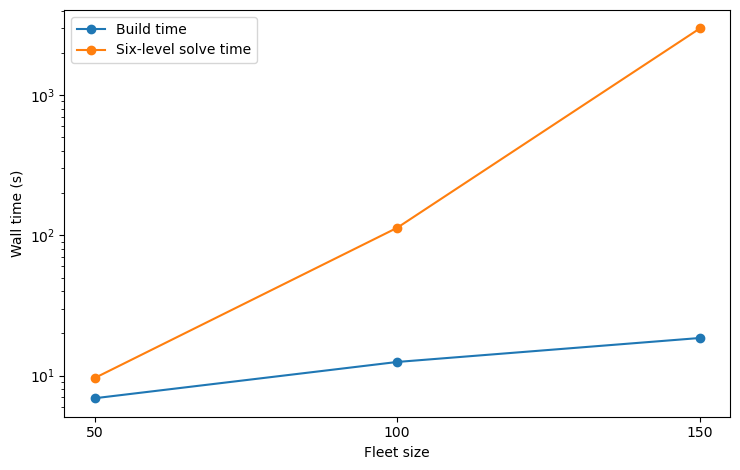

Cell 16 PASS — computational performance and scalability reconstructed entirely from the certified Cell-13 benchmark.


In [26]:
# ================================================================
# CELL 16 — COMPUTATIONAL PERFORMANCE AND SCALABILITY
# ================================================================

from IPython.display import display, Markdown
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


display(Markdown(r"""
## 16. Computational performance and scalability

Computational performance of the verified nested 50-, 100- and
150-aircraft recovery experiments.

All model-size and timing quantities are taken directly from the
authoritative Cell-13 benchmark. No model is rebuilt and no
optimisation is performed in this cell.
"""))


# =====================================================================
# Required Cell-13 handover
# =====================================================================

CASES = (50, 100, 150)

required = [
    "LEXICOGRAPHIC_RESULTS",
    "SCALABILITY_RESULTS",
]

missing = [name for name in required if name not in globals()]

if missing:
    raise RuntimeError(
        "Cell 16 missing required Cell-13 outputs: "
        + ", ".join(missing)
    )


lex = (
    LEXICOGRAPHIC_RESULTS
    .loc[LEXICOGRAPHIC_RESULTS["Case"].isin(CASES)]
    .sort_values(["Case", "Priority"])
    .reset_index(drop=True)
    .copy()
)

scale = (
    SCALABILITY_RESULTS
    .loc[SCALABILITY_RESULTS["Case"].isin(CASES)]
    .sort_values("Case")
    .reset_index(drop=True)
    .copy()
)


# =====================================================================
# Certification of benchmark record
# =====================================================================

if set(scale["Case"]) != set(CASES):
    raise RuntimeError(
        "Cell 16 requires completed 50-, 100- and 150-aircraft cases."
    )

if len(lex) != 6 * len(CASES):
    raise RuntimeError(
        "Cell 16 requires exactly six lexicographic levels per case."
    )

if not lex["Model status"].eq("OptimalGlobal").all():
    raise RuntimeError(
        "At least one Cell-13 lexicographic optimum is not globally proven."
    )

if not scale["Final status"].eq("OptimalGlobal").all():
    raise RuntimeError(
        "At least one Cell-13 final solution is not globally optimal."
    )

wall = pd.to_numeric(
    lex["Wall time (s)"],
    errors="coerce",
)

if (~np.isfinite(wall)).any() or (wall < 0).any():
    raise RuntimeError(
        "Invalid Cell-13 lexicographic wall-time record."
    )


# =====================================================================
# Model size and aggregate runtime
# =====================================================================

COMPUTATIONAL_PERFORMANCE = (
    scale[
        [
            "Case",
            "Flight-stage states",
            "Movement states",
            "Weather states",
            "Aircraft interactions",
            "Certified interactions",
            "Equations",
            "Variables",
            "Discrete variables",
            "Nonzeros",
            "Build time (s)",
            "Solve wall time (s)",
            "Total benchmark time (s)",
        ]
    ]
    .rename(
        columns={
            "Total benchmark time (s)": "Total runtime (s)"
        }
    )
    .copy()
)


# =====================================================================
# Six-level lexicographic timing
# =====================================================================

LEXICOGRAPHIC_TIMINGS = (
    lex[
        [
            "Case",
            "Priority",
            "Objective",
            "Optimum",
            "Wall time (s)",
            "Timing source",
        ]
    ]
    .copy()
)


LEVEL_WALL_TIMES = (
    LEXICOGRAPHIC_TIMINGS
    .pivot(
        index="Case",
        columns="Priority",
        values="Wall time (s)",
    )
    .rename(
        columns={
            1: "L1 affected (s)",
            2: "L2 Mach (s)",
            3: "L3 timing (s)",
            4: "L4 FL (s)",
            5: "L5 track (s)",
            6: "L6 structural (s)",
        }
    )
    .reset_index()
)


# =====================================================================
# Independent timing consistency
# =====================================================================

level_totals = (
    lex
    .groupby("Case", as_index=False)["Wall time (s)"]
    .sum()
    .rename(
        columns={
            "Wall time (s)": "Reconstructed solve time (s)"
        }
    )
)


TIMING_CONSISTENCY = (
    scale[
        [
            "Case",
            "Solve wall time (s)",
        ]
    ]
    .merge(
        level_totals,
        on="Case",
        validate="one_to_one",
    )
)


TIMING_CONSISTENCY["Difference (s)"] = (
    TIMING_CONSISTENCY["Solve wall time (s)"]
    - TIMING_CONSISTENCY["Reconstructed solve time (s)"]
)


if not np.allclose(
    TIMING_CONSISTENCY["Solve wall time (s)"],
    TIMING_CONSISTENCY["Reconstructed solve time (s)"],
    rtol=0,
    atol=1e-8,
):
    raise RuntimeError(
        "Cell-13 aggregate solve times do not equal the "
        "sum of the six preserved lexicographic wall times."
    )


# =====================================================================
# Scaling relative to the 50-aircraft case
# =====================================================================

ratio_cols = [
    "Equations",
    "Variables",
    "Discrete variables",
    "Nonzeros",
    "Build time (s)",
    "Solve wall time (s)",
    "Total benchmark time (s)",
]


base = (
    scale
    .loc[scale["Case"].eq(50), ratio_cols]
    .iloc[0]
)


SCALABILITY_RATIOS = scale[
    ["Case"] + ratio_cols
].copy()


SCALABILITY_RATIOS[ratio_cols] = (
    SCALABILITY_RATIOS[ratio_cols]
    .div(base)
)


SCALABILITY_RATIOS = (
    SCALABILITY_RATIOS
    .rename(
        columns={
            "Equations": "Equations ×50-case",
            "Variables": "Variables ×50-case",
            "Discrete variables": "Discrete ×50-case",
            "Nonzeros": "Nonzeros ×50-case",
            "Build time (s)": "Build time ×50-case",
            "Solve wall time (s)": "Solve time ×50-case",
            "Total benchmark time (s)": "Total runtime ×50-case",
        }
    )
)


# =====================================================================
# Publication-facing tables
# =====================================================================

PERFORMANCE_TABLE = COMPUTATIONAL_PERFORMANCE.copy()
LEVEL_TIMING_TABLE = LEVEL_WALL_TIMES.copy()
SCALING_TABLE = SCALABILITY_RATIOS.copy()


for col in [
    "Build time (s)",
    "Solve wall time (s)",
    "Total runtime (s)",
]:
    PERFORMANCE_TABLE[col] = (
        PERFORMANCE_TABLE[col]
        .astype(float)
        .round(2)
    )


LEVEL_TIMING_TABLE.iloc[:, 1:] = (
    LEVEL_TIMING_TABLE.iloc[:, 1:]
    .astype(float)
    .round(2)
)


SCALING_TABLE.iloc[:, 1:] = (
    SCALING_TABLE.iloc[:, 1:]
    .astype(float)
    .round(2)
)


display(Markdown("### Model size and aggregate runtime"))
display(PERFORMANCE_TABLE)

display(Markdown("### Six-level lexicographic wall times"))
display(LEVEL_TIMING_TABLE)

display(Markdown("### Scaling relative to the 50-aircraft case"))
display(SCALING_TABLE)


# =====================================================================
# Publication-quality scalability figure
# =====================================================================

fig, ax = plt.subplots(figsize=(7.5, 4.8))

ax.plot(
    COMPUTATIONAL_PERFORMANCE["Case"],
    COMPUTATIONAL_PERFORMANCE["Build time (s)"],
    marker="o",
    label="Build time",
)

ax.plot(
    COMPUTATIONAL_PERFORMANCE["Case"],
    COMPUTATIONAL_PERFORMANCE["Solve wall time (s)"],
    marker="o",
    label="Six-level solve time",
)

ax.set_xlabel("Fleet size")
ax.set_ylabel("Wall time (s)")
ax.set_xticks(CASES)
ax.set_yscale("log")
ax.legend()

fig.tight_layout()

SCALABILITY_FIGURE = fig

plt.show()


# =====================================================================
# Final certification
# =====================================================================

print(
    "Cell 16 PASS — computational performance and scalability "
    "reconstructed entirely from the certified Cell-13 benchmark."
)

In [27]:
# ================================================================
# CELL 17 — FLIGHT-LEVEL RECOVERED PROFILES AND CONSEQUENCES
# ================================================================

from IPython.display import display, Markdown
import numpy as np
import pandas as pd


display(Markdown(r"""
## 17. Flight-level recovered profiles and operational consequences

This cell moves from fleet-level results to the individual aircraft
requiring intervention in the verified 50-, 100- and 150-aircraft
recovery cases.

For each affected flight, the recovered track, FL, Mach and timing
profile is compared with the remaining baseline. Structural deviation,
return to baseline, travelled-distance change and timing consequences
are reconstructed directly from the independently verified Cell-14
solution.

No optimisation is performed in this cell.
"""))


# =====================================================================
# Required verified handover
# =====================================================================

CASES = (50, 100, 150)

required = [
    "VERIFIED_STAGE_SOLUTIONS",
    "VERIFIED_FLIGHT_SOLUTIONS",
    "INDEPENDENT_VERIFICATION",
    "S_i",
    "BAR_T",
    "BAR_ELL",
    "ELL",
    "POPULATION_LOOKUP",
]

missing = [name for name in required if name not in globals()]

if missing:
    raise RuntimeError(
        "Cell 17 missing required verified inputs: "
        + ", ".join(missing)
    )

if not INDEPENDENT_VERIFICATION["Overall"].eq("PASS").all():
    raise RuntimeError(
        "Cell 17 requires independently verified Cell-14 solutions."
    )


# =====================================================================
# Helper
# =====================================================================

def profile_string(values, decimals=None):
    """Compact ordered profile representation."""
    if decimals is None:
        return " → ".join(str(value) for value in values)

    return " → ".join(
        f"{float(value):.{decimals}f}"
        for value in values
    )


# =====================================================================
# Reconstruct affected-flight consequences
# =====================================================================

rows = []

for case_n in CASES:

    stages = (
        VERIFIED_STAGE_SOLUTIONS[case_n]
        .copy()
        .sort_values(["flight_id", "stage"])
        .reset_index(drop=True)
    )

    flights = VERIFIED_FLIGHT_SOLUTIONS[case_n].copy()

    stages["flight_id"] = stages["flight_id"].astype(str)
    flights["flight_id"] = flights["flight_id"].astype(str)

    affected = flights.loc[
        flights["affected"].astype(bool)
    ].copy()

    for flight in affected.itertuples(index=False):

        flight_id = str(flight.flight_id)

        profile = (
            stages.loc[
                stages["flight_id"].eq(flight_id)
            ]
            .sort_values("stage")
            .reset_index(drop=True)
        )

        if profile.empty:
            raise RuntimeError(
                f"Case {case_n}: verified profile missing "
                f"for affected flight {flight_id}."
            )

        expected_stages = list(S_i[flight_id])

        if profile["stage"].tolist() != expected_stages:
            raise RuntimeError(
                f"Case {case_n}: stage sequence mismatch "
                f"for flight {flight_id}."
            )

        # -------------------------------------------------------------
        # Baseline and recovered profiles
        # -------------------------------------------------------------

        baseline_track = (
            profile["baseline_track"]
            .astype(str)
            .tolist()
        )

        recovered_track = (
            profile["track"]
            .astype(str)
            .tolist()
        )

        baseline_fl = (
            profile["baseline_fl"]
            .astype(float)
            .tolist()
        )

        recovered_fl = (
            profile["fl"]
            .astype(float)
            .tolist()
        )

        baseline_mach = (
            profile["baseline_mach"]
            .astype(float)
            .tolist()
        )

        recovered_mach = (
            profile["mach"]
            .astype(float)
            .tolist()
        )

        baseline_times = [
            float(BAR_T[(flight_id, stage)])
            for stage in expected_stages
        ]

        recovered_times = (
            profile["time_min"]
            .astype(float)
            .tolist()
        )

        # -------------------------------------------------------------
        # Structural deviation and return
        # -------------------------------------------------------------

        deviation_mask = (
            profile["structural"]
            .astype(bool)
            .to_numpy()
        )

        deviation_indices = np.flatnonzero(
            deviation_mask
        )

        if len(deviation_indices):

            first_idx = int(deviation_indices[0])
            last_idx = int(deviation_indices[-1])

            first_deviation = int(
                profile.iloc[first_idx]["stage"]
            )

            last_deviation = int(
                profile.iloc[last_idx]["stage"]
            )

            return_candidates = np.flatnonzero(
                (~deviation_mask)
                & (
                    np.arange(len(profile))
                    > first_idx
                )
            )

            returned_to_baseline = (
                len(return_candidates) > 0
            )

            return_stage = (
                int(
                    profile.iloc[
                        int(return_candidates[0])
                    ]["stage"]
                )
                if returned_to_baseline
                else np.nan
            )

        else:
            # Timing-only intervention:
            # structural baseline retained throughout.
            first_deviation = np.nan
            last_deviation = np.nan
            returned_to_baseline = True
            return_stage = np.nan

        # -------------------------------------------------------------
        # Distance consequences
        # -------------------------------------------------------------

        baseline_distance = sum(
            float(BAR_ELL[(flight_id, stage)])
            for stage in expected_stages[:-1]
        )

        recovered_distance = 0.0

        for current, following in zip(
            profile.iloc[:-1].itertuples(index=False),
            profile.iloc[1:].itertuples(index=False),
        ):

            key = (
                flight_id,
                int(current.stage),
                str(current.track),
                str(following.track),
            )

            if key not in ELL:
                raise RuntimeError(
                    f"Case {case_n}: recovered movement distance "
                    f"missing for {flight_id}, stage {current.stage}, "
                    f"{current.track}->{following.track}."
                )

            recovered_distance += float(ELL[key])

        distance_change = (
            recovered_distance
            - baseline_distance
        )

        # -------------------------------------------------------------
        # Timing consequences
        # -------------------------------------------------------------

        entry_adjustment = (
            recovered_times[0]
            - baseline_times[0]
        )

        exit_displacement = (
            recovered_times[-1]
            - baseline_times[-1]
        )

        baseline_duration = (
            baseline_times[-1]
            - baseline_times[0]
        )

        recovered_duration = (
            recovered_times[-1]
            - recovered_times[0]
        )

        duration_change = (
            recovered_duration
            - baseline_duration
        )

        # -------------------------------------------------------------
        # One definitive row per affected flight
        # -------------------------------------------------------------

        rows.append({
            "Case":
                case_n,

            "Flight":
                flight_id,

            "Population":
                POPULATION_LOOKUP[flight_id],

            "Baseline track":
                profile_string(baseline_track),

            "Recovered track":
                profile_string(recovered_track),

            "Track change":
                bool(flight.track),

            "Baseline FL":
                profile_string(baseline_fl, 0),

            "Recovered FL":
                profile_string(recovered_fl, 0),

            "FL change":
                bool(flight.fl),

            "Baseline Mach":
                profile_string(baseline_mach, 2),

            "Recovered Mach":
                profile_string(recovered_mach, 2),

            "Mach change":
                bool(flight.mach),

            "Entry-time adjustment (min)":
                entry_adjustment,

            "Timing intervention":
                bool(flight.timing),

            "First deviation stage":
                first_deviation,

            "Last deviation stage":
                last_deviation,

            "Deviated stages":
                int(deviation_mask.sum()),

            "Return to baseline":
                (
                    "Yes"
                    if returned_to_baseline
                    else "No"
                ),

            "Return stage":
                return_stage,

            "Baseline distance (NM)":
                baseline_distance,

            "Recovered distance (NM)":
                recovered_distance,

            "Distance change (NM)":
                distance_change,

            "Exit-time displacement (min)":
                exit_displacement,

            "Duration change (min)":
                duration_change,
        })


# =====================================================================
# Definitive flight-level output
# =====================================================================

FLIGHT_LEVEL_RECOVERY = (
    pd.DataFrame(rows)
    .sort_values(
        ["Case", "Population", "Flight"]
    )
    .reset_index(drop=True)
)


# =====================================================================
# Cross-cell consistency certification
# =====================================================================

for case_n in CASES:

    expected = (
        VERIFIED_FLIGHT_SOLUTIONS[case_n]
        .copy()
    )

    expected["flight_id"] = (
        expected["flight_id"].astype(str)
    )

    expected = expected.loc[
        expected["affected"].astype(bool)
    ].copy()

    observed = FLIGHT_LEVEL_RECOVERY.loc[
        FLIGHT_LEVEL_RECOVERY["Case"].eq(case_n)
    ].copy()

    if len(observed) != len(expected):
        raise RuntimeError(
            f"Case {case_n}: affected-flight count mismatch."
        )

    if set(observed["Flight"]) != set(
        expected["flight_id"]
    ):
        raise RuntimeError(
            f"Case {case_n}: affected-flight identity mismatch."
        )

    expected_flags = (
        expected[
            [
                "flight_id",
                "track",
                "fl",
                "timing",
                "mach",
                "structural_states",
            ]
        ]
        .rename(
            columns={
                "flight_id": "Flight",
                "track": "Track change",
                "fl": "FL change",
                "timing": "Timing intervention",
                "mach": "Mach change",
                "structural_states": "Deviated stages",
            }
        )
    )

    comparison = observed[
        [
            "Flight",
            "Track change",
            "FL change",
            "Timing intervention",
            "Mach change",
            "Deviated stages",
        ]
    ].merge(
        expected_flags,
        on="Flight",
        suffixes=("_17", "_14"),
        validate="one_to_one",
    )

    for column in [
        "Track change",
        "FL change",
        "Timing intervention",
        "Mach change",
        "Deviated stages",
    ]:

        if not (
            comparison[f"{column}_17"]
            ==
            comparison[f"{column}_14"]
        ).all():
            raise RuntimeError(
                f"Case {case_n}: {column} does not "
                "match Cell-14 verification."
            )


# =====================================================================
# Publication-facing formatting
# =====================================================================

numeric_cols = [
    "Entry-time adjustment (min)",
    "Baseline distance (NM)",
    "Recovered distance (NM)",
    "Distance change (NM)",
    "Exit-time displacement (min)",
    "Duration change (min)",
]

FLIGHT_LEVEL_RECOVERY[numeric_cols] = (
    FLIGHT_LEVEL_RECOVERY[numeric_cols]
    .astype(float)
    .round(2)
)


display(
    Markdown(
        "### Affected-flight recovered profiles and consequences"
    )
)

display(
    FLIGHT_LEVEL_RECOVERY
)


# =====================================================================
# Final certification
# =====================================================================

print(
    "Cell 17 PASS — every affected aircraft has one verified "
    "flight-level recovery record with profile, structural, "
    "distance and timing consequences."
)


## 17. Flight-level recovered profiles and operational consequences

This cell moves from fleet-level results to the individual aircraft
requiring intervention in the verified 50-, 100- and 150-aircraft
recovery cases.

For each affected flight, the recovered track, FL, Mach and timing
profile is compared with the remaining baseline. Structural deviation,
return to baseline, travelled-distance change and timing consequences
are reconstructed directly from the independently verified Cell-14
solution.

No optimisation is performed in this cell.


### Affected-flight recovered profiles and consequences

,Case,Flight,Population,Baseline track,Recovered track,Track change,Baseline FL,Recovered FL,FL change,Baseline Mach,...,First deviation stage,Last deviation stage,Deviated stages,Return to baseline,Return stage,Baseline distance (NM),Recovered distance (NM),Distance change (NM),Exit-time displacement (min),Duration change (min)
0,50,EXG00158,existing,F → F → F → F → F,F → G → G → G → F,True,370 → 370 → 370 → 370 → 370,370 → 370 → 370 → 370 → 370,False,0.84 → 0.84 → 0.84 → 0.84 → 0.84,...,2,4,3,Yes,5,1104.16,1117.06,12.90,1.60,1.60
1,50,EXG00383,existing,E → E → E → E → E,E → F → F → F → E,True,390 → 390 → 390 → 390 → 390,390 → 390 → 390 → 390 → 390,False,0.82 → 0.82 → 0.82 → 0.82 → 0.82,...,2,4,3,Yes,5,1197.65,1264.34,66.69,8.81,8.81
2,100,EXG00037,existing,D → D → D → D → D,D → C → C → C → D,True,350 → 350 → 350 → 350 → 350,350 → 350 → 350 → 350 → 350,False,0.84 → 0.84 → 0.84 → 0.84 → 0.84,...,2,4,3,Yes,5,1072.81,1133.26,60.45,7.06,7.06
3,100,EXG00119,existing,G → G → G → G → G,G → G → G → G → G,False,390 → 390 → 390 → 390 → 390,390 → 340 → 390 → 390 → 390,True,0.83 → 0.83 → 0.83 → 0.83 → 0.83,...,2,2,1,Yes,3,1042.73,1042.73,0.00,-0.00,-0.00
4,100,EXG00158,existing,F → F → F → F → F,F → G → G → G → F,True,370 → 370 → 370 → 370 → 370,370 → 370 → 370 → 370 → 370,False,0.84 → 0.84 → 0.84 → 0.84 → 0.84,...,2,4,3,Yes,5,1104.16,1117.06,12.90,1.60,1.60
5,100,EXG00383,existing,E → E → E → E → E,E → F → F → F → E,True,390 → 390 → 390 → 390 → 390,390 → 390 → 390 → 390 → 390,False,0.82 → 0.82 → 0.82 → 0.82 → 0.82,...,2,4,3,Yes,5,1197.65,1264.34,66.69,8.81,8.81
6,100,REQ00281,requested,A → A → A → A → A,A → B → B → B → A,True,340 → 340 → 340 → 340 → 340,340 → 340 → 340 → 340 → 340,False,0.83 → 0.83 → 0.83 → 0.83 → 0.83,...,2,4,3,Yes,5,1057.92,1081.26,23.34,2.94,2.94
7,100,REQ00844,requested,RANDOM_ROUTE → RANDOM_ROUTE → RANDOM_ROUTE → R...,RANDOM_ROUTE → RANDOM_ROUTE → RANDOM_ROUTE → R...,True,350 → 350 → 350 → 330 → 330 → 330 → 330 → 330,350 → 350 → 350 → 330 → 330 → 340 → 340 → 330,True,0.83 → 0.83 → 0.83 → 0.83 → 0.83 → 0.83 → 0.83...,...,6,7,2,Yes,8,2172.48,2156.69,-15.79,-2.08,-2.08
8,100,REQ00917,requested,D → D → D,D → D → D,False,340 → 340 → 340,350 → 350 → 340,True,0.82 → 0.82 → 0.82,...,1,2,2,Yes,3,682.61,682.61,0.00,0.00,0.00
9,150,EXG00037,existing,D → D → D → D → D,D → C → C → C → D,True,350 → 350 → 350 → 350 → 350,350 → 350 → 350 → 350 → 350,False,0.84 → 0.84 → 0.84 → 0.84 → 0.84,...,2,4,3,Yes,5,1072.81,1133.26,60.45,7.06,7.06


Cell 17 PASS — every affected aircraft has one verified flight-level recovery record with profile, structural, distance and timing consequences.


In [28]:
# ================================================================
# CELL 18 — CONTROLLER-FACING EXPLAINABLE RECOMMENDATIONS
# ================================================================

from IPython.display import display, Markdown
import numpy as np
import pandas as pd


display(Markdown(r"""
## 18. Controller-facing explainable recovery recommendations

The verified recovery solution is translated into concise operational
instructions for each affected aircraft.

Recommendations are ranked by the earliest required action and identify
the recovery lever(s), action stage/location, intervention duration,
return point and principal operational consequences.

A specific weather reason is reported only where independently supported
by the baseline diagnostic. Otherwise the intervention is attributed to
the integrated fleet-feasibility requirements rather than to an
unsupported single cause.

No optimisation or new recovery decision is introduced in this cell.
"""))


# =====================================================================
# Required verified handover
# =====================================================================

CASES = (50, 100, 150)

required = [
    "FLIGHT_LEVEL_RECOVERY",
    "VERIFIED_STAGE_SOLUTIONS",
    "INDEPENDENT_VERIFICATION",
    "BASELINE_STAGES",
    "WEATHER_DIAGNOSIS",
]

missing = [name for name in required if name not in globals()]

if missing:
    raise RuntimeError(
        "Cell 18 missing required inputs: "
        + ", ".join(missing)
    )

if not INDEPENDENT_VERIFICATION["Overall"].eq("PASS").all():
    raise RuntimeError(
        "Cell 18 requires independently verified Cell-14 solutions."
    )


# =====================================================================
# Operational location and weather-evidence lookups
# =====================================================================

locations = BASELINE_STAGES[
    ["flight_id", "stage", "waypoint"]
].copy()

locations["flight_id"] = locations["flight_id"].astype(str)

LOCATION_LOOKUP = {
    (str(row.flight_id), int(row.stage)): str(row.waypoint)
    for row in locations.itertuples(index=False)
}


weather = WEATHER_DIAGNOSIS.copy()
weather["flight_id"] = weather["flight_id"].astype(str)

WEATHER_LOOKUP = (
    weather
    .drop_duplicates("flight_id")
    .set_index("flight_id")
)


# =====================================================================
# Helpers
# =====================================================================

def stage_label(flight_id, stage):
    """Compact stage/location label."""
    if pd.isna(stage):
        return "oceanic entry"

    stage = int(stage)
    waypoint = LOCATION_LOOKUP.get((flight_id, stage))

    return (
        f"stage {stage} ({waypoint})"
        if waypoint
        else f"stage {stage}"
    )


def signed(value, unit):
    """Compact signed consequence."""
    value = float(value)

    if abs(value) < 0.005:
        value = 0.0

    return f"{value:+.2f} {unit}"


def first_change(profile, flag, baseline_col, recovered_col):
    """First verified stage at which one recovery lever changes."""
    changed = profile.loc[profile[flag].astype(bool)]

    if changed.empty:
        return None

    row = changed.iloc[0]

    return {
        "stage": int(row["stage"]),
        "time": float(row["time_min"]),
        "baseline": row[baseline_col],
        "recovered": row[recovered_col],
    }


def evidence_reason(flight_id):
    """
    Strongest independently supported intervention explanation.

    Weather is identified specifically only where the baseline diagnostic
    records prohibited robust exposure. Otherwise no unique cause is claimed.
    """
    if flight_id not in WEATHER_LOOKUP.index:
        return (
            "Integrated fleet-feasibility requirements; "
            "no unique single cause established."
        )

    row = WEATHER_LOOKUP.loc[flight_id]

    if not bool(row.get("robust_prohibited", False)):
        return (
            "Integrated fleet-feasibility requirements; "
            "no unique single cause established."
        )

    reason = "Baseline profile intersects prohibited weather"

    cells = str(row.get("weather_cells", "")).strip()
    if cells and cells.lower() != "nan":
        reason += f" ({cells})"

    severity = row.get("max_prohibited_severity", np.nan)
    if pd.notna(severity):
        reason += f"; maximum severity {float(severity):.2f}"

    return reason + "."


# =====================================================================
# Construct recommendations
# =====================================================================

rows = []

for case_n in CASES:

    flight_results = FLIGHT_LEVEL_RECOVERY.loc[
        FLIGHT_LEVEL_RECOVERY["Case"].eq(case_n)
    ].copy()

    stages = (
        VERIFIED_STAGE_SOLUTIONS[case_n]
        .copy()
        .sort_values(["flight_id", "stage"])
    )

    stages["flight_id"] = stages["flight_id"].astype(str)

    for _, result in flight_results.iterrows():

        flight_id = str(result["Flight"])

        profile = (
            stages.loc[
                stages["flight_id"].eq(flight_id)
            ]
            .sort_values("stage")
            .reset_index(drop=True)
        )

        if profile.empty:
            raise RuntimeError(
                f"Case {case_n}: verified profile missing "
                f"for {flight_id}."
            )

        # -------------------------------------------------------------
        # First use of each recovery lever
        # -------------------------------------------------------------

        track_action = first_change(
            profile,
            "deltaR",
            "baseline_track",
            "track",
        )

        fl_action = first_change(
            profile,
            "deltaH",
            "baseline_fl",
            "fl",
        )

        mach_action = first_change(
            profile,
            "deltaM",
            "baseline_mach",
            "mach",
        )

        timing_used = bool(result["Timing intervention"])
        entry_adjustment = float(
            result["Entry-time adjustment (min)"]
        )

        # -------------------------------------------------------------
        # Ordered operational actions
        # -------------------------------------------------------------

        actions = []

        if timing_used:
            actions.append((
                float(profile.iloc[0]["time_min"]),
                int(profile.iloc[0]["stage"]),
                (
                    f"adjust oceanic entry by "
                    f"{signed(entry_adjustment, 'min')}"
                ),
            ))

        if track_action is not None:
            actions.append((
                track_action["time"],
                track_action["stage"],
                (
                    f"reroute {track_action['baseline']}"
                    f"→{track_action['recovered']} at "
                    f"{stage_label(flight_id, track_action['stage'])}"
                ),
            ))

        if fl_action is not None:
            actions.append((
                fl_action["time"],
                fl_action["stage"],
                (
                    f"change FL "
                    f"{float(fl_action['baseline']):.0f}"
                    f"→{float(fl_action['recovered']):.0f} at "
                    f"{stage_label(flight_id, fl_action['stage'])}"
                ),
            ))

        if mach_action is not None:
            actions.append((
                mach_action["time"],
                mach_action["stage"],
                (
                    f"adjust Mach "
                    f"{float(mach_action['baseline']):.2f}"
                    f"→{float(mach_action['recovered']):.2f} at "
                    f"{stage_label(flight_id, mach_action['stage'])}"
                ),
            ))

        if not actions:
            raise RuntimeError(
                f"Case {case_n}: affected flight {flight_id} "
                "has no identifiable recovery action."
            )

        actions.sort(key=lambda x: (x[0], x[1]))

        first_action_time = float(actions[0][0])
        first_action_stage = int(actions[0][1])

        action_text = "; ".join(
            action[2] for action in actions
        )

        # -------------------------------------------------------------
        # Structural span and return
        # -------------------------------------------------------------

        structural = (
            profile["structural"]
            .astype(bool)
            .to_numpy()
        )

        deviation_idx = np.flatnonzero(structural)

        if len(deviation_idx):

            first_idx = int(deviation_idx[0])
            first_deviation_time = float(
                profile.iloc[first_idx]["time_min"]
            )

            return_stage = result["Return stage"]

            if pd.notna(return_stage):

                return_stage = int(return_stage)

                return_row = profile.loc[
                    profile["stage"].eq(return_stage)
                ]

                if return_row.empty:
                    raise RuntimeError(
                        f"Case {case_n}: return stage {return_stage} "
                        f"missing for {flight_id}."
                    )

                return_time = float(
                    return_row.iloc[0]["time_min"]
                )

                duration = (
                    return_time
                    - first_deviation_time
                )

                return_point = stage_label(
                    flight_id,
                    return_stage,
                )

            else:

                duration = (
                    float(profile.iloc[-1]["time_min"])
                    - first_deviation_time
                )

                return_point = (
                    "no structural return within recovery horizon"
                )

        else:
            # Timing-only intervention.
            duration = 0.0
            return_point = (
                "structural baseline retained throughout"
            )

        # -------------------------------------------------------------
        # Operational consequences
        # -------------------------------------------------------------

        distance_effect = float(
            result["Distance change (NM)"]
        )

        exit_effect = float(
            result["Exit-time displacement (min)"]
        )

        reason = evidence_reason(flight_id)

        controller_text = (
            f"{flight_id}: {action_text}. "
            f"Return: {return_point}. "
            f"Consequence: {signed(distance_effect, 'NM')}; "
            f"{signed(exit_effect, 'min')} at exit."
        )

        rows.append({
            "Case":
                case_n,

            "Flight":
                flight_id,

            "Population":
                result["Population"],

            "First action":
                stage_label(
                    flight_id,
                    first_action_stage,
                ),

            "Recommended action":
                action_text,

            "Reason":
                reason,

            "Intervention duration (min)":
                duration,

            "Return point":
                return_point,

            "Distance consequence (NM)":
                distance_effect,

            "Exit-time consequence (min)":
                exit_effect,

            "Controller recommendation":
                controller_text,

            # Internal ranking field; not displayed.
            "_first_action_time":
                first_action_time,
        })


# =====================================================================
# Rank by earliest required action
# =====================================================================

CONTROLLER_RECOMMENDATIONS = (
    pd.DataFrame(rows)
    .sort_values(
        [
            "Case",
            "_first_action_time",
            "Flight",
        ]
    )
    .reset_index(drop=True)
)


CONTROLLER_RECOMMENDATIONS["Rank"] = (
    CONTROLLER_RECOMMENDATIONS
    .groupby("Case")
    .cumcount()
    + 1
)


CONTROLLER_RECOMMENDATIONS = (
    CONTROLLER_RECOMMENDATIONS[
        [
            "Case",
            "Rank",
            "Flight",
            "Population",
            "First action",
            "Recommended action",
            "Reason",
            "Intervention duration (min)",
            "Return point",
            "Distance consequence (NM)",
            "Exit-time consequence (min)",
            "Controller recommendation",
            "_first_action_time",
        ]
    ]
)


# =====================================================================
# Cross-cell certification
# =====================================================================

for case_n in CASES:

    expected = set(
        FLIGHT_LEVEL_RECOVERY.loc[
            FLIGHT_LEVEL_RECOVERY["Case"].eq(case_n),
            "Flight",
        ].astype(str)
    )

    observed = set(
        CONTROLLER_RECOMMENDATIONS.loc[
            CONTROLLER_RECOMMENDATIONS["Case"].eq(case_n),
            "Flight",
        ].astype(str)
    )

    if observed != expected:
        raise RuntimeError(
            f"Case {case_n}: recommendation set does not "
            "match Cell-17 affected flights."
        )

    ranks = CONTROLLER_RECOMMENDATIONS.loc[
        CONTROLLER_RECOMMENDATIONS["Case"].eq(case_n),
        "Rank",
    ].tolist()

    if ranks != list(range(1, len(ranks) + 1)):
        raise RuntimeError(
            f"Case {case_n}: recommendation ranking failed."
        )


# =====================================================================
# Publication-facing formatting
# =====================================================================

for col in [
    "Intervention duration (min)",
    "Distance consequence (NM)",
    "Exit-time consequence (min)",
]:
    CONTROLLER_RECOMMENDATIONS[col] = (
        pd.to_numeric(
            CONTROLLER_RECOMMENDATIONS[col],
            errors="coerce",
        )
        .round(2)
    )


CONTROLLER_RECOMMENDATION_TABLE = (
    CONTROLLER_RECOMMENDATIONS.drop(
        columns="_first_action_time"
    )
)


display(
    Markdown(
        "### Ranked controller-facing recovery recommendations"
    )
)

display(
    CONTROLLER_RECOMMENDATION_TABLE
)


# =====================================================================
# Final certification
# =====================================================================

print(
    "Cell 18 PASS — every affected aircraft has one ranked, "
    "verified and evidence-qualified controller-facing recommendation."
)


## 18. Controller-facing explainable recovery recommendations

The verified recovery solution is translated into concise operational
instructions for each affected aircraft.

Recommendations are ranked by the earliest required action and identify
the recovery lever(s), action stage/location, intervention duration,
return point and principal operational consequences.

A specific weather reason is reported only where independently supported
by the baseline diagnostic. Otherwise the intervention is attributed to
the integrated fleet-feasibility requirements rather than to an
unsupported single cause.

No optimisation or new recovery decision is introduced in this cell.


### Ranked controller-facing recovery recommendations

,Case,Rank,Flight,Population,First action,Recommended action,Reason,Intervention duration (min),Return point,Distance consequence (NM),Exit-time consequence (min),Controller recommendation
0,50,1,EXG00158,existing,stage 2 (53N030W),reroute F→G at stage 2 (53N030W),Baseline profile intersects prohibited weather...,109.02,stage 5 (JANJO),12.90,1.60,EXG00158: reroute F→G at stage 2 (53N030W). Re...
1,50,2,EXG00383,existing,stage 2 (54N030W),reroute E→F at stage 2 (54N030W),Baseline profile intersects prohibited weather...,115.76,stage 5 (TUDEP),66.69,8.81,EXG00383: reroute E→F at stage 2 (54N030W). Re...
2,100,1,EXG00119,existing,stage 2 (52N030W),change FL 390→340 at stage 2 (52N030W),Baseline profile intersects prohibited weather...,47.34,stage 3 (52N040W),0.00,-0.00,EXG00119: change FL 390→340 at stage 2 (52N030...
3,100,2,EXG00158,existing,stage 2 (53N030W),reroute F→G at stage 2 (53N030W),Baseline profile intersects prohibited weather...,109.02,stage 5 (JANJO),12.90,1.60,EXG00158: reroute F→G at stage 2 (53N030W). Re...
4,100,3,REQ00917,requested,stage 1 (55N020W),change FL 340→350 at stage 1 (55N020W),Integrated fleet-feasibility requirements; no ...,88.30,stage 3 (55N040W),0.00,0.00,REQ00917: change FL 340→350 at stage 1 (55N020...
5,100,4,EXG00037,existing,stage 2 (55N030W),reroute D→C at stage 2 (55N030W),Baseline profile intersects prohibited weather...,102.12,stage 5 (RIKAL),60.45,7.06,EXG00037: reroute D→C at stage 2 (55N030W). Re...
6,100,5,REQ00281,requested,stage 2 (58N030W),reroute A→B at stage 2 (58N030W),Integrated fleet-feasibility requirements; no ...,95.29,stage 5 (CUDDY),23.34,2.94,REQ00281: reroute A→B at stage 2 (58N030W). Re...
7,100,6,EXG00383,existing,stage 2 (54N030W),reroute E→F at stage 2 (54N030W),Baseline profile intersects prohibited weather...,115.76,stage 5 (TUDEP),66.69,8.81,EXG00383: reroute E→F at stage 2 (54N030W). Re...
8,100,7,REQ00844,requested,stage 6 (54N045W),reroute RANDOM_ROUTE→D at stage 6 (54N045W); c...,Integrated fleet-feasibility requirements; no ...,108.13,stage 8 (47N064W),-15.79,-2.08,REQ00844: reroute RANDOM_ROUTE→D at stage 6 (5...
9,150,1,EXG00119,existing,stage 2 (52N030W),change FL 390→340 at stage 2 (52N030W),Baseline profile intersects prohibited weather...,47.34,stage 3 (52N040W),0.00,-0.00,EXG00119: change FL 390→340 at stage 2 (52N030...


Cell 18 PASS — every affected aircraft has one ranked, verified and evidence-qualified controller-facing recommendation.



## 19. Representative recovery case studies

Three representative flights from the verified 150-aircraft solution are
used to illustrate the behaviour of the integrated recovery model:

- a **track intervention**;
- a **pure flight-level intervention**; and
- an **unchanged baseline-retained comparator**.

For each flight, the upper panel shows the **actual baseline and recovered
horizontal geometry**, together with the weather checkpoints relevant to
the recovered state. The lower panel shows the corresponding
**baseline and recovered flight-level profile by stage**.

No optimisation is performed in this cell. All displayed decisions are
taken directly from the verified solution produced by the preceding cells.


### Selected representative flights

,Case study,Flight
0,Track intervention,EXG00470
1,FL intervention,REQ00266
2,Unchanged comparator,REQ00937


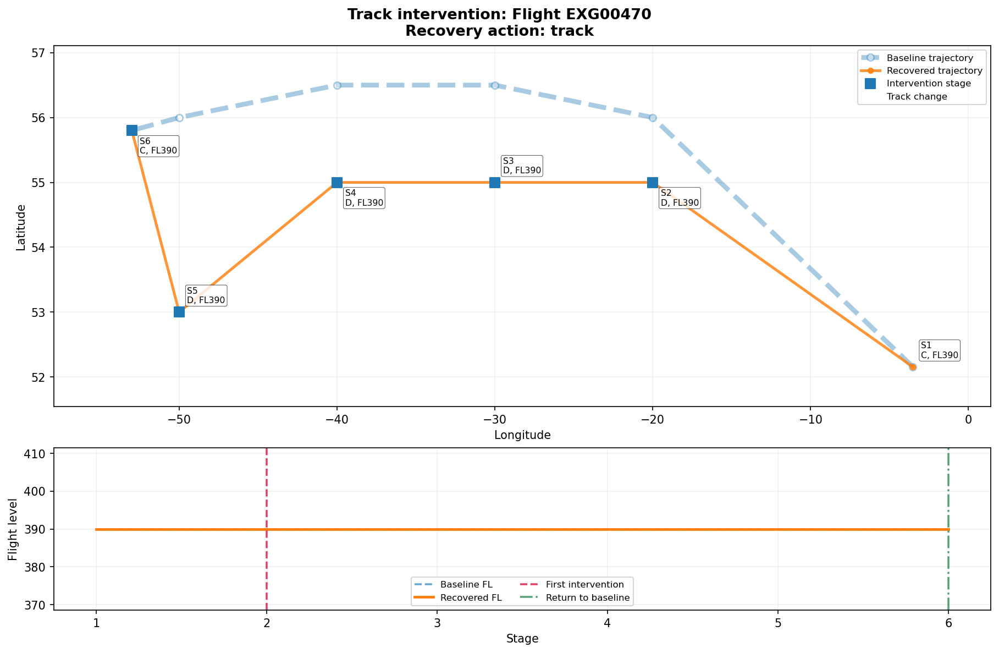

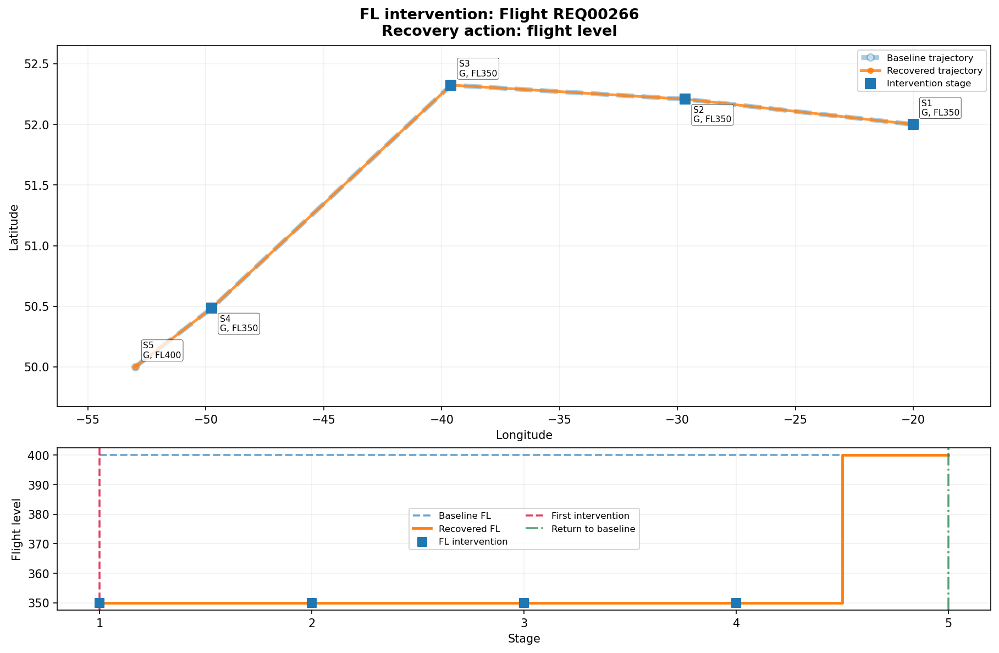

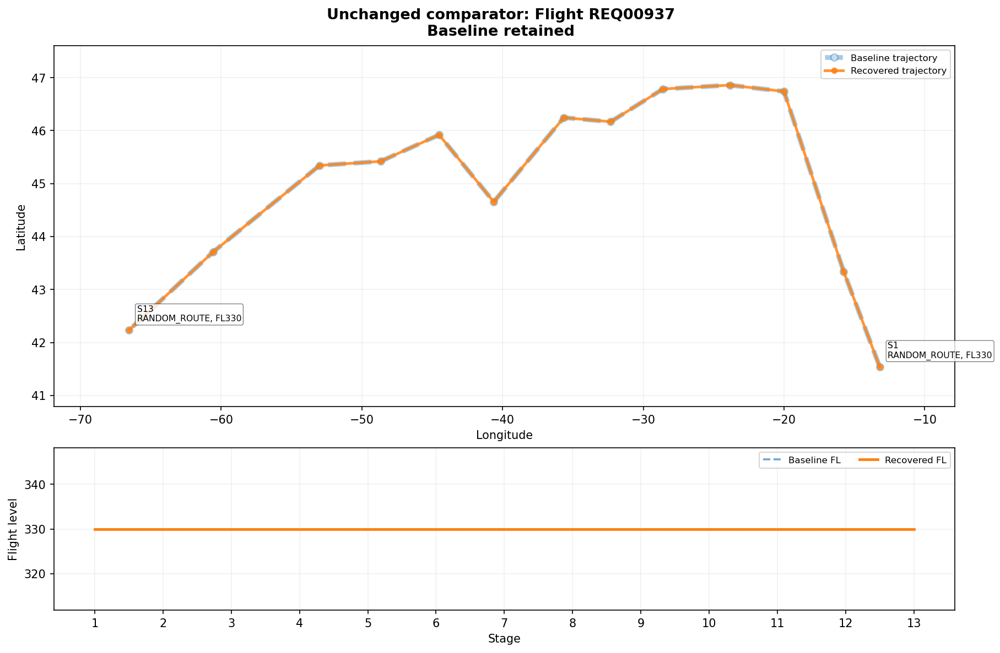

### Selected-flight prohibited-weather context

,Case study,Flight,Relevant prohibited checkpoints,Weather cells
0,Track intervention,EXG00470,0,
1,FL intervention,REQ00266,0,
2,Unchanged comparator,REQ00937,0,


### Representative recovery case-study summary

,Case study,Flight,Population,Track change,FL change,Mach change,Timing intervention,Deviated stages,Return stage,Distance change (NM),Exit-time displacement (min)
0,Track intervention,EXG00470,existing,True,False,False,False,4,6.0,143.98,16.59
1,FL intervention,REQ00266,requested,False,True,False,False,4,5.0,0.00,-0.00
2,Unchanged comparator,REQ00937,requested,False,False,False,False,0,NaN,0.00,0.00



Cell 19 PASS — representative track, FL and unchanged cases visualised using verified recovered geometry, separate horizontal and flight-level panels, intervention stages and relevant prohibited-weather context.


In [47]:
# =====================================================================
# CELL 19 — REPRESENTATIVE RECOVERY CASE STUDIES
# Clean operational visualisation of verified recovery decisions
# =====================================================================

from IPython.display import display, Markdown
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# =====================================================================
# 1. Introduction
# =====================================================================

display(Markdown(r"""
## 19. Representative recovery case studies

Three representative flights from the verified 150-aircraft solution are
used to illustrate the behaviour of the integrated recovery model:

- a **track intervention**;
- a **pure flight-level intervention**; and
- an **unchanged baseline-retained comparator**.

For each flight, the upper panel shows the **actual baseline and recovered
horizontal geometry**, together with the weather checkpoints relevant to
the recovered state. The lower panel shows the corresponding
**baseline and recovered flight-level profile by stage**.

No optimisation is performed in this cell. All displayed decisions are
taken directly from the verified solution produced by the preceding cells.
"""))


# =====================================================================
# 2. Required verified handover
# =====================================================================

CASE = 150

required = [
    "VERIFIED_STAGE_SOLUTIONS",
    "VERIFIED_FLIGHT_SOLUTIONS",
    "FLIGHT_LEVEL_RECOVERY",
    "BASELINE_STAGES",
    "BASELINE_POINT",
    "OTS_STAGE_POINT",
    "WX_POINT_WINDOWS",
]

missing = [name for name in required if name not in globals()]

if missing:
    raise RuntimeError(
        "Cell 19 missing required verified inputs: "
        + ", ".join(missing)
    )


# =====================================================================
# 3. Prepare verified solution
# =====================================================================

stages = (
    VERIFIED_STAGE_SOLUTIONS[CASE]
    .copy()
    .sort_values(["flight_id", "stage"])
    .reset_index(drop=True)
)

flights = VERIFIED_FLIGHT_SOLUTIONS[CASE].copy()
baseline = BASELINE_STAGES.copy()

affected = (
    FLIGHT_LEVEL_RECOVERY.loc[
        FLIGHT_LEVEL_RECOVERY["Case"].eq(CASE)
    ]
    .copy()
)

# Standardise identifiers
stages["flight_id"] = stages["flight_id"].astype(str)
flights["flight_id"] = flights["flight_id"].astype(str)
baseline["flight_id"] = baseline["flight_id"].astype(str)
affected["Flight"] = affected["Flight"].astype(str)

# Ensure plotted variables use ordinary numerical dtypes.
numeric_stage_cols = [
    "stage",
    "baseline_fl",
    "fl",
    "baseline_mach",
    "mach",
    "time_min",
]

for col in numeric_stage_cols:
    if col in stages.columns:
        stages[col] = pd.to_numeric(
            stages[col],
            errors="coerce"
        ).astype("float64")

if "baseline_time_min" in baseline.columns:
    baseline["baseline_time_min"] = pd.to_numeric(
        baseline["baseline_time_min"],
        errors="coerce"
    ).astype("float64")

if "stage" in baseline.columns:
    baseline["stage"] = pd.to_numeric(
        baseline["stage"],
        errors="coerce"
    ).astype("float64")


# =====================================================================
# 4. Select representative flights
# =====================================================================

track_ids = set(
    flights.loc[
        flights["track"].astype(bool),
        "flight_id"
    ].astype(str)
)

pure_fl_ids = set(
    flights.loc[
        flights["fl"].astype(bool)
        & ~flights["track"].astype(bool),
        "flight_id"
    ].astype(str)
)

unchanged_ids = set(
    flights.loc[
        ~flights["affected"].astype(bool),
        "flight_id"
    ].astype(str)
)

if not track_ids:
    raise RuntimeError(
        "Cell 19 could not find a verified track-intervention flight."
    )

if not pure_fl_ids:
    raise RuntimeError(
        "Cell 19 could not find a verified pure-FL intervention flight."
    )

if not unchanged_ids:
    raise RuntimeError(
        "Cell 19 could not find a verified unchanged comparator."
    )


# Track case: largest observable operational impact
track_pool = affected.loc[
    affected["Flight"].isin(track_ids)
].copy()

if track_pool.empty:
    raise RuntimeError(
        "No track-intervention flight is present in FLIGHT_LEVEL_RECOVERY."
    )

track_pool["_impact"] = (
    pd.to_numeric(
        track_pool["Distance change (NM)"],
        errors="coerce"
    ).fillna(0).abs()
    +
    pd.to_numeric(
        track_pool["Exit-time displacement (min)"],
        errors="coerce"
    ).fillna(0).abs()
)

TRACK_CASE = str(
    track_pool
    .sort_values(
        ["_impact", "Flight"],
        ascending=[False, True]
    )
    .iloc[0]["Flight"]
)


# Pure-FL case: largest number of deviated stages
fl_pool = affected.loc[
    affected["Flight"].isin(pure_fl_ids)
].copy()

if fl_pool.empty:
    raise RuntimeError(
        "No pure-FL flight is present in FLIGHT_LEVEL_RECOVERY."
    )

fl_pool["_dev"] = pd.to_numeric(
    fl_pool["Deviated stages"],
    errors="coerce"
).fillna(0)

FL_CASE = str(
    fl_pool
    .sort_values(
        ["_dev", "Flight"],
        ascending=[False, True]
    )
    .iloc[0]["Flight"]
)


# Unchanged comparator: longest baseline-retained profile
unchanged_counts = (
    stages.loc[
        stages["flight_id"].isin(unchanged_ids)
    ]
    .groupby("flight_id")
    .size()
    .sort_values(ascending=False)
)

if unchanged_counts.empty:
    raise RuntimeError(
        "No unchanged flight has a verified stage profile."
    )

UNCHANGED_CASE = str(unchanged_counts.index[0])


CASE_STUDIES = pd.DataFrame([
    {
        "Case study": "Track intervention",
        "Flight": TRACK_CASE,
    },
    {
        "Case study": "FL intervention",
        "Flight": FL_CASE,
    },
    {
        "Case study": "Unchanged comparator",
        "Flight": UNCHANGED_CASE,
    },
])

display(Markdown("### Selected representative flights"))
display(CASE_STUDIES)


# =====================================================================
# 5. Helper — verified baseline/recovered profile
# =====================================================================

def case_profile(flight_id):
    """
    Return the verified stage-by-stage baseline/recovered profile.
    """

    flight_id = str(flight_id)

    profile = (
        stages.loc[
            stages["flight_id"].eq(flight_id)
        ]
        .sort_values("stage")
        .reset_index(drop=True)
        .copy()
    )

    if profile.empty:
        raise RuntimeError(
            f"Cell 19: no verified stage profile for flight {flight_id}."
        )

    # Attach baseline waypoint/time information
    baseline_cols = [
        c for c in [
            "stage",
            "waypoint",
            "baseline_time_min",
        ]
        if c in baseline.columns
    ]

    baseline_rows = (
        baseline.loc[
            baseline["flight_id"].eq(flight_id),
            baseline_cols
        ]
        .copy()
    )

    if "stage" in baseline_rows.columns:
        baseline_rows["stage"] = pd.to_numeric(
            baseline_rows["stage"],
            errors="coerce"
        ).astype("float64")

    profile = profile.merge(
        baseline_rows,
        on="stage",
        how="left",
        validate="one_to_one"
    )

    # -------------------------------------------------------------
    # Reconstruct actual horizontal geometry
    # -------------------------------------------------------------

    baseline_lat = []
    baseline_lon = []
    recovered_lat = []
    recovered_lon = []

    for row in profile.itertuples(index=False):

        stage = int(float(row.stage))
        base_key = (flight_id, stage)

        if base_key not in BASELINE_POINT:
            raise RuntimeError(
                f"Cell 19: baseline point missing for "
                f"{flight_id}, stage {stage}."
            )

        b_lat, b_lon = BASELINE_POINT[base_key]

        b_lat = float(b_lat)
        b_lon = float(b_lon)

        baseline_lat.append(b_lat)
        baseline_lon.append(b_lon)

        recovered_track = str(row.track)
        baseline_track = str(row.baseline_track)

        if recovered_track == baseline_track:
            r_lat = b_lat
            r_lon = b_lon

        else:
            recovered_key = (
                flight_id,
                stage,
                recovered_track
            )

            if recovered_key not in OTS_STAGE_POINT:
                raise RuntimeError(
                    f"Cell 19: recovered geometry missing for "
                    f"{flight_id}, stage {stage}, "
                    f"track {recovered_track}."
                )

            r_lat, r_lon = OTS_STAGE_POINT[recovered_key]

            r_lat = float(r_lat)
            r_lon = float(r_lon)

        recovered_lat.append(r_lat)
        recovered_lon.append(r_lon)

    profile["baseline_lat"] = np.asarray(
        baseline_lat,
        dtype=float
    )

    profile["baseline_lon"] = np.asarray(
        baseline_lon,
        dtype=float
    )

    profile["recovered_lat"] = np.asarray(
        recovered_lat,
        dtype=float
    )

    profile["recovered_lon"] = np.asarray(
        recovered_lon,
        dtype=float
    )

    # -------------------------------------------------------------
    # Explicit intervention flags
    # -------------------------------------------------------------

    profile["track_changed"] = (
        profile["track"].astype(str)
        != profile["baseline_track"].astype(str)
    )

    profile["fl_changed"] = ~np.isclose(
        profile["fl"].to_numpy(dtype=float),
        profile["baseline_fl"].to_numpy(dtype=float),
        equal_nan=True
    )

    if {"mach", "baseline_mach"}.issubset(profile.columns):

        profile["mach_changed"] = ~np.isclose(
            profile["mach"].to_numpy(dtype=float),
            profile["baseline_mach"].to_numpy(dtype=float),
            equal_nan=True
        )

    else:
        profile["mach_changed"] = False

    if {
        "time_min",
        "baseline_time_min"
    }.issubset(profile.columns):

        rec_time = pd.to_numeric(
            profile["time_min"],
            errors="coerce"
        ).to_numpy(dtype=float)

        base_time = pd.to_numeric(
            profile["baseline_time_min"],
            errors="coerce"
        ).to_numpy(dtype=float)

        profile["time_changed"] = ~np.isclose(
            rec_time,
            base_time,
            equal_nan=True
        )

    else:
        profile["time_changed"] = False

    if "structural" in profile.columns:

        profile["structural_plot"] = (
            profile["structural"]
            .fillna(False)
            .astype(bool)
        )

    else:
        profile["structural_plot"] = profile[
            [
                "track_changed",
                "fl_changed",
                "mach_changed",
            ]
        ].any(axis=1)

    profile["intervened_plot"] = profile[
        [
            "track_changed",
            "fl_changed",
            "mach_changed",
            "time_changed",
        ]
    ].any(axis=1)

    numeric_cols = [
        "stage",
        "baseline_lat",
        "baseline_lon",
        "recovered_lat",
        "recovered_lon",
        "baseline_fl",
        "fl",
        "baseline_time_min",
        "time_min",
    ]

    for col in numeric_cols:
        if col in profile.columns:
            profile[col] = pd.to_numeric(
                profile[col],
                errors="coerce"
            ).astype("float64")

    return profile


# =====================================================================
# 6. Helper — weather checkpoints relevant to recovered state
# =====================================================================

def selected_weather_windows(flight_id, profile):
    """
    Return only prohibited weather checkpoints associated with the
    recovered movement and FL states of the selected flight.
    """

    if WX_POINT_WINDOWS is None or WX_POINT_WINDOWS.empty:
        return pd.DataFrame()

    windows = WX_POINT_WINDOWS.copy()

    required_wx = {
        "flight_id",
        "stage",
        "next_stage",
        "from_track",
        "to_track",
        "FL",
        "longitude",
        "latitude",
    }

    if not required_wx.issubset(windows.columns):
        return pd.DataFrame()

    windows["flight_id"] = windows["flight_id"].astype(str)

    windows = windows.loc[
        windows["flight_id"].eq(str(flight_id))
    ].copy()

    if windows.empty:
        return windows

    for col in [
        "stage",
        "next_stage",
        "FL",
        "longitude",
        "latitude",
    ]:
        windows[col] = pd.to_numeric(
            windows[col],
            errors="coerce"
        ).astype("float64")

    pieces = []

    if len(profile) < 2:
        return pd.DataFrame(columns=windows.columns)

    for pos in range(len(profile) - 1):

        a = profile.iloc[pos]
        b = profile.iloc[pos + 1]

        mask = (
            np.isclose(
                windows["stage"].to_numpy(dtype=float),
                float(a["stage"]),
                equal_nan=False
            )
            &
            np.isclose(
                windows["next_stage"].to_numpy(dtype=float),
                float(b["stage"]),
                equal_nan=False
            )
            &
            windows["from_track"].astype(str).eq(str(a["track"]))
            &
            windows["to_track"].astype(str).eq(str(b["track"]))
            &
            np.isclose(
                windows["FL"].to_numpy(dtype=float),
                float(a["fl"]),
                equal_nan=False
            )
        )

        matched = windows.loc[mask].copy()

        if not matched.empty:
            pieces.append(matched)

    if not pieces:
        return pd.DataFrame(columns=windows.columns)

    return (
        pd.concat(
            pieces,
            ignore_index=True
        )
        .drop_duplicates()
        .reset_index(drop=True)
    )


# =====================================================================
# 7. Construct selected profiles once
# =====================================================================

SELECTED_PROFILES = {}
SELECTED_WEATHER_WINDOWS = {}

for _, case_row in CASE_STUDIES.iterrows():

    flight_id = str(case_row["Flight"])

    profile = case_profile(flight_id)

    SELECTED_PROFILES[flight_id] = profile

    SELECTED_WEATHER_WINDOWS[flight_id] = (
        selected_weather_windows(
            flight_id,
            profile
        )
    )


# =====================================================================
# 8. Helper — result row and return stage
# =====================================================================

def result_for_flight(flight_id):

    result = affected.loc[
        affected["Flight"].astype(str).eq(str(flight_id))
    ]

    if result.empty:
        return None

    return result.iloc[0]


def return_stage_for_flight(flight_id):

    rr = result_for_flight(flight_id)

    if rr is None:
        return None

    value = rr.get("Return stage", np.nan)

    if pd.isna(value):
        return None

    try:
        return float(value)
    except Exception:
        return None


# =====================================================================
# 9. Helper — concise recovery-action description
# =====================================================================

def recovery_description(flight_id):

    rr = result_for_flight(flight_id)

    if rr is None:
        return "Baseline retained"

    actions = []

    if bool(rr.get("Track change", False)):
        actions.append("track")

    if bool(rr.get("FL change", False)):
        actions.append("flight level")

    if bool(rr.get("Mach change", False)):
        actions.append("Mach")

    if bool(rr.get("Timing intervention", False)):
        actions.append("timing")

    if not actions:
        return "Baseline retained"

    return "Recovery action: " + ", ".join(actions)


# =====================================================================
# 10. Plot one operational figure for each representative flight
# =====================================================================

RECOVERY_CASE_FIGURES = {}

for _, case_row in CASE_STUDIES.iterrows():

    case_name = str(case_row["Case study"])
    flight_id = str(case_row["Flight"])

    p = SELECTED_PROFILES[flight_id].copy()

    if p.empty:
        continue

    # Plain NumPy arrays only — prevents Matplotlib dtype failures
    stage_x = p["stage"].to_numpy(dtype=float)

    baseline_lon = p["baseline_lon"].to_numpy(dtype=float)
    baseline_lat = p["baseline_lat"].to_numpy(dtype=float)

    recovered_lon = p["recovered_lon"].to_numpy(dtype=float)
    recovered_lat = p["recovered_lat"].to_numpy(dtype=float)

    baseline_fl = p["baseline_fl"].to_numpy(dtype=float)
    recovered_fl = p["fl"].to_numpy(dtype=float)

    intervened = (
        p["intervened_plot"]
        .fillna(False)
        .to_numpy(dtype=bool)
    )

    track_changed = (
        p["track_changed"]
        .fillna(False)
        .to_numpy(dtype=bool)
    )

    fl_changed = (
        p["fl_changed"]
        .fillna(False)
        .to_numpy(dtype=bool)
    )

    # -------------------------------------------------------------
    # Figure architecture
    # -------------------------------------------------------------

    fig = plt.figure(
        figsize=(12.0, 7.8),
        constrained_layout=True
    )

    gs = fig.add_gridspec(
        nrows=2,
        ncols=1,
        height_ratios=[3.0, 1.35]
    )

    ax_map = fig.add_subplot(gs[0])
    ax_fl = fig.add_subplot(gs[1])

    # =============================================================
    # PANEL A — ACTUAL HORIZONTAL GEOMETRY
    # =============================================================

    # -------------------------------------------------------------
    # Baseline and recovered trajectories
    #
    # The baseline is deliberately wider and translucent underneath
    # the recovered trajectory. When routes coincide, the baseline
    # therefore remains visible around the recovered line.
    # -------------------------------------------------------------

    ax_map.plot(
        baseline_lon,
        baseline_lat,
        linestyle="--",
        linewidth=4.2,
        marker="o",
        markersize=6.0,
        markerfacecolor="white",
        markeredgewidth=1.3,
        alpha=0.38,
        label="Baseline trajectory",
        zorder=2
    )

    ax_map.plot(
        recovered_lon,
        recovered_lat,
        linestyle="-",
        linewidth=2.4,
        marker="o",
        markersize=4.5,
        alpha=0.82,
        label="Recovered trajectory",
        zorder=3
    )

    # -------------------------------------------------------------
    # Intervention locations
    # -------------------------------------------------------------

    if intervened.any():

        ax_map.scatter(
            recovered_lon[intervened],
            recovered_lat[intervened],
            s=70,
            marker="s",
            zorder=5,
            label="Intervention stage"
        )

    if track_changed.any():

        ax_map.scatter(
            recovered_lon[track_changed],
            recovered_lat[track_changed],
            s=90,
            marker="D",
            facecolors="none",
            linewidths=1.5,
            zorder=6,
            label="Track change"
        )

    # -------------------------------------------------------------
    # Relevant prohibited-weather checkpoints only
    # -------------------------------------------------------------

    wx = SELECTED_WEATHER_WINDOWS.get(
        flight_id,
        pd.DataFrame()
    )

    if not wx.empty:

        wx_plot = (
            wx[
                [
                    c for c in [
                        "weather_cell",
                        "longitude",
                        "latitude",
                    ]
                    if c in wx.columns
                ]
            ]
            .dropna(
                subset=["longitude", "latitude"]
            )
            .drop_duplicates()
            .copy()
        )

        if not wx_plot.empty:

            wx_lon = pd.to_numeric(
                wx_plot["longitude"],
                errors="coerce"
            ).to_numpy(dtype=float)

            wx_lat = pd.to_numeric(
                wx_plot["latitude"],
                errors="coerce"
            ).to_numpy(dtype=float)

            finite_wx = (
                np.isfinite(wx_lon)
                & np.isfinite(wx_lat)
            )

            if finite_wx.any():

                ax_map.scatter(
                    wx_lon[finite_wx],
                    wx_lat[finite_wx],
                    marker="x",
                    s=55,
                    linewidths=1.5,
                    alpha=0.75,
                    label="Relevant prohibited-weather checkpoint",
                    zorder=1
                )

    # -------------------------------------------------------------
    # Selective stage annotation
    # -------------------------------------------------------------

    return_stage = return_stage_for_flight(flight_id)

    annotate_indices = {0, len(p) - 1}

    annotate_indices.update(
        np.where(intervened)[0].tolist()
    )

    if return_stage is not None:

        nearest = int(
            np.argmin(
                np.abs(stage_x - float(return_stage))
            )
        )

        annotate_indices.add(nearest)

    for idx in sorted(annotate_indices):

        r = p.iloc[idx]

        stage_value = int(float(r["stage"]))
        track_value = str(r["track"])

        if pd.notna(r["fl"]):

            fl_value = int(round(float(r["fl"])))

            label = (
                f"S{stage_value}\n"
                f"{track_value}, FL{fl_value}"
            )

        else:

            label = (
                f"S{stage_value}\n"
                f"{track_value}"
            )

        offset = (7, 8) if idx % 2 == 0 else (7, -20)

        ax_map.annotate(
            label,
            (
                float(recovered_lon[idx]),
                float(recovered_lat[idx])
            ),
            xytext=offset,
            textcoords="offset points",
            fontsize=7.5,
            bbox=dict(
                boxstyle="round,pad=0.20",
                facecolor="white",
                alpha=0.80,
                linewidth=0.4
            ),
            zorder=7
        )

    # -------------------------------------------------------------
    # Map extent
    # -------------------------------------------------------------

    all_lon = np.concatenate(
        [baseline_lon, recovered_lon]
    )

    all_lat = np.concatenate(
        [baseline_lat, recovered_lat]
    )

    finite_geo = (
        np.isfinite(all_lon)
        & np.isfinite(all_lat)
    )

    if finite_geo.any():

        lon_min = float(np.min(all_lon[finite_geo]))
        lon_max = float(np.max(all_lon[finite_geo]))

        lat_min = float(np.min(all_lat[finite_geo]))
        lat_max = float(np.max(all_lat[finite_geo]))

        lon_span = max(lon_max - lon_min, 1.0)
        lat_span = max(lat_max - lat_min, 1.0)

        ax_map.set_xlim(
            lon_min - 0.10 * lon_span,
            lon_max + 0.10 * lon_span
        )

        ax_map.set_ylim(
            lat_min - 0.14 * lat_span,
            lat_max + 0.14 * lat_span
        )

    ax_map.set_xlabel("Longitude")
    ax_map.set_ylabel("Latitude")
    ax_map.grid(alpha=0.18)

    # Deduplicate map legend
    handles, labels = ax_map.get_legend_handles_labels()

    legend_items = {}

    for handle, label in zip(handles, labels):
        if label not in legend_items:
            legend_items[label] = handle

    ax_map.legend(
        legend_items.values(),
        legend_items.keys(),
        loc="best",
        fontsize=8,
        frameon=True
    )

    # =============================================================
    # PANEL B — FLIGHT-LEVEL PROFILE BY STAGE
    # =============================================================

    ax_fl.step(
        stage_x,
        baseline_fl,
        where="mid",
        linestyle="--",
        linewidth=1.7,
        alpha=0.65,
        label="Baseline FL"
    )

    ax_fl.step(
        stage_x,
        recovered_fl,
        where="mid",
        linewidth=2.3,
        label="Recovered FL"
    )

    # Explicit FL intervention stages
    if fl_changed.any():

        ax_fl.scatter(
            stage_x[fl_changed],
            recovered_fl[fl_changed],
            s=55,
            marker="s",
            zorder=5,
            label="FL intervention"
        )

    # -------------------------------------------------------------
    # First intervention and return-to-baseline markers
    #
    # Different colours and line styles ensure the distinction
    # remains visible in projection and greyscale reproduction.
    # -------------------------------------------------------------

    if intervened.any():

        first_intervention = float(
            stage_x[
                np.where(intervened)[0][0]
            ]
        )

        ax_fl.axvline(
            first_intervention,
            color="crimson",
            linestyle="--",
            linewidth=1.7,
            alpha=0.80,
            label="First intervention",
            zorder=2
        )

    if return_stage is not None:

        ax_fl.axvline(
            float(return_stage),
            color="seagreen",
            linestyle="-.",
            linewidth=1.7,
            alpha=0.80,
            label="Return to baseline",
            zorder=2
        )

    # -------------------------------------------------------------
    # Clean stage ticks
    # -------------------------------------------------------------

    tick_positions = [
        float(x)
        for x in stage_x
        if np.isfinite(x)
    ]

    tick_labels = [
        (
            str(int(x))
            if float(x).is_integer()
            else f"{x:g}"
        )
        for x in tick_positions
    ]

    ax_fl.set_xticks(tick_positions)
    ax_fl.set_xticklabels(tick_labels)

    ax_fl.set_xlabel("Stage")
    ax_fl.set_ylabel("Flight level")
    ax_fl.grid(alpha=0.18)

    # Deduplicate FL legend
    handles, labels = ax_fl.get_legend_handles_labels()

    legend_items = {}

    for handle, label in zip(handles, labels):
        if label not in legend_items:
            legend_items[label] = handle

    ax_fl.legend(
        legend_items.values(),
        legend_items.keys(),
        loc="best",
        fontsize=8,
        ncol=2
    )

    # =============================================================
    # Figure title
    # =============================================================

    action_text = recovery_description(flight_id)

    fig.suptitle(
        f"{case_name}: Flight {flight_id}\n{action_text}",
        fontsize=13,
        fontweight="bold"
    )

    # Store figure for later reuse/export
    RECOVERY_CASE_FIGURES[flight_id] = fig

    plt.show()


# =====================================================================
# 11. Weather-context table
# =====================================================================

weather_rows = []

for _, case_row in CASE_STUDIES.iterrows():

    case_name = str(case_row["Case study"])
    flight_id = str(case_row["Flight"])

    wx = SELECTED_WEATHER_WINDOWS.get(
        flight_id,
        pd.DataFrame()
    )

    if wx.empty:

        cells = ""
        n_checkpoints = 0

    else:

        n_checkpoints = int(len(wx))

        if "weather_cell" in wx.columns:

            cells = ", ".join(
                sorted(
                    wx["weather_cell"]
                    .dropna()
                    .astype(str)
                    .unique()
                )
            )

        else:
            cells = ""

    weather_rows.append({
        "Case study": case_name,
        "Flight": flight_id,
        "Relevant prohibited checkpoints": n_checkpoints,
        "Weather cells": cells,
    })

SELECTED_WEATHER_CONTEXT = pd.DataFrame(
    weather_rows
)

display(
    Markdown(
        "### Selected-flight prohibited-weather context"
    )
)

display(SELECTED_WEATHER_CONTEXT)


# =====================================================================
# 12. Compact representative-case summary
# =====================================================================

summary_rows = []

for _, case_row in CASE_STUDIES.iterrows():

    case_name = str(case_row["Case study"])
    flight_id = str(case_row["Flight"])

    result = affected.loc[
        affected["Flight"].eq(flight_id)
    ]

    if not result.empty:

        rr = result.iloc[0]

        summary_rows.append({

            "Case study":
                case_name,

            "Flight":
                flight_id,

            "Population":
                rr.get("Population", np.nan),

            "Track change":
                bool(rr.get("Track change", False)),

            "FL change":
                bool(rr.get("FL change", False)),

            "Mach change":
                bool(rr.get("Mach change", False)),

            "Timing intervention":
                bool(rr.get("Timing intervention", False)),

            "Deviated stages":
                int(
                    pd.to_numeric(
                        pd.Series(
                            [rr.get("Deviated stages", 0)]
                        ),
                        errors="coerce"
                    )
                    .fillna(0)
                    .iloc[0]
                ),

            "Return stage":
                rr.get("Return stage", np.nan),

            "Distance change (NM)":
                float(
                    pd.to_numeric(
                        pd.Series(
                            [rr.get("Distance change (NM)", 0.0)]
                        ),
                        errors="coerce"
                    )
                    .fillna(0.0)
                    .iloc[0]
                ),

            "Exit-time displacement (min)":
                float(
                    pd.to_numeric(
                        pd.Series(
                            [
                                rr.get(
                                    "Exit-time displacement (min)",
                                    0.0
                                )
                            ]
                        ),
                        errors="coerce"
                    )
                    .fillna(0.0)
                    .iloc[0]
                ),
        })

    else:

        base_rows = baseline.loc[
            baseline["flight_id"].eq(flight_id)
        ]

        population = (
            base_rows["population"].iloc[0]
            if (
                not base_rows.empty
                and "population" in base_rows.columns
            )
            else np.nan
        )

        summary_rows.append({

            "Case study":
                case_name,

            "Flight":
                flight_id,

            "Population":
                population,

            "Track change":
                False,

            "FL change":
                False,

            "Mach change":
                False,

            "Timing intervention":
                False,

            "Deviated stages":
                0,

            "Return stage":
                np.nan,

            "Distance change (NM)":
                0.0,

            "Exit-time displacement (min)":
                0.0,
        })

RECOVERY_CASE_STUDIES = pd.DataFrame(
    summary_rows
)

display(
    Markdown(
        "### Representative recovery case-study summary"
    )
)

display(RECOVERY_CASE_STUDIES)


# =====================================================================
# 13. Final integrity checks
# =====================================================================

expected_types = [
    "Track intervention",
    "FL intervention",
    "Unchanged comparator",
]

if CASE_STUDIES["Case study"].tolist() != expected_types:
    raise RuntimeError(
        "Cell 19 representative-case structure is inconsistent."
    )

if TRACK_CASE not in track_ids:
    raise RuntimeError(
        "Selected track case is not a verified track intervention."
    )

if FL_CASE not in pure_fl_ids:
    raise RuntimeError(
        "Selected FL case is not a verified pure-FL intervention."
    )

if UNCHANGED_CASE not in unchanged_ids:
    raise RuntimeError(
        "Selected comparator is not baseline retained."
    )

for flight_id, profile in SELECTED_PROFILES.items():

    required_profile_cols = [
        "baseline_lon",
        "baseline_lat",
        "recovered_lon",
        "recovered_lat",
        "baseline_fl",
        "fl",
    ]

    if profile[required_profile_cols].isna().any().any():

        raise RuntimeError(
            f"Cell 19 contains missing plotted values "
            f"for flight {flight_id}."
        )

print(
    "\nCell 19 PASS — representative track, FL and unchanged "
    "cases visualised using verified recovered geometry, separate "
    "horizontal and flight-level panels, intervention stages and "
    "relevant prohibited-weather context."
)

In [123]:
# =====================================================================
# CELL 20 — COMPUTATIONAL EXPERIMENTAL DESIGN AND REPRODUCIBILITY
# =====================================================================
# Purpose:
#   Record the definitive experimental configuration used by Cells
#   21–28 and export publication Table 1 without recomputing results.
#
# Inputs:
#   SOLVED_CASES
#   LEXICOGRAPHIC_RESULTS
#   SCALABILITY_RESULTS
#   WEATHER_CASE_SUMMARY
#
# Outputs:
#   TABLE_1 — experimental design and reproducibility settings
#   EXPERIMENTAL_PROGRAMME — experiment-to-cell map
#   COMPUTATIONAL_ENVIRONMENT — software environment
#   CSV and JSON exports
# =====================================================================

from pathlib import Path
from IPython.display import display
import importlib.metadata as metadata
import json
import platform

import numpy as np
import pandas as pd


# ---------------------------------------------------------------------
# 1. Reproducibility
# ---------------------------------------------------------------------

SEED = 42
np.random.seed(SEED)

OUT = Path("paper_outputs")
OUT.mkdir(parents=True, exist_ok=True)


# ---------------------------------------------------------------------
# 2. Validate retained scientific objects
# ---------------------------------------------------------------------

required = [
    "SOLVED_CASES",
    "LEXICOGRAPHIC_RESULTS",
    "SCALABILITY_RESULTS",
    "WEATHER_CASE_SUMMARY",
]

missing = [name for name in required if name not in globals()]

if missing:
    raise RuntimeError(
        f"Missing required object(s): {missing}"
    )

L = LEXICOGRAPHIC_RESULTS.copy()
S = SCALABILITY_RESULTS.copy()
W = WEATHER_CASE_SUMMARY.copy()

L["Case"] = pd.to_numeric(
    L["Case"], errors="raise"
).astype(int)

L["Priority"] = pd.to_numeric(
    L["Priority"], errors="raise"
).astype(int)

S["Case"] = pd.to_numeric(
    S["Case"], errors="raise"
).astype(int)

W["Case"] = pd.to_numeric(
    W["Case"], errors="raise"
).astype(int)

scenario_sizes = sorted(
    map(int, SOLVED_CASES.keys())
)

if scenario_sizes != sorted(S["Case"].tolist()):
    raise RuntimeError(
        "Scenario sizes in SOLVED_CASES and "
        "SCALABILITY_RESULTS differ."
    )


# ---------------------------------------------------------------------
# 3. Extract definitive experimental configuration
# ---------------------------------------------------------------------

largest_case = max(scenario_sizes)
core = SOLVED_CASES[largest_case]

counts = core.get("counts", {})
feas = core.get("feasibility_counts", {})

existing_counts = (
    S.set_index("Case")["Existing"]
    .astype(int)
    .to_dict()
)

requested_counts = (
    S.set_index("Case")["Requested"]
    .astype(int)
    .to_dict()
)

lex_stages = int(
    L["Priority"].nunique()
)

if not (
    L.groupby("Case")["Priority"]
    .nunique()
    .eq(lex_stages)
    .all()
):
    raise RuntimeError(
        "Priority-level count is not consistent across cases."
    )

weather_parameterisation = (
    "space-time point windows"
    if "Space-time windows" in W.columns
    else "retained notebook weather representation"
)


# ---------------------------------------------------------------------
# 4. Experimental programme
# ---------------------------------------------------------------------

EXPERIMENTAL_PROGRAMME = pd.DataFrame(
    [
        [
            "E1",
            "Disruption and recovery requirement",
            "Baseline vs disrupted state",
            "Disruption magnitude and flights requiring recovery",
            21,
        ],
        [
            "E2",
            "Fleet recovery performance",
            "Baseline vs optimised recovery",
            "Recovery effectiveness and intervention burden",
            22,
        ],
        [
            "E3",
            "Fleet-level coordination",
            "Joint recovery under shared constraints",
            "Distribution and coupling of recovery actions",
            23,
        ],
        [
            "E4",
            "Sequential optimisation",
            "Successive recovery priorities",
            "Optimise-and-fix progression across six priority levels",
            24,
        ],
        [
            "E5",
            "Weather robustness",
            "Nominal vs uncertainty-expanded weather treatment",
            "Recovered weather feasibility",
            25,
        ],
        [
            "E6",
            "Independent safety and feasibility certification",
            "Recovered solution vs independently reconstructed checks",
            "State, timing, weather, separation and return checks",
            26,
        ],
        [
            "E7",
            "ATC-facing recovery explainability",
            "Baseline vs recovered trajectories",
            "Trigger, intervention, duration and return to baseline",
            27,
        ],
        [
            "E8",
            "Computational performance and scaling",
            "50-, 100- and 150-flight cases",
            "Runtime, model size and stage-time composition",
            28,
        ],
    ],
    columns=[
        "Experiment",
        "Purpose",
        "Comparison",
        "Primary evidence",
        "Cell",
    ],
)


# ---------------------------------------------------------------------
# 5. Publication Table 1
# ---------------------------------------------------------------------

# "/" is used instead of ";" inside the field because the exported
# publication CSV deliberately uses ";" as its delimiter.
scenario_text = " / ".join(
    (
        f"{case}: "
        f"{existing_counts[case]} existing + "
        f"{requested_counts[case]} requested"
    )
    for case in scenario_sizes
)

largest_row = S.loc[
    S["Case"].eq(largest_case)
].iloc[0]

flight_stage_states = int(
    counts.get(
        "flight_stages",
        largest_row["Flight-stage states"],
    )
)

movement_states = int(
    counts.get(
        "movement_mach_states",
        largest_row["Movement states"],
    )
)

weather_windows = int(
    W.loc[
        W["Case"].eq(largest_case),
        "Space-time windows",
    ].iloc[0]
)

aircraft_interactions = int(
    feas.get(
        "interactions",
        largest_row["Aircraft interactions"],
    )
)

certified_interactions = int(
    feas.get(
        "certified_interactions",
        largest_row["Certified interactions"],
    )
)

final_status = ", ".join(
    sorted(
        S["Final status"]
        .astype(str)
        .unique()
    )
)

TABLE_1 = pd.DataFrame(
    [
        [
            "Scenario sizes",
            ", ".join(map(str, scenario_sizes)) + " flights",
        ],
        [
            "Fleet composition",
            scenario_text,
        ],
        [
            "Largest validated case",
            f"{largest_case} flights",
        ],
        [
            "Flight-stage states",
            str(flight_stage_states),
        ],
        [
            "Movement states",
            str(movement_states),
        ],
        [
            "Weather representation",
            weather_parameterisation,
        ],
        [
            "Weather windows, largest case",
            str(weather_windows),
        ],
        [
            "Aircraft interactions, largest case",
            str(aircraft_interactions),
        ],
        [
            "Certified interactions, largest case",
            str(certified_interactions),
        ],
        [
            "Priority levels",
            str(lex_stages),
        ],
        [
            "Recovery action preference",
            "Track, then FL, then Timing, then Mach",
        ],
        [
            "Optimisation priority sequence",
            (
                "Affected flights, Mach interventions, "
                "Timing interventions, FL interventions, "
                "Track interventions, structural deviation"
            ),
        ],
        [
            "Final optimisation status",
            final_status,
        ],
        [
            "Random seed",
            str(SEED),
        ],
    ],
    columns=[
        "Experimental setting",
        "Specification",
    ],
)


# ---------------------------------------------------------------------
# 6. Computational environment
# ---------------------------------------------------------------------

def _version(package):
    try:
        return metadata.version(package)
    except metadata.PackageNotFoundError:
        return None


environment = [
    ("Python", platform.python_version()),
    ("NumPy", _version("numpy")),
    ("pandas", _version("pandas")),
    ("Matplotlib", _version("matplotlib")),
]

for package, label in [
    ("gurobipy", "Gurobi"),
    ("highspy", "HiGHS"),
    ("pulp", "PuLP"),
    ("ortools", "OR-Tools"),
    ("pyomo", "Pyomo"),
    ("scipy", "SciPy"),
]:
    version = _version(package)

    if version is not None:
        environment.append(
            (label, version)
        )

environment.extend(
    [
        (
            "Operating system",
            platform.platform(),
        ),
        (
            "Random seed",
            str(SEED),
        ),
    ]
)

COMPUTATIONAL_ENVIRONMENT = pd.DataFrame(
    environment,
    columns=[
        "Component",
        "Version / value",
    ],
)


# ---------------------------------------------------------------------
# 7. Export
# ---------------------------------------------------------------------

# Publication Table 1 is deliberately semicolon-delimited so that
# commas occurring naturally within table entries do not interfere
# with pgfplotstable parsing in LaTeX.
TABLE_1.to_csv(
    OUT / "table_1_experimental_design.csv",
    index=False,
    sep=";",
)

EXPERIMENTAL_PROGRAMME.to_csv(
    OUT / "experimental_programme.csv",
    index=False,
)

COMPUTATIONAL_ENVIRONMENT.to_csv(
    OUT / "computational_environment.csv",
    index=False,
)

CELL20_METADATA = {
    "cell": 20,
    "title": (
        "Computational experimental design "
        "and reproducibility"
    ),
    "random_seed": SEED,
    "scenario_sizes": scenario_sizes,
    "largest_case": largest_case,
    "priority_levels": lex_stages,
    "experiments": int(
        len(EXPERIMENTAL_PROGRAMME)
    ),
    "results_cells": list(
        range(21, 29)
    ),
    "scientific_results_recomputed": False,
}

with open(
    OUT / "cell20_metadata.json",
    "w",
    encoding="utf-8",
) as f:
    json.dump(
        CELL20_METADATA,
        f,
        indent=2,
    )


# ---------------------------------------------------------------------
# 8. Paper-facing summary
# ---------------------------------------------------------------------

print("=" * 76)
print(
    "CELL 20 — COMPUTATIONAL EXPERIMENTAL DESIGN "
    "AND REPRODUCIBILITY"
)
print("=" * 76)

print(
    f"Scenario sizes                 : "
    f"{', '.join(map(str, scenario_sizes))}"
)

print(
    f"Largest validated case         : "
    f"{largest_case} flights"
)

print(
    f"Priority levels                : "
    f"{lex_stages}"
)

print(
    f"Experimental analyses          : "
    f"{len(EXPERIMENTAL_PROGRAMME)}"
)

print(
    f"Random seed                    : "
    f"{SEED}"
)

print(
    "Scientific results recomputed  : NO"
)

print(
    f"Exports                        : "
    f"{OUT.resolve()}"
)

print("=" * 76)

print(
    "\nTABLE 1 — EXPERIMENTAL DESIGN"
)
display(TABLE_1)

print(
    "\nEXPERIMENTAL PROGRAMME"
)
display(EXPERIMENTAL_PROGRAMME)

print(
    "\nCOMPUTATIONAL ENVIRONMENT"
)
display(COMPUTATIONAL_ENVIRONMENT)

CELL 20 — COMPUTATIONAL EXPERIMENTAL DESIGN AND REPRODUCIBILITY
Scenario sizes                 : 50, 100, 150
Largest validated case         : 150 flights
Priority levels                : 6
Experimental analyses          : 8
Random seed                    : 42
Scientific results recomputed  : NO
Exports                        : C:\Users\sz4911s\paper_outputs

TABLE 1 — EXPERIMENTAL DESIGN


,Experimental setting,Specification
0,Scenario sizes,"50, 100, 150 flights"
1,Fleet composition,50: 30 existing + 20 requested / 100: 60 exist...
2,Largest validated case,150 flights
3,Flight-stage states,748
4,Movement states,1408
5,Weather representation,space-time point windows
6,"Weather windows, largest case",1854
7,"Aircraft interactions, largest case",27488
8,"Certified interactions, largest case",300
9,Priority levels,6



EXPERIMENTAL PROGRAMME


,Experiment,Purpose,Comparison,Primary evidence,Cell
0,E1,Disruption and recovery requirement,Baseline vs disrupted state,Disruption magnitude and flights requiring rec...,21
1,E2,Fleet recovery performance,Baseline vs optimised recovery,Recovery effectiveness and intervention burden,22
2,E3,Fleet-level coordination,Joint recovery under shared constraints,Distribution and coupling of recovery actions,23
3,E4,Sequential optimisation,Successive recovery priorities,Optimise-and-fix progression across six priori...,24
4,E5,Weather robustness,Nominal vs uncertainty-expanded weather treatment,Recovered weather feasibility,25
5,E6,Independent safety and feasibility certification,Recovered solution vs independently reconstruc...,"State, timing, weather, separation and return ...",26
6,E7,ATC-facing recovery explainability,Baseline vs recovered trajectories,"Trigger, intervention, duration and return to ...",27
7,E8,Computational performance and scaling,"50-, 100- and 150-flight cases","Runtime, model size and stage-time composition",28



COMPUTATIONAL ENVIRONMENT


,Component,Version / value
0,Python,3.13.5
1,NumPy,2.4.5
2,pandas,3.0.3
3,Matplotlib,3.10.0
4,SciPy,1.15.3
5,Operating system,Windows-11-10.0.22631-SP0
6,Random seed,42


In [119]:
# =====================================================================
# 20A. NOTEBOOK OUTPUT INVENTORY FOR CELLS 21–28
# =====================================================================
# Purpose:
#   Inspect the live notebook state and reveal the exact objects already
#   created by Cells 1–19. This cell performs no scientific analysis and
#   modifies no existing object.
# =====================================================================

import pandas as pd
import numpy as np

# Snapshot the namespace so it cannot change during iteration
_namespace = list(globals().items())

# Terms relevant to the computational experiments
_terms = (
    "flight", "baseline", "recover", "recovery", "profile",
    "route", "track", "weather", "capacity", "separation",
    "mach", "level", "fl", "exit", "delay", "affected",
    "deviation", "intervention", "lexicographic", "stage",
    "objective", "runtime", "timing", "request", "audit"
)

# ---------------------------------------------------------------------
# 1. DataFrame inventory
# ---------------------------------------------------------------------
_rows = []

for name, obj in _namespace:
    if not isinstance(obj, pd.DataFrame):
        continue

    columns = [str(c) for c in obj.columns]

    relevant_columns = [
        c for c in columns
        if any(term in c.lower() for term in _terms)
    ]

    name_relevant = any(term in name.lower() for term in _terms)

    if name_relevant or relevant_columns:
        _rows.append({
            "Object": name,
            "Rows": len(obj),
            "Columns": len(columns),
            "Relevant columns": ", ".join(relevant_columns),
            "All columns": ", ".join(columns),
        })

DATAFRAME_INVENTORY = (
    pd.DataFrame(_rows)
    .sort_values(["Object"], kind="stable")
    .reset_index(drop=True)
)

# ---------------------------------------------------------------------
# 2. Relevant non-DataFrame objects
# ---------------------------------------------------------------------
_other = []

for name, obj in _namespace:

    if isinstance(obj, pd.DataFrame):
        continue

    if not any(term in name.lower() for term in _terms):
        continue

    if isinstance(
        obj,
        (
            pd.Series,
            dict,
            list,
            tuple,
            set,
            np.ndarray,
            int,
            float,
            str,
            bool,
            np.integer,
            np.floating,
        ),
    ):
        try:
            size = len(obj)
        except TypeError:
            size = 1

        _other.append({
            "Object": name,
            "Type": type(obj).__name__,
            "Size": size,
        })

OTHER_OBJECT_INVENTORY = (
    pd.DataFrame(_other)
    .sort_values(["Object"], kind="stable")
    .reset_index(drop=True)
)

# ---------------------------------------------------------------------
# Display
# ---------------------------------------------------------------------
print("=" * 88)
print("LIVE NOTEBOOK INVENTORY — OUTPUTS AVAILABLE FROM CELLS 1–19")
print("=" * 88)
print(f"Relevant DataFrames       : {len(DATAFRAME_INVENTORY)}")
print(f"Relevant other objects    : {len(OTHER_OBJECT_INVENTORY)}")
print("=" * 88)

display(DATAFRAME_INVENTORY)

if not OTHER_OBJECT_INVENTORY.empty:
    display(OTHER_OBJECT_INVENTORY)

LIVE NOTEBOOK INVENTORY — OUTPUTS AVAILABLE FROM CELLS 1–19
Relevant DataFrames       : 212
Relevant other objects    : 231


,Object,Rows,Columns,Relevant columns,All columns
0,A,36,11,"flight_i, flight_j, same_fl, requires_recovery","interaction_id, interaction_type, flight_i, po..."
1,ACTIVE_OTS,7,17,"track_id, track_name, exit_fir, exit_point_id,...","track_id, track_name, direction, entry_fir, en..."
2,ADS,394814,20,"existing_flight_id, flow_period, separation_st...","timestamp_utc, time_min, existing_flight_id, f..."
3,AFFECTED_BASELINE,15,11,"flight_id, track, weather_cells, requires_weat...","flight_id, population, track, nominal_overlap,..."
4,AUDIT_22,20,4,,"Object, Rows, Columns, Schema"
...,...,...,...,...,...
207,weather_only,3,37,"Flight, Baseline track, Recovered track, Track...","Case, Flight, Population, Baseline track, Reco..."
208,windows,0,18,"flight_id, stage, next_stage, from_track, to_t...","window_id, flight_id, stage, next_stage, from_..."
209,work,110,3,"Flight, Affected","Flight, Affected, Disruption_min"
210,wx,0,18,"flight_id, stage, next_stage, from_track, to_t...","window_id, flight_id, stage, next_stage, from_..."


,Object,Type,Size
0,ACTIVE_TRACKS,set,7
1,ANIMATION_PROFILES,dict,150
2,BASELINE_OMEGA_FLIGHTS,set,13
3,BASELINE_POINT,dict,993
4,BASELINE_T_H_CASE,dict,3
...,...,...,...
226,weather_rows,list,13
227,weather_type,str,10
228,weather_violations,int,1
229,wx_fl_max,str,15


CELL 21 — E1: BASELINE WEATHER DISRUPTION AND RECOVERY REQUIREMENT
Flights assessed              : 202
Robust weather overlap        : 158 (78.2%)
Nominally prohibited          : 9 (4.5%)
Robustly prohibited           : 15 (7.4%)
Require weather recovery      : 15 (7.4%)
Additional robust-only cases  : 6
Canonical manuscript figure  : figure_1_baseline_problem
Exports                       : C:\Users\sz4911s\paper_outputs


,Metric,Flights,Share (%)
0,Flights assessed,202,100.0
1,Nominal weather overlap,146,72.3
2,Robust weather overlap,158,78.2
3,Nominally prohibited,9,4.5
4,Robustly prohibited,15,7.4
5,Require weather recovery,15,7.4
6,Additional robust-only prohibitions,6,3.0


,Flight,Baseline track,First prohibited time (min),Maximum severity,Nominal prohibition,Robust prohibition,Weather cell
0,EXG00040,E,990.000000,0.631500,False,True,WX_WEST_F
1,EXG00156,RANDOM_ROUTE,990.000000,0.631500,True,True,WX_WEST_F
2,EXG00240,F,990.000000,0.631500,False,True,WX_WEST_F
3,EXG00332,D,990.000000,0.631500,True,True,WX_WEST_F
4,EXG00119,G,994.140450,0.598997,True,True,WX_WEST_F
5,EXG00158,F,999.299359,0.558500,True,True,WX_WEST_F
6,REQ00354,D,1002.900000,0.546185,True,True,WX_WEST_F
7,EXG00037,D,1009.313833,0.531112,True,True,WX_WEST_F
8,EXG00454,E,1012.892007,0.522704,True,True,WX_WEST_F
9,REQ00516,F,1017.200000,0.512580,True,True,WX_WEST_F


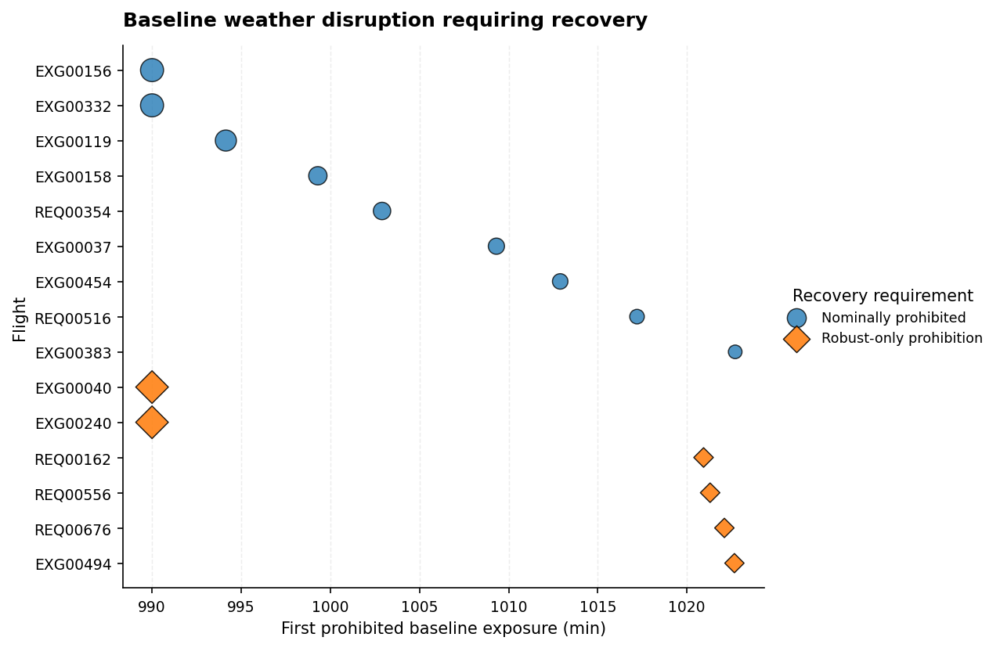

In [104]:
# =====================================================================
# CELL 21 — E1: BASELINE WEATHER DISRUPTION AND RECOVERY REQUIREMENT
# =====================================================================
# Purpose:
#   Establish the operational need for recovery before optimisation.
#   Distinguish weather exposure from operational prohibition and show
#   which baseline flights become prohibited under the robust criterion.
#
# Inputs:
#   WEATHER_DIAGNOSIS
#   AFFECTED_BASELINE
#
# Outputs:
#   Figure 1  — baseline disruption requiring recovery
#   TABLE_21A — fleet-level weather classification summary
#   TABLE_21B — recovery-required flight evidence
#   CSV, PDF and PNG exports
# =====================================================================

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

OUT = Path("paper_outputs")
OUT.mkdir(parents=True, exist_ok=True)

# ---------------------------------------------------------------------
# 1. Validate inputs
# ---------------------------------------------------------------------

required_objects = [
    "WEATHER_DIAGNOSIS",
    "AFFECTED_BASELINE",
]

missing = [name for name in required_objects if name not in globals()]
if missing:
    raise RuntimeError(f"Missing required object(s): {missing}")

required_diag = {
    "flight_id",
    "nominal_overlap",
    "robust_overlap",
    "nominal_prohibited",
    "robust_prohibited",
    "requires_weather_recovery",
}

required_aff = {
    "flight_id",
    "track",
    "first_prohibited_min",
    "max_prohibited_severity",
    "nominal_prohibited",
    "robust_prohibited",
    "weather_cells",
    "requires_weather_recovery",
}

if not required_diag.issubset(WEATHER_DIAGNOSIS.columns):
    raise RuntimeError("Unexpected WEATHER_DIAGNOSIS schema.")

if not required_aff.issubset(AFFECTED_BASELINE.columns):
    raise RuntimeError("Unexpected AFFECTED_BASELINE schema.")

diag = WEATHER_DIAGNOSIS.copy()
affected = AFFECTED_BASELINE.copy()

diag["flight_id"] = diag["flight_id"].astype(str)
affected["flight_id"] = affected["flight_id"].astype(str)

if diag["flight_id"].duplicated().any():
    raise RuntimeError(
        "WEATHER_DIAGNOSIS must contain one row per flight."
    )

# Robust prohibition must exactly define weather-recovery requirement.
mismatch = (
    diag["robust_prohibited"].fillna(False).astype(bool)
    !=
    diag["requires_weather_recovery"].fillna(False).astype(bool)
)

if mismatch.any():
    raise RuntimeError(
        "robust_prohibited and requires_weather_recovery are inconsistent."
    )

affected = affected.loc[
    affected["requires_weather_recovery"]
    .fillna(False)
    .astype(bool)
].copy()

# ---------------------------------------------------------------------
# 2. Fleet-level classification
# ---------------------------------------------------------------------

def flight_set(df, flag):
    return set(
        df.loc[
            df[flag].fillna(False).astype(bool),
            "flight_id",
        ]
    )


all_flights = set(diag["flight_id"])

nom_overlap_ids = flight_set(diag, "nominal_overlap")
rob_overlap_ids = flight_set(diag, "robust_overlap")
nom_prohibited_ids = flight_set(diag, "nominal_prohibited")
rob_prohibited_ids = flight_set(diag, "robust_prohibited")
recovery_ids = flight_set(diag, "requires_weather_recovery")

robust_only_ids = rob_prohibited_ids - nom_prohibited_ids

n_total = len(all_flights)

if n_total == 0:
    raise RuntimeError("WEATHER_DIAGNOSIS contains no flights.")

n_nom_overlap = len(nom_overlap_ids)
n_rob_overlap = len(rob_overlap_ids)
n_nom_prohibited = len(nom_prohibited_ids)
n_rob_prohibited = len(rob_prohibited_ids)
n_recovery = len(recovery_ids)
n_robust_only = len(robust_only_ids)

if rob_prohibited_ids != recovery_ids:
    raise RuntimeError(
        "Robustly prohibited flights do not match recovery-required flights."
    )

TABLE_21A = pd.DataFrame({
    "Metric": [
        "Flights assessed",
        "Nominal weather overlap",
        "Robust weather overlap",
        "Nominally prohibited",
        "Robustly prohibited",
        "Require weather recovery",
        "Additional robust-only prohibitions",
    ],
    "Flights": [
        n_total,
        n_nom_overlap,
        n_rob_overlap,
        n_nom_prohibited,
        n_rob_prohibited,
        n_recovery,
        n_robust_only,
    ],
})

TABLE_21A["Share (%)"] = (
    100 * TABLE_21A["Flights"] / n_total
).round(1)

# ---------------------------------------------------------------------
# 3. Recovery-required flight evidence
# ---------------------------------------------------------------------

TABLE_21B = (
    affected[
        [
            "flight_id",
            "track",
            "first_prohibited_min",
            "max_prohibited_severity",
            "nominal_prohibited",
            "robust_prohibited",
            "weather_cells",
        ]
    ]
    .rename(columns={
        "flight_id": "Flight",
        "track": "Baseline track",
        "first_prohibited_min": "First prohibited time (min)",
        "max_prohibited_severity": "Maximum severity",
        "nominal_prohibited": "Nominal prohibition",
        "robust_prohibited": "Robust prohibition",
        "weather_cells": "Weather cell",
    })
    .sort_values(
        ["First prohibited time (min)", "Maximum severity"],
        ascending=[True, False],
        kind="stable",
    )
    .reset_index(drop=True)
)

if set(TABLE_21B["Flight"]) != recovery_ids:
    raise RuntimeError(
        "AFFECTED_BASELINE does not match the recovery-required population."
    )

# ---------------------------------------------------------------------
# 4. Figure 1 — onset, severity and basis of recovery requirement
# ---------------------------------------------------------------------

plot_df = (
    TABLE_21B
    .dropna(
        subset=[
            "First prohibited time (min)",
            "Maximum severity",
        ]
    )
    .sort_values(
        ["First prohibited time (min)", "Flight"],
        ascending=[True, True],
        kind="stable",
    )
    .reset_index(drop=True)
)

if plot_df.empty:
    raise RuntimeError(
        "No recovery-required flight evidence is available."
    )

plot_df["Recovery basis"] = (
    plot_df["Nominal prohibition"]
    .fillna(False)
    .astype(bool)
    .map({
        True: "Nominally prohibited",
        False: "Robust-only prohibition",
    })
)

severity = pd.to_numeric(
    plot_df["Maximum severity"],
    errors="raise",
)

if severity.max() > severity.min():
    marker_size = 70 + 130 * (
        (severity - severity.min())
        / (severity.max() - severity.min())
    )
else:
    marker_size = pd.Series(
        100.0,
        index=plot_df.index,
    )

fig, ax = plt.subplots(
    figsize=(8.6, 6.0)
)

styles = {
    "Nominally prohibited": {
        "marker": "o",
        "alpha": 0.78,
    },
    "Robust-only prohibition": {
        "marker": "D",
        "alpha": 0.88,
    },
}

for label, style in styles.items():

    mask = plot_df["Recovery basis"].eq(label)

    ax.scatter(
        plot_df.loc[
            mask,
            "First prohibited time (min)",
        ],
        plot_df.loc[
            mask,
            "Flight",
        ],
        s=marker_size.loc[mask],
        marker=style["marker"],
        alpha=style["alpha"],
        edgecolors="black",
        linewidths=0.7,
        label=label,
        zorder=3,
    )

ax.invert_yaxis()

ax.set_xlabel(
    "First prohibited baseline exposure (min)"
)

ax.set_ylabel(
    "Flight"
)

ax.set_title(
    "Baseline weather disruption requiring recovery",
    loc="left",
    fontsize=12,
    fontweight="semibold",
    pad=12,
)

ax.legend(
    title="Recovery requirement",
    frameon=False,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    borderaxespad=0,
)

ax.grid(
    axis="x",
    linestyle="--",
    linewidth=0.7,
    alpha=0.22,
    zorder=0,
)

ax.spines[
    ["top", "right"]
].set_visible(False)

ax.tick_params(
    axis="both",
    labelsize=9,
)

fig.subplots_adjust(
    right=0.76
)

# ---------------------------------------------------------------------
# 5. Export
# ---------------------------------------------------------------------

# Canonical manuscript Figure 1.
fig.savefig(
    OUT / "figure_1_baseline_problem.pdf",
    bbox_inches="tight",
)

fig.savefig(
    OUT / "figure_1_baseline_problem.png",
    dpi=400,
    bbox_inches="tight",
)

# Cell-numbered copies retained for notebook provenance.
fig.savefig(
    OUT / "figure_21_weather_disruption.pdf",
    bbox_inches="tight",
)

fig.savefig(
    OUT / "figure_21_weather_disruption.png",
    dpi=400,
    bbox_inches="tight",
)

TABLE_21A.to_csv(
    OUT / "table_21a_weather_classification.csv",
    index=False,
)

TABLE_21B.to_csv(
    OUT / "table_21b_recovery_required_flights.csv",
    index=False,
)

# ---------------------------------------------------------------------
# 6. Paper-facing output
# ---------------------------------------------------------------------

print("=" * 76)
print("CELL 21 — E1: BASELINE WEATHER DISRUPTION AND RECOVERY REQUIREMENT")
print("=" * 76)
print(f"Flights assessed              : {n_total}")
print(
    f"Robust weather overlap        : "
    f"{n_rob_overlap} ({100*n_rob_overlap/n_total:.1f}%)"
)
print(
    f"Nominally prohibited          : "
    f"{n_nom_prohibited} ({100*n_nom_prohibited/n_total:.1f}%)"
)
print(
    f"Robustly prohibited           : "
    f"{n_rob_prohibited} ({100*n_rob_prohibited/n_total:.1f}%)"
)
print(
    f"Require weather recovery      : "
    f"{n_recovery} ({100*n_recovery/n_total:.1f}%)"
)
print(
    f"Additional robust-only cases  : "
    f"{n_robust_only}"
)
print(
    "Canonical manuscript figure  : "
    "figure_1_baseline_problem"
)
print(f"Exports                       : {OUT.resolve()}")
print("=" * 76)

display(TABLE_21A)
display(TABLE_21B)

plt.show()

CELL 22 — E2: FLEET RECOVERY PERFORMANCE
Selected case                 : 150
Fleet size                    : 150
Baseline retained             : 137/150 (91.3%)
Flights requiring intervention: 13
Track changes                 : 9
Flight-level changes          : 5
Mach changes                  : 0
Timing interventions          : 0
Returned to baseline          : 13/13 (100.0%)
Median deviated stages        : 3.0
Median exit-time effect       : 1.66 min
Maximum exit-time effect      : 16.59 min
Mean distance effect          : 30.41 NM
Canonical manuscript table   : table_2_recovery_performance.csv
Exports                       : C:\Users\sz4911s\paper_outputs

TABLE 2 — FLEET RECOVERY PERFORMANCE


,Flights,Modified flights,Modified (%),Baseline retained,Baseline retained (%),Track changes,FL changes,Mach changes,Timing interventions,Returned to baseline,Return rate (%),Median intervention stages,Median exit-time effect (min),Maximum exit-time effect (min),Mean distance effect (NM),Maximum distance effect (NM)
0,150,13,8.7,137,91.3,9,5,0,0,13,100.0,3.0,1.66,16.59,30.41,143.98



MODIFIED-FLIGHT OUTCOMES


,Flight,Population,Intervention,Track change,FL change,Mach change,Timing intervention,First deviation stage,Last deviation stage,Deviated stages,Return to baseline,Return stage,Distance change (NM),Exit-time displacement (min),Duration change (min)
0,EXG00470,existing,Track only,True,False,False,False,2,5,4,True,6,143.98,16.59,16.59
1,EXG00383,existing,Track only,True,False,False,False,2,4,3,True,5,66.69,8.81,8.81
2,EXG00037,existing,Track only,True,False,False,False,2,4,3,True,5,60.45,7.06,7.06
3,REQ00269,requested,Track only,True,False,False,False,2,4,3,True,5,44.36,5.88,5.88
4,REQ00876,requested,Track only,True,False,False,False,2,4,3,True,5,46.63,5.70,5.70
5,REQ00281,requested,Track only,True,False,False,False,2,4,3,True,5,23.34,2.94,2.94
6,REQ00829,requested,Track only,True,False,False,False,2,3,2,True,4,12.81,1.66,1.66
7,EXG00158,existing,Track only,True,False,False,False,2,4,3,True,5,12.90,1.60,1.60
8,EXG00119,existing,FL only,False,True,False,False,2,2,1,True,3,0.00,0.00,0.00
9,REQ00266,requested,FL only,False,True,False,False,1,4,4,True,5,0.00,0.00,0.00


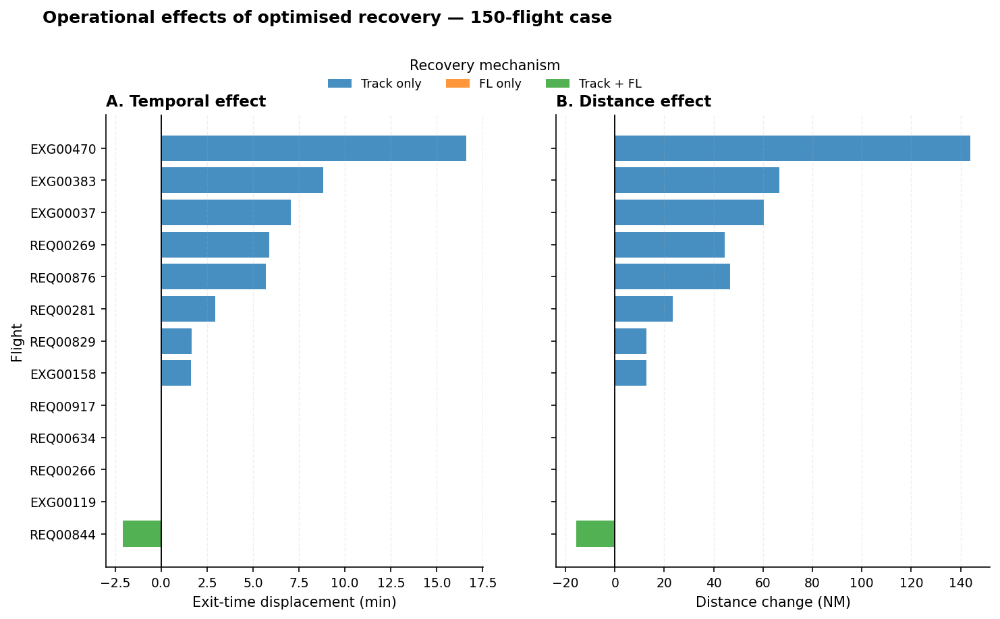

In [106]:
# =====================================================================
# CELL 22 — E2: FLEET RECOVERY PERFORMANCE
# =====================================================================
# Purpose:
#   Quantify the fleet-level effectiveness and operational burden of
#   optimised recovery in the largest validated case.
#
# Inputs:
#   FLIGHT_LEVEL_RECOVERY
#   SOLVED_CASES
#
# Outputs:
#   TABLE_2   — principal fleet recovery-performance table (Table 2)
#   TABLE_22B — detailed modified-flight outcomes
#   Figure 22 — operational effects of recovery (supporting figure)
#   CSV, PDF and PNG exports
# =====================================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

OUT = Path("paper_outputs")
OUT.mkdir(parents=True, exist_ok=True)

# ---------------------------------------------------------------------
# 1. Validate inputs
# ---------------------------------------------------------------------

required_objects = [
    "FLIGHT_LEVEL_RECOVERY",
    "SOLVED_CASES",
]

missing_objects = [
    name for name in required_objects
    if name not in globals()
]

if missing_objects:
    raise RuntimeError(
        f"Missing required object(s): {missing_objects}"
    )

required_columns = {
    "Case",
    "Flight",
    "Population",
    "Track change",
    "FL change",
    "Mach change",
    "Entry-time adjustment (min)",
    "Timing intervention",
    "First deviation stage",
    "Last deviation stage",
    "Deviated stages",
    "Return to baseline",
    "Return stage",
    "Distance change (NM)",
    "Exit-time displacement (min)",
    "Duration change (min)",
}

missing_columns = (
    required_columns
    - set(FLIGHT_LEVEL_RECOVERY.columns)
)

if missing_columns:
    raise RuntimeError(
        "FLIGHT_LEVEL_RECOVERY is missing: "
        f"{sorted(missing_columns)}"
    )

# ---------------------------------------------------------------------
# 2. Select definitive case
# ---------------------------------------------------------------------

recovery = FLIGHT_LEVEL_RECOVERY.copy()

recovery["Case"] = pd.to_numeric(
    recovery["Case"],
    errors="raise",
).astype(int)

final_case = max(
    set(recovery["Case"])
    & set(map(int, SOLVED_CASES.keys()))
)

R = recovery.loc[
    recovery["Case"].eq(final_case)
].copy()

R["Flight"] = R["Flight"].astype(str)

if R.empty:
    raise RuntimeError(
        "No recovery outcomes found for the selected case."
    )

if R["Flight"].duplicated().any():
    raise RuntimeError(
        "Selected recovery case must contain one row per modified flight."
    )

case_ids = pd.Index(
    map(str, SOLVED_CASES[final_case]["case_ids"])
)

if case_ids.duplicated().any():
    raise RuntimeError(
        "Selected case contains duplicate flight identifiers."
    )

if not set(R["Flight"]).issubset(set(case_ids)):
    raise RuntimeError(
        "Recovery table contains flights outside the selected fleet."
    )

fleet_size = len(case_ids)
n_modified = len(R)
n_unchanged = fleet_size - n_modified

# ---------------------------------------------------------------------
# 3. Normalise verified fields
# ---------------------------------------------------------------------

def as_bool(series):
    if pd.api.types.is_bool_dtype(series):
        return series.fillna(False).astype(bool)

    mapped = (
        series.astype(str)
        .str.strip()
        .str.lower()
        .map({
            "true": True,
            "false": False,
            "yes": True,
            "no": False,
            "1": True,
            "0": False,
        })
    )

    if mapped.isna().any():
        bad = sorted(
            series.loc[mapped.isna()]
            .astype(str)
            .unique()
        )
        raise RuntimeError(
            f"Unrecognised Boolean value(s): {bad}"
        )

    return mapped.astype(bool)


track_change = as_bool(R["Track change"])
fl_change = as_bool(R["FL change"])
mach_change = as_bool(R["Mach change"])
timing_change = as_bool(R["Timing intervention"])
returned = as_bool(R["Return to baseline"])

deviated_stages = pd.to_numeric(
    R["Deviated stages"],
    errors="raise",
)

distance_delta = pd.to_numeric(
    R["Distance change (NM)"],
    errors="raise",
)

exit_delta = pd.to_numeric(
    R["Exit-time displacement (min)"],
    errors="raise",
)

duration_delta = pd.to_numeric(
    R["Duration change (min)"],
    errors="raise",
)

entry_adjustment = pd.to_numeric(
    R["Entry-time adjustment (min)"],
    errors="raise",
)

# Remove floating-point negative zero for publication output.
for series in [
    distance_delta,
    exit_delta,
    duration_delta,
    entry_adjustment,
]:
    series.mask(
        series.abs() < 0.005,
        0.0,
        inplace=True,
    )

# ---------------------------------------------------------------------
# 4. Classify recovery mechanism
# ---------------------------------------------------------------------

mechanism = np.select(
    [
        track_change & fl_change,
        track_change,
        fl_change,
        mach_change,
        timing_change,
    ],
    [
        "Track + FL",
        "Track only",
        "FL only",
        "Mach only",
        "Timing only",
    ],
    default="Other",
)

# ---------------------------------------------------------------------
# 5. TABLE_2 — principal fleet-level recovery result
# ---------------------------------------------------------------------

return_count = int(returned.sum())

TABLE_2 = pd.DataFrame({
    "Flights": [fleet_size],
    "Modified flights": [n_modified],
    "Modified (%)": [
        round(100 * n_modified / fleet_size, 1)
    ],
    "Baseline retained": [n_unchanged],
    "Baseline retained (%)": [
        round(100 * n_unchanged / fleet_size, 1)
    ],
    "Track changes": [int(track_change.sum())],
    "FL changes": [int(fl_change.sum())],
    "Mach changes": [int(mach_change.sum())],
    "Timing interventions": [int(timing_change.sum())],
    "Returned to baseline": [return_count],
    "Return rate (%)": [
        round(100 * return_count / n_modified, 1)
    ],
    "Median intervention stages": [
        round(float(deviated_stages.median()), 1)
    ],
    "Median exit-time effect (min)": [
        round(float(exit_delta.median()), 2)
    ],
    "Maximum exit-time effect (min)": [
        round(float(exit_delta.max()), 2)
    ],
    "Mean distance effect (NM)": [
        round(float(distance_delta.mean()), 2)
    ],
    "Maximum distance effect (NM)": [
        round(float(distance_delta.max()), 2)
    ],
})

# Notebook-compatible alias.
TABLE_22A = TABLE_2

# ---------------------------------------------------------------------
# 6. TABLE_22B — detailed modified-flight outcomes
# ---------------------------------------------------------------------

TABLE_22B = pd.DataFrame({
    "Flight": R["Flight"].values,
    "Population": R["Population"].values,
    "Intervention": mechanism,
    "Track change": track_change.values,
    "FL change": fl_change.values,
    "Mach change": mach_change.values,
    "Timing intervention": timing_change.values,
    "First deviation stage": R["First deviation stage"].values,
    "Last deviation stage": R["Last deviation stage"].values,
    "Deviated stages": deviated_stages.values,
    "Return to baseline": returned.values,
    "Return stage": R["Return stage"].values,
    "Distance change (NM)": distance_delta.round(2).values,
    "Exit-time displacement (min)": exit_delta.round(2).values,
    "Duration change (min)": duration_delta.round(2).values,
})

TABLE_22B = (
    TABLE_22B
    .sort_values(
        [
            "Exit-time displacement (min)",
            "Flight",
        ],
        ascending=[False, True],
        kind="stable",
    )
    .reset_index(drop=True)
)

# ---------------------------------------------------------------------
# 7. Figure 22 — operational effects by recovery mechanism
# ---------------------------------------------------------------------

plot_df = (
    TABLE_22B
    .dropna(
        subset=[
            "Exit-time displacement (min)",
            "Distance change (NM)",
        ]
    )
    .sort_values(
        [
            "Exit-time displacement (min)",
            "Flight",
        ],
        ascending=[True, True],
        kind="stable",
    )
    .reset_index(drop=True)
)

if plot_df.empty:
    raise RuntimeError(
        "No numeric recovery effects are available for Figure 22."
    )

cycle = (
    plt.rcParams["axes.prop_cycle"]
    .by_key()["color"]
)

mechanism_order = [
    "Track only",
    "FL only",
    "Track + FL",
    "Mach only",
    "Timing only",
    "Other",
]

present = [
    m for m in mechanism_order
    if m in set(plot_df["Intervention"])
]

mechanism_colour = {
    m: cycle[i % len(cycle)]
    for i, m in enumerate(present)
}

bar_colours = [
    mechanism_colour[m]
    for m in plot_df["Intervention"]
]

fig, (ax_time, ax_dist) = plt.subplots(
    1,
    2,
    figsize=(10.4, 6.3),
    sharey=True,
    gridspec_kw={"width_ratios": [1.0, 1.15]},
)

y = np.arange(len(plot_df))

ax_time.barh(
    y,
    plot_df["Exit-time displacement (min)"],
    color=bar_colours,
    alpha=0.82,
)

ax_dist.barh(
    y,
    plot_df["Distance change (NM)"],
    color=bar_colours,
    alpha=0.82,
)

for ax in (ax_time, ax_dist):

    ax.axvline(
        0,
        linewidth=0.9,
        color="black",
        zorder=3,
    )

    ax.grid(
        axis="x",
        linestyle="--",
        linewidth=0.7,
        alpha=0.20,
        zorder=0,
    )

    ax.spines[
        ["top", "right"]
    ].set_visible(False)

    ax.tick_params(
        axis="both",
        labelsize=9,
    )

ax_time.set_yticks(y)
ax_time.set_yticklabels(
    plot_df["Flight"]
)

ax_time.set_xlabel(
    "Exit-time displacement (min)"
)

ax_dist.set_xlabel(
    "Distance change (NM)"
)

ax_time.set_ylabel(
    "Flight"
)

ax_time.set_title(
    "A. Temporal effect",
    loc="left",
    fontsize=11,
    fontweight="semibold",
)

ax_dist.set_title(
    "B. Distance effect",
    loc="left",
    fontsize=11,
    fontweight="semibold",
)

legend_handles = [
    Patch(
        facecolor=mechanism_colour[m],
        alpha=0.82,
        label=m,
    )
    for m in present
]

fig.legend(
    handles=legend_handles,
    title="Recovery mechanism",
    frameon=False,
    ncol=max(1, len(present)),
    loc="upper center",
    bbox_to_anchor=(0.5, 0.925),
)

fig.suptitle(
    (
        "Operational effects of optimised recovery — "
        f"{final_case}-flight case"
    ),
    x=0.08,
    y=0.985,
    ha="left",
    fontsize=12,
    fontweight="semibold",
)

fig.subplots_adjust(
    left=0.14,
    right=0.98,
    bottom=0.11,
    top=0.82,
    wspace=0.18,
)

# ---------------------------------------------------------------------
# 8. Export
# ---------------------------------------------------------------------

# Canonical manuscript Table 2.
TABLE_2.to_csv(
    OUT / "table_2_recovery_performance.csv",
    index=False,
)

# Supporting detailed table.
TABLE_22B.to_csv(
    OUT / "table_22b_flight_recovery_outcomes.csv",
    index=False,
)

# Cell-numbered copy retained for notebook provenance.
TABLE_2.to_csv(
    OUT / "table_22a_recovery_performance.csv",
    index=False,
)

fig.savefig(
    OUT / "figure_22_fleet_recovery_performance.pdf",
    bbox_inches="tight",
)

fig.savefig(
    OUT / "figure_22_fleet_recovery_performance.png",
    dpi=400,
    bbox_inches="tight",
)

# ---------------------------------------------------------------------
# 9. Paper-facing output
# ---------------------------------------------------------------------

print("=" * 76)
print("CELL 22 — E2: FLEET RECOVERY PERFORMANCE")
print("=" * 76)
print(f"Selected case                 : {final_case}")
print(f"Fleet size                    : {fleet_size}")
print(
    f"Baseline retained             : "
    f"{n_unchanged}/{fleet_size} "
    f"({100*n_unchanged/fleet_size:.1f}%)"
)
print(
    f"Flights requiring intervention: "
    f"{n_modified}"
)
print(f"Track changes                 : {int(track_change.sum())}")
print(f"Flight-level changes          : {int(fl_change.sum())}")
print(f"Mach changes                  : {int(mach_change.sum())}")
print(f"Timing interventions          : {int(timing_change.sum())}")
print(
    f"Returned to baseline          : "
    f"{return_count}/{n_modified} "
    f"({100*return_count/n_modified:.1f}%)"
)
print(
    f"Median deviated stages        : "
    f"{deviated_stages.median():.1f}"
)
print(
    f"Median exit-time effect       : "
    f"{exit_delta.median():.2f} min"
)
print(
    f"Maximum exit-time effect      : "
    f"{exit_delta.max():.2f} min"
)
print(
    f"Mean distance effect          : "
    f"{distance_delta.mean():.2f} NM"
)
print(
    "Canonical manuscript table   : "
    "table_2_recovery_performance.csv"
)
print(f"Exports                       : {OUT.resolve()}")
print("=" * 76)

print("\nTABLE 2 — FLEET RECOVERY PERFORMANCE")
display(TABLE_2)

print("\nMODIFIED-FLIGHT OUTCOMES")
display(TABLE_22B)

plt.show()

CELL 23 — E3: FLEET-LEVEL COORDINATION
Selected case                         : 150
Fleet size                            : 150
Baseline retained                     : 137/150 (91.3%)
Flights requiring intervention        : 13
Track changes                         : 9
Flight-level changes                  : 5
Mach changes                          : 0
Timing interventions                  : 0
Submitted-profile interactions audited: 3124
Interactions requiring recovery       : 36
Exactly one modified endpoint         : 36/36
Exports                               : C:\Users\sz4911s\paper_outputs


,Flight,Recovery action,Affected
0,EXG00037,Track only,True
1,EXG00119,FL only,True
2,EXG00158,Track only,True
3,EXG00383,Track only,True
4,EXG00470,Track only,True
5,REQ00266,FL only,True
6,REQ00269,Track only,True
7,REQ00281,Track only,True
8,REQ00634,FL only,True
9,REQ00829,Track only,True


,Affected endpoints,Interactions
0,Neither,0
1,Exactly one,36
2,Both,0


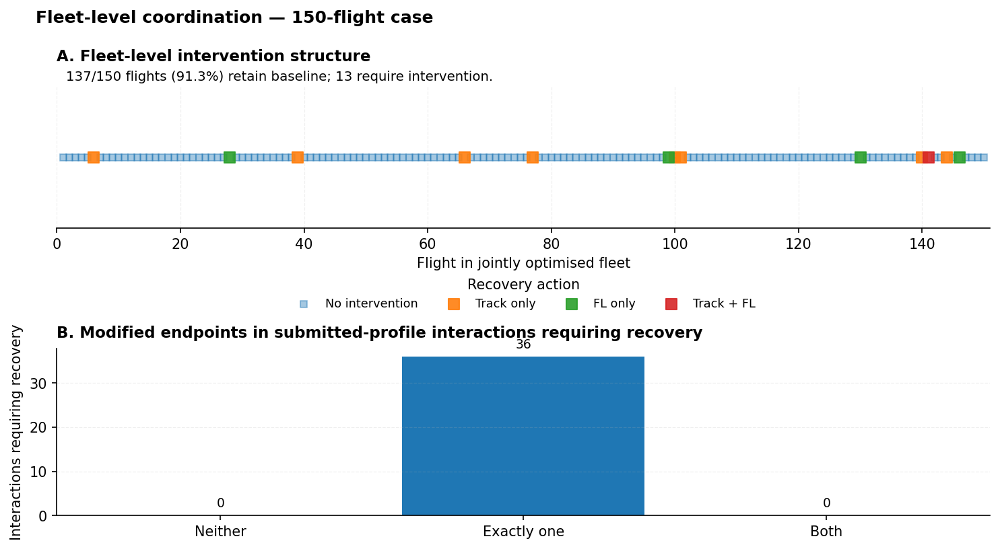

In [81]:
# =====================================================================
# CELL 23 — E3: FLEET-LEVEL COORDINATION
# =====================================================================
# Purpose:
#   Show how jointly optimised recovery actions are distributed across
#   the fleet and how submitted-profile interactions requiring recovery
#   are coordinated.
#
# Inputs:
#   SOLVED_CASES
#   FLIGHT_LEVEL_RECOVERY
#   SUBMITTED_PROFILE_INTERACTION_AUDIT
#
# Outputs:
#   Figure 2 — fleet-level coordination
#   TABLE_23A — complete flight-level intervention classification
#   TABLE_23B — recovery-required interaction coordination summary
#   CSV, PDF and PNG exports
# =====================================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

OUT = Path("paper_outputs")
OUT.mkdir(parents=True, exist_ok=True)

# ---------------------------------------------------------------------
# 1. Validate inputs and select definitive case
# ---------------------------------------------------------------------

required_objects = [
    "SOLVED_CASES",
    "FLIGHT_LEVEL_RECOVERY",
    "SUBMITTED_PROFILE_INTERACTION_AUDIT",
]

missing_objects = [name for name in required_objects if name not in globals()]
if missing_objects:
    raise RuntimeError(
        f"Missing required object(s): {missing_objects}"
    )

if not SOLVED_CASES:
    raise RuntimeError("SOLVED_CASES is empty.")

final_case = max(SOLVED_CASES)

case_ids = pd.Index(
    [str(x) for x in SOLVED_CASES[final_case]["case_ids"]],
    name="Flight",
)

if case_ids.duplicated().any():
    raise RuntimeError(
        f"Duplicate flight IDs found in case {final_case}."
    )

R = FLIGHT_LEVEL_RECOVERY.loc[
    pd.to_numeric(
        FLIGHT_LEVEL_RECOVERY["Case"],
        errors="coerce",
    ).eq(final_case)
].copy()

R["Flight"] = R["Flight"].astype(str)

if R["Flight"].duplicated().any():
    raise RuntimeError(
        "Duplicate recovery records found for the selected case."
    )

if not set(R["Flight"]).issubset(set(case_ids)):
    raise RuntimeError(
        "Recovery table contains flights outside the selected case."
    )

# ---------------------------------------------------------------------
# 2. Classify flight-level recovery action
# ---------------------------------------------------------------------

track = R["Track change"].eq(True)
fl = R["FL change"].eq(True)
mach = R["Mach change"].eq(True)
timing = R["Timing intervention"].eq(True)

R["Recovery action"] = np.select(
    [
        track & fl,
        track,
        fl,
        mach,
        timing,
    ],
    [
        "Track + FL",
        "Track only",
        "FL only",
        "Mach only",
        "Timing only",
    ],
    default="Other",
)

TABLE_23A = (
    pd.DataFrame({"Flight": case_ids.to_numpy()})
    .merge(
        R[["Flight", "Recovery action"]],
        on="Flight",
        how="left",
        validate="one_to_one",
    )
)

TABLE_23A["Recovery action"] = (
    TABLE_23A["Recovery action"]
    .fillna("No intervention")
)

TABLE_23A["Affected"] = (
    TABLE_23A["Recovery action"].ne("No intervention")
)

n_fleet = len(TABLE_23A)
n_affected = int(TABLE_23A["Affected"].sum())
n_unchanged = n_fleet - n_affected
unchanged_pct = 100 * n_unchanged / n_fleet

# ---------------------------------------------------------------------
# 3. Submitted-profile interaction coordination audit
# ---------------------------------------------------------------------

A = SUBMITTED_PROFILE_INTERACTION_AUDIT.copy()

A["flight_i"] = A["flight_i"].astype(str)
A["flight_j"] = A["flight_j"].astype(str)

A = A.loc[
    A["flight_i"].isin(case_ids)
    & A["flight_j"].isin(case_ids)
].copy()

affected_ids = set(R["Flight"])

problem = A.loc[
    A["requires_recovery"].eq(True)
].copy()

problem["Affected endpoints"] = (
    problem["flight_i"].isin(affected_ids).astype(int)
    + problem["flight_j"].isin(affected_ids).astype(int)
)

coord_counts = (
    problem["Affected endpoints"]
    .value_counts()
    .reindex([0, 1, 2], fill_value=0)
)

TABLE_23B = pd.DataFrame({
    "Affected endpoints": [
        "Neither",
        "Exactly one",
        "Both",
    ],
    "Interactions": [
        int(coord_counts.loc[0]),
        int(coord_counts.loc[1]),
        int(coord_counts.loc[2]),
    ],
})

n_problem = len(problem)

# ---------------------------------------------------------------------
# 4. Figure 2 — fleet structure and interaction coordination
# ---------------------------------------------------------------------

action_order = [
    "No intervention",
    "Track only",
    "FL only",
    "Track + FL",
    "Mach only",
    "Timing only",
    "Other",
]

present = [
    action
    for action in action_order
    if action in set(TABLE_23A["Recovery action"])
]

colours = plt.rcParams["axes.prop_cycle"].by_key()["color"]

fig, (ax1, ax2) = plt.subplots(
    2,
    1,
    figsize=(10.5, 5.6),
    gridspec_kw={"height_ratios": [0.85, 1.0]},
)

# Panel A — complete fleet in solved-case order
x = np.arange(1, n_fleet + 1)

for i, action in enumerate(present):
    mask = TABLE_23A["Recovery action"].eq(action)

    ax1.scatter(
        x[mask],
        np.zeros(mask.sum()),
        marker="s",
        s=22 if action == "No intervention" else 55,
        alpha=0.40 if action == "No intervention" else 0.90,
        color=colours[i % len(colours)],
        label=action,
    )

ax1.set_xlim(0, n_fleet + 1)
ax1.set_ylim(-0.12, 0.12)
ax1.set_yticks([])
ax1.set_xlabel("Flight in jointly optimised fleet")

ax1.set_title(
    "A. Fleet-level intervention structure",
    loc="left",
    fontsize=11,
    fontweight="semibold",
    pad=18,
)

ax1.text(
    0.01,
    1.02,
    (
        f"{n_unchanged}/{n_fleet} flights "
        f"({unchanged_pct:.1f}%) retain baseline; "
        f"{n_affected} require intervention."
    ),
    transform=ax1.transAxes,
    fontsize=9.5,
    va="bottom",
)

ax1.grid(
    axis="x",
    linestyle="--",
    linewidth=0.6,
    alpha=0.20,
)

ax1.spines[["top", "right", "left"]].set_visible(False)

ax1.legend(
    title="Recovery action",
    frameon=False,
    ncol=len(present),
    loc="upper center",
    bbox_to_anchor=(0.5, -0.28),
)

# Panel B — submitted-profile interactions requiring recovery
bars = ax2.bar(
    TABLE_23B["Affected endpoints"],
    TABLE_23B["Interactions"],
)

for bar, value in zip(bars, TABLE_23B["Interactions"]):
    ax2.annotate(
        str(int(value)),
        (
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
        ),
        xytext=(0, 4),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=9,
    )

ax2.set_ylabel("Interactions requiring recovery")

ax2.set_title(
    "B. Modified endpoints in submitted-profile interactions requiring recovery",
    loc="left",
    fontsize=11,
    fontweight="semibold",
    pad=8,
)

ax2.grid(
    axis="y",
    linestyle="--",
    linewidth=0.6,
    alpha=0.20,
)

ax2.spines[["top", "right"]].set_visible(False)

fig.suptitle(
    f"Fleet-level coordination — {final_case}-flight case",
    x=0.08,
    y=0.995,
    ha="left",
    fontsize=12,
    fontweight="semibold",
)

fig.subplots_adjust(
    left=0.10,
    right=0.98,
    top=0.86,
    bottom=0.10,
    hspace=0.78,
)









# ---------------------------------------------------------------------
# 5. Export
# ---------------------------------------------------------------------

fig.savefig(
    OUT / "figure_2_fleet_level_coordination.pdf",
    bbox_inches="tight",
)

fig.savefig(
    OUT / "figure_2_fleet_level_coordination.png",
    dpi=400,
    bbox_inches="tight",
)

TABLE_23A.to_csv(
    OUT / "table_23a_flight_interventions.csv",
    index=False,
)

TABLE_23B.to_csv(
    OUT / "table_23b_interaction_coordination.csv",
    index=False,
)

# ---------------------------------------------------------------------
# 6. Paper-facing summary
# ---------------------------------------------------------------------

print("=" * 76)
print("CELL 23 — E3: FLEET-LEVEL COORDINATION")
print("=" * 76)
print(f"Selected case                         : {final_case}")
print(f"Fleet size                            : {n_fleet}")
print(
    f"Baseline retained                     : "
    f"{n_unchanged}/{n_fleet} ({unchanged_pct:.1f}%)"
)
print(f"Flights requiring intervention        : {n_affected}")
print(f"Track changes                         : {int(track.sum())}")
print(f"Flight-level changes                  : {int(fl.sum())}")
print(f"Mach changes                          : {int(mach.sum())}")
print(f"Timing interventions                  : {int(timing.sum())}")
print(f"Submitted-profile interactions audited: {len(A)}")
print(f"Interactions requiring recovery       : {n_problem}")
print(
    f"Exactly one modified endpoint         : "
    f"{int(coord_counts.loc[1])}/{n_problem}"
)
print(f"Exports                               : {OUT.resolve()}")
print("=" * 76)

display(
    TABLE_23A.loc[
        TABLE_23A["Affected"]
    ].reset_index(drop=True)
)

display(TABLE_23B)

plt.show()

CELL 24 — E4: SEQUENTIAL LEXICOGRAPHIC OPTIMISATION
Selected case                 : 150
Lexicographic stages          : 6
Objective vector              : (13, 0, 0, 5, 9, 36)
Feasibility constraints       : active at every stage
Higher-priority optima        : fixed before each subsequent stage
All stages globally optimal   : YES
Cumulative stage wall time    : 2979.26 s
Cumulative stage wall time    : 49.65 min
Exports                       : C:\Users\sz4911s\paper_outputs


,Priority,Objective optimised,Optimum,Higher-priority optima fixed,Model status,Solve status,Solver time (s),Wall time (s),Cumulative wall time (s)
0,1,Affected flights,13,None,OptimalGlobal,NormalCompletion,609.05,614.20,614.20
1,2,Mach interventions,0,Affected flights = 13,OptimalGlobal,NormalCompletion,1110.92,1117.33,1731.54
2,3,Timing interventions,0,Affected flights = 13; Mach interventions = 0,OptimalGlobal,NormalCompletion,1069.68,1077.13,2808.66
3,4,FL interventions,5,Affected flights = 13; Mach interventions = 0;...,OptimalGlobal,NormalCompletion,45.33,52.87,2861.53
4,5,Track interventions,9,Affected flights = 13; Mach interventions = 0;...,OptimalGlobal,NormalCompletion,55.22,63.51,2925.05
5,6,Structural deviation,36,Affected flights = 13; Mach interventions = 0;...,OptimalGlobal,NormalCompletion,45.95,54.21,2979.26


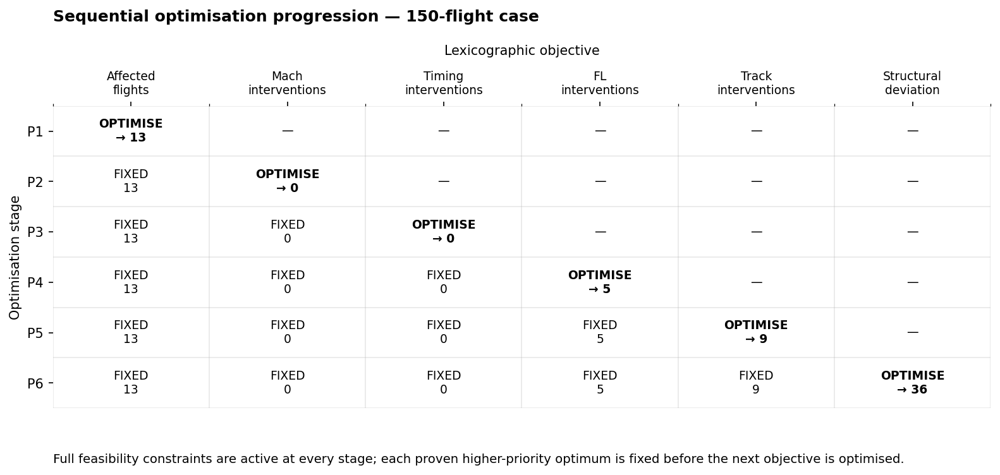

In [87]:
# =====================================================================
# CELL 24 — E4: SEQUENTIAL LEXICOGRAPHIC OPTIMISATION
# =====================================================================
# Purpose:
#   Make the six-stage lexicographic architecture explicit: what is
#   optimised at each priority, which higher-priority optima are already
#   fixed, and the optimum attained at each stage.
#
# Input:
#   LEXICOGRAPHIC_RESULTS
#
# Outputs:
#   Figure 3 — sequential optimisation progression
#   TABLE_24 — stage-wise optimisation results (Table 3)
#   CSV, PDF and PNG exports
# =====================================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

OUT = Path("paper_outputs")
OUT.mkdir(parents=True, exist_ok=True)

# ---------------------------------------------------------------------
# 1. Select and validate definitive case
# ---------------------------------------------------------------------

if "LEXICOGRAPHIC_RESULTS" not in globals():
    raise RuntimeError("LEXICOGRAPHIC_RESULTS is not available.")

required_cols = {
    "Case", "Priority", "Objective", "Optimum",
    "Model status", "Solve status",
    "Solver time (s)", "Wall time (s)",
}

missing = required_cols - set(LEXICOGRAPHIC_RESULTS.columns)
if missing:
    raise RuntimeError(
        f"LEXICOGRAPHIC_RESULTS is missing: {sorted(missing)}"
    )

L = LEXICOGRAPHIC_RESULTS.copy()

case_n = int(
    pd.to_numeric(L["Case"], errors="raise").max()
)

S = (
    L.loc[
        pd.to_numeric(L["Case"], errors="raise").eq(case_n)
    ]
    .sort_values("Priority")
    .reset_index(drop=True)
)

if S["Priority"].tolist() != [1, 2, 3, 4, 5, 6]:
    raise RuntimeError(
        "Expected six ordered lexicographic priorities."
    )

if not S["Model status"].eq("OptimalGlobal").all():
    raise RuntimeError(
        "At least one lexicographic stage is not globally optimal."
    )

if S[
    ["Optimum", "Solver time (s)", "Wall time (s)"]
].isna().any().any():
    raise RuntimeError(
        "Missing stage optimum or timing value."
    )

# ---------------------------------------------------------------------
# 2. Publication labels and sequential fixing structure
# ---------------------------------------------------------------------

labels = {
    "affected_flights": "Affected flights",
    "mach_interventions": "Mach interventions",
    "timing_interventions": "Timing interventions",
    "fl_interventions": "FL interventions",
    "track_interventions": "Track interventions",
    "structural_deviation": "Structural deviation",
}

S["Objective label"] = (
    S["Objective"]
    .map(labels)
    .fillna(S["Objective"])
)

S["Higher-priority optima fixed"] = [
    "None"
    if i == 0
    else "; ".join(
        f"{S.loc[j, 'Objective label']} = "
        f"{int(S.loc[j, 'Optimum'])}"
        for j in range(i)
    )
    for i in range(len(S))
]

S["Cumulative wall time (s)"] = (
    S["Wall time (s)"].cumsum()
)

TABLE_24 = S[
    [
        "Priority",
        "Objective label",
        "Optimum",
        "Higher-priority optima fixed",
        "Model status",
        "Solve status",
        "Solver time (s)",
        "Wall time (s)",
        "Cumulative wall time (s)",
    ]
].copy()

TABLE_24 = TABLE_24.rename(
    columns={
        "Objective label": "Objective optimised",
    }
)

for col in [
    "Solver time (s)",
    "Wall time (s)",
    "Cumulative wall time (s)",
]:
    TABLE_24[col] = TABLE_24[col].round(2)

# ---------------------------------------------------------------------
# 3. Figure 3 — sequential lexicographic progression
# ---------------------------------------------------------------------
# Each row is one optimisation stage.
#
# FIXED      = optimum already established at a higher priority
# OPTIMISE   = objective solved at the current priority
# —          = lower-priority objective not yet optimised
#
# Full feasibility constraints remain active throughout.
# ---------------------------------------------------------------------

n = len(S)

fig, ax = plt.subplots(figsize=(11.5, 5.8))

ax.set_xlim(-0.5, n - 0.5)
ax.set_ylim(n - 0.5, -0.5)

ax.set_xticks(np.arange(n))
ax.set_yticks(np.arange(n))

ax.set_xticklabels(
    [
        label.replace(
            " interventions", "\ninterventions"
        )
        .replace(
            "Affected flights", "Affected\nflights"
        )
        .replace(
            "Structural deviation", "Structural\ndeviation"
        )
        for label in S["Objective label"]
    ],
    fontsize=9,
)

ax.set_yticklabels(
    [f"P{p}" for p in S["Priority"]],
    fontsize=10,
)

for i in range(n):
    for j in range(n):

        if j < i:
            text = (
                f"FIXED\n"
                f"{int(S.loc[j, 'Optimum'])}"
            )

        elif j == i:
            text = (
                f"OPTIMISE\n"
                f"→ {int(S.loc[j, 'Optimum'])}"
            )

        else:
            text = "—"

        ax.text(
            j,
            i,
            text,
            ha="center",
            va="center",
            fontsize=9,
            fontweight="bold" if j == i else "normal",
        )

# Cell boundaries
ax.set_xticks(
    np.arange(-0.5, n, 1),
    minor=True,
)
ax.set_yticks(
    np.arange(-0.5, n, 1),
    minor=True,
)

ax.grid(
    which="minor",
    linewidth=0.8,
    alpha=0.30,
)

ax.tick_params(
    which="minor",
    bottom=False,
    left=False,
)

ax.xaxis.tick_top()
ax.xaxis.set_label_position("top")

ax.set_xlabel(
    "Lexicographic objective",
    labelpad=12,
)

ax.set_ylabel(
    "Optimisation stage",
)

ax.set_title(
    f"Sequential optimisation progression — {case_n}-flight case",
    loc="left",
    fontsize=12,
    fontweight="semibold",
    pad=18,
)

ax.text(
    0.0,
    -0.15,
    (
        "Full feasibility constraints are active at every stage; "
        "each proven higher-priority optimum is fixed before the "
        "next objective is optimised."
    ),
    transform=ax.transAxes,
    fontsize=9.5,
    va="top",
)

for spine in ax.spines.values():
    spine.set_visible(False)

fig.subplots_adjust(
    left=0.12,
    right=0.98,
    top=0.76,
    bottom=0.21,
)

# ---------------------------------------------------------------------
# 4. Export
# ---------------------------------------------------------------------

fig.savefig(
    OUT / "figure_3_sequential_optimisation.pdf",
    bbox_inches="tight",
)

fig.savefig(
    OUT / "figure_3_sequential_optimisation.png",
    dpi=400,
    bbox_inches="tight",
)

TABLE_24.to_csv(
    OUT / "table_3_sequential_optimisation.csv",
    index=False,
)

# ---------------------------------------------------------------------
# 5. Paper-facing summary
# ---------------------------------------------------------------------

objective_vector = tuple(
    S["Optimum"].astype(int)
)

total_wall = float(
    S["Wall time (s)"].sum()
)

all_optimal = (
    S["Model status"]
    .eq("OptimalGlobal")
    .all()
)

print("=" * 76)
print("CELL 24 — E4: SEQUENTIAL LEXICOGRAPHIC OPTIMISATION")
print("=" * 76)
print(f"Selected case                 : {case_n}")
print(f"Lexicographic stages          : {len(S)}")
print(f"Objective vector              : {objective_vector}")
print("Feasibility constraints       : active at every stage")
print("Higher-priority optima        : fixed before each subsequent stage")
print(
    f"All stages globally optimal   : "
    f"{'YES' if all_optimal else 'NO'}"
)
print(f"Cumulative stage wall time    : {total_wall:.2f} s")
print(f"Cumulative stage wall time    : {total_wall / 60:.2f} min")
print(f"Exports                       : {OUT.resolve()}")
print("=" * 76)

display(TABLE_24)

plt.show()

CELL 25 — E5: WEATHER ROBUSTNESS
Nominal prohibited flights       : 9
Robust prohibited flights        : 15
Robust-only prohibited flights   : 6
Selected case                    : 150
Baseline prohibited flights      : 12
Weather space-time windows       : 1854
Flights with weather windows     : 15
Recovered weather violations     : 0
Independent weather verification : PASS (0)
Modified flights                 : 13
Returned to baseline             : 13/13
Exports                          : C:\Users\sz4911s\paper_outputs


,Case,Flights,Baseline prohibited,Space-time windows,Flights with windows,Weather,Overall,Modified flights,Returned to baseline
0,50,50,7,764,8,PASS (0),PASS,2,2
1,100,100,11,1675,13,PASS (0),PASS,7,7
2,150,150,12,1854,15,PASS (0),PASS,13,13


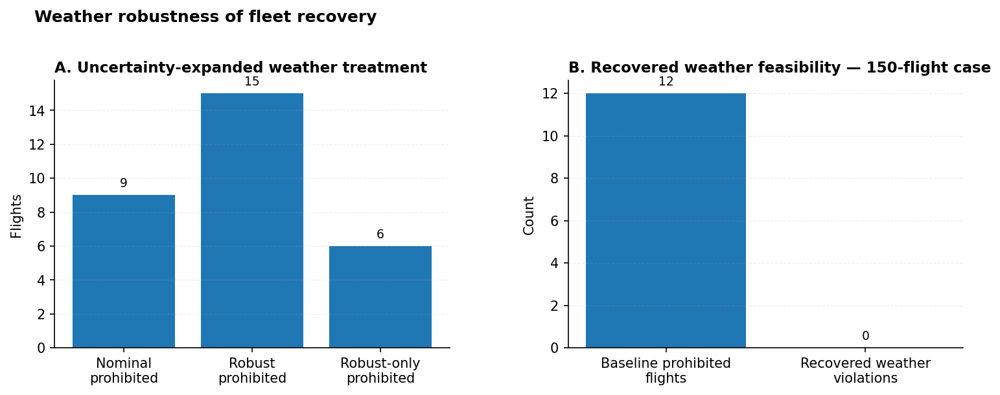

In [88]:
# =====================================================================
# CELL 25 — E5: WEATHER ROBUSTNESS
# =====================================================================
# Purpose:
#   Quantify the effect of uncertainty-expanded weather restrictions,
#   verify weather feasibility of the recovered solution, and report
#   return-to-baseline performance for modified flights.
#
# Inputs:
#   WEATHER_DIAGNOSIS
#   WEATHER_CASE_SUMMARY
#   INDEPENDENT_VERIFICATION
#   FLIGHT_LEVEL_RECOVERY
#
# Outputs:
#   Figure 4 — weather robustness
#   TABLE_25 — compact robustness summary
#   CSV, PDF and PNG exports
# =====================================================================

from pathlib import Path
import re
import pandas as pd
import matplotlib.pyplot as plt

OUT = Path("paper_outputs")
OUT.mkdir(parents=True, exist_ok=True)

# ---------------------------------------------------------------------
# 1. Validate inputs
# ---------------------------------------------------------------------

required = [
    "WEATHER_DIAGNOSIS",
    "WEATHER_CASE_SUMMARY",
    "INDEPENDENT_VERIFICATION",
    "FLIGHT_LEVEL_RECOVERY",
]

missing = [name for name in required if name not in globals()]
if missing:
    raise RuntimeError(f"Missing required object(s): {missing}")

# ---------------------------------------------------------------------
# 2. Uncertainty-expanded weather diagnosis
# ---------------------------------------------------------------------

D = WEATHER_DIAGNOSIS.copy()

for col in ["nominal_prohibited", "robust_prohibited"]:
    D[col] = D[col].fillna(False).astype(bool)

nominal_prohibited = int(D["nominal_prohibited"].sum())
robust_prohibited = int(D["robust_prohibited"].sum())

robust_only = int(
    (
        D["robust_prohibited"]
        & ~D["nominal_prohibited"]
    ).sum()
)

# ---------------------------------------------------------------------
# 3. Case-specific weather feasibility
# ---------------------------------------------------------------------

W = WEATHER_CASE_SUMMARY.copy()
V = INDEPENDENT_VERIFICATION.copy()

W["Case"] = pd.to_numeric(W["Case"], errors="raise").astype(int)
V["Case"] = pd.to_numeric(V["Case"], errors="raise").astype(int)

C = W.merge(
    V[["Case", "Weather", "Overall"]],
    on="Case",
    how="inner",
    validate="one_to_one",
)

case_n = int(C["Case"].max())
row = C.loc[C["Case"].eq(case_n)].iloc[0]

baseline_prohibited = int(row["Baseline prohibited"])

match = re.fullmatch(
    r"PASS\s*\((\d+)\)",
    str(row["Weather"]).strip(),
)

if match is None:
    raise RuntimeError(
        f"Unexpected weather-verification value: {row['Weather']}"
    )

recovered_violations = int(match.group(1))

# ---------------------------------------------------------------------
# 4. Return-to-baseline evidence
# ---------------------------------------------------------------------

R = FLIGHT_LEVEL_RECOVERY.copy()
R["Case"] = pd.to_numeric(R["Case"], errors="raise").astype(int)

R_case = R.loc[R["Case"].eq(case_n)].copy()

n_modified = len(R_case)

returned = (
    R_case["Return to baseline"]
    .astype(str)
    .str.strip()
    .str.lower()
    .eq("yes")
)

n_returned = int(returned.sum())

# ---------------------------------------------------------------------
# 5. Compact robustness table
# ---------------------------------------------------------------------

return_summary = (
    R.assign(
        Returned=R["Return to baseline"]
        .astype(str)
        .str.strip()
        .str.lower()
        .eq("yes")
    )
    .groupby("Case", as_index=False)
    .agg(
        **{
            "Modified flights": ("Flight", "count"),
            "Returned to baseline": ("Returned", "sum"),
        }
    )
)

TABLE_25 = (
    C[
        [
            "Case",
            "Flights",
            "Baseline prohibited",
            "Space-time windows",
            "Flights with windows",
            "Weather",
            "Overall",
        ]
    ]
    .merge(
        return_summary,
        on="Case",
        how="left",
        validate="one_to_one",
    )
)

TABLE_25[
    ["Modified flights", "Returned to baseline"]
] = TABLE_25[
    ["Modified flights", "Returned to baseline"]
].fillna(0).astype(int)

# ---------------------------------------------------------------------
# 6. Figure 4 — weather robustness
# ---------------------------------------------------------------------

fig, (ax1, ax2) = plt.subplots(
    1,
    2,
    figsize=(10.5, 4.3),
)

# Panel A — effect of uncertainty expansion
labels_a = [
    "Nominal\nprohibited",
    "Robust\nprohibited",
    "Robust-only\nprohibited",
]

values_a = [
    nominal_prohibited,
    robust_prohibited,
    robust_only,
]

bars1 = ax1.bar(labels_a, values_a)

for bar, value in zip(bars1, values_a):
    ax1.annotate(
        str(value),
        (bar.get_x() + bar.get_width() / 2, bar.get_height()),
        xytext=(0, 4),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=9,
    )

ax1.set_ylabel("Flights")
ax1.set_title(
    "A. Uncertainty-expanded weather treatment",
    loc="left",
    fontsize=11,
    fontweight="semibold",
)

# Panel B — recovered weather feasibility
labels_b = [
    "Baseline prohibited\nflights",
    "Recovered weather\nviolations",
]

values_b = [
    baseline_prohibited,
    recovered_violations,
]

bars2 = ax2.bar(labels_b, values_b)

for bar, value in zip(bars2, values_b):
    ax2.annotate(
        str(value),
        (bar.get_x() + bar.get_width() / 2, bar.get_height()),
        xytext=(0, 4),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=9,
    )

ax2.set_ylabel("Count")
ax2.set_title(
    f"B. Recovered weather feasibility — {case_n}-flight case",
    loc="left",
    fontsize=11,
    fontweight="semibold",
)

for ax in (ax1, ax2):
    ax.grid(
        axis="y",
        linestyle="--",
        linewidth=0.6,
        alpha=0.20,
    )
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle(
    "Weather robustness of fleet recovery",
    x=0.07,
    y=0.99,
    ha="left",
    fontsize=12,
    fontweight="semibold",
)

fig.subplots_adjust(
    left=0.09,
    right=0.98,
    top=0.82,
    bottom=0.18,
    wspace=0.30,
)

# ---------------------------------------------------------------------
# 7. Export
# ---------------------------------------------------------------------

fig.savefig(
    OUT / "figure_4_weather_robustness.pdf",
    bbox_inches="tight",
)

fig.savefig(
    OUT / "figure_4_weather_robustness.png",
    dpi=400,
    bbox_inches="tight",
)

TABLE_25.to_csv(
    OUT / "table_25_weather_robustness.csv",
    index=False,
)

# ---------------------------------------------------------------------
# 8. Paper-facing summary
# ---------------------------------------------------------------------

print("=" * 76)
print("CELL 25 — E5: WEATHER ROBUSTNESS")
print("=" * 76)
print(f"Nominal prohibited flights       : {nominal_prohibited}")
print(f"Robust prohibited flights        : {robust_prohibited}")
print(f"Robust-only prohibited flights   : {robust_only}")
print(f"Selected case                    : {case_n}")
print(f"Baseline prohibited flights      : {baseline_prohibited}")
print(f"Weather space-time windows       : {int(row['Space-time windows'])}")
print(f"Flights with weather windows     : {int(row['Flights with windows'])}")
print(f"Recovered weather violations     : {recovered_violations}")
print(f"Independent weather verification : {row['Weather']}")
print(f"Modified flights                 : {n_modified}")
print(f"Returned to baseline             : {n_returned}/{n_modified}")
print(f"Exports                          : {OUT.resolve()}")
print("=" * 76)

display(TABLE_25)

plt.show()

In [91]:
# =====================================================================
# CELL 26 — E6: INDEPENDENT SAFETY AND FEASIBILITY CERTIFICATION
# =====================================================================
# Purpose:
#   Certify the final recovered trajectories using the notebook's
#   independent post-solution verification, supplemented by directly
#   reconstructed numerical evidence.
#
# Inputs:
#   INDEPENDENT_VERIFICATION
#   VERIFIED_STAGE_SOLUTIONS
#   FLIGHT_LEVEL_RECOVERY
#   SOLVED_CASES
#
# Output:
#   TABLE_26 — independent safety/feasibility audit (Table 4)
#   CSV export
# =====================================================================

from pathlib import Path
import re
import numpy as np
import pandas as pd

OUT = Path("paper_outputs")
OUT.mkdir(parents=True, exist_ok=True)

# ---------------------------------------------------------------------
# 1. Validate inputs and select definitive case
# ---------------------------------------------------------------------

required = [
    "INDEPENDENT_VERIFICATION",
    "VERIFIED_STAGE_SOLUTIONS",
    "FLIGHT_LEVEL_RECOVERY",
    "SOLVED_CASES",
]

missing = [name for name in required if name not in globals()]
if missing:
    raise RuntimeError(f"Missing required object(s): {missing}")

case_n = max(SOLVED_CASES)
core = SOLVED_CASES[case_n]

VS = VERIFIED_STAGE_SOLUTIONS[case_n].copy()

IV = INDEPENDENT_VERIFICATION.loc[
    pd.to_numeric(
        INDEPENDENT_VERIFICATION["Case"],
        errors="coerce",
    ).eq(case_n)
].copy()

if len(IV) != 1:
    raise RuntimeError(
        f"Expected one verification row for case {case_n}."
    )

iv = IV.iloc[0]

if VS["flight_id"].nunique() != int(iv["Flights"]):
    raise RuntimeError(
        "Reconstructed-flight count does not match verification summary."
    )

# ---------------------------------------------------------------------
# 2. Independent verification statuses
# ---------------------------------------------------------------------

def is_pass(value):
    return str(value).strip().upper().startswith("PASS")


def pass_count(value, label):
    match = re.fullmatch(
        r"PASS\s*\((\d+)\)",
        str(value).strip(),
    )
    if match is None:
        raise RuntimeError(
            f"Unexpected {label} verification value: {value}"
        )
    return int(match.group(1))


state_pass = is_pass(iv["State integrity"])
movement_pass = is_pass(iv["Movement / timing"])
objective_pass = is_pass(iv["Objectives"])

weather_violations = pass_count(
    iv["Weather"],
    "weather",
)

separation_violations = pass_count(
    iv["Separation"],
    "separation",
)

objective_vector = iv["Objective vector"]

# ---------------------------------------------------------------------
# 3. Reconstructed state and timing evidence
# ---------------------------------------------------------------------

fl_num = pd.to_numeric(VS["fl"], errors="coerce")
mach_num = pd.to_numeric(VS["mach"], errors="coerce")
time_num = pd.to_numeric(VS["time_min"], errors="coerce")

invalid_state_rows = int(
    (
        VS["track"].isna()
        | ~np.isfinite(fl_num)
        | ~np.isfinite(mach_num)
        | ~np.isfinite(time_num)
    ).sum()
)

timing_failures = 0
min_time_increment = np.inf

for _, g in VS.groupby("flight_id"):
    t = (
        g.sort_values("stage")["time_min"]
        .to_numpy(dtype=float)
    )
    dt = np.diff(t)

    if len(dt):
        timing_failures += int((dt <= 0).any())
        min_time_increment = min(
            min_time_increment,
            float(dt.min()),
        )

if not np.isfinite(min_time_increment):
    min_time_increment = np.nan

# ---------------------------------------------------------------------
# 4. Weather and separation audit scope
# ---------------------------------------------------------------------

n_weather_windows = len(core["case_weather_windows"])

I = core["case_interactions"]
n_interactions = len(I)

lateral = pd.to_numeric(
    I["lateral_standard_nm"],
    errors="coerce",
)

longitudinal = pd.to_numeric(
    I["longitudinal_time_min"],
    errors="coerce",
)

lateral_range = (
    float(lateral.min()),
    float(lateral.max()),
)

time_range = (
    float(longitudinal.min()),
    float(longitudinal.max()),
)

# ---------------------------------------------------------------------
# 5. Return-to-baseline audit
# ---------------------------------------------------------------------

R = FLIGHT_LEVEL_RECOVERY.copy()
R["Case"] = pd.to_numeric(
    R["Case"],
    errors="raise",
).astype(int)

R = R.loc[R["Case"].eq(case_n)].copy()

returned = (
    R["Return to baseline"]
    .astype(str)
    .str.strip()
    .str.lower()
    .eq("yes")
)

n_modified = len(R)
n_returned = int(returned.sum())
return_failures = n_modified - n_returned

return_stage = pd.to_numeric(
    R["Return stage"],
    errors="coerce",
)

return_range = (
    (int(return_stage.min()), int(return_stage.max()))
    if n_modified
    else None
)

# ---------------------------------------------------------------------
# 6. Table 4 — independent certification
# ---------------------------------------------------------------------

TABLE_26 = pd.DataFrame([
    {
        "Audit": "State integrity",
        "Evidence": (
            f"{len(VS):,} reconstructed stage states across "
            f"{VS['flight_id'].nunique()} flights; "
            f"{invalid_state_rows} invalid/missing state rows"
        ),
        "Criterion": "Independent state-integrity check passes",
        "Result": "PASS" if state_pass and invalid_state_rows == 0 else "FAIL",
    },
    {
        "Audit": "Movement / timing",
        "Evidence": (
            f"{timing_failures} flights with non-increasing stage times; "
            f"minimum increment = {min_time_increment:.3f} min"
        ),
        "Criterion": "Independent movement/timing check passes",
        "Result": "PASS" if movement_pass and timing_failures == 0 else "FAIL",
    },
    {
        "Audit": "Weather avoidance",
        "Evidence": (
            f"{n_weather_windows:,} robust space-time windows; "
            f"{weather_violations} independently verified violations"
        ),
        "Criterion": "0 recovered weather violations",
        "Result": "PASS" if weather_violations == 0 else "FAIL",
    },
    {
        "Audit": "Separation",
        "Evidence": (
            f"{n_interactions:,} interactions audited; "
            f"{separation_violations} independently verified violations; "
            f"requirements span "
            f"{lateral_range[0]:.0f}–{lateral_range[1]:.0f} NM lateral "
            f"and {time_range[0]:.0f}–{time_range[1]:.0f} min longitudinal"
        ),
        "Criterion": "0 recovered separation violations",
        "Result": "PASS" if separation_violations == 0 else "FAIL",
    },
    {
        "Audit": "Return to baseline",
        "Evidence": (
            f"{n_returned}/{n_modified} modified flights returned"
            + (
                f"; return stages {return_range[0]}–{return_range[1]}"
                if return_range is not None
                else ""
            )
        ),
        "Criterion": "All modified flights return to baseline",
        "Result": "PASS" if return_failures == 0 else "FAIL",
    },
    {
        "Audit": "Objective reconstruction",
        "Evidence": (
            f"Independently verified objective vector = "
            f"{objective_vector}"
        ),
        "Criterion": "Reconstructed objectives match solved solution",
        "Result": "PASS" if objective_pass else "FAIL",
    },
])

overall_pass = TABLE_26["Result"].eq("PASS").all()

# ---------------------------------------------------------------------
# 7. Export
# ---------------------------------------------------------------------

TABLE_26.to_csv(
    OUT / "table_4_independent_safety_feasibility_audit.csv",
    index=False,
)

# ---------------------------------------------------------------------
# 8. Paper-facing summary
# ---------------------------------------------------------------------

print("=" * 76)
print("CELL 26 — E6: INDEPENDENT SAFETY AND FEASIBILITY CERTIFICATION")
print("=" * 76)
print(f"Selected case                   : {case_n}")
print(f"Flights independently audited   : {VS['flight_id'].nunique()}")
print(f"Reconstructed stage states      : {len(VS)}")
print(f"Invalid reconstructed states    : {invalid_state_rows}")
print(f"Timing-order failures           : {timing_failures}")
print(f"Minimum stage-time increment    : {min_time_increment:.3f} min")
print(f"Robust weather windows audited  : {n_weather_windows}")
print(f"Recovered weather violations    : {weather_violations}")
print(f"Separation interactions audited : {n_interactions}")
print(f"Recovered separation violations : {separation_violations}")
print(f"Modified flights returned       : {n_returned}/{n_modified}")
print(f"Verified objective vector       : {objective_vector}")
print(f"Overall independent audit       : {'PASS' if overall_pass else 'FAIL'}")
print(f"Exports                         : {OUT.resolve()}")
print("=" * 76)

display(TABLE_26)

CELL 26 — E6: INDEPENDENT SAFETY AND FEASIBILITY CERTIFICATION
Selected case                   : 150
Flights independently audited   : 150
Reconstructed stage states      : 748
Invalid reconstructed states    : 0
Timing-order failures           : 0
Minimum stage-time increment    : 0.222 min
Robust weather windows audited  : 1854
Recovered weather violations    : 0
Separation interactions audited : 27488
Recovered separation violations : 0
Modified flights returned       : 13/13
Verified objective vector       : (13, 0, 0, 5, 9, 36)
Overall independent audit       : PASS
Exports                         : C:\Users\sz4911s\paper_outputs


,Audit,Evidence,Criterion,Result
0,State integrity,748 reconstructed stage states across 150 flig...,Independent state-integrity check passes,PASS
1,Movement / timing,0 flights with non-increasing stage times; min...,Independent movement/timing check passes,PASS
2,Weather avoidance,"1,854 robust space-time windows; 0 independent...",0 recovered weather violations,PASS
3,Separation,"27,488 interactions audited; 0 independently v...",0 recovered separation violations,PASS
4,Return to baseline,13/13 modified flights returned; return stages...,All modified flights return to baseline,PASS
5,Objective reconstruction,"Independently verified objective vector = (13,...",Reconstructed objectives match solved solution,PASS


CELL 27 — E7: ATC-FACING RECOVERY EXPLAINABILITY
Selected case                    : 150
Affected flights                 : 13
Weather-supported affected       : 4
Separation-supported affected    : 9
Weather only                     : 4
Separation only                  : 9
Weather + separation             : 0
Weather-track representative     : EXG00158
Separation-FL representative     : REQ00634
Affected flights with evidence   : 13/13
ATC summaries generated          : 13
Exports                          : C:\Users\sz4911s\paper_outputs

TABLE 5 — DETAILED INTERVENTION EXPLANATIONS


,Flight,Trigger,Trigger evidence,First intervention,Action,Intervention stages,Structural return stage,Distance effect (NM),Exit-time effect (min)
0,EXG00037,Weather,35 prohibited baseline space-time windows (WX_...,2,Track change,3,5,60.45,7.06
1,EXG00119,Weather,56 prohibited baseline space-time windows (WX_...,2,FL change,1,3,0.00,0.00
2,EXG00158,Weather,47 prohibited baseline space-time windows (WX_...,2,Track change,3,5,12.90,1.60
3,EXG00383,Weather,10 prohibited baseline space-time windows (WX_...,2,Track change,3,5,66.69,8.81
4,EXG00470,Separation,2 recovery-required interactions; worst margin...,2,Track change,4,6,143.98,16.59
5,REQ00266,Separation,7 recovery-required interactions; worst margin...,1,FL change,4,5,0.00,0.00
6,REQ00269,Separation,2 recovery-required interactions; worst margin...,2,Track change,3,5,44.36,5.88
7,REQ00281,Separation,6 recovery-required interactions; worst margin...,2,Track change,3,5,23.34,2.94
8,REQ00634,Separation,8 recovery-required interactions; worst margin...,1,FL change,3,4,0.00,0.00
9,REQ00829,Separation,4 recovery-required interactions; worst margin...,2,Track change,2,4,12.81,1.66



ATC-FACING RECOVERY SUMMARIES


,Flight,Suggested ATC intervention
0,EXG00037,Suggested recovery: temporary track change fro...
1,EXG00119,Suggested recovery: temporary FL change from s...
2,EXG00158,Suggested recovery: temporary track change fro...
3,EXG00383,Suggested recovery: temporary track change fro...
4,EXG00470,Suggested recovery: temporary track change fro...
5,REQ00266,Suggested recovery: temporary FL change from s...
6,REQ00269,Suggested recovery: temporary track change fro...
7,REQ00281,Suggested recovery: temporary track change fro...
8,REQ00634,Suggested recovery: temporary FL change from s...
9,REQ00829,Suggested recovery: temporary track change fro...


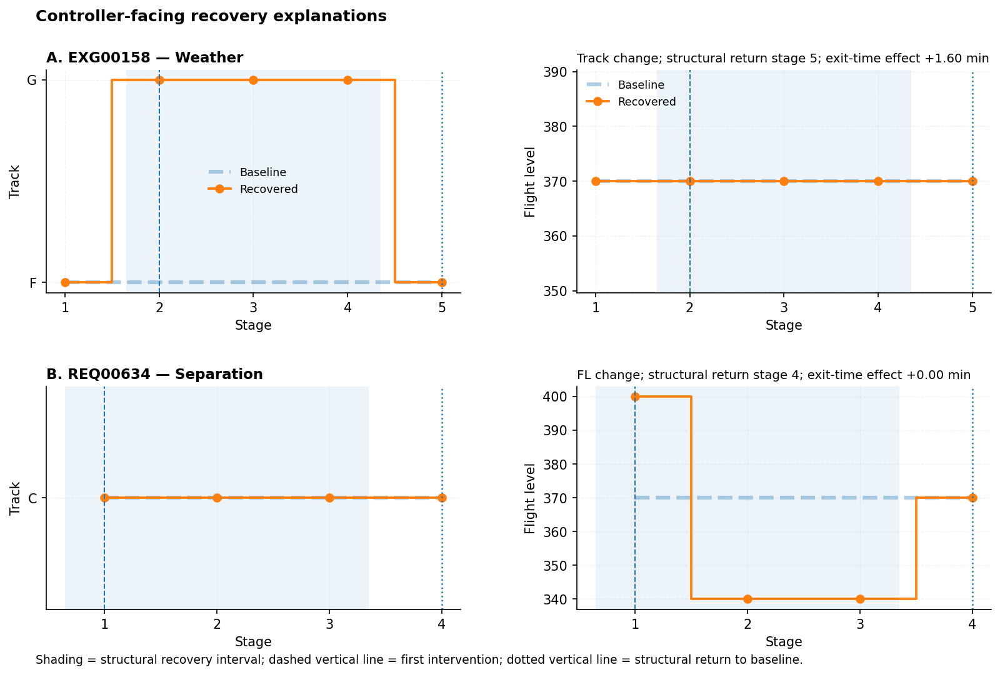

In [114]:
# =====================================================================
# CELL 27 — E7: ATC-FACING RECOVERY EXPLAINABILITY
# =====================================================================
# Purpose:
#   Explain why affected flights were changed, what action was taken,
#   where intervention began, how long it persisted, and when the
#   aircraft structurally returned to baseline; also provide a concise
#   ATC-facing recovery summary for each affected flight.
#
# Inputs:
#   SOLVED_CASES
#   FLIGHT_LEVEL_RECOVERY
#   VERIFIED_STAGE_SOLUTIONS
#   SUBMITTED_PROFILE_INTERACTION_AUDIT
#   BASELINE_WX_POINT_AUDIT
#
# Outputs:
#   Figure 5  — representative controller-facing recovery explanations
#   TABLE_27A — detailed intervention explanations (Table 5)
#   TABLE_27B — concise ATC-facing recovery summaries
#   CSV, PDF and PNG exports
# =====================================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

OUT = Path("paper_outputs")
OUT.mkdir(parents=True, exist_ok=True)

# ---------------------------------------------------------------------
# 1. Validate inputs and select definitive case
# ---------------------------------------------------------------------

required = [
    "SOLVED_CASES",
    "FLIGHT_LEVEL_RECOVERY",
    "VERIFIED_STAGE_SOLUTIONS",
    "SUBMITTED_PROFILE_INTERACTION_AUDIT",
    "BASELINE_WX_POINT_AUDIT",
]

missing = [
    name for name in required
    if name not in globals()
]

if missing:
    raise RuntimeError(
        f"Missing required object(s): {missing}"
    )

case_n = max(map(int, SOLVED_CASES.keys()))

case_ids = set(
    map(
        str,
        SOLVED_CASES[case_n]["case_ids"],
    )
)

R = FLIGHT_LEVEL_RECOVERY.copy()

R["Case"] = pd.to_numeric(
    R["Case"],
    errors="raise",
).astype(int)

R = R.loc[
    R["Case"].eq(case_n)
].copy()

R["Flight"] = R["Flight"].astype(str)

if R.empty:
    raise RuntimeError(
        "No affected-flight records found for the selected case."
    )

if R["Flight"].duplicated().any():
    raise RuntimeError(
        "Selected recovery case contains duplicate flight records."
    )

if not set(R["Flight"]).issubset(case_ids):
    raise RuntimeError(
        "Recovery table contains flights outside the selected case."
    )

VS = VERIFIED_STAGE_SOLUTIONS[case_n].copy()
VS["flight_id"] = VS["flight_id"].astype(str)

affected_ids = set(R["Flight"])

if not affected_ids.issubset(
    set(VS["flight_id"])
):
    raise RuntimeError(
        "Not all affected flights occur in VERIFIED_STAGE_SOLUTIONS."
    )

# ---------------------------------------------------------------------
# 2. Separation-trigger evidence
# ---------------------------------------------------------------------

A = SUBMITTED_PROFILE_INTERACTION_AUDIT.copy()

required_sep = {
    "flight_i",
    "flight_j",
    "interaction_type",
    "margin_min",
    "requires_recovery",
}

if not required_sep.issubset(A.columns):
    raise RuntimeError(
        "Unexpected SUBMITTED_PROFILE_INTERACTION_AUDIT schema."
    )

A["flight_i"] = A["flight_i"].astype(str)
A["flight_j"] = A["flight_j"].astype(str)

A = A.loc[
    A["flight_i"].isin(case_ids)
    & A["flight_j"].isin(case_ids)
    & A["requires_recovery"].eq(True)
].copy()

sep_rows = []

for flight in sorted(affected_ids):

    X = A.loc[
        A["flight_i"].eq(flight)
        | A["flight_j"].eq(flight)
    ].copy()

    margins = pd.to_numeric(
        X["margin_min"],
        errors="coerce",
    )

    sep_rows.append({
        "Flight": flight,
        "Separation interactions": int(len(X)),
        "Worst submitted margin (min)": (
            float(margins.min())
            if margins.notna().any()
            else np.nan
        ),
        "Interaction types": (
            ", ".join(
                sorted(
                    X["interaction_type"]
                    .dropna()
                    .astype(str)
                    .unique()
                )
            )
            if len(X)
            else ""
        ),
    })

SEP = pd.DataFrame(sep_rows)

# ---------------------------------------------------------------------
# 3. Formal case-specific weather-trigger evidence
# ---------------------------------------------------------------------
# BASELINE_WX_POINT_AUDIT records baseline passages falling within the
# formal prohibited space-time weather windows used by the model.
# ---------------------------------------------------------------------

BWA = BASELINE_WX_POINT_AUDIT.copy()

required_weather = {
    "flight_id",
    "weather_cell",
    "stage",
    "baseline_time",
    "window_id",
}

if not required_weather.issubset(BWA.columns):
    raise RuntimeError(
        "Unexpected BASELINE_WX_POINT_AUDIT schema."
    )

BWA["flight_id"] = BWA["flight_id"].astype(str)

BWA = BWA.loc[
    BWA["flight_id"].isin(case_ids)
    & BWA["flight_id"].isin(affected_ids)
].copy()

weather_rows = []

for flight in sorted(affected_ids):

    X = BWA.loc[
        BWA["flight_id"].eq(flight)
    ].copy()

    if X.empty:
        weather_rows.append({
            "Flight": flight,
            "Weather prohibitions": 0,
            "Weather cells": "",
            "Weather stages": "",
            "First prohibited baseline time (min)": np.nan,
        })
        continue

    stages = (
        pd.to_numeric(
            X["stage"],
            errors="raise",
        )
        .astype(int)
        .unique()
    )

    baseline_times = pd.to_numeric(
        X["baseline_time"],
        errors="raise",
    )

    weather_rows.append({
        "Flight": flight,
        "Weather prohibitions": int(
            X["window_id"].astype(str).nunique()
        ),
        "Weather cells": ", ".join(
            sorted(
                X["weather_cell"]
                .dropna()
                .astype(str)
                .unique()
            )
        ),
        "Weather stages": ", ".join(
            map(
                str,
                sorted(stages),
            )
        ),
        "First prohibited baseline time (min)": (
            float(baseline_times.min())
        ),
    })

WX = pd.DataFrame(weather_rows)

# ---------------------------------------------------------------------
# 4. Build evidence-supported explanations
# ---------------------------------------------------------------------

track = R["Track change"].eq(True)
fl = R["FL change"].eq(True)
mach = R["Mach change"].eq(True)
timing = R["Timing intervention"].eq(True)

R["Action"] = np.select(
    [
        track & fl,
        track,
        fl,
        mach,
        timing,
    ],
    [
        "Track + FL change",
        "Track change",
        "FL change",
        "Mach change",
        "Timing adjustment",
    ],
    default="Other",
)

E = (
    R.merge(
        SEP,
        on="Flight",
        how="left",
        validate="one_to_one",
    )
    .merge(
        WX,
        on="Flight",
        how="left",
        validate="one_to_one",
    )
)

E["Separation interactions"] = (
    E["Separation interactions"]
    .fillna(0)
    .astype(int)
)

E["Weather prohibitions"] = (
    E["Weather prohibitions"]
    .fillna(0)
    .astype(int)
)

E["Weather-supported"] = (
    E["Weather prohibitions"].gt(0)
)

E["Separation-supported"] = (
    E["Separation interactions"].gt(0)
)


def trigger_type(row):

    weather = bool(
        row["Weather-supported"]
    )

    separation = bool(
        row["Separation-supported"]
    )

    if weather and separation:
        return "Weather + separation"

    if weather:
        return "Weather"

    if separation:
        return "Separation"

    return "No direct trigger identified"


def trigger_evidence(row):
    parts = []

    if bool(row["Weather-supported"]):
        n_wx = int(row["Weather prohibitions"])

        text = (
            f"{n_wx} prohibited baseline space-time "
            f"{'window' if n_wx == 1 else 'windows'}"
        )

        cells = str(row["Weather cells"]).strip()

        if cells:
            text += f" ({cells})"

        first_time = row["First prohibited baseline time (min)"]

        if pd.notna(first_time):
            text += (
                "; first baseline exposure "
                f"{float(first_time):.2f} min"
            )

        parts.append(text)

    if bool(row["Separation-supported"]):
        n_sep = int(row["Separation interactions"])

        text = (
            f"{n_sep} recovery-required "
            f"{'interaction' if n_sep == 1 else 'interactions'}"
        )

        worst_margin = row["Worst submitted margin (min)"]

        if pd.notna(worst_margin):
            text += (
                "; worst margin "
                f"{float(worst_margin):.2f} min"
            )

        interaction_types = str(row["Interaction types"]).strip()

        if interaction_types:
            text += f" ({interaction_types})"

        parts.append(text)

    return (
        "; ".join(parts)
        if parts
        else "No direct trigger identified"
    )


E["Trigger"] = E.apply(
    trigger_type,
    axis=1,
)

E["Trigger evidence"] = E.apply(
    trigger_evidence,
    axis=1,
)

unresolved = E.loc[
    E["Trigger"].eq(
        "No direct trigger identified"
    ),
    "Flight",
].tolist()

if unresolved:
    raise RuntimeError(
        "No direct retained trigger evidence identified for: "
        + ", ".join(unresolved)
    )

# ---------------------------------------------------------------------
# 5. Clean publication-facing numerical effects
# ---------------------------------------------------------------------

for col in [
    "Distance change (NM)",
    "Exit-time displacement (min)",
]:
    E[col] = pd.to_numeric(
        E[col],
        errors="raise",
    )

    E[col] = E[col].mask(
        E[col].abs() < 0.005,
        0.0,
    )

    E[col] = E[col].round(2)

# ---------------------------------------------------------------------
# 6. TABLE_27A — detailed intervention explanations
# ---------------------------------------------------------------------

TABLE_27A = E[
    [
        "Flight",
        "Trigger",
        "Trigger evidence",
        "First deviation stage",
        "Action",
        "Deviated stages",
        "Return stage",
        "Distance change (NM)",
        "Exit-time displacement (min)",
    ]
].copy()

TABLE_27A = TABLE_27A.rename(
    columns={
        "First deviation stage":
            "First intervention",
        "Deviated stages":
            "Intervention stages",
        "Return stage":
            "Structural return stage",
        "Distance change (NM)":
            "Distance effect (NM)",
        "Exit-time displacement (min)":
            "Exit-time effect (min)",
    }
)

# Backward-compatible alias
TABLE_27 = TABLE_27A

# ---------------------------------------------------------------------
# 7. TABLE_27B — concise ATC-facing recovery summaries
# ---------------------------------------------------------------------

def atc_summary(row):

    action_map = {
        "Track change":
            "track change",
        "FL change":
            "FL change",
        "Track + FL change":
            "track + FL change",
        "Mach change":
            "Mach change",
        "Timing adjustment":
            "timing adjustment",
    }

    action = action_map.get(
        str(row["Action"]),
        str(row["Action"]),
    )

    trigger = str(
        row["Trigger"]
    ).lower()

    first_stage = int(
        row["First deviation stage"]
    )

    duration = int(
        row["Deviated stages"]
    )

    return_stage = int(
        row["Return stage"]
    )

    exit_effect = float(
        row["Exit-time displacement (min)"]
    )

    if abs(exit_effect) < 0.005:
        effect_text = (
            "no material exit-time change"
        )

    elif exit_effect > 0:
        effect_text = (
            f"+{exit_effect:.2f} min exit-time effect"
        )

    else:
        effect_text = (
            f"{exit_effect:.2f} min exit-time effect"
        )

    return (
        f"Suggested recovery: temporary {action} "
        f"from stage {first_stage} "
        f"for {duration} "
        f"stage{'s' if duration != 1 else ''} "
        f"to address the evidence-supported {trigger} condition; "
        f"return to baseline track/FL/Mach at stage {return_stage} "
        f"({effect_text})."
    )


E["Suggested ATC intervention"] = E.apply(
    atc_summary,
    axis=1,
)

TABLE_27B = E[
    [
        "Flight",
        "Suggested ATC intervention",
    ]
].copy()

# ---------------------------------------------------------------------
# 8. Select complementary representative flights
# ---------------------------------------------------------------------
# Representative 1:
#   weather-supported track intervention.
#
# Representative 2:
#   separation-supported FL intervention.
#
# Where possible, use examples supported by only one trigger class.
# ---------------------------------------------------------------------

weather_candidates = E.loc[
    E["Weather-supported"]
    & E["Track change"].eq(True)
].copy()

weather_only = weather_candidates.loc[
    ~weather_candidates[
        "Separation-supported"
    ]
].copy()

if not weather_only.empty:
    weather_candidates = weather_only

separation_candidates = E.loc[
    E["Separation-supported"]
    & E["FL change"].eq(True)
].copy()

separation_only = separation_candidates.loc[
    ~separation_candidates[
        "Weather-supported"
    ]
].copy()

if not separation_only.empty:
    separation_candidates = separation_only

if weather_candidates.empty:
    raise RuntimeError(
        "No weather-supported track-change example is available."
    )

if separation_candidates.empty:
    raise RuntimeError(
        "No separation-supported FL-change example is available."
    )

weather_rep = (
    weather_candidates
    .sort_values(
        [
            "Deviated stages",
            "Weather prohibitions",
            "Flight",
        ],
        ascending=[
            False,
            False,
            True,
        ],
    )
    .iloc[0]["Flight"]
)

separation_rep = (
    separation_candidates
    .sort_values(
        [
            "Separation interactions",
            "Worst submitted margin (min)",
            "Flight",
        ],
        ascending=[
            False,
            True,
            True,
        ],
    )
    .iloc[0]["Flight"]
)

representatives = [
    weather_rep,
    separation_rep,
]

# ---------------------------------------------------------------------
# 9. Figure 5 — controller-facing recovery explanations
# ---------------------------------------------------------------------

fig, axes = plt.subplots(
    2,
    2,
    figsize=(11.2, 7.2),
)

for row_i, flight in enumerate(
    representatives
):

    info = E.loc[
        E["Flight"].eq(flight)
    ].iloc[0]

    F = (
        VS.loc[
            VS["flight_id"].eq(flight)
        ]
        .sort_values("stage")
        .copy()
    )

    stages = F[
        "stage"
    ].to_numpy(dtype=int)

    first_stage = int(
        info["First deviation stage"]
    )

    last_stage = int(
        info["Last deviation stage"]
    )

    return_stage = int(
        info["Return stage"]
    )

    # -------------------------------------------------------------
    # Track profile
    # -------------------------------------------------------------

    ax = axes[row_i, 0]

    tracks = list(
        dict.fromkeys(
            list(
                F["baseline_track"]
                .astype(str)
            )
            +
            list(
                F["track"]
                .astype(str)
            )
        )
    )

    track_code = {
        name: i
        for i, name in enumerate(tracks)
    }

    baseline_track = (
        F["baseline_track"]
        .astype(str)
        .map(track_code)
        .to_numpy()
    )

    recovered_track = (
        F["track"]
        .astype(str)
        .map(track_code)
        .to_numpy()
    )

    ax.step(
        stages,
        baseline_track,
        where="mid",
        linestyle="--",
        linewidth=3.0,
        alpha=0.35,
        label="Baseline",
    )

    ax.step(
        stages,
        recovered_track,
        where="mid",
        linewidth=1.8,
        marker="o",
        label="Recovered",
    )

    ax.axvspan(
        first_stage - 0.35,
        last_stage + 0.35,
        alpha=0.08,
    )

    ax.axvline(
        first_stage,
        linestyle="--",
        linewidth=1.0,
    )

    ax.axvline(
        return_stage,
        linestyle=":",
        linewidth=1.2,
    )

    ax.set_yticks(
        range(len(tracks))
    )

    ax.set_yticklabels(
        tracks
    )

    ax.set_xticks(
        stages
    )

    ax.set_xlabel(
        "Stage"
    )

    ax.set_ylabel(
        "Track"
    )

    letter = (
        "A"
        if row_i == 0
        else "B"
    )

    ax.set_title(
        (
            f"{letter}. {flight} — "
            f"{info['Trigger']}"
        ),
        loc="left",
        fontsize=11,
        fontweight="semibold",
    )

    if row_i == 0:
        ax.legend(
            frameon=False
        )

    # -------------------------------------------------------------
    # Flight-level profile
    # -------------------------------------------------------------

    ax = axes[row_i, 1]

    ax.step(
        stages,
        F["baseline_fl"].to_numpy(
            dtype=float
        ),
        where="mid",
        linestyle="--",
        linewidth=3.0,
        alpha=0.35,
        label="Baseline",
    )

    ax.step(
        stages,
        F["fl"].to_numpy(
            dtype=float
        ),
        where="mid",
        linewidth=1.8,
        marker="o",
        label="Recovered",
    )

    ax.axvspan(
        first_stage - 0.35,
        last_stage + 0.35,
        alpha=0.08,
    )

    ax.axvline(
        first_stage,
        linestyle="--",
        linewidth=1.0,
    )

    ax.axvline(
        return_stage,
        linestyle=":",
        linewidth=1.2,
    )

    ax.set_xticks(
        stages
    )

    ax.set_xlabel(
        "Stage"
    )

    ax.set_ylabel(
        "Flight level"
    )

    exit_effect = float(
        info[
            "Exit-time displacement (min)"
        ]
    )

    if abs(exit_effect) < 0.005:
        exit_effect = 0.0

    ax.set_title(
        (
            f"{info['Action']}; "
            f"structural return stage {return_stage}; "
            f"exit-time effect {exit_effect:+.2f} min"
        ),
        loc="left",
        fontsize=9.5,
    )

    if row_i == 0:
        ax.legend(
            frameon=False
        )

    for panel in axes[row_i]:

        panel.grid(
            linestyle="--",
            linewidth=0.6,
            alpha=0.18,
        )

        panel.spines[
            ["top", "right"]
        ].set_visible(False)

fig.suptitle(
    "Controller-facing recovery explanations",
    x=0.07,
    y=0.99,
    ha="left",
    fontsize=12,
    fontweight="semibold",
)

fig.text(
    0.07,
    0.02,
    (
        "Shading = structural recovery interval; "
        "dashed vertical line = first intervention; "
        "dotted vertical line = structural return to baseline."
    ),
    fontsize=9,
)

fig.subplots_adjust(
    left=0.08,
    right=0.98,
    top=0.90,
    bottom=0.10,
    hspace=0.42,
    wspace=0.28,
)

# ---------------------------------------------------------------------
# 10. Export
# ---------------------------------------------------------------------

fig.savefig(
    OUT
    / "figure_5_controller_facing_recovery_explanations.pdf",
    bbox_inches="tight",
)

fig.savefig(
    OUT
    / "figure_5_controller_facing_recovery_explanations.png",
    dpi=400,
    bbox_inches="tight",
)

TABLE_27A.to_csv(
    OUT
    / "table_5_intervention_explanations.csv",
    index=False,
)

TABLE_27B.to_csv(
    OUT
    / "table_5b_atc_recovery_summaries.csv",
    index=False,
)

# ---------------------------------------------------------------------
# 11. Paper-facing summary
# ---------------------------------------------------------------------

n_weather = int(
    E["Weather-supported"].sum()
)

n_separation = int(
    E["Separation-supported"].sum()
)

n_weather_only = int(
    (
        E["Weather-supported"]
        & ~E["Separation-supported"]
    ).sum()
)

n_separation_only = int(
    (
        ~E["Weather-supported"]
        & E["Separation-supported"]
    ).sum()
)

n_both = int(
    (
        E["Weather-supported"]
        & E["Separation-supported"]
    ).sum()
)

print("=" * 76)
print("CELL 27 — E7: ATC-FACING RECOVERY EXPLAINABILITY")
print("=" * 76)
print(f"Selected case                    : {case_n}")
print(f"Affected flights                 : {len(TABLE_27A)}")
print(f"Weather-supported affected       : {n_weather}")
print(f"Separation-supported affected    : {n_separation}")
print(f"Weather only                     : {n_weather_only}")
print(f"Separation only                  : {n_separation_only}")
print(f"Weather + separation             : {n_both}")
print(f"Weather-track representative     : {weather_rep}")
print(f"Separation-FL representative     : {separation_rep}")
print(
    f"Affected flights with evidence   : "
    f"{len(TABLE_27A)}/{len(TABLE_27A)}"
)
print(
    f"ATC summaries generated          : "
    f"{len(TABLE_27B)}"
)
print(
    f"Exports                          : "
    f"{OUT.resolve()}"
)
print("=" * 76)

print(
    "\nTABLE 5 — DETAILED INTERVENTION EXPLANATIONS"
)
display(TABLE_27A)

print(
    "\nATC-FACING RECOVERY SUMMARIES"
)
display(TABLE_27B)

plt.show()

CELL 28 — E8: COMPUTATIONAL PERFORMANCE AND SCALING
Fleet sizes                     : 50, 100, 150
Total benchmark time            : 16.50 s → 2997.79 s
Largest-case benchmark time     : 49.96 min
Benchmark-time growth (50→150)  : 181.6×
Aircraft-interaction growth     : 9.6×
Equation-count growth           : 8.4×
Lexicographic stages per case   : 6
Dominant 150-flight stage      : P2 (Mach, 1117.33 s)
All final statuses              : OptimalGlobal
Exports                         : C:\Users\sz4911s\paper_outputs


,Flights,Aircraft interactions,Equations,Variables,Discrete variables,Nonzeros,Build time (s),Solve wall time (s),Total benchmark time (s),Stages,Status
0,50,2850,46360,7819,7543,330151,6.89,9.61,16.50,6,OptimalGlobal
1,100,10550,157234,21026,20474,1189034,12.51,113.17,125.67,6,OptimalGlobal
2,150,27488,390278,43224,42410,3056806,18.53,2979.26,2997.79,6,OptimalGlobal


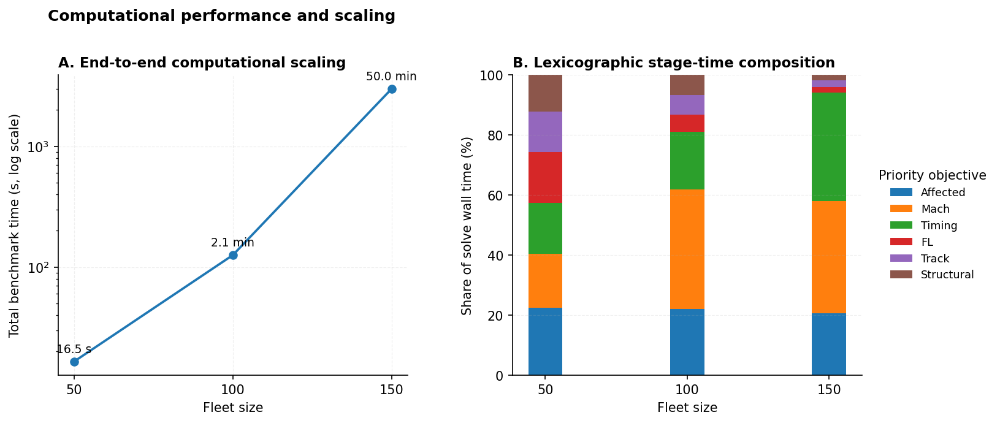

In [101]:
# =====================================================================
# CELL 28 — E8: COMPUTATIONAL PERFORMANCE AND SCALING
# =====================================================================
# Purpose:
#   Quantify how computational effort and model size scale with fleet
#   size, and show where lexicographic solve time is concentrated.
#
# Inputs:
#   SCALABILITY_RESULTS
#   LEXICOGRAPHIC_RESULTS
#
# Outputs:
#   Figure 6 — computational scaling
#   TABLE_28 — compact timing/model-size summary
#   CSV, PDF and PNG exports
# =====================================================================

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

OUT = Path("paper_outputs")
OUT.mkdir(parents=True, exist_ok=True)

# ---------------------------------------------------------------------
# 1. Validate inputs
# ---------------------------------------------------------------------

required = [
    "SCALABILITY_RESULTS",
    "LEXICOGRAPHIC_RESULTS",
]

missing = [name for name in required if name not in globals()]
if missing:
    raise RuntimeError(f"Missing required object(s): {missing}")

S = SCALABILITY_RESULTS.copy()
L = LEXICOGRAPHIC_RESULTS.copy()

S["Case"] = pd.to_numeric(S["Case"], errors="raise").astype(int)
L["Case"] = pd.to_numeric(L["Case"], errors="raise").astype(int)
L["Priority"] = pd.to_numeric(L["Priority"], errors="raise").astype(int)

S = S.sort_values("Case").reset_index(drop=True)
L = L.sort_values(["Case", "Priority"]).reset_index(drop=True)

# ---------------------------------------------------------------------
# 2. Cross-check lexicographic timing and status
# ---------------------------------------------------------------------

stage_totals = (
    L.groupby("Case", as_index=False)
    .agg(
        Stages=("Priority", "count"),
        Stage_wall_time=("Wall time (s)", "sum"),
    )
)

S = S.merge(
    stage_totals,
    on="Case",
    how="left",
    validate="one_to_one",
)

if not S["Stages"].eq(6).all():
    raise RuntimeError(
        "Expected six lexicographic stages for every case."
    )

if not (
    (S["Solve wall time (s)"] - S["Stage_wall_time"]).abs() < 1e-6
).all():
    raise RuntimeError(
        "Solve wall time does not match summed stage wall time."
    )

if not L["Model status"].eq("OptimalGlobal").all():
    raise RuntimeError(
        "At least one lexicographic stage is not globally optimal."
    )

# ---------------------------------------------------------------------
# 3. Compact publication table
# ---------------------------------------------------------------------

TABLE_28 = S[
    [
        "Case",
        "Aircraft interactions",
        "Equations",
        "Variables",
        "Discrete variables",
        "Nonzeros",
        "Build time (s)",
        "Solve wall time (s)",
        "Total benchmark time (s)",
        "Stages",
        "Final status",
    ]
].copy()

TABLE_28 = TABLE_28.rename(
    columns={
        "Case": "Flights",
        "Final status": "Status",
    }
)

for col in [
    "Build time (s)",
    "Solve wall time (s)",
    "Total benchmark time (s)",
]:
    TABLE_28[col] = TABLE_28[col].round(2)

# ---------------------------------------------------------------------
# 4. Stage-wise timing composition
# ---------------------------------------------------------------------

objective_order = [
    "affected_flights",
    "mach_interventions",
    "timing_interventions",
    "fl_interventions",
    "track_interventions",
    "structural_deviation",
]

objective_labels = {
    "affected_flights": "Affected",
    "mach_interventions": "Mach",
    "timing_interventions": "Timing",
    "fl_interventions": "FL",
    "track_interventions": "Track",
    "structural_deviation": "Structural",
}

P = (
    L.pivot(
        index="Case",
        columns="Objective",
        values="Wall time (s)",
    )
    .reindex(index=S["Case"], columns=objective_order)
)

P_share = P.div(P.sum(axis=1), axis=0) * 100

# ---------------------------------------------------------------------
# 5. Figure 6 — computational scaling
# ---------------------------------------------------------------------

fig, (ax1, ax2) = plt.subplots(
    1,
    2,
    figsize=(11.5, 4.8),
)

# -----------------------------------------------------------------
# Panel A — end-to-end benchmark time
# -----------------------------------------------------------------

ax1.plot(
    S["Case"],
    S["Total benchmark time (s)"],
    marker="o",
    linewidth=1.8,
)

for x, y in zip(
    S["Case"],
    S["Total benchmark time (s)"],
):
    label = (
        f"{y:.1f} s"
        if y < 120
        else f"{y / 60:.1f} min"
    )

    ax1.annotate(
        label,
        (x, y),
        xytext=(0, 7),
        textcoords="offset points",
        ha="center",
        fontsize=9,
    )

ax1.set_yscale("log")
ax1.set_xticks(S["Case"])

ax1.set_xlabel("Fleet size")
ax1.set_ylabel("Total benchmark time (s, log scale)")

ax1.set_title(
    "A. End-to-end computational scaling",
    loc="left",
    fontsize=11,
    fontweight="semibold",
)

ax1.grid(
    linestyle="--",
    linewidth=0.6,
    alpha=0.20,
)

ax1.spines[["top", "right"]].set_visible(False)

# -----------------------------------------------------------------
# Panel B — percentage of solve time by priority
# -----------------------------------------------------------------

bottom = pd.Series(
    0.0,
    index=P_share.index,
)

for objective in objective_order:

    values = P_share[objective]

    ax2.bar(
        P_share.index,
        values,
        bottom=bottom,
        width=12,
        label=objective_labels[objective],
    )

    bottom = bottom + values

ax2.set_xticks(S["Case"])
ax2.set_ylim(0, 100)

ax2.set_xlabel("Fleet size")
ax2.set_ylabel("Share of solve wall time (%)")

ax2.set_title(
    "B. Lexicographic stage-time composition",
    loc="left",
    fontsize=11,
    fontweight="semibold",
)

ax2.grid(
    axis="y",
    linestyle="--",
    linewidth=0.6,
    alpha=0.20,
)

ax2.spines[["top", "right"]].set_visible(False)

ax2.legend(
    title="Priority objective",
    frameon=False,
    fontsize=8.5,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
)

fig.suptitle(
    "Computational performance and scaling",
    x=0.07,
    y=0.99,
    ha="left",
    fontsize=12,
    fontweight="semibold",
)

fig.subplots_adjust(
    left=0.08,
    right=0.84,
    top=0.84,
    bottom=0.16,
    wspace=0.30,
)

# ---------------------------------------------------------------------
# 6. Export
# ---------------------------------------------------------------------

fig.savefig(
    OUT / "figure_6_computational_scaling.pdf",
    bbox_inches="tight",
)

fig.savefig(
    OUT / "figure_6_computational_scaling.png",
    dpi=400,
    bbox_inches="tight",
)

TABLE_28.to_csv(
    OUT / "table_28_computational_scaling.csv",
    index=False,
)

# ---------------------------------------------------------------------
# 7. Paper-facing summary
# ---------------------------------------------------------------------

small = S.iloc[0]
large = S.iloc[-1]

time_ratio = (
    large["Total benchmark time (s)"]
    / small["Total benchmark time (s)"]
)

interaction_ratio = (
    large["Aircraft interactions"]
    / small["Aircraft interactions"]
)

equation_ratio = (
    large["Equations"]
    / small["Equations"]
)

largest_case = int(large["Case"])

dominant_stage = (
    L.loc[L["Case"].eq(largest_case)]
    .sort_values("Wall time (s)", ascending=False)
    .iloc[0]
)

dominant_label = objective_labels.get(
    dominant_stage["Objective"],
    str(dominant_stage["Objective"]),
)

print("=" * 76)
print("CELL 28 — E8: COMPUTATIONAL PERFORMANCE AND SCALING")
print("=" * 76)
print(
    f"Fleet sizes                     : "
    f"{', '.join(map(str, S['Case']))}"
)
print(
    f"Total benchmark time            : "
    f"{small['Total benchmark time (s)']:.2f} s "
    f"→ {large['Total benchmark time (s)']:.2f} s"
)
print(
    f"Largest-case benchmark time     : "
    f"{large['Total benchmark time (s)'] / 60:.2f} min"
)
print(
    f"Benchmark-time growth (50→150)  : "
    f"{time_ratio:.1f}×"
)
print(
    f"Aircraft-interaction growth     : "
    f"{interaction_ratio:.1f}×"
)
print(
    f"Equation-count growth           : "
    f"{equation_ratio:.1f}×"
)
print(
    f"Lexicographic stages per case   : "
    f"{int(S['Stages'].iloc[0])}"
)
print(
    f"Dominant {largest_case}-flight stage      : "
    f"P{int(dominant_stage['Priority'])} "
    f"({dominant_label}, "
    f"{float(dominant_stage['Wall time (s)']):.2f} s)"
)
print(
    f"All final statuses              : "
    f"{', '.join(sorted(S['Final status'].astype(str).unique()))}"
)
print(f"Exports                         : {OUT.resolve()}")
print("=" * 76)

display(TABLE_28)

plt.show()

In [115]:
# =====================================================================
# CELL 29 — FINAL PUBLICATION OUTPUT CHECK
# =====================================================================
# Purpose:
#   Verify that the planned publication package from Cells 20–28 is
#   complete before manuscript writing.
#
# No new experiment or scientific result is introduced.
#
# Expected principal package:
#   Figures 1–6
#   Tables 1–5
#
# Outputs:
#   PUBLICATION_CHECK
#   PUBLICATION_MANIFEST
#   publication_output_check.csv
#   publication_output_manifest.csv
# =====================================================================

from pathlib import Path
import re
import pandas as pd

OUT = Path("paper_outputs")

if not OUT.exists():
    raise RuntimeError(
        f"Publication-output directory does not exist: {OUT.resolve()}"
    )

# ---------------------------------------------------------------------
# 1. Inventory existing outputs
# ---------------------------------------------------------------------

own_outputs = {
    "publication_output_check.csv",
    "publication_output_manifest.csv",
}

files = sorted(
    p for p in OUT.iterdir()
    if p.is_file()
    and p.name not in own_outputs
)

if not files:
    raise RuntimeError(
        f"No publication outputs found in: {OUT.resolve()}"
    )

PUBLICATION_MANIFEST = pd.DataFrame([
    {
        "File": p.name,
        "Format": p.suffix.lstrip(".").upper(),
        "Size (KB)": round(p.stat().st_size / 1024, 1),
    }
    for p in files
])

# ---------------------------------------------------------------------
# 2. Check Figures 1–6
# ---------------------------------------------------------------------

checks = []

for number in range(1, 7):

    pattern = re.compile(
        rf"^figure_{number}(?:_|\.|$)",
        re.IGNORECASE,
    )

    matches = [
        p for p in files
        if pattern.search(p.name)
    ]

    pdf = [
        p for p in matches
        if p.suffix.lower() == ".pdf"
        and p.stat().st_size > 0
    ]

    png = [
        p for p in matches
        if p.suffix.lower() == ".png"
        and p.stat().st_size > 0
    ]

    checks.append({
        "Output": f"Figure {number}",
        "Requirement": "PDF + PNG",
        "Files found": "; ".join(p.name for p in matches),
        "Status": "PASS" if pdf and png else "FAIL",
    })

# ---------------------------------------------------------------------
# 3. Check Tables 1–5
# ---------------------------------------------------------------------

for number in range(1, 6):

    pattern = re.compile(
        rf"^table_{number}(?:_|\.|$)",
        re.IGNORECASE,
    )

    matches = [
        p for p in files
        if pattern.search(p.name)
        and p.suffix.lower() == ".csv"
        and p.stat().st_size > 0
    ]

    checks.append({
        "Output": f"Table {number}",
        "Requirement": "CSV",
        "Files found": "; ".join(p.name for p in matches),
        "Status": "PASS" if matches else "FAIL",
    })

PUBLICATION_CHECK = pd.DataFrame(checks)

# ---------------------------------------------------------------------
# 4. Final integrity status
# ---------------------------------------------------------------------

n_figures_pass = int(
    PUBLICATION_CHECK.loc[
        PUBLICATION_CHECK["Output"].str.startswith("Figure"),
        "Status",
    ].eq("PASS").sum()
)

n_tables_pass = int(
    PUBLICATION_CHECK.loc[
        PUBLICATION_CHECK["Output"].str.startswith("Table"),
        "Status",
    ].eq("PASS").sum()
)

overall_pass = PUBLICATION_CHECK["Status"].eq("PASS").all()

# ---------------------------------------------------------------------
# 5. Export
# ---------------------------------------------------------------------

PUBLICATION_CHECK.to_csv(
    OUT / "publication_output_check.csv",
    index=False,
)

PUBLICATION_MANIFEST.to_csv(
    OUT / "publication_output_manifest.csv",
    index=False,
)

# ---------------------------------------------------------------------
# 6. Notebook-facing summary
# ---------------------------------------------------------------------

print("=" * 76)
print("CELL 29 — FINAL PUBLICATION OUTPUT CHECK")
print("=" * 76)
print(f"Output directory                 : {OUT.resolve()}")
print(f"Principal figures complete       : {n_figures_pass}/6")
print(f"Principal tables complete        : {n_tables_pass}/5")
print(
    f"Overall publication package      : "
    f"{'PASS' if overall_pass else 'FAIL'}"
)
print(f"Files inventoried                 : {len(PUBLICATION_MANIFEST)}")
print("=" * 76)

display(PUBLICATION_CHECK)

if not overall_pass:
    missing = PUBLICATION_CHECK.loc[
        PUBLICATION_CHECK["Status"].eq("FAIL"),
        "Output",
    ].tolist()

    raise RuntimeError(
        "Publication package incomplete: "
        + ", ".join(missing)
    )

CELL 29 — FINAL PUBLICATION OUTPUT CHECK
Output directory                 : C:\Users\sz4911s\paper_outputs
Principal figures complete       : 6/6
Principal tables complete        : 5/5
Overall publication package      : PASS
Files inventoried                 : 35


,Output,Requirement,Files found,Status
0,Figure 1,PDF + PNG,figure_1_baseline_problem.pdf; figure_1_baseli...,PASS
1,Figure 2,PDF + PNG,figure_2_fleet_level_coordination.pdf; figure_...,PASS
2,Figure 3,PDF + PNG,figure_3_sequential_optimisation.pdf; figure_3...,PASS
3,Figure 4,PDF + PNG,figure_4_weather_robustness.pdf; figure_4_weat...,PASS
4,Figure 5,PDF + PNG,figure_5_controller_facing_recovery_explanatio...,PASS
5,Figure 6,PDF + PNG,figure_6_computational_scaling.pdf; figure_6_c...,PASS
6,Table 1,CSV,table_1_experimental_design.csv,PASS
7,Table 2,CSV,table_2_recovery_performance.csv,PASS
8,Table 3,CSV,table_3_sequential_optimisation.csv,PASS
9,Table 4,CSV,table_4_independent_safety_feasibility_audit.csv,PASS
